In [ ]:
# # # Install a pip package in the current Jupyter kernel
import sys
!{sys.executable} -m pip install samplerate --user

## Imports

In [ ]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

# This example imports functions from the DemoReadSGLXData module to read
# digital data. The metadata file must be present in the same directory as the binary file.
# Works with both imec and nidq digital channels.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats
from scipy.interpolate import interp1d
from scipy.stats import linregress, spearmanr, kendalltau, pearsonr, circstd
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import shapiro

from pathlib import Path
from tkinter import Tk
from tkinter import filedialog
# from DemoReadSGLXData.readSGLX import readMeta, SampRate, makeMemMapRaw, ExtractDigital
from datetime import datetime
from scipy.io import savemat, loadmat
from sklearn.manifold import Isomap
from scipy.optimize import curve_fit
from scipy.signal import chirp, peak_widths
from scipy.signal import find_peaks, savgol_filter, medfilt
import mat73, pickle
import itertools
from matplotlib_venn import venn2, venn3
# load pickle module
# import dill as pickle
# import samplerate
import time, os, math
from joblib import Parallel, delayed
mpl.rcParams['pdf.fonttype'] = 42 
mpl.rcParams['font.sans-serif']=['Arial', 'Helvetica','Bitstream Vera Sans', 'DejaVu Sans', 'Lucida Grande', 
                                 'Verdana', 'Geneva', 'Lucid', 'Avant Garde', 'sans-serif']  

# for publication quality plots
def set_pub_plots(pal=sns.blend_palette(["gray","crimson", 'cyan', 'magenta', 'purple'  ],5)):
    sns.set_style("white")
    sns.set_palette('pastel')
    sns.set_context("poster", font_scale=1.5, rc={"lines.linewidth": 2.5, "axes.linewidth":2.5, 'figure.facecolor': 'white'}) 
    sns.set_style("ticks", {"xtick.major.size": 8, "ytick.major.size": 8})
    # optional, makes markers bigger, too, axes.linewidth doesn't seem to work
    plt.rcParams['axes.linewidth'] = 2.5

rc_pub={'font.size': 25, 'axes.labelsize': 25, 'legend.fontsize': 25.0, 
    'axes.titlesize': 25, 'xtick.labelsize': 25, 'ytick.labelsize': 25, 
    #'axes.color_cycle':pal, # image.cmap - rewritesd the default colormap
    'axes.linewidth':2.5, 'lines.linewidth': 2.5,
    'xtick.color': 'black', 'ytick.color': 'black', 'axes.edgecolor': 'black','axes.labelcolor':'black','text.color':'black'}
# to restore the defaults, call plt.rcdefaults() 

#set_pub_bargraphs()
set_pub_plots()
sns.set_context('poster')
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False
#on jupyter  don't forget the .exe, cahnge based on the computer
plt.rcParams['animation.ffmpeg_path'] = r"C:\ffmpeg\bin\ffmpeg.exe" 



## Functions

In [1]:
def get_recinfo_fname(fn):
    
    dts = fn.split('_')[0]
    mouse_id = fn.split('_')[1]
    hem = fn.split('_')[2]
    hstripe = fn.split('_')[4]
    cond = fn.split('_')[6]
    rec_session = mouse_id + '_' + dts
    
    return dts, mouse_id, hem, hstripe, cond, rec_session

In [2]:
def get_yaw_speed_rec(rec, d_data):
    """
    get behavior from dict
    smoothsed yaw in deg, speed in cm/s
    """
    if 'HF' in rec:
        yaw = d_data[rec]['unity']['head_dir'].values
        yaw_sm = smooth_interp_yaw(yaw, 31, 2)
        lin_speed = d_data[rec]['unity']['speed'].values*100
        lin_speed_sm = savgol_filter(lin_speed, window_length=25, polyorder=2)
    elif 'L1' in rec or 'D1' in rec:
        # speed in cm/s
        yaw = d_data[rec]['unity']['hd'].values
        yaw_sm = smooth_interp_yaw(yaw, 31, 2)
        lin_speed = d_data[rec]['unity']['tail_speed'].values
        lin_speed_sm = savgol_filter(lin_speed, window_length=25, polyorder=2)
    else:
        yaw_sm = d_data[rec]['unity']['RotY'].values
#         yaw_sm = smooth_interp_yaw(yaw_sm, 31, 2)
        lin_speed = d_data[rec]['unity']['speed'].values*100
        lin_speed_sm = savgol_filter(lin_speed, window_length=25, polyorder=2)
        
    return yaw_sm, lin_speed_sm

def get_stat_run_epochs(speed, window_size = 25, speed_thr = 4):
    # take abs for ang vel
    speed = abs(speed)
    speed = speed[:speed.size//window_size*window_size]
    speed_bin_mean = np.nanmean(speed.reshape(-1, window_size), 1)  
    speed_idx = np.concatenate([np.arange(pair[0]*window_size, pair[0]*window_size + window_size) for 
                            pair in enumerate(speed_bin_mean) if pair[1] > speed_thr])[:-10]
    stat_idx = np.concatenate([np.arange(pair[0]*window_size, pair[0]*window_size + window_size) for 
                            pair in enumerate(speed_bin_mean) if pair[1] <= speed_thr])[:-10]
    return stat_idx, speed_idx


def compute_dYaw(yaw):

    dYaw = np.gradient(yaw)            
    idx_pos = np.where((dYaw > 300))[0]
    idx_neg = np.where((dYaw < -300))[0]

    dYaw[idx_pos] = dYaw[idx_pos] - 360
    dYaw[idx_neg] = dYaw[idx_neg] + 360
    
#     deltaYaw_filt = savgol_filter(dYaw, window_length=11, polyorder=2)
    # max 250 deg/s
    dYaw[abs(dYaw) > 5] = 0

    return dYaw

def cyclic_difference(a, max_value=360):
    diff = np.diff(a)

    # Adjust for cyclic nature
    diff = ((diff + max_value *0.5) % max_value) - (max_value *0.5)

    return diff

In [3]:
# smooth hist with boxcar
# def bin_smooth_spk(df, binSize, mouse_id, rec_target, dts, vr_env, head_fixation):
#     trace_length = round(df.spk.max())
#     boxcar = np.ones(int(1/binSize))
#     edges = np.arange(0, trace_length, binSize)
#     ls_df = [] 
#     for unit in df.unit_id.unique():
#         spkt = df[df.unit_id == unit].spk
#         hist, bins = np.histogram(spkt, bins = edges)
#         spkd = np.convolve(hist, boxcar, mode = 'same')
#         cuid = str(int(unit)) + "-" + mouse_id + '-' + rec_target + "-" + dts[4:] + '-' + vr_env + head_fixation
#         df_tmp = pd.DataFrame({'cids': unit, 'cuid':cuid, 'hz': spkd, 'times': bins[:-1]})
#         ls_df.append(df_tmp)
#     #     print(spkt)
#     df_out = pd.concat(ls_df)
#     return df_out

def bin_smooth_spk(df, binSize, boxcar_size):
    # boxcar_size in samples, 50 = 1s
    trace_length = round(df.spk.max())
    # integral of winodw should be equal 1; added 6/4/24
    boxcar = np.ones(boxcar_size)/boxcar_size
    edges = np.arange(0, trace_length, binSize)
    ls_df = [] 
    for unit in df.unit_id.unique():
        spkt = df[df.unit_id == unit].spk
        hist, bins = np.histogram(spkt, bins = edges)
        spkd = np.convolve(hist, boxcar, mode = 'same')
        # normalize spkd by sr
        spkd = spkd*50
        df_tmp = pd.DataFrame({'cids': unit, 'hz': spkd, 'times': bins[:-1]})
        ls_df.append(df_tmp)
    #     print(spkt)
    df_out = pd.concat(ls_df)
    return df_out

In [4]:
def bin_tuning_permute(yaw, fr):
    # yaw in deg, fr in hz
    ls_r = []
    hd_tuning = bin_tuning(yaw, fr)
    angles = hd_tuning[0]
    bin_fr = hd_tuning[1]
    r = circ_r(angles, bin_fr) 
    # multiprocessing
    n_sim = 1000
    ls_r = \
        Parallel(n_jobs=8, verbose=0)\
        (delayed(bin_tun_fake)(yaw, fr) for i in range(n_sim))
    #         print(i, r_fake)
    p_val = np.sum(r<ls_r)/n_sim
    return r, hd_tuning, p_val

def bin_tuning(yaw, sp_counts):
    out = np.zeros((2, 18))
    for i in range(18):
        bin_idx = [(yaw >= i*20) & (yaw < i*20 + 20)]
#         print(np.sum(bin_idx[0]))
        if np.sum(bin_idx) > 0:
            total_count = np.nanmean(sp_counts[tuple(bin_idx)])
        else:
            total_count = 0
        out[1,i] = total_count
        out[0, i] = i*20
    return out

def bin_tun_fake(yaw, fr):
    offset = int(np.floor(np.random.random()*yaw.size))
    yaw_fake = np.concatenate((yaw[offset:], yaw[:offset]))
    tun_fake = bin_tuning(yaw_fake, fr)
    angles = tun_fake[0]
    bin_fr_fake = tun_fake[1]
    r_fake = circ_r(angles, bin_fr_fake) 
    return r_fake

def circ_r(angle, fr):
    # angle [0 360]
    a = np.deg2rad(angle - 180)
    # compute weighted sum of cos and sin of angles
    r = np.nansum(fr*np.exp(1j*a))
    # obtain length 
    r = abs(r)/np.nansum(fr)
    return r

In [5]:
# import resampy
# def hd_tuning_width(fr1):
#     # shift peak to the center
#     shift_idx = fr1.argmax()-9
#     if shift_idx > 0:
#         fr1_roll = np.roll(fr1, - shift_idx)
#     else:
#         fr1_roll = np.roll(fr1, shift_idx)
#     # upsample 10x
#     fr_resam = resampy.resample(fr1_roll, 1 ,10,  filter='sinc_window',
#                                     num_zeros=10, precision=5)

#     results_half = peak_widths(fr_resam, [fr_resam.argmax()], rel_height=0.5)
#     return results_half[0][0]*2


# def single_gaus(x, base, theta_pref, rp, sigma):
#     y = []
#     for idx in range(x.size):
#         pref = min(abs(x[idx] - theta_pref), abs(x[idx] - theta_pref+180), abs(x[idx] - theta_pref-180)) 
        

#         y.append( base + rp * np.exp( - (pref**2)/(2*(sigma**2))) )
        
#     return np.array(y)

In [6]:
def nan_helper(y):
    """Helper to handle indices and logical indices of NaNs.

    Input:
        - y, 1d numpy array with possible NaNs
    Output:
        - nans, logical indices of NaNs
        - index, a function, with signature indices= index(logical_indices),
          to convert logical indices of NaNs to 'equivalent' indices
    Example:
        >>> # linear interpolation of NaNs
        >>> nans, x= nan_helper(y)
        >>> y[nans]= np.interp(x(nans), x(~nans), y[~nans])
    """

    return np.isnan(y), lambda z: z.nonzero()[0]


In [7]:
def smooth_interp_yaw(yaw, window_length = 11, polyorder = 1):
    yaw_rad = np.deg2rad(yaw)
    yaw_rad[~np.isnan(yaw_rad)] = np.unwrap(yaw_rad[~np.isnan(yaw_rad)])
    nans, nanx = nan_helper(yaw_rad)
    yaw_rad[nans] = np.interp(nanx(nans), nanx(~nans), yaw_rad[~nans])
    yaw_intrp = np.rad2deg(yaw_rad)
    yaw_sm = savgol_filter(yaw_intrp, window_length=window_length, polyorder=polyorder)
    yaw_sm = yaw_sm % 360
    return yaw_sm

In [8]:
def consecutive(data, stepsize=1):
    return np.split(data, np.where(np.diff(data) != stepsize)[0]+1)
    
def ang_diff(a1, a2):
    a1 = np.array(a1)
    a2 = np.array(a2)
    return 180 - abs(abs(a1 - a2) - 180)

In [9]:
def compute_ringness(inp):
 
    dist_tmp = []
    vis_dist = []
    x = inp[:,0]
    y = inp[:,1]
    n_samples10 = x.size//4
    centroid = np.mean(inp, axis = 0)
    
    xmin, xmax = x.min(), x.max()
    ymin, ymax = y.min(), y.max()
    viscenter = (xmin + xmax)/2, (ymin + ymax)/2
    
    for idx in range(inp.shape[0]):
#         dist_tmp.append(math.dist(centroid[:],data[idx,:]))
        dist_tmp.append(np.linalg.norm(centroid-inp[idx, :])) 
        vis_dist.append(np.linalg.norm(viscenter-inp[idx, :]))
        
#     dist_tmp.sort(reverse = True)
    vis_dist_out = vis_dist.copy()
    vis_dist.sort()
    bot10 = vis_dist[:n_samples10]
    vis_dist.sort(reverse = True)
    top10 = vis_dist[:n_samples10]
    
    radius = np.mean(dist_tmp[:])
    vis_radius = np.mean(vis_dist[:])
    ringness = np.mean(bot10)/np.mean(top10)*radius
#     for idx in range(data.shape[0]):
#         ringness.append(np.abs(np.sqrt((data[idx,0]-centroid[0])**2+(data[idx,1]-centroid[1])**2)-radius))
    
    return radius, centroid, ringness, vis_dist_out

def compute_radius(x, y, run_mask):
    # Instead of true min/max, use robust extremes
    cx = (np.percentile(x[run_mask], 2) + np.percentile(x[run_mask], 98)) / 2
    cy = (np.percentile(y[run_mask], 2) + np.percentile(y[run_mask], 98)) / 2
    
    # Apply to all epochs
    radius = np.sqrt((x[:] - cx)**2 + (y[:] - cy)**2)
    return (cx,cy), radius

In [10]:
good_arena_sessions = ['20220818_JA178_lADN_red_H2_R_L1', '20220819_JA178_lADN_red_H2_R_L1', '20220823_JA178_lADN_red_H2_R_L1', 
                 '20220902_JA178_rADN_yel_H2_R_L1', '20220906_JA178_rADN_yel_H2_R_L1', '20220907_JA178_rADN_yel_H2_R_L1', 
                 '20220908_JA178_rADN_yel_H2_R_L1', '20220909_JA178_rADN_yel_H2_R_L1', 
                 
                 '20220802_JA179_lADN_red_H2_VR1_L1', '20220803_JA179_lADN_red_H2_VR1_L1', '20220804_JA179_lADN_red_H2_VR1_L1', 
                 '20220805_JA179_lADN_red_H2_VR1_L1', '20220811_JA179_rADN_yel_H1_VR1_L1', 
                 
                 '20220809_JA180_lADN_red_H2_VR1_L1', '20220810_JA180_lADN_red_H2_VR1_L1', 
                 '20220811_JA180_lADN_red_H2_VR1_L1', '20220819_JA180_lADN_red_H2_R_L1', 
                 
                 '20220809_JA181_lADN_red_H2_VR1_L1', '20220812_JA181_lADN_red_H2_VR1_L1', 
                 '20220817_JA181_lADN_red_H2_R_L1', 
                 
                 '20220627_MC022_lADN_red_H2_R_L1', '20220628_MC022_lADN_red_H2_R_L1', '20220629_MC022_lADN_red_H2_R_L1', 
                 '20220718_MC022_lADN_red_H2_VR1_L1', 
                 
                 '20220727_MC036_lADN_red_H1_VR1_L1',
                 
                 '20220829_MC038_lADN_red_H2_R_L1', '20220830_MC038_lADN_red_H2_R_L1', 
                 '20220831_MC038_lADN_red_H2_R_L1']

good_rec_sessions = [   'MC022_20220627', 'MC022_20220628', 'MC022_20220629', 'MC022_20220718',
                        'MC036_20220727', 'MC036_20220728',
                        'JA179_20220802', 'JA179_20220803', 'JA179_20220804', 'JA179_20220805',  
                        'JA179_20220811',  
                        'JA180_20220809', 'JA180_20220810', 'JA180_20220811', 'JA180_20220819', 
                        'JA181_20220809', 'JA181_20220812', 'JA181_20220817', 
                        'JA178_20220818', 'JA178_20220819', 'JA178_20220823',
                        'MC038_20220829', 'MC038_20220830',
                        'JA178_20220902', 'JA178_20220906', 'JA178_20220907', 'JA178_20220908', 'JA178_20220909'
               ]
good_rec_shanks = [ 'MC022_20220627', 'MC022_20220628', 'MC022_20220629', 'MC022_20220718',
                        'JA179_20220802', 'JA179_20220804', 'JA179_20220805',  
                        'JA180_20220809', 'JA180_20220810', 'JA180_20220811', 'JA180_20220819', 
                        'JA181_20220809', 'JA181_20220812', 'JA181_20220817', 
                        'JA178_20220818', 'JA178_20220819', 'JA178_20220823',
                        'MC038_20220829', 'MC038_20220830',
                        'JA178_20220906', 'JA178_20220907', 'JA178_20220908', 'JA178_20220909']
d_good_shanks = {
    'JA178_left': [2], 'JA178_right': [2], 
    'JA179_left': [2, 3],
    'JA180_left': [2, 3],
    'JA181_left': [3], 
    'MC022_left': [1, 2],
    'MC038_left': [3]
}
print(len(good_rec_shanks))

23


### Get all fnames

In [11]:
path = Path(r"y:\Users\Alex\Data Analysis\VR1 ATN data\Mat_files\New")
file_ls = list(path.glob('**/*.mat'))
print(len(file_ls[:]))
# dat = loadmat(path)

269


## Load channel map for NPX2

In [11]:
path = r'z:\Users\Alex\Data Analysis\Matlab\Kilosort\configFiles\hStripe_bottom_second_kilosortChanMap.mat'
mat = loadmat(path)
mat.keys()

ch_coord = np.array(list(zip(mat['xcoords'].flatten(), mat['ycoords'].flatten())))
shank0 = np.concatenate((np.arange(48), np.arange(96, 144)))
shank1 = np.concatenate((np.arange(48, 96), np.arange(144, 192)))
shank2 = np.concatenate((np.arange(192, 240), np.arange(288, 336)))
shank3 = np.concatenate((np.arange(240, 288), np.arange(336, 384)))

ch_idx = np.arange(0, 384)
d_ch_coords = dict(zip(ch_idx, ch_coord))

for idx, ch in enumerate(ch_coord[:]):
#     print(idx, ch)
    if idx in shank0:
        plt.plot(ch[0], ch[1], '.', c = 'g')
    if idx in shank1:
        plt.plot(ch[0], ch[1], '.', c = 'y')
    if idx in shank2:
        plt.plot(ch[0], ch[1], '.', c = 'r')
    if idx in shank3:
        plt.plot(ch[0], ch[1], '.', c = 'k')

FileNotFoundError: [Errno 2] No such file or directory: 'z:\\Users\\Alex\\Data Analysis\\Matlab\\Kilosort\\configFiles\\hStripe_bottom_second_kilosortChanMap.mat'

#### Load histology

In [12]:
path = r"C:\Users\01\Desktop\ATN HD VR data\VR_processed_data\df_hist_master.pkl"
df_hist_master = pd.read_pickle(path)
df_hist_master.head()

,id,Amplitude,ContamPct,KSLabel,amp,ch,depth,fr,group,n_spikes,sh,mouse_id,dts,ch_map,hem,shank,sess_cuid,hdc,depth_top,acronym
30,32,1544.1,118.8,mua,109.606239,192,720.0,0.074390,noise,853,0,JA178,20220818,h2,left,0,JA178_20220818_32,NaN,3080.0,AV
31,33,1054.8,13.4,mua,69.374374,192,720.0,3.056530,mua,35048,0,JA178,20220818,h2,left,0,JA178_20220818_33,NaN,3080.0,AV
32,34,1773.0,1.0,good,87.718643,198,765.0,5.259800,good,60312,0,JA178,20220818,h2,left,0,JA178_20220818_34,NaN,3035.0,AV
33,35,796.0,0.7,good,69.851379,202,795.0,17.393305,noise,199442,0,JA178,20220818,h2,left,0,JA178_20220818_35,NaN,3005.0,AV
34,36,1104.6,3.9,good,99.583450,203,810.0,67.047972,good,768812,0,JA178,20220818,h2,left,0,JA178_20220818_36,NaN,2990.0,AV


## Process data

In [14]:
%pwd

'Y:\\Users\\Alex\\Data Analysis'

In [16]:
# path = Path(r"X:\Data\Mice\VR\Alex\DATA_CHRONIC\ATN")
# clu_file_ls = list(path.glob('**/*lf.bin'))
# print(len(clu_file_ls[:]))

In [17]:
# bad_sessions = ['20220715', '20220720', '20220721', '20220722', '20220729' ,'20220815', '20220812', '20220824' ]
# for idx, p in enumerate(clu_file_ls[:]):
#     if '169' in str(p) or '171' in str(p):
#         continue
#     ksort_path = p.parents[0]
#     dts = p.name.split('_')[0]
#     if dts not in bad_sessions:
#         continue
#     mouse_id = p.name.split('_')[1]

#     cluster_info_path = ksort_path.joinpath('cluster_info.tsv')
#     print(p)
#     try:
#         cluster_info = pd.read_csv(cluster_info_path, sep='\t')
#         clu_d = {}
#         for col in cluster_info.columns:
#             clu_d[col] = cluster_info[col].values 
#         savemat(dts + '_' + mouse_id + ".mat", clu_d)
#     except:
#         print('no phy')
    

In [38]:
# d_data = {}
ls_dat = []
# unity_keys = ['TrialNum', 'TrialTime', 'Phase', 'OnOff', 'PosX', 'PosY', 'PosZ', 'RotX', 'RotY', 'RotZ', 
#               'zVel', 'xVel', 'yawVel', 'FFX', 'FFY', 'FFZ', 'FFV', 'distToFF', 'score', 'rewardTime', 
#               'timedout', 'TTL', 'head_dir', 'AccX', 'AccY', 'AccZ', 'GyroX', 'GyroY', 'GyroZ', 'DistalOnOff', 
#               'DistalRotation', 'speed', 'ahv']
ephys_keys = ['Amplitude', 'ContamPct', 'KSLabel', 'amp', 'ch', 'depth', 'fr', 'group', 'n_spikes', 'sh']
arena_keys = ['hd', 'ahv', 'tail_speed', 'left_ear_x', 'left_ear_y', 'right_ear_x', 'implant_x', 'implant_y', 
              'right_ear_y', 'tailbase_x', 'tailbase_y', 'ttl',]

for idx, p in enumerate(file_ls[:]):
    if 'L1' not in str(p):
        continue
    mat_keys = []
    rec_id = p.name.split('.')[0]
    
    if rec_id in d_data.keys():
        continue
    # date name
    dts = p.name.split('_')[0]
    # mouse id
    mouse_id = p.name.split('_')[1]
    rec_session = mouse_id + '_' + mouse_id
    # recording place
    hem = p.name.split('_')[2]
    probe_conf = p.name.split('_')[4]
    # vr env: 
    cond = p.name.split('_')[-1].split('.')[0]
    vr_env = p.name.split('_')[-1].split('.')[0].split('-')[0]
    try:
        head_fixation = p.name.split('_')[-1].split('.')[0].split('-')[1]
    except:
        head_fixation = 'na'
        
    print(idx, dts, mouse_id, probe_conf, vr_env, head_fixation)
    df_fr = 0
    
    try:
        dat = loadmat(p)
    except:
        print(p)
        continue
    
    d_data[rec_id] = {
        'ephys': {},
        'unity': {}
    }

    spikes = dat['spikes']
    df_spk = pd.DataFrame(spikes.T)
    df_spk.columns = ['unit_id', 'spk']
    df_fr = bin_smooth_spk(df_spk, binSize=0.02, boxcar_size=50)
    df_fr.loc[:, 'dts'] = dts
    df_fr.loc[:, 'mouse_id'] = mouse_id
    df_fr.loc[:, 'hem'] = hem
    df_fr.loc[:, 'probe_conf'] = probe_conf
    df_fr.loc[:, 'vr_env'] = vr_env
    df_fr.loc[:, 'head_fixation'] = head_fixation
    df_fr.loc[:, 'rec_id'] = rec_id
    df_fr.loc[:, 'cond'] = cond
    df_fr.loc[:, 'rec_session'] = rec_session

#     for k in ephys_keys:
#         tmp_ephys_dict = dict(zip(dat['id'][0], dat[k][0]))
#         df_fr[k] = df_fr['cids'].map(tmp_ephys_dict)
        
    df_fr['ch_coord'] = df_fr['cids'].map(d_ch_coords)
    
    ls_tmp = []
    for dk in arena_keys[:]:
        if dat[dk].shape[0] > 1 or pd.isnull(dat[dk]).all() or 'path' in dk.lower():
            continue
        tmp = pd.DataFrame({dk:dat[dk][0]})
        ls_tmp.append(tmp)
        
    df_unity = pd.concat(ls_tmp, axis = 1)
    d_data[rec_id]['ephys'] = df_fr
    d_data[rec_id]['unity'] = df_unity
    try:
        d_data[rec_id]['binFullPath'] = dat['binFullPath'][0]
        d_data[rec_id]['path_unity'] = dat['path_unity'][0]
    except:
        print('no binfullpath')
        continue
    break

2 20220818 JA178 H2 L1 na
no binfullpath
8 20220819 JA178 H2 L1 na
no binfullpath
15 20220823 JA178 H2 L1 na
no binfullpath
24 20220824 JA178 H2 L1 na
no binfullpath
33 20220902 JA178 H2 L1 na
no binfullpath
42 20220906 JA178 H2 L1 na
no binfullpath
48 20220907 JA178 H2 L1 na
no binfullpath
56 20220908 JA178 H2 L1 na
no binfullpath
65 20220909 JA178 H2 L1 na
no binfullpath
74 20220802 JA179 H2 L1 na
no binfullpath
81 20220803 JA179 H2 L1 na
no binfullpath
90 20220804 JA179 H2 L1 na
no binfullpath
98 20220805 JA179 H2 L1 na
no binfullpath
109 20220811 JA179 H1 L1 na
no binfullpath
118 20220809 JA180 H2 L1 na
no binfullpath
125 20220810 JA180 H2 L1 na
no binfullpath
132 20220811 JA180 H2 L1 na
no binfullpath
140 20220819 JA180 H2 L1 na
no binfullpath
150 20220809 JA181 H2 L1 na
no binfullpath
157 20220810 JA181 H2 L1 na
no binfullpath
162 20220812 JA181 H2 L1 na
no binfullpath
171 20220817 JA181 H2 L1 na
no binfullpath
178 20220627 MC022 H2 L1 na
no binfullpath
186 20220628 MC022 H2 L1 n

In [22]:
df_fr.head()

,cids,hz,times,dts,mouse_id,hem,probe_conf,vr_env,head_fixation,rec_id,cond,rec_session
0,140.0,3.0,0.00,20220818,JA178,lADN,H2,L1,na,20220818_JA178_lADN_red_H2_R_L1,L1,JA178_JA178
1,140.0,3.0,0.02,20220818,JA178,lADN,H2,L1,na,20220818_JA178_lADN_red_H2_R_L1,L1,JA178_JA178
2,140.0,3.0,0.04,20220818,JA178,lADN,H2,L1,na,20220818_JA178_lADN_red_H2_R_L1,L1,JA178_JA178
3,140.0,3.0,0.06,20220818,JA178,lADN,H2,L1,na,20220818_JA178_lADN_red_H2_R_L1,L1,JA178_JA178
4,140.0,3.0,0.08,20220818,JA178,lADN,H2,L1,na,20220818_JA178_lADN_red_H2_R_L1,L1,JA178_JA178


In [39]:
d_data.keys()

dict_keys(['20220818_JA178_lADN_red_H2_R_D1', '20220819_JA178_lADN_red_H2_R_D1', '20220823_JA178_lADN_red_H2_R_D1', '20220824_JA178_lADN_red_H2_R_D1', '20220902_JA178_rADN_yel_H2_R_D1', '20220906_JA178_rADN_yel_H2_R_D1', '20220907_JA178_rADN_yel_H2_R_D1', '20220908_JA178_rADN_yel_H2_R_D1', '20220909_JA178_rADN_yel_H2_R_D1', '20220802_JA179_lADN_red_H2_VR1_D1', '20220803_JA179_lADN_red_H2_VR1_D1', '20220804_JA179_lADN_red_H2_VR1_D1', '20220805_JA179_lADN_red_H2_VR1_D1', '20220811_JA179_rADN_yel_H1_VR1_D1', '20220809_JA180_lADN_red_H2_VR1_D1', '20220810_JA180_lADN_red_H2_VR1_D1', '20220811_JA180_lADN_red_H2_VR1_D1', '20220819_JA180_lADN_red_H2_R_D1', '20220809_JA181_lADN_red_H2_VR1_D1', '20220810_JA181_lADN_red_H2_VR1_D1', '20220812_JA181_lADN_red_H2_VR1_D1', '20220817_JA181_lADN_red_H2_R_D1', '20220627_MC022_lADN_red_H2_R_D1', '20220628_MC022_lADN_red_H2_R_D1', '20220629_MC022_lADN_red_H2_R_D1', '20220718_MC022_lADN_red_H2_VR1_D1', '20220727_MC036_lADN_red_H1_VR1_D1', '20220728_MC036_lA

In [37]:
str(p)

'y:\\Users\\Alex\\Data Analysis\\VR1 ATN data\\Mat_files\\New\\MC038_lADN\\20220831_MC038_lADN_red_H2_VR1_TS7-HF.mat'

In [40]:
# with open('d_arena.p', 'wb') as file:
#     pickle.dump(d_data, file)

## Load processed data

In [13]:
from pathlib import Path

# Check if directory exists
save_dir = Path(r"C:\Users\01\Documents")

In [14]:
path = r"C:\Users\01\Desktop\ATN HD VR data\Processed\arena_dict.p"
# with open(path, 'rb') as handle:
#     d_arena = pickle.load(handle)

d_arena = pd.read_pickle(path)
d_arena.keys()

dict_keys(['20220818_JA178_lADN_red_H2_R_D1', '20220819_JA178_lADN_red_H2_R_D1', '20220823_JA178_lADN_red_H2_R_D1', '20220824_JA178_lADN_red_H2_R_D1', '20220902_JA178_rADN_yel_H2_R_D1', '20220906_JA178_rADN_yel_H2_R_D1', '20220907_JA178_rADN_yel_H2_R_D1', '20220908_JA178_rADN_yel_H2_R_D1', '20220909_JA178_rADN_yel_H2_R_D1', '20220802_JA179_lADN_red_H2_VR1_D1', '20220803_JA179_lADN_red_H2_VR1_D1', '20220804_JA179_lADN_red_H2_VR1_D1', '20220805_JA179_lADN_red_H2_VR1_D1', '20220811_JA179_rADN_yel_H1_VR1_D1', '20220809_JA180_lADN_red_H2_VR1_D1', '20220810_JA180_lADN_red_H2_VR1_D1', '20220811_JA180_lADN_red_H2_VR1_D1', '20220819_JA180_lADN_red_H2_R_D1', '20220809_JA181_lADN_red_H2_VR1_D1', '20220810_JA181_lADN_red_H2_VR1_D1', '20220812_JA181_lADN_red_H2_VR1_D1', '20220817_JA181_lADN_red_H2_R_D1', '20220627_MC022_lADN_red_H2_R_D1', '20220628_MC022_lADN_red_H2_R_D1', '20220629_MC022_lADN_red_H2_R_D1', '20220718_MC022_lADN_red_H2_VR1_D1', '20220727_MC036_lADN_red_H1_VR1_D1', '20220728_MC036_lA

In [15]:
path = r"C:\Users\01\Desktop\ATN HD VR data\Processed\hfvis_dict.pkl"

# with open(path, 'rb') as handle:
#     d_hfdat = pickle.load(handle)
d_hfdat = pd.read_pickle(path)
d_hfdat.keys()

dict_keys(['20220818_JA178_lADN_red_H2_VR1_TS6-HF', '20220819_JA178_lADN_red_H2_VR1_TS6-HF', '20220819_JA178_lADN_red_H2_VR1_TS7-HF', '20220823_JA178_lADN_red_H2_VR1_TS6-HF', '20220823_JA178_lADN_red_H2_VR1_TS7-HF', '20220823_JA178_lADN_red_H2_VR1_TS7-HFLMK', '20220824_JA178_lADN_red_H2_VR1_TS6-HF', '20220824_JA178_lADN_red_H2_VR1_TS6-HFLMK180', '20220824_JA178_lADN_red_H2_VR1_TS7-HF', '20220902_JA178_rADN_yel_H2_VR1_TS6-HF', '20220902_JA178_rADN_yel_H2_VR1_TS7-HF', '20220906_JA178_rADN_yel_H2_VR1_TS6-HF', '20220907_JA178_rADN_yel_H2_VR1_TS6-HF', '20220907_JA178_rADN_yel_H2_VR1_TS7-HF', '20220908_JA178_rADN_yel_H2_VR1_TS6-HF', '20220908_JA178_rADN_yel_H2_VR1_TS6-HFLMK30', '20220908_JA178_rADN_yel_H2_VR1_TS6-VIS', '20220909_JA178_rADN_yel_H2_VR1_TS6-HF', '20220909_JA178_rADN_yel_H2_VR1_TS6-VIS', '20220802_JA179_lADN_red_H2_VR1_TS6-HF', '20220802_JA179_lADN_red_H2_VR1_TS7-HF', '20220803_JA179_lADN_red_H2_VR1_TS6-HF', '20220803_JA179_lADN_red_H2_VR1_TS7-HF', '20220804_JA179_lADN_red_H2_VR

In [15]:
# path = r'y:\Users\Alex\Data Analysis\VR1 ATN data\Processed\mr_dict.pkl'
# with open(path, 'rb') as handle:
#     d_mrdat = pickle.load(handle)
# d_mrdat.keys()

In [16]:
# path = r'y:\Users\Alex\Data Analysis\VR1 ATN data\Processed\ovar_dict.pkl'
# with open(path, 'rb') as handle:
#     d_ovar = pickle.load(handle)
# d_ovar.keys()

In [17]:
d_master = {**d_arena, **d_hfdat}
print(len(d_master.keys()))

142


In [18]:
d_hfdat.keys()

dict_keys(['20220818_JA178_lADN_red_H2_VR1_TS6-HF', '20220819_JA178_lADN_red_H2_VR1_TS6-HF', '20220819_JA178_lADN_red_H2_VR1_TS7-HF', '20220823_JA178_lADN_red_H2_VR1_TS6-HF', '20220823_JA178_lADN_red_H2_VR1_TS7-HF', '20220823_JA178_lADN_red_H2_VR1_TS7-HFLMK', '20220824_JA178_lADN_red_H2_VR1_TS6-HF', '20220824_JA178_lADN_red_H2_VR1_TS6-HFLMK180', '20220824_JA178_lADN_red_H2_VR1_TS7-HF', '20220902_JA178_rADN_yel_H2_VR1_TS6-HF', '20220902_JA178_rADN_yel_H2_VR1_TS7-HF', '20220906_JA178_rADN_yel_H2_VR1_TS6-HF', '20220907_JA178_rADN_yel_H2_VR1_TS6-HF', '20220907_JA178_rADN_yel_H2_VR1_TS7-HF', '20220908_JA178_rADN_yel_H2_VR1_TS6-HF', '20220908_JA178_rADN_yel_H2_VR1_TS6-HFLMK30', '20220908_JA178_rADN_yel_H2_VR1_TS6-VIS', '20220909_JA178_rADN_yel_H2_VR1_TS6-HF', '20220909_JA178_rADN_yel_H2_VR1_TS6-VIS', '20220802_JA179_lADN_red_H2_VR1_TS6-HF', '20220802_JA179_lADN_red_H2_VR1_TS7-HF', '20220803_JA179_lADN_red_H2_VR1_TS6-HF', '20220803_JA179_lADN_red_H2_VR1_TS7-HF', '20220804_JA179_lADN_red_H2_VR

### Load passive data

In [41]:
# path = r'y:\Users\Alex\Data Analysis\VR1 ATN data\Processed\rplcomb_dict.pkl'
# with open(path, 'rb') as handle:
#     d_rplcomb = pickle.load(handle)
# d_rplcomb.keys()

In [42]:
# path = r'v:\Users\Alex\Data Analysis\VR1 ATN data\Processed\rplvest_dict.pkl'
# with open(path, 'rb') as handle:
#     d_rplvest = pickle.load(handle)
# d_rplvest.keys()

In [43]:
# path = r'v:\Users\Alex\Data Analysis\VR1 ATN data\Processed\rplvis_dict.pkl'
# with open(path, 'rb') as handle:
#     d_rplvis = pickle.load(handle)
# d_rplvis.keys()

In [44]:
# d_rpl_master = {**d_rplcomb, **d_rplvest,  **d_rplvis}
# print(len(d_rpl_master.keys()))

In [31]:
# # df_betti.to_pickle('df_betti.pkl')
# path = r'y:\Users\Alex\Data Analysis\VR1 ATN data\Processed_paper\df_betti.pkl'
# df_betti = pd.read_pickle(path)
# df_betti = df_betti[~df_betti.cond.str.contains('LMK')]
# df_betti.head()

In [32]:
# path = r'y:\Users\Alex\Data Analysis\VR1 ATN data\Processed\d_betti_active.pkl'
# with open(path, 'rb') as handle:
#     d_manifold = pickle.load(handle)
# d_manifold.keys()

In [30]:
# path = r'y:\Users\Alex\Data Analysis\VR1 ATN data\Processed\arena_gam.pkl'
# with open(path, 'rb') as handle:
#     d_gam = pickle.load(handle)
# d_gam.keys()

In [29]:
# d_gam_proc = {}
# for k in d_gam.keys():
#     if 'L1' in k:
#         rec_session = k.split('_')[1] + '_' + k.split('_')[0]
#         d_gam_proc[rec_session] = {}
#         print(k)
#         for unit in d_gam[k].keys():
#             d_gam_proc[rec_session][int(unit)] = d_gam[k][unit]['bm']

In [17]:
# path = r"y:\Users\Alex\Data Analysis\VR1 ATN data\VR_processed_data\df_cluster_info.pkl"

# df_cluster_info = pd.read_pickle(path)
# df_cluster_info.head()

In [ ]:
path = r"C:\Users\01\Desktop\ATN HD VR data\Processed\Tuning_adn_v2.pkl"

df_tuning = pd.read_pickle(path)
df_tuning.head()

In [ ]:
path = r"C:\Users\01\Desktop\ATN HD VR data\VR_processed_data\df_tun_run.pkl"

df_tun_run = pd.read_pickle(path)
df_tun_run['cond'] = df_tun_run['cond'].str.split('_', expand = True)[0]
df_tun_run.head()

In [ ]:
path = r"C:\Users\01\Desktop\ATN HD VR data\VR_processed_data\df_tun_l2.pkl"

df_tun_l2 = pd.read_pickle(path) 
df_tun_l2.head()

In [ ]:
path = r"C:\Users\01\Desktop\ATN HD VR data\VR_processed_data\df_emb_hdc.pkl"
df_emb_hdc = pd.read_pickle(path)
df_emb_hdc.head()


In [ ]:
path = r"C:\Users\01\Desktop\ATN HD VR data\VR_processed_data\df_pref_hf.pkl"
df_pref_hf = pd.read_pickle(path)
df_pref_hf.head()

In [ ]:
path = r"C:\Users\01\Desktop\ATN HD VR data\VR_processed_data\d_emb5.p"
# with open(path, 'rb') as handle:
#     d_emb = pickle.load(handle)
d_emb = pd.read_pickle(path)
d_emb.keys()

### Save processed data to dict

In [31]:
# target_d = { k: d_data[k] for k in arena_keys }
# target_d.keys()
# with open('mr_dict.pkl', 'wb') as f:
#     pickle.dump(target_d, f)

In [279]:
for k in d_master.keys():
    if '20220706' in k:
        print(k)

20220706_MC022_lADN_red_H2_VR1_TS6-HF
20220706_MC022_lADN_red_H2_VR1_TS6-HFLMKDoR


In [42]:
# with open('rpl_dict.pkl', 'rb') as handle:
#     b = pickle.load(handle)
# b.keys()

dict_keys(['20220818_JA178_lADN_red_H2_VR1_TS6-RPLCOMB', '20220818_JA178_lADN_red_H2_VR1_TS6-RPLVIS', '20220818_JA178_lADN_red_H2_VR1_TS7-RPLVEST', '20220818_JA178_lADN_red_H2_VR1_TS7-RPLVIS', '20220819_JA178_lADN_red_H2_VR1_TS7-RPLCOMB', '20220819_JA178_lADN_red_H2_VR1_TS7-RPLVEST', '20220819_JA178_lADN_red_H2_VR1_TS7-RPLVIS', '20220823_JA178_lADN_red_H2_VR1_TS6-RPLVEST', '20220823_JA178_lADN_red_H2_VR1_TS6-RPLVIS', '20220824_JA178_lADN_red_H2_VR1_TS7-RPLVEST', '20220824_JA178_lADN_red_H2_VR1_TS7-RPLVIS', '20220902_JA178_rADN_yel_H2_VR1_TS6-RPLCOMB', '20220902_JA178_rADN_yel_H2_VR1_TS6-RPLCOMBBALLDIS', '20220902_JA178_rADN_yel_H2_VR1_TS6-RPLVEST', '20220902_JA178_rADN_yel_H2_VR1_TS6-RPLVIS', '20220906_JA178_rADN_yel_H2_VR1_TS6-RPLCOMB', '20220906_JA178_rADN_yel_H2_VR1_TS6-RPLVEST', '20220906_JA178_rADN_yel_H2_VR1_TS6-RPLVIS', '20220907_JA178_rADN_yel_H2_VR1_TS6-RPLCOMB', '20220907_JA178_rADN_yel_H2_VR1_TS6-RPLVEST', '20220907_JA178_rADN_yel_H2_VR1_TS6-RPLVIS', '20220908_JA178_rADN_yel

### Plot behavioral data

In [19]:
good_rec_shanks

['MC022_20220627',
 'MC022_20220628',
 'MC022_20220629',
 'MC022_20220718',
 'JA179_20220802',
 'JA179_20220804',
 'JA179_20220805',
 'JA180_20220809',
 'JA180_20220810',
 'JA180_20220811',
 'JA180_20220819',
 'JA181_20220809',
 'JA181_20220812',
 'JA181_20220817',
 'JA178_20220818',
 'JA178_20220819',
 'JA178_20220823',
 'MC038_20220829',
 'MC038_20220830',
 'JA178_20220906',
 'JA178_20220907',
 'JA178_20220908',
 'JA178_20220909']

In [87]:
angles = np.arange(0, 380, 20)
ls = []
for k in d_master.keys():
    dts, mouse_id, hem, hstripe, cond, rec_session = get_recinfo_fname(k)
    if rec_session not in good_rec_shanks:
        continue
    if 'LMK' not in k:
        print (k)
        tmp_unity = d_master[k]['unity']
        yaw, lin_speed = get_yaw_speed_rec(k, d_master)
        yaw_sm = smooth_interp_yaw(yaw, 31, 2)
        dYaw = compute_dYaw(yaw_sm)
        # convert to deg/s, 50 HZ sampling rate
        ang_vel = dYaw*50

        stat_idx, run_idx = get_stat_run_epochs(lin_speed, window_size=25, speed_thr = 5)
        _, rot_idx = get_stat_run_epochs(ang_vel, window_size=25, speed_thr = 7)
        
        stat_rot_ratio = (np.intersect1d(stat_idx, rot_idx).size/stat_idx.size) 
        run_rot_ratio = (np.intersect1d(run_idx, rot_idx).size/run_idx.size) 

        occup, _ = np.histogram(yaw, bins = angles)
        locom_ratio = run_idx.size/lin_speed.size
        az_occ = occup[occup > 50].size/occup.size
        if az_occ < 0.7:
            print (k)
#         sns.displot(yaw, bins = 18)
#         plt.show()
        tmp_df = pd.DataFrame({'az_occ': az_occ, 'locom_ratio':locom_ratio ,'rec': k, 'rec_session':rec_session,
                              'cond': cond, 'stat_rot_ratio': stat_rot_ratio, 'run_rot_ratio': run_rot_ratio}, index = [0])
        ls.append(tmp_df)

df_beh = pd.concat(ls)
df_beh.head()

20220818_JA178_lADN_red_H2_R_D1
20220818_JA178_lADN_red_H2_R_L1
20220819_JA178_lADN_red_H2_R_D1
20220819_JA178_lADN_red_H2_R_L1
20220823_JA178_lADN_red_H2_R_D1
20220823_JA178_lADN_red_H2_R_L1
20220906_JA178_rADN_yel_H2_R_D1
20220906_JA178_rADN_yel_H2_R_L1
20220907_JA178_rADN_yel_H2_R_D1
20220907_JA178_rADN_yel_H2_R_L1
20220908_JA178_rADN_yel_H2_R_D1
20220908_JA178_rADN_yel_H2_R_L1
20220909_JA178_rADN_yel_H2_R_D1
20220909_JA178_rADN_yel_H2_R_L1
20220802_JA179_lADN_red_H2_VR1_D1
20220802_JA179_lADN_red_H2_VR1_L1
20220804_JA179_lADN_red_H2_VR1_D1
20220804_JA179_lADN_red_H2_VR1_L1
20220805_JA179_lADN_red_H2_VR1_D1
20220805_JA179_lADN_red_H2_VR1_L1
20220809_JA180_lADN_red_H2_VR1_D1
20220809_JA180_lADN_red_H2_VR1_L1
20220810_JA180_lADN_red_H2_VR1_D1
20220810_JA180_lADN_red_H2_VR1_L1
20220811_JA180_lADN_red_H2_VR1_D1
20220811_JA180_lADN_red_H2_VR1_L1
20220819_JA180_lADN_red_H2_R_D1
20220819_JA180_lADN_red_H2_R_L1
20220809_JA181_lADN_red_H2_VR1_D1
20220809_JA181_lADN_red_H2_VR1_L1
20220812_JA1

,az_occ,locom_ratio,rec,rec_session,cond,stat_rot_ratio,run_rot_ratio
0,1.0,0.265161,20220818_JA178_lADN_red_H2_R_D1,JA178_20220818,D1,0.874011,0.979724
0,1.0,0.418925,20220818_JA178_lADN_red_H2_R_L1,JA178_20220818,L1,0.903632,0.992300
0,1.0,0.585591,20220819_JA178_lADN_red_H2_R_D1,JA178_20220819,D1,0.947998,0.977965
0,1.0,0.293118,20220819_JA178_lADN_red_H2_R_L1,JA178_20220819,L1,0.707585,0.974321
0,1.0,0.301720,20220823_JA178_lADN_red_H2_R_D1,JA178_20220823,D1,0.674684,0.989309


In [95]:
df_beh[df_beh.cond.str.contains('MR') | df_beh.cond.str.contains('HF')].pivot(index = 'rec_session', columns = 'cond', values = 'az_occ')

cond,TS6-HF,TS6-MR,TS7-HF,TS7-MR
rec_session,,,,
JA178_20220818,0.944444,1.000000,NaN,1.0
JA178_20220819,0.888889,1.000000,1.0,1.0
JA178_20220823,0.888889,1.000000,1.0,NaN
JA178_20220906,0.833333,1.000000,NaN,NaN
JA178_20220907,1.000000,1.000000,1.0,NaN
JA178_20220908,0.888889,1.000000,NaN,NaN
JA178_20220909,1.000000,1.000000,NaN,NaN
JA179_20220802,1.000000,1.000000,1.0,1.0
JA179_20220804,1.000000,1.000000,1.0,1.0


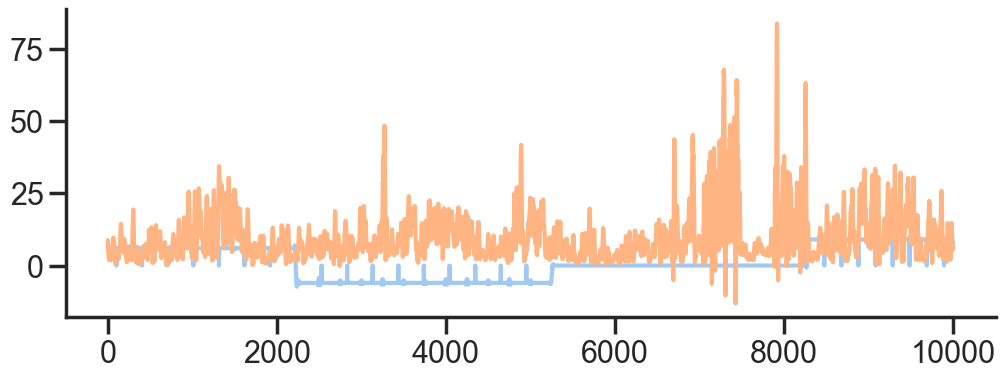

In [28]:
f, ax = plt.subplots(figsize = (12, 4))
plt.plot(ang_vel[:10000]/10)
plt.plot(lin_speed[:10000])

In [31]:
df_beh.cond.unique()

array(['D1', 'L1', 'TS6-HF', 'TS7-HF', 'TS6-VIS', 'TS7-VIS', 'TS6-MR',
       'TS7-MR', 'TS6-OVAR10', 'TS6-OVAR20', 'TS6-OVAR20BALLDIS'],
      dtype=object)

(0.0, 1.1)

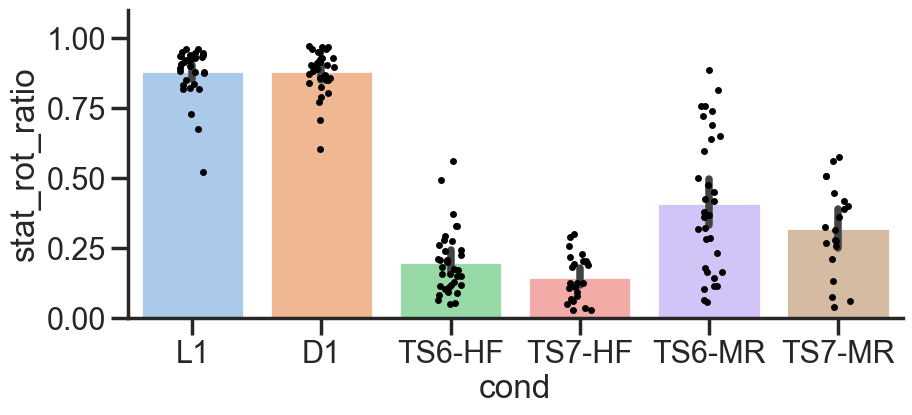

In [40]:
f, ax = plt.subplots(figsize = (10, 4))
coi = [ 'L1', 'D1', 'TS6-HF', 'TS7-HF', 'TS6-MR', 'TS7-MR']
y = 'stat_rot_ratio'
_inp_plot = df_beh[df_beh.cond.isin(coi)]

sns.stripplot(data = _inp_plot, x = 'cond', y = y, color = 'k')
sns.barplot(data = _inp_plot, x = 'cond', y = y, order = coi)

plt.ylim(0, 1.1)
# plt.savefig(f'bar_{y}_{coi}.pdf', transparent = True)


In [277]:
a1 = _inp_plot[_inp_plot.cond == coi[0]][y].values
b1 = _inp_plot[_inp_plot.cond == coi[1]][y].values
c1 = _inp_plot[_inp_plot.cond == coi[2]][y].values

print(a1.size, b1.size, c1.size)

print(stats.kruskal(a1, b1, c1))

34 34 35
KruskalResult(statistic=19.477715001168896, pvalue=5.894784426128799e-05)


In [42]:
df_tuning.head_fixation.unique()

array(['na', 'HF', 'MR', 'RPLCOMB', 'RPLVIS', 'RPLVEST', 'OVAR10',
       'OVAR20', 'HFLMK', 'HFLMK180', 'RPL', 'VIS', 'VEST', 'HFLMKDoR',
       'OVAR20BALLDIS', 'RPLCOMBBALLDIS', 'HFLMK30', 'LMK30'],
      dtype=object)

### Percentage of HD cells

In [49]:
df_hist_master['rec_session'] = df_hist_master['mouse_id'] + '_' + df_hist_master['dts']

In [90]:
ls = []
for rec in good_rec_sessions:
    
    tmp_hist = df_hist_master[(df_hist_master.rec_session == rec) &  (df_hist_master.group != 'noise')]
    imp = tmp_hist['mouse_id'].values[0] + '_' + tmp_hist['hem'].values[0]
    try:
        sh_ls = d_good_shanks[imp]
    except:
        print(rec)
        continue
    # sh_ls = [0, 1, 2, 3]
    tmp_rec = tmp_hist[tmp_hist.shank.isin(sh_ls)]
    n_hdc = tmp_rec[tmp_rec['hdc'] == 1].shape[0]
    n_all = tmp_rec.shape[0]
    pct_hdc = round(n_hdc/n_all*100)
    tmp_df = pd.DataFrame({'rec_session': rec, 'sh':[sh_ls], 'n_hdc':n_hdc, 'n_all':n_all, 'pct_hdc':pct_hdc}, index = [0])
    ls.append(tmp_df)
df_pcthdc = pd.concat(ls)
df_pcthdc.head()

MC036_20220727
MC036_20220728
JA179_20220811


,rec_session,sh,n_hdc,n_all,pct_hdc
0,MC022_20220627,"[1, 2]",26,77,34
0,MC022_20220628,"[1, 2]",25,69,36
0,MC022_20220629,"[1, 2]",20,52,38
0,MC022_20220718,"[1, 2]",37,91,41
0,JA179_20220802,"[2, 3]",19,80,24


In [105]:
df_pcthdc.describe()

,n_hdc,n_all,pct_hdc
count,25.000000,25.000000,25.000000
mean,21.200000,49.560000,48.080000
std,8.416254,21.621902,21.418294
min,9.000000,14.000000,22.000000
25%,13.000000,31.000000,35.000000
50%,21.000000,51.000000,41.000000
75%,26.000000,64.000000,60.000000
max,37.000000,91.000000,93.000000


In [68]:
n_hdc, n_all

(20, 34)

### Tuning analysis

In [1369]:
ls_tuning = []

for k in d_data.keys():
    if k in df_tuning.rec_id.unique():
        continue
        
    tmp_ephys =  d_data[k]['ephys']
    tmp_unity = d_data[k]['unity']
    
    try:
        rec_id = tmp_ephys.iloc[0]['rec_id']
    except Eception as e:
        print(e)
        continue
    dts = tmp_ephys.iloc[0]['dts']
    mouse_id = tmp_ephys.iloc[0]['mouse_id']
#     rec_target = tmp_ephys.iloc[0]['rec_target']
    probe_conf = tmp_ephys.iloc[0]['probe_conf']
    vr_env = tmp_ephys.iloc[0]['vr_env']
    head_fixation = tmp_ephys.iloc[0]['head_fixation']
    
    if 'HF' in head_fixation:
        yaw = tmp_unity.head_dir.values
    elif 'L1' in vr_env or 'D1' in vr_env:
        yaw = tmp_unity.hd.values
    else:
        yaw = tmp_unity.RotY.values
    print(k, yaw.size)
    # yaw = df_unity_aln.RotY.values
    # print(yaw_light.size, yaw_dark.size)

    for unit in sorted(tmp_ephys.cids.unique()):
#         print(unit)
        tmp_fr = tmp_ephys[tmp_ephys.cids == unit].iloc[:yaw.size]
#         tmp_fx = tmp_ephys_fx[tmp_ephys_fx.cids == unit].iloc[:yaw_fx.size]
        cuid = tmp_fr.cuid.values[0]
    
        r_fr, hd_tuning_fr, p_val_fr = bin_tuning_permute(yaw[:], tmp_fr.hz.values)
#         r_fx, hd_tuning_fx, p_val_fx = bin_tuning_permute(yaw_fx[:], tmp_fx.hz.values)

        angles = hd_tuning_fr[0]
        a = np.deg2rad(angles)

        fr_fr = hd_tuning_fr[1]
#         fr_fx = hd_tuning_fx[1]

#         print (f'unit # {unit} free: r {r_fr:.4} p {p_val_fr}')
#         print (f'unit # {unit} fixed: r {r_fx:.4} p {p_val_fx}')

        fr_fr = np.append(fr_fr, fr_fr[0])
#         fr_fx = np.append(fr_fx, fr_fx[0])
        a = np.append(a, a[0])
    #     ax = plt.subplot(111, projection='polar')
    #         ax.set_theta_zero_location("N")
    #         ax.set_theta_direction(-1)
    #     ax.plot(a, fr_fr, label = 'head free', c = 'magenta')
    #     ax.plot(a, fr_fx, label = 'head fixed', c = 'cyan')
    #     ax.legend(loc='best', bbox_to_anchor=(1.5, 0.5, 0.5, 0.5))
    #     plt.show()
        ls_tuning.append(pd.DataFrame({'hz': fr_fr[:-1], 'dir': angles, 'cids':unit, 'mouse_id': mouse_id,
                                       'r': r_fr, 'p_val': p_val_fr, 'rec_id': rec_id, 'dts': dts, 'probe_conf':probe_conf,
                                        'vr_env':vr_env, 'head_fixation': head_fixation, 'cuid':cuid        }))
    

df_tuning2 = pd.concat(ls_tuning)
df_tuning2.head()

20220902_JA178_rADN_yel_H2_R_D1 23250
20220902_JA178_rADN_yel_H2_R_L1 23250
20220902_JA178_rADN_yel_H2_VR1_TS6-HF 55000
20220902_JA178_rADN_yel_H2_VR1_TS6-MR 55000
20220902_JA178_rADN_yel_H2_VR1_TS6-OVAR10 26750
20220902_JA178_rADN_yel_H2_VR1_TS6-OVAR20BALLDIS 26750
20220902_JA178_rADN_yel_H2_VR1_TS6-RPLCOMB 43750
20220902_JA178_rADN_yel_H2_VR1_TS6-RPLCOMBBALLDIS 54000
20220902_JA178_rADN_yel_H2_VR1_TS6-RPLVEST 55000
20220902_JA178_rADN_yel_H2_VR1_TS6-RPLVIS 55000
20220902_JA178_rADN_yel_H2_VR1_TS7-HF 55000
20220902_JA178_rADN_yel_H2_VR1_TS7-MR 55000
20220906_JA178_rADN_yel_H2_R_D1 23250
20220906_JA178_rADN_yel_H2_R_L1 23250
20220906_JA178_rADN_yel_H2_VR1_TS6-HF 27750
20220906_JA178_rADN_yel_H2_VR1_TS6-MR 27750
20220906_JA178_rADN_yel_H2_VR1_TS6-OVAR10 26500
20220906_JA178_rADN_yel_H2_VR1_TS6-RPLCOMB 40500
20220906_JA178_rADN_yel_H2_VR1_TS6-RPLVEST 36500
20220906_JA178_rADN_yel_H2_VR1_TS6-RPLVIS 54000
20220907_JA178_rADN_yel_H2_R_D1 23250
20220907_JA178_rADN_yel_H2_R_L1 23250
20220907_

,hz,dir,cids,mouse_id,r,p_val,rec_id,dts,probe_conf,vr_env,head_fixation,cuid
0,0.184910,0.0,1.0,JA178,0.043,0.909,20220902_JA178_rADN_yel_H2_R_D1,20220902,H2,D1,na,1-JA178-rADN-0902-D1na
1,0.150927,20.0,1.0,JA178,0.043,0.909,20220902_JA178_rADN_yel_H2_R_D1,20220902,H2,D1,na,1-JA178-rADN-0902-D1na
2,0.132340,40.0,1.0,JA178,0.043,0.909,20220902_JA178_rADN_yel_H2_R_D1,20220902,H2,D1,na,1-JA178-rADN-0902-D1na
3,0.097449,60.0,1.0,JA178,0.043,0.909,20220902_JA178_rADN_yel_H2_R_D1,20220902,H2,D1,na,1-JA178-rADN-0902-D1na
4,0.103833,80.0,1.0,JA178,0.043,0.909,20220902_JA178_rADN_yel_H2_R_D1,20220902,H2,D1,na,1-JA178-rADN-0902-D1na


In [1370]:
df_tuning2.shape

(75780, 12)

In [1373]:
df_tun = pd.concat([df_tuning, df_tuning2])

In [1374]:
# df_tun.to_pickle("Tuning_adn_v2.pkl")  

### Tuning L1_1 vs L1_2 stability

In [22]:
df_tuning.head()

,hz,dir,cids,mouse_id,r,p_val,rec_id,dts,probe_conf,vr_env,head_fixation,cuid
0,19.374491,0.0,1.0,JA178,0.492617,0.003,20220818_JA178_lADN_red_H2_R_D1,20220818,H2,D1,na,1-JA178-lADN-0818-D1na
1,8.332602,20.0,1.0,JA178,0.492617,0.003,20220818_JA178_lADN_red_H2_R_D1,20220818,H2,D1,na,1-JA178-lADN-0818-D1na
2,3.224077,40.0,1.0,JA178,0.492617,0.003,20220818_JA178_lADN_red_H2_R_D1,20220818,H2,D1,na,1-JA178-lADN-0818-D1na
3,3.784274,60.0,1.0,JA178,0.492617,0.003,20220818_JA178_lADN_red_H2_R_D1,20220818,H2,D1,na,1-JA178-lADN-0818-D1na
4,3.191489,80.0,1.0,JA178,0.492617,0.003,20220818_JA178_lADN_red_H2_R_D1,20220818,H2,D1,na,1-JA178-lADN-0818-D1na


In [26]:
ls_tuning = []
_inp_data = df_tuning[(df_tuning.vr_env == 'L1') & (df_tuning.dir == 0)
         & (df_tuning.r > 0.3) & (df_tuning.p_val < 0.05)]

for k in _inp_data.rec_id.unique():
    print(k)
    dts, mouse_id, hem, probe, cond, rec_session = get_recinfo_fname(k)
    try:
        tmp_ephys =  d_master[k]['ephys']
        tmp_unity = d_master[k]['unity']
    except:
        continue
        
    yaw, lin_speed_sm = get_yaw_speed_rec(k, d_master)
    tmp_data = _inp_data[_inp_data.rec_id == k]
    units_in = tmp_data.cids.unique()
    
    for unit in sorted(units_in):
#         print(unit)
        tmp_fr = tmp_ephys[tmp_ephys.cids == unit].iloc[:yaw.size//2]
        r_fr, hd_tuning_fr, p_val_fr = bin_tuning_permute(yaw[:yaw.size//2], tmp_fr.hz.values)
        cuid = tmp_fr.cuid.values[0]
        angles = hd_tuning_fr[0]
        a = np.deg2rad(angles)
        fr_fr = hd_tuning_fr[1]
        if fr_fr.max() < 1:
            continue
    
        ls_tuning.append(pd.DataFrame({'hz': fr_fr, 'dir': angles, 'cids':unit, 'mouse_id': mouse_id,
                                       'r': r_fr, 'p_val': p_val_fr, 'rec_id': k, 'dts': dts, 
                                        'cuid':cuid, 'hem':hem, 'cond': cond + '_1', 'rec_session':rec_session}))
        
        # second half of the recording
        tmp_fr = tmp_ephys[tmp_ephys.cids == unit].iloc[yaw.size//2:yaw.size]
        r_fr, hd_tuning_fr, p_val_fr = bin_tuning_permute(yaw[yaw.size//2:], tmp_fr.hz.values)

        angles = hd_tuning_fr[0]
        a = np.deg2rad(angles)
        fr_fr = hd_tuning_fr[1]
        if fr_fr.max() < 1:
            continue
        ls_tuning.append(pd.DataFrame({'hz': fr_fr, 'dir': angles, 'cids':unit, 'mouse_id': mouse_id,
                                       'r': r_fr, 'p_val': p_val_fr, 'rec_id': k, 'dts': dts, 
                                        'cuid':cuid, 'hem':hem, 'cond': cond + '_2', 'rec_session':rec_session}))
#         fr_fr = np.append(fr_fr, fr_fr[0])
#         a = np.append(a, a[0])
    #     ax = plt.subplot(111, projection='polar')
    #         ax.set_theta_zero_location("N")
    #         ax.set_theta_direction(-1)
    #     ax.plot(a, fr_fr, label = 'head free', c = 'magenta')
    #     ax.plot(a, fr_fx, label = 'head fixed', c = 'cyan')
    #     ax.legend(loc='best', bbox_to_anchor=(1.5, 0.5, 0.5, 0.5))
    #     plt.show()


df_tun_l2 = pd.concat(ls_tuning)
df_tun_l2.head()

20220818_JA178_lADN_red_H2_R_L1
20220819_JA178_lADN_red_H2_R_L1
20220823_JA178_lADN_red_H2_R_L1
20220824_JA178_lADN_red_H2_R_L1
20220802_JA179_lADN_red_H2_VR1_L1
20220803_JA179_lADN_red_H2_VR1_L1
20220804_JA179_lADN_red_H2_VR1_L1
20220805_JA179_lADN_red_H2_VR1_L1
20220811_JA179_rADN_yel_H1_VR1_L1
20220812_JA179_rADN_yel_H1_VR1_L1
20220815_JA179_rADN_yel_H1_R_L1
20220809_JA180_lADN_red_H2_VR1_L1
20220810_JA180_lADN_red_H2_VR1_L1
20220811_JA180_lADN_red_H2_VR1_L1
20220819_JA180_lADN_red_H2_R_L1
20220809_JA181_lADN_red_H2_VR1_L1
20220810_JA181_lADN_red_H2_VR1_L1
20220812_JA181_lADN_red_H2_VR1_L1
20220817_JA181_lADN_red_H2_R_L1
20220627_MC022_lADN_red_H2_R_L1
20220628_MC022_lADN_red_H2_R_L1
20220629_MC022_lADN_red_H2_R_L1
20220715_MC022_lADN_red_H2_VR1_L1
20220718_MC022_lADN_red_H2_VR1_L1
20220720_MC022_rADN_yellow_H2_VR1_L1
20220721_MC022_rADN_yellow_H2_VR1_L1
20220722_MC022_rADN_yellow_H2_VR1_L1
20220727_MC036_lADN_red_H1_VR1_L1
20220728_MC036_lADN_red_H1_VR1_L1
20220729_MC036_lADN_red_H

,hz,dir,cids,mouse_id,r,p_val,rec_id,dts,cuid,hem,cond,rec_session
0,22.476359,0.0,1.0,JA178,0.484799,0.003,20220818_JA178_lADN_red_H2_R_L1,20220818,1-JA178-lADN-0818-L1na,lADN,L1_1,JA178_20220818
1,20.887789,20.0,1.0,JA178,0.484799,0.003,20220818_JA178_lADN_red_H2_R_L1,20220818,1-JA178-lADN-0818-L1na,lADN,L1_1,JA178_20220818
2,11.837895,40.0,1.0,JA178,0.484799,0.003,20220818_JA178_lADN_red_H2_R_L1,20220818,1-JA178-lADN-0818-L1na,lADN,L1_1,JA178_20220818
3,17.025381,60.0,1.0,JA178,0.484799,0.003,20220818_JA178_lADN_red_H2_R_L1,20220818,1-JA178-lADN-0818-L1na,lADN,L1_1,JA178_20220818
4,14.682746,80.0,1.0,JA178,0.484799,0.003,20220818_JA178_lADN_red_H2_R_L1,20220818,1-JA178-lADN-0818-L1na,lADN,L1_1,JA178_20220818


In [28]:
# df_tun_l2.to_pickle('df_tun_l2.pkl')

In [390]:
_inp_data.head()

,hz,dir,cids,mouse_id,r,p_val,rec_id,dts,probe_conf,vr_env,head_fixation,cuid,rec_session,rec_unit,cond
0,22.679726,0.0,1.0,JA178,0.464655,0.0,20220818_JA178_lADN_red_H2_R_L1,20220818,H2,L1,na,1-JA178-lADN-0818-L1na,JA178_20220818,JA178_20220818_1.0,L1
0,47.115573,0.0,4.0,JA178,0.415890,0.0,20220818_JA178_lADN_red_H2_R_L1,20220818,H2,L1,na,4-JA178-lADN-0818-L1na,JA178_20220818,JA178_20220818_4.0,L1
0,5.381978,0.0,7.0,JA178,0.528289,0.0,20220818_JA178_lADN_red_H2_R_L1,20220818,H2,L1,na,7-JA178-lADN-0818-L1na,JA178_20220818,JA178_20220818_7.0,L1
0,11.504407,0.0,8.0,JA178,0.549565,0.0,20220818_JA178_lADN_red_H2_R_L1,20220818,H2,L1,na,8-JA178-lADN-0818-L1na,JA178_20220818,JA178_20220818_8.0,L1
0,0.900098,0.0,9.0,JA178,0.630475,0.0,20220818_JA178_lADN_red_H2_R_L1,20220818,H2,L1,na,9-JA178-lADN-0818-L1na,JA178_20220818,JA178_20220818_9.0,L1


In [27]:
df_tuning.head()

,hz,dir,cids,mouse_id,r,p_val,rec_id,dts,probe_conf,vr_env,head_fixation,cuid
0,19.374491,0.0,1.0,JA178,0.492617,0.003,20220818_JA178_lADN_red_H2_R_D1,20220818,H2,D1,na,1-JA178-lADN-0818-D1na
1,8.332602,20.0,1.0,JA178,0.492617,0.003,20220818_JA178_lADN_red_H2_R_D1,20220818,H2,D1,na,1-JA178-lADN-0818-D1na
2,3.224077,40.0,1.0,JA178,0.492617,0.003,20220818_JA178_lADN_red_H2_R_D1,20220818,H2,D1,na,1-JA178-lADN-0818-D1na
3,3.784274,60.0,1.0,JA178,0.492617,0.003,20220818_JA178_lADN_red_H2_R_D1,20220818,H2,D1,na,1-JA178-lADN-0818-D1na
4,3.191489,80.0,1.0,JA178,0.492617,0.003,20220818_JA178_lADN_red_H2_R_D1,20220818,H2,D1,na,1-JA178-lADN-0818-D1na


### Tuning stat vs run

In [49]:
ls_tuning = []
sr = 50
_inp_data = df_tuning[((df_tuning.head_fixation == 'MR'))
         & (df_tuning.dir == 0)
         & (df_tuning.r > 0.3) 
         & (df_tuning.p_val < 0.05)]

speed_thr = 5

for k in _inp_data.rec_id.unique():
    print(k)
    dts, mouse_id, hem, probe, cond, rec_session = get_recinfo_fname(k)
    try:
        tmp_ephys =  d_master[k]['ephys']
        tmp_unity = d_master[k]['unity']
    except:
        print('no data')
        continue
    
    yaw_sm, lin_speed_sm = get_yaw_speed_rec(k, d_master)
    ang_vel = cyclic_difference(yaw_sm)*sr
    ang_vel_sm = medfilt(ang_vel,  kernel_size=3)
    ang_vel_sm = np.concatenate((ang_vel_sm, [ang_vel_sm[-1]]))
    
#     dYaw = compute_dYaw(yaw_sm)
    # convert to deg/s, 50 HZ sampling rate
    tmp_data = _inp_data[_inp_data.rec_id == k]
    units_in = tmp_data.cids.unique()
    
    if 'MR' in k or 'VIS' in k or 'RPL' in k or 'OVAR' in k:
        stat_idx, run_idx = get_stat_run_epochs(ang_vel_sm, window_size=25, speed_thr = 7)
    else:
        stat_idx, run_idx = get_stat_run_epochs(lin_speed_sm, window_size=25, speed_thr = speed_thr)
    print(stat_idx.size, run_idx.size)
    
    for unit in sorted(units_in):
#         print(unit)
        tmp_fr = tmp_ephys[tmp_ephys.cids == unit].iloc[stat_idx]
        r_fr, hd_tuning_fr, p_val_fr = bin_tuning_permute(yaw_sm[stat_idx], tmp_fr.hz.values)
        cuid = tmp_fr.cuid.values[0]
        angles = hd_tuning_fr[0]
        a = np.deg2rad(angles)
        fr_fr = hd_tuning_fr[1]
        if fr_fr.max() < 1:
            continue
    
        ls_tuning.append(pd.DataFrame({'hz': fr_fr, 'dir': angles, 'cids':unit, 'mouse_id': mouse_id,
                                       'r': r_fr, 'p_val': p_val_fr, 'rec_id': k, 'dts': dts, 'run':'stat',
                                        'cuid':cuid, 'hem':hem, 'cond': cond, 'rec_session':rec_session}))
        
        # second half of the recording
        tmp_fr = tmp_ephys[tmp_ephys.cids == unit].iloc[run_idx]
        r_fr, hd_tuning_fr, p_val_fr = bin_tuning_permute(yaw_sm[run_idx], tmp_fr.hz.values)

        angles = hd_tuning_fr[0]
        a = np.deg2rad(angles)
        fr_fr = hd_tuning_fr[1]
        if fr_fr.max() < 1:
            continue
        ls_tuning.append(pd.DataFrame({'hz': fr_fr, 'dir': angles, 'cids':unit, 'mouse_id': mouse_id,
                                       'r': r_fr, 'p_val': p_val_fr, 'rec_id': k, 'dts': dts, 'run':'locom',
                                        'cuid':cuid, 'hem':hem, 'cond': cond , 'rec_session':rec_session}))
#         fr_fr = np.append(fr_fr, fr_fr[0])
#         a = np.append(a, a[0])
    #     ax = plt.subplot(111, projection='polar')
    #         ax.set_theta_zero_location("N")
    #         ax.set_theta_direction(-1)
    #     ax.plot(a, fr_fr, label = 'head free', c = 'magenta')
    #     ax.plot(a, fr_fx, label = 'head fixed', c = 'cyan')
    #     ax.legend(loc='best', bbox_to_anchor=(1.5, 0.5, 0.5, 0.5))
    #     plt.show()
    

df_tun_rot = pd.concat(ls_tuning)
df_tun_rot.head()

20220818_JA178_lADN_red_H2_VR1_TS6-MR
40140 14840
20220818_JA178_lADN_red_H2_VR1_TS7-MR
38090 16890
20220819_JA178_lADN_red_H2_VR1_TS6-MR
18040 8690
20220819_JA178_lADN_red_H2_VR1_TS7-MR
19240 7490
20220823_JA178_lADN_red_H2_VR1_TS6-MR
32440 19040
20220824_JA178_lADN_red_H2_VR1_TS6-MR
21840 28140
20220802_JA179_lADN_red_H2_VR1_TS6-MR
18765 35215
20220802_JA179_lADN_red_H2_VR1_TS7-MR
35815 19165
20220803_JA179_lADN_red_H2_VR1_TS6-MR
23640 31340
20220803_JA179_lADN_red_H2_VR1_TS7-MR
28815 26165
20220804_JA179_lADN_red_H2_VR1_TS7-MR
34790 13940
20220805_JA179_lADN_red_H2_VR1_TS6-MR
35590 19390
20220805_JA179_lADN_red_H2_VR1_TS7-MR
41415 13565
20220811_JA179_rADN_yel_H1_VR1_TS6-MR
38840 16140
20220812_JA179_rADN_yel_H1_VR1_TS6-MR
no data
20220809_JA180_lADN_red_H2_VR1_TS6-MR
38615 16365
20220809_JA180_lADN_red_H2_VR1_TS7-MR
50365 4615
20220810_JA180_lADN_red_H2_VR1_TS6-MR
47215 7765
20220810_JA180_lADN_red_H2_VR1_TS7-MR
42965 3765
20220811_JA180_lADN_red_H2_VR1_TS6-MR
50115 4865
20220811_J

C:\Users\lab\AppData\Local\Temp\ipykernel_5896\3503049561.py:45: RuntimeWarning: invalid value encountered in double_scalars
  r = abs(r)/np.nansum(fr)


20220830_MC038_lADN_red_H2_VR1_TS6-MR
45765 9215
20220831_MC038_lADN_red_H2_VR1_TS6-MR
49915 5065
20220902_JA178_rADN_yel_H2_VR1_TS6-MR
31040 23940
20220902_JA178_rADN_yel_H2_VR1_TS7-MR
39390 15590
20220906_JA178_rADN_yel_H2_VR1_TS6-MR
19065 8665
20220907_JA178_rADN_yel_H2_VR1_TS6-MR
19315 7915
20220908_JA178_rADN_yel_H2_VR1_TS6-MR
13190 14290
20220909_JA178_rADN_yel_H2_VR1_TS6-MR
19065 9165


,hz,dir,cids,mouse_id,r,p_val,rec_id,dts,run,cuid,hem,cond,rec_session
0,11.002372,0.0,1.0,JA178,0.470621,0.001,20220818_JA178_lADN_red_H2_VR1_TS6-MR,20220818,stat,1-JA178-lADN-0818-TS6MR,lADN,TS6-MR,JA178_20220818
1,14.928791,20.0,1.0,JA178,0.470621,0.001,20220818_JA178_lADN_red_H2_VR1_TS6-MR,20220818,stat,1-JA178-lADN-0818-TS6MR,lADN,TS6-MR,JA178_20220818
2,7.377898,40.0,1.0,JA178,0.470621,0.001,20220818_JA178_lADN_red_H2_VR1_TS6-MR,20220818,stat,1-JA178-lADN-0818-TS6MR,lADN,TS6-MR,JA178_20220818
3,5.777660,60.0,1.0,JA178,0.470621,0.001,20220818_JA178_lADN_red_H2_VR1_TS6-MR,20220818,stat,1-JA178-lADN-0818-TS6MR,lADN,TS6-MR,JA178_20220818
4,6.419806,80.0,1.0,JA178,0.470621,0.001,20220818_JA178_lADN_red_H2_VR1_TS6-MR,20220818,stat,1-JA178-lADN-0818-TS6MR,lADN,TS6-MR,JA178_20220818


In [50]:
df_tun_rot['cond'] = df_tun_rot.cond.str.split('_', expand = True)[0]
df_tun_run['cond_run'] = df_tun_run['cond'] + '_' + df_tun_run['run']

In [56]:
df_tun_loc = pd.concat([df_tun_run, df_tun_rot])

In [59]:
# df_tun_loc.to_pickle('df_tun_loc.pkl')

In [22]:
df_tuning[df_tuning['vr_env'] == 'DARK']

,hz,dir,cids,mouse_id,r,p_val,rec_id,dts,probe_conf,vr_env,head_fixation,cuid
0,6.308068,0.0,0.0,MC022,0.180091,0.682,20220706_MC022_lADN_red_H2_VR1_DARK-VEST,20220706,H2,DARK,VEST,0-MC022-lADN-0706-DARKVEST
1,3.956404,20.0,0.0,MC022,0.180091,0.682,20220706_MC022_lADN_red_H2_VR1_DARK-VEST,20220706,H2,DARK,VEST,0-MC022-lADN-0706-DARKVEST
2,3.084733,40.0,0.0,MC022,0.180091,0.682,20220706_MC022_lADN_red_H2_VR1_DARK-VEST,20220706,H2,DARK,VEST,0-MC022-lADN-0706-DARKVEST
3,2.611943,60.0,0.0,MC022,0.180091,0.682,20220706_MC022_lADN_red_H2_VR1_DARK-VEST,20220706,H2,DARK,VEST,0-MC022-lADN-0706-DARKVEST
4,2.454448,80.0,0.0,MC022,0.180091,0.682,20220706_MC022_lADN_red_H2_VR1_DARK-VEST,20220706,H2,DARK,VEST,0-MC022-lADN-0706-DARKVEST
...,...,...,...,...,...,...,...,...,...,...,...,...
13,2.269419,260.0,84.0,MC022,0.032655,0.342,20220706_MC022_lADN_red_H2_VR1_DARK-VEST,20220706,H2,DARK,VEST,84-MC022-lADN-0706-DARKVEST
14,1.820267,280.0,84.0,MC022,0.032655,0.342,20220706_MC022_lADN_red_H2_VR1_DARK-VEST,20220706,H2,DARK,VEST,84-MC022-lADN-0706-DARKVEST
15,2.220715,300.0,84.0,MC022,0.032655,0.342,20220706_MC022_lADN_red_H2_VR1_DARK-VEST,20220706,H2,DARK,VEST,84-MC022-lADN-0706-DARKVEST
16,2.336524,320.0,84.0,MC022,0.032655,0.342,20220706_MC022_lADN_red_H2_VR1_DARK-VEST,20220706,H2,DARK,VEST,84-MC022-lADN-0706-DARKVEST


### Select sessions with both R and VR

In [30]:
df_tuning.loc[:, 'rec_session'] = df_tuning.mouse_id + '_' + df_tuning.dts
df_tuning['rec_unit'] = df_tuning['rec_session'] + '_' + df_tuning['cids'].astype(str)
df_tuning['cond'] = df_tuning.rec_id.str.split('_', expand = True)[6]

df_tun_proc = df_tuning[df_tuning.rec_session.isin(good_rec_shanks)]
# df_tun_proc = df_tuning.copy()

conditions = [(df_tun_proc.r > 0.3) & (df_tun_proc.p_val < 0.05),
              (df_tun_proc.r < 0.3) & (df_tun_proc.p_val > 0.05)
                        ]
values = [1, 0]
df_tun_proc['hdc'] = np.select(conditions, values)

unit_in = df_tun_proc.groupby('cuid').hz.max().reset_index()
unit_in = unit_in[unit_in.hz > 1].cuid.unique()
df_tun_proc = df_tun_proc[(df_tun_proc.cuid.isin(unit_in))]

# out = df_tun_proc.groupby(['cuid']).hz.apply(hd_tuning_width)
# df_tun_proc.loc[:, 'tun_width'] = df_tun_proc.cuid.map(out.to_dict())
df_tun_proc.loc[:, 'implant'] = df_tun_proc.rec_id.str.split('_', expand = True)[1] + '_' + df_tun_proc.rec_id.str.split('_', expand = True)[2]
# DLC script returns clockwise he angles
df_tun_proc.loc[:, 'dir_adj'] = df_tun_proc.dir.values*-1+340

# d_peak_fr = df_tun_proc.groupby('cuid').hz.max().to_dict()
# d_prefdir = df_tun_proc.groupby('cuid').hz.idxmax().to_dict()

# df_tun_proc['peak_fr'] = df_tun_proc.cuid.map(d_peak_fr)
# df_tun_proc['pref_dir'] = df_tun_proc.cuid.map(d_prefdir)

C:\Users\01\AppData\Local\Temp\ipykernel_24860\1128296240.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tun_proc['hdc'] = np.select(conditions, values)


### HD units in R vs VR, delta pref dir

In [96]:
df_tun_proc.head()

,hz,dir,cids,mouse_id,r,p_val,rec_id,dts,probe_conf,vr_env,head_fixation,cuid,rec_session,rec_unit,cond,hdc,implant,dir_adj
0,19.374491,0.0,1.0,JA178,0.492617,0.003,20220818_JA178_lADN_red_H2_R_D1,20220818,H2,D1,na,1-JA178-lADN-0818-D1na,JA178_20220818,JA178_20220818_1.0,D1,1,JA178_lADN,340.0
1,8.332602,20.0,1.0,JA178,0.492617,0.003,20220818_JA178_lADN_red_H2_R_D1,20220818,H2,D1,na,1-JA178-lADN-0818-D1na,JA178_20220818,JA178_20220818_1.0,D1,1,JA178_lADN,320.0
2,3.224077,40.0,1.0,JA178,0.492617,0.003,20220818_JA178_lADN_red_H2_R_D1,20220818,H2,D1,na,1-JA178-lADN-0818-D1na,JA178_20220818,JA178_20220818_1.0,D1,1,JA178_lADN,300.0
3,3.784274,60.0,1.0,JA178,0.492617,0.003,20220818_JA178_lADN_red_H2_R_D1,20220818,H2,D1,na,1-JA178-lADN-0818-D1na,JA178_20220818,JA178_20220818_1.0,D1,1,JA178_lADN,280.0
4,3.191489,80.0,1.0,JA178,0.492617,0.003,20220818_JA178_lADN_red_H2_R_D1,20220818,H2,D1,na,1-JA178-lADN-0818-D1na,JA178_20220818,JA178_20220818_1.0,D1,1,JA178_lADN,260.0


In [104]:
df_tun_proc[(df_tun_proc.cond == 'L1') & (df_tun_proc.hdc == 1)]['rec_unit'].unique().size

541

In [131]:
d_L1comm_sess = {}

In [27]:
cond_ls = ['L1', 'D1', 'TS7-HF']
data = df_tun_proc
_inp = data[(data.dir == 0)
#             & (df_tun_proc.rec_id.isin(vis_rec_id))
            & (data.hdc > 0)
            & ((data.cond.isin(cond_ls)))
            ].groupby([ 'cond', 'rec_session']).cids.apply(list).reset_index()

In [29]:
_inp.head()

,cond,rec_session,cids
0,D1,JA178_20220818,"[1.0, 4.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13..."
1,D1,JA178_20220819,"[0.0, 2.0, 3.0, 5.0, 6.0, 9.0, 10.0, 12.0, 13...."
2,D1,JA178_20220823,"[8.0, 9.0, 10.0, 11.0, 14.0, 16.0, 20.0, 22.0,..."
3,D1,JA178_20220906,"[8.0, 13.0, 14.0, 15.0, 30.0, 32.0, 33.0, 34.0..."
4,D1,JA178_20220907,"[24.0, 49.0, 52.0, 53.0, 54.0, 55.0, 57.0, 58...."


In [30]:
for rec in _inp[_inp.cond == 'TS7-HF'].rec_session.unique():
    
    tmp = _inp[_inp.rec_session == rec]
    break

In [47]:
a1 = tmp[tmp.cond == 'L1']['cids'].values[0]
a2 = tmp[tmp.cond == 'D1']['cids'].values[0]
a3 = tmp[tmp.cond == 'TS7-HF']['cids'].values[0]

In [174]:
def categorize_numbers(a, b, c):
    # Convert to sets for efficient operations
    set_a, set_b, set_c = set(a), set(b), set(c)
    
    # Find numbers in each combination
    all_three = set_a & set_b & set_c
    
    only_a = set_a - set_b - set_c
    only_b = set_b - set_a - set_c
    only_c = set_c - set_a - set_b
    
    a_and_b = (set_a & set_b) - set_c
    b_and_c = (set_b & set_c) - set_a
    a_and_c = (set_a & set_c) - set_b
    
    # Also get all unique numbers for reference
    all_numbers = set_a | set_b | set_c
    
    return {
        'all': sorted(all_three),
        'l1_only': sorted(only_a),
        'd1_only': sorted(only_b),
        'vr_only': sorted(only_c),
        'a1_vr': sorted(a_and_b),
        'd1-vr': sorted(b_and_c),
        'l1_d1': sorted(a_and_c),
        # 'all_unique': sorted(all_numbers)  # Optional
    }

# Example usage
a = [1, 2, 3, 4, 5]
b = [4, 5, 6, 7, 8]
c = [5, 8, 9, 10, 11]

result = categorize_numbers(a, b, c)

# Print results
for category, numbers in result.items():
    print(f"{category}: {numbers}")

all: [5]
l1_only: [1, 2, 3]
d1_only: [6, 7]
vr_only: [9, 10, 11]
a1_vr: [4]
d1-vr: [8]
l1_d1: []


In [132]:
cond1 = 'L1'
cond2 = 'TS7'
# vis_rec_sess = df_tun_proc[(df_tun_proc.head_fixation == 'VIS') & (df_tun_proc.dir == 0)].rec_session.unique()
ls_n1, ls_n2, ls_n3 = [], [], []
ls_df = []
vr_com_sess = []
d_L1comm_sess[cond2] = {}

data = df_tun_proc
_inp = data[(data.dir == 0)
#             & (df_tun_proc.rec_id.isin(vis_rec_id))
            & (data.hdc > 0)
            & ((data.cond == cond1) | (data.cond == cond2))
            ].groupby([ 'cond', 'rec_session']).cids.apply(list).reset_index()
# _inp = data[data.dir == 0].groupby([ 'cond', 'rec_session']).cids.apply(list).reset_index()

for rec in _inp.rec_session.unique()[:]:
    
    tmp = _inp[_inp.rec_session == rec]

    if tmp.shape[0] < 2:
        print(rec)
        continue
    ar1, ar2 = np.empty(0), np.empty(0)
    comval = np.empty(0)
    

    
    try:
        ar1 = np.array(tmp[tmp.cond.str.contains(cond1)].cids.values[0])
    except:
        print(f'no hdc - {cond1}, {rec}' )
        
        
    try:
        ar2 = np.array(tmp[tmp.cond.str.contains(cond2)].cids.values[0])
    except:
        print(f'no hdc - {cond2}, {rec}' )
        
        
    
    # common units
    comval = np.intersect1d(ar1, ar2)
    
    pref_l1 = data[(data.rec_session == rec) 
            & (data.cond == cond1) 
            & (data.cids.isin(comval))
           ].groupby(['cids']).hz.idxmax().values*20
    # arena az is ccw, so reverse
#     pref_l1 = pref_l1*(-1) + 340
    
    pref_ts6 = data[(data.rec_session == rec) 
            & (data.cond == cond2) 
            & (data.cids.isin(comval))
           ].groupby(['cids']).hz.idxmax().values*20

#     print(np.diff(pref_l1*20), np.diff(pref_ts6*20))
    
    # compute dPrefdir from pairs of units found in both R and VR
    ls = []
    ls2 = []
    ls3 = []
    for each in itertools.combinations(pref_l1, 2):
        ls.append(ang_diff(each[0], each[1]))

    for each in itertools.combinations(pref_ts6, 2):
        ls2.append(ang_diff(each[0], each[1]))

    delta_pref = ang_diff(ls, ls2)
    ls3.append(np.mean(delta_pref))
    
    df_tmp = pd.DataFrame({ 'idx': np.arange(len(ls)), cond1: ls, cond2: ls2, 'rec': rec,
                          'cond1_hdc': ar1.size, 'cond2_hdc': ar2.size, 'comm_hdc': comval.size, 
                           'comm_perc': comval.size/ar1.size })
    ls_df.append(df_tmp)
    vr_com_sess.append(rec)
    
    print(rec, ar1.size, ar2.size, comval.size)
    ls_n1.append(ar1.size)
    ls_n2.append(ar2.size)
    ls_n3.append(comval.size)
    
# d_L1comm_sess[cond2] = vr_com_sess
# venn2(subsets = (ar1.size, ar2.size, comval.size), set_labels = ('R', 'VR'))
# plt.show()
df_comm_hdc = pd.concat(ls_df)
df_comm_hdc.head()

JA178_20220818
JA178_20220819
JA178_20220823
JA178_20220906
JA178_20220907
JA178_20220908
JA178_20220909
JA179_20220802
JA179_20220804
JA179_20220805
JA180_20220809
JA180_20220810
JA180_20220811
JA180_20220819
JA181_20220809
JA181_20220812
JA181_20220817
MC022_20220627
MC022_20220628
MC022_20220629
MC022_20220718
MC038_20220829
MC038_20220830


ValueError: No objects to concatenate

In [133]:
vr_com_sess

[]

In [51]:
print(df_dpref_vr['comm_perc'].mean() )
mean_dpref = np.mean(ang_diff(df_dpref_vr[cond1].values, df_dpref_vr[cond2].values))
print(mean_dpref)

0.8545750044812794
28.61598440545809


In [125]:
# df_tun_proc2 = df_tun_proc[df_tun_proc.rec_session.isin(vr_com_sess)]

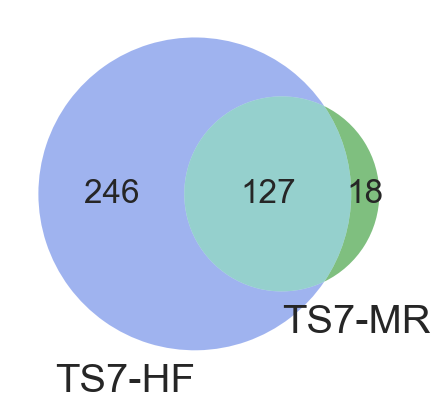

In [73]:
v = venn2(subsets = (np.sum(ls_n1) - np.sum(ls_n3) , np.sum(ls_n2) - np.sum(ls_n3), np.sum(ls_n3)), 
          set_labels = (cond1, cond2), 
          set_colors = ('royalblue', 'green'), alpha = 0.5)

# plt.savefig(f'venn2_{cond1}_{cond2}.pdf', transparent=True)

In [304]:
644/654

0.9847094801223242

In [306]:
df_dpref_l2

,idx,L1_1,L1_2,rec,cond1_hdc,cond2_hdc,comm_hdc,comm_perc
0,0,0,40,JA178_20220818,41,41,41,1.0
1,1,120,160,JA178_20220818,41,41,41,1.0
2,2,80,140,JA178_20220818,41,41,41,1.0
3,3,180,80,JA178_20220818,41,41,41,1.0
4,4,160,120,JA178_20220818,41,41,41,1.0
...,...,...,...,...,...,...,...,...
16,16,120,100,MC038_20220831,7,7,7,1.0
17,17,80,60,MC038_20220831,7,7,7,1.0
18,18,160,180,MC038_20220831,7,7,7,1.0
19,19,120,140,MC038_20220831,7,7,7,1.0


### Generate shuffled delta pref dir

In [307]:
ls_perm = []
data_4_perm = df_dpref_l2
for rec in data_4_perm.rec.unique():
    shift = np.random.randint(20)
    tmp = data_4_perm[data_4_perm.rec == rec]
    fake_pref = np.roll(tmp[cond1].values, shift)
    dpref_fake = ang_diff(fake_pref, tmp[cond1].values)
    ls_perm.append(dpref_fake)
flat_list = [item for sublist in ls_perm for item in sublist]
dpref_fake_ar = np.array(flat_list)

(3078, 2)


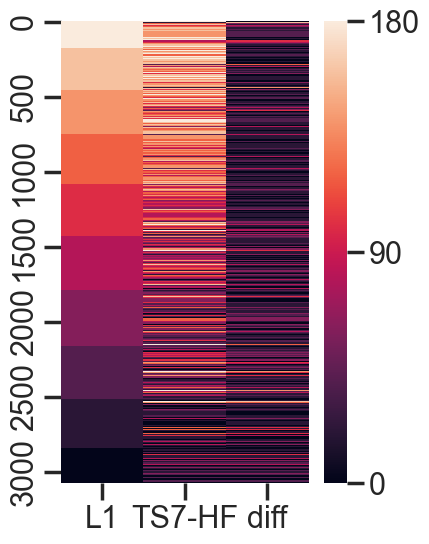

In [310]:
cond1 = 'L1'
cond2 = 'TS7-HF'
d_pref_arr = df_dpref_vr[[cond1, cond2]].dropna().values
print(d_pref_arr.shape)
dd_pref = ang_diff(d_pref_arr[:, 0], d_pref_arr[:, 1])
f, ax = plt.subplots(figsize = (4, 6))


out = np.vstack((d_pref_arr.T, dd_pref))
out_df = pd.DataFrame(out.T, columns = [cond1, cond2, 'diff'])
out_df = out_df.sort_values(by = cond1, ascending=False).reset_index(drop = True)
sns.heatmap(out_df, cmap = 'rocket', vmin = 0, vmax = 180, yticklabels = 500,
           cbar_kws=dict(ticks=[0, 90, 180]) )
# plt.savefig(f'heatmap_dpref_{cond1}_{cond2}.png', dpi = 300, transparent = True)

In [316]:
# # sns.kdeplot(x = 'l1', y = 'vr', data = df_dpref.reset_index(), legend = False, levels = 3)
# # df_tau_corr.pivot(index = ['pair', 'rec', 'env'], columns = 'cond', values = 'tau').reset_index()
# cond1 = 'L1'
# cond2 = 'TS6-HF'
# hexplot = sns.jointplot(data = df_dpref.reset_index(), x = cond1, y = cond2, kind="hex", height = 6, 
#               marginal_kws=dict(bins=20, fill=False), joint_kws= dict(gridsize= 20)
#                        )

# # make new ax object for the cbar
# cbar_ax = hexplot.fig.add_axes([1, .25, .05, .4])  # x, y, width, height
# plt.colorbar(cax=cbar_ax)
# # plt.savefig(f'delta_pd_{cond1}_{cond2}.pdf', transparent=True)

In [311]:
dpref_vr = df_dpref_vr[['L1', 'TS7-HF']].values
d_dpref_vr = ang_diff(dpref_vr[:, 0], dpref_vr[:, 1])

dpref_d1 = df_dpref_d1[['L1', 'D1']].values
d_dpref_d1 = ang_diff(dpref_d1[:, 0], dpref_d1[:, 1])

dpref_l2 = df_dpref_l2[['L1_1', 'L1_2']].values
d_dpref_l2 = ang_diff(dpref_l2[:, 0], dpref_l2[:, 1])

meta NOT subset; don't know how to subset; dropped


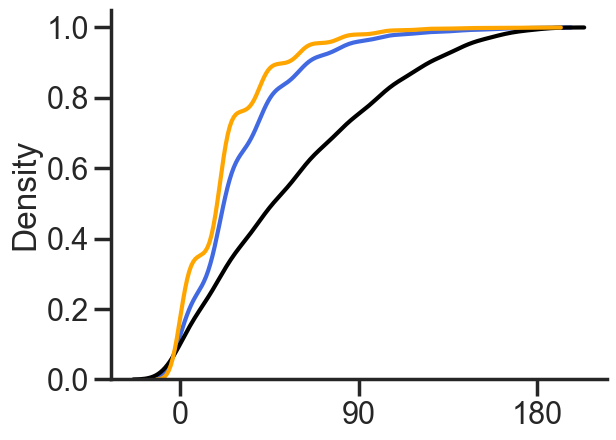

In [314]:
sns.kdeplot(
    data= d_dpref_vr,
    cumulative=True, common_norm=False, common_grid=True, color = 'royalblue'
)
sns.kdeplot(
    data= dpref_fake_ar,
    cumulative=True, common_norm=False, common_grid=True, color = 'k',
)

# sns.kdeplot(
#     data= d_dpref_d1,
#     cumulative=True, common_norm=False, common_grid=True, color = 'gray',
# )

g = sns.kdeplot(
    data= d_dpref_l2,
    cumulative=True, common_norm=False, common_grid=True, color = 'orange',
)
plt.xticks([0, 90, 180])
plt.savefig(f'cdf_dpd_{cond1}_{cond2}.pdf', transparent=True)

In [315]:
print(f'# of paris in real data {d_dpref_vr.size}')
print(f'# of paris in shuffled data {dpref_fake_ar.size}')
print(f'# of paris in light first vs second half {d_dpref_l2.size}')
print('VR vs shuffle', stats.kstest(d_dpref_vr, dpref_fake_ar))
print('VR vs L1-L2', stats.kstest(d_dpref_vr, d_dpref_l2))

# of paris in real data 3078
# of paris in shuffled data 7348
# of paris in light first vs second half 7348
VR vs shuffle KstestResult(statistic=0.3112338144904591, pvalue=2.7746429365932563e-186, statistic_location=40, statistic_sign=1)
VR vs L1-L2 KstestResult(statistic=0.11842901119610857, pvalue=5.871389102877963e-27, statistic_location=20, statistic_sign=-1)


In [171]:

# ─────────────────────────────────────────────────────────────
# 4.  ENSEMBLE OFFSET ESTIMATION
# ─────────────────────────────────────────────────────────────
def circ_mean(angles_deg):
    """Mean of a set of angles (degrees)."""
    r = np.deg2rad(angles_deg)
    return np.rad2deg(np.arctan2(np.nanmean(np.sin(r)), np.nanmean(np.cos(r)))) % 360


def circ_abs_diff(a, b):
    """Unsigned circular difference in [0, 180] degrees."""
    return np.abs(circ_diff(a, b))

def circ_diff(a, b):
    """
    Signed circular difference a - b in (-180, 180] degrees.
    Positive = a is CCW from b.
    """
    d = (np.asarray(a) - np.asarray(b) + 180) % 360 - 180
    return d
    
def ensemble_offset(pref_dirs_A, pref_dirs_B):
    """
    Estimate the global rotation of the HD ensemble between two conditions.

    Uses the circular mean of pairwise (B - A) differences across all cells.
    A consistent offset → global rotation; high variance → remapping/fragmentation.

    Parameters
    ----------
    pref_dirs_A, pref_dirs_B : 1-D arrays (same cell ordering), degrees

    Returns
    -------
    offset_mean   : float, mean offset B - A  (degrees)
    offset_std    : float, circular std of individual offsets (degrees)
    cell_offsets  : 1-D array, per-cell offsets (degrees)
    """
    cell_offsets = circ_diff(pref_dirs_B, pref_dirs_A)
    offset_mean = circ_mean(cell_offsets)
    offset_std = float(np.rad2deg(stats.circstd(np.deg2rad(cell_offsets))))
    return offset_mean, offset_std, cell_offsets


# ─────────────────────────────────────────────────────────────
# 5.  PAIRWISE ANGULAR DIFFERENCE PRESERVATION
# ─────────────────────────────────────────────────────────────

def pairwise_angular_differences(pref_dirs):
    """
    Compute all unique pairwise angular differences for an ensemble.

    Returns
    -------
    diffs : 1-D array of unsigned differences [0, 180]
    """
    n = len(pref_dirs)
    diffs = []
    for i in range(n):
        for j in range(i + 1, n):
            diffs.append(circ_abs_diff(pref_dirs[i], pref_dirs[j]))
    return np.array(diffs)

def pairwise_preservation_test(pref_A, pref_B, pref_C=None):
    """
    Test whether pairwise angular differences are preserved across conditions.

    A well-preserved ring (global rotation only) will show high correlation
    between pairwise diffs in condition A vs B.

    Parameters
    ----------
    pref_A, pref_B : preferred directions in condition A and B (degrees)
    pref_C         : optional third condition (e.g. VR)

    Returns
    -------
    r_AB  : Pearson r between pairwise diffs in A vs B
    r_AC  : Pearson r between pairwise diffs in A vs C (if C provided)
    """
    pw_A = pairwise_angular_differences(pref_A)
    pw_B = pairwise_angular_differences(pref_B)
    r_AB = float(np.corrcoef(pw_A, pw_B)[0, 1])

    r_AC = None
    if pref_C is not None:
        pw_C = pairwise_angular_differences(pref_C)
        r_AC = float(np.corrcoef(pw_A, pw_C)[0, 1])

    return r_AB, r_AC
    
def circ_preferred_direction(tuning_curve, bin_centers_rad, method="circular_mean"):
    """
    Estimate the preferred direction of one HD cell.

    Parameters
    ----------
    tuning_curve   : 1-D array, firing rate per angular bin
    bin_centers_deg: 1-D array, centre of each bin (degrees)
    method         : 'circular_mean' (default) or 'peak'

    Returns
    -------
    pref_dir : float, degrees [0, 360)
    """
    if method == "peak":
        pk, _ = find_peaks(tuning_curve)
        if len(pk) == 0:
            pk = [np.argmax(tuning_curve)]
        best = pk[np.argmax(tuning_curve[pk])]
        return float(bin_centers_deg[best]) % 360
    else:  # circular_mean — robust to noise
        # angles = np.deg2rad(bin_centers_deg)
        angles = bin_centers_rad
        weights = np.clip(tuning_curve, 0, None)
        weights /= weights.sum() + 1e-12
        mean_angle = np.arctan2(
            np.sum(weights * np.sin(angles)),
            np.sum(weights * np.cos(angles))
        )
        return float(np.rad2deg(mean_angle) % 360)

In [172]:
def plot_pref_dir(pref_light, pref_dark, pref_vr):
    f, ax_A = plt.subplots(figsize = (4, 4))
    n_cells = len(pref_light)
    sort_idx = np.argsort(pref_light)
    x = np.arange(n_cells)
    ax_A.plot(x, pref_light[sort_idx], "o", color=COLORS["light"], ms=5,
              label="Light", alpha=0.85, zorder=3)
    ax_A.plot(x, pref_dark[sort_idx],  "s", color=COLORS["dark"],  ms=5,
              label="Dark",  alpha=0.85, zorder=2)
    ax_A.plot(x, pref_vr[sort_idx],    "^", color=COLORS["vr"],    ms=5,
              label="VR",    alpha=0.85, zorder=1)
    ax_A.set_xlabel("Cell (sorted by Light pref. dir.)", fontsize=10)
    ax_A.set_ylabel("Preferred direction (°)", fontsize=10)
    ax_A.set_yticks([0, 90, 180, 270, 360])
    ax_A.set_ylim(-5, 365)
    ax_A.legend(fontsize=8, loc="upper left")
    ax_A.set_title("A  Per-cell preferred directions", fontsize=10, loc="left")
    return

## Plot tuning curves across cond

In [32]:
df_tun_proc.tail()

,hz,dir,cids,mouse_id,r,p_val,rec_id,dts,probe_conf,vr_env,head_fixation,cuid,rec_session,rec_unit,cond,hdc,implant,dir_adj
13,1.233491,260.0,651.0,JA178,0.057593,0.285,20220909_JA178_rADN_yel_H2_VR1_TS6-VIS,20220909,H2,TS6,VIS,651-JA178-rADN-0909-TS6VIS,JA178_20220909,JA178_20220909_651.0,TS6-VIS,0,JA178_rADN,80.0
14,1.352885,280.0,651.0,JA178,0.057593,0.285,20220909_JA178_rADN_yel_H2_VR1_TS6-VIS,20220909,H2,TS6,VIS,651-JA178-rADN-0909-TS6VIS,JA178_20220909,JA178_20220909_651.0,TS6-VIS,0,JA178_rADN,60.0
15,1.154891,300.0,651.0,JA178,0.057593,0.285,20220909_JA178_rADN_yel_H2_VR1_TS6-VIS,20220909,H2,TS6,VIS,651-JA178-rADN-0909-TS6VIS,JA178_20220909,JA178_20220909_651.0,TS6-VIS,0,JA178_rADN,40.0
16,1.110932,320.0,651.0,JA178,0.057593,0.285,20220909_JA178_rADN_yel_H2_VR1_TS6-VIS,20220909,H2,TS6,VIS,651-JA178-rADN-0909-TS6VIS,JA178_20220909,JA178_20220909_651.0,TS6-VIS,0,JA178_rADN,20.0
17,0.731818,340.0,651.0,JA178,0.057593,0.285,20220909_JA178_rADN_yel_H2_VR1_TS6-VIS,20220909,H2,TS6,VIS,651-JA178-rADN-0909-TS6VIS,JA178_20220909,JA178_20220909_651.0,TS6-VIS,0,JA178_rADN,0.0


In [180]:
data = df_tun_proc[ (df_tun_proc.hdc == 1)
                   & ((df_tun_proc.cond == 'TS7-HF')  | (df_tun_proc.cond == 'L1') | (df_tun_proc.cond == 'D1'))
                   # & (df_tun_proc.rec_session == 'JA180_20220809')
#                    | ((df_tun_proc.head_fixation == 'HF') & (df_tun_proc.vr_env == 'TS6'))
                     ]
cond_ls = ['L1', 'D1', 'TS7-HF']
vr_rec_sess = data[data['cond'] == 'TS7-HF'].rec_session.unique()
# data = df_tun_loc
angles = np.arange(0, 360, 20)
d_hdc_across_cond_rev = {}
ang_rad = np.deg2rad(angles)
ang_rad = np.append(ang_rad, ang_rad[0])
current_palette = ['orange','gray', 'royalblue']
ls_df = []

for rec in vr_rec_sess[:]:

    if 'JA179_20220804' not in rec:
        continue
    print(rec)
    tmp = data[data.rec_session == rec]
    if tmp.cond.unique().size < 3:
        continue
    rec_hdc = tmp[tmp.dir == 0].groupby([ 'cond'])['rec_unit'].apply(list).reset_index()
    cond_hdc_a = rec_hdc[rec_hdc.cond == cond_ls[0]]['rec_unit'].values[0]
    cond_hdc_b = rec_hdc[rec_hdc.cond == cond_ls[1]]['rec_unit'].values[0]
    cond_hdc_c = rec_hdc[rec_hdc.cond == cond_ls[2]]['rec_unit'].values[0]
    d_hdc_across_cond = {}
    d_hdc_across_cond = categorize_numbers(cond_hdc_a, cond_hdc_b, cond_hdc_c)
    for name, numbers in d_hdc_across_cond.items():
        for num in numbers:
            if num not in result:  # Only set if not already present
                d_hdc_across_cond_rev[num] = name
            
#     print(rec)
    
    for unit in d_hdc_across_cond['all'][:]:
        # print(unit)
        ax = plt.subplot(111, projection = 'polar')
#         ax.yaxis.grid(linewidth=0)
#         ax.xaxis.grid(linewidth=6)
        ax.set_yticklabels([])
        # ax.set_xticklabels([])
        ax.grid(False)
    #         ax.set_theta_zero_location("N")
    #         ax.set_theta_direction(-1)
        
        for idx, cn in enumerate(cond_ls):
            max_fr_cond = math.ceil(tmp[(tmp.rec_unit == unit)]['hz'].max()) + 2
            this_unit = tmp[(tmp.rec_unit == unit) & (tmp.cond == cn)]
            this_fr, this_r = this_unit.hz.values, np.round(this_unit.r.min(), 2)
    #         angles_arena = tmp[(tmp.cids == unit) & (tmp.head_fixation == 'HF')].dir_adj
            this_fr = np.append(this_fr, this_fr[0])
            max_fr = round(this_fr.max())
               
            # angles were reflected in arena code, so use[::-1] for arena
            if '1' in cn:
                this_ang = ang_rad[::-1]
            else:
                this_ang = ang_rad
            pref_dir = this_ang[np.argmax(this_fr)]
            pref_dir_circ = round(circ_preferred_direction(this_fr[:], this_ang[:]))
            
            ax.set_rlim(0, max_fr_cond)
            ax.plot(this_ang, this_fr, label = f'{this_r}, {max_fr} Hz' , c = current_palette[idx], zorder=1)
            # ax.plot(pref_dir_circ, max_fr, c = current_palette[idx])
            ax.plot(np.deg2rad(pref_dir_circ), max_fr_cond*0.95, 'o', markersize = 10, c = current_palette[idx], zorder=10)
            

            # print(pref_dir_circ, np.rad2deg(pref_dir))
            # tmp_df = pd.DataFrame({'rec_session':rec, 'rec_unit': unit, 'cond': cn, 'pref_dir': pref_dir, 'pref_dir_circ':pref_dir_circ,'tun_peak_fr': max_fr, 'r': this_r }, index = [0])
            # ls_df.append(tmp_df)
            
            # ax.set_title(f'{unit}')
            ax.legend(loc='best', bbox_to_anchor=(1.5, 0.5, 0.5, 0.5))
        # plt.show()
        # break
#         fr_resam, results_half = hd_tuning_width(fr2)
#         plt.plot(fr_resam)
#         plt.hlines(*results_half[1:])
        ax.set_xticks(np.pi/180. * np.linspace(180,  -180, 8, endpoint=False))
        ax.set_thetalim(-np.pi, np.pi)
        
    
        time.sleep(0.1)
        filepath = save_dir / f'polar_HD_tuning_{rec}_{unit}.pdf'
        plt.savefig(filepath, transparent = True)
    
        # plt.savefig(f'{rec}_{unit}_L_TS6-HF_run.pdf' , transparent=True)
        plt.clf()
    break
# df_pref_remap = pd.concat(ls_df)
# df_pref_remap.head()

JA179_20220804


<Figure size 640x480 with 0 Axes>

In [41]:
df_pref_remap.rec_session.unique()

array(['JA178_20220819', 'JA178_20220823', 'JA179_20220802',
       'JA179_20220804', 'JA179_20220805', 'JA180_20220809',
       'JA180_20220810', 'JA180_20220811', 'JA180_20220819',
       'JA181_20220809', 'JA181_20220812', 'MC022_20220627',
       'MC022_20220629', 'JA178_20220907'], dtype=object)

In [179]:
df_pref_remap.head()

,rec_session,rec_unit,cond,pref_dir,pref_dir_circ,tun_peak_fr,r
0,JA178_20220819,JA178_20220819_0.0,L1,0.698132,33,9,0.65
0,JA178_20220819,JA178_20220819_0.0,D1,0.698132,36,22,0.74
0,JA178_20220819,JA178_20220819_0.0,TS7-HF,5.235988,282,31,0.70
0,JA178_20220819,JA178_20220819_10.0,L1,5.934119,323,5,0.69
0,JA178_20220819,JA178_20220819_10.0,D1,5.585054,324,11,0.69


JA178_20220819
253.43393015462857 37.829224749335935 [-111  -75 -103 -116 -123 -110 -113 -107 -106  169  132  -65  -93 -127
 -125 -123  -69  -98  -79  -26 -126  -99]
PearsonRResult(statistic=0.6676186026337548, pvalue=3.5660796471053193e-31)


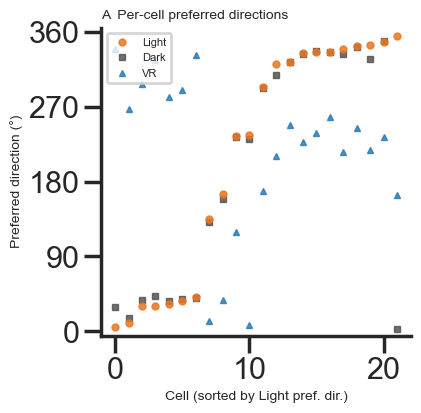

JA178_20220823
198.50915030494693 10.629195094239309 [-178 -169 -155 -161 -158 -160 -163 -155 -157 -166 -155 -179 -174 -135
 -157]
PearsonRResult(statistic=0.9710694874341264, pvalue=6.981641236401416e-66)


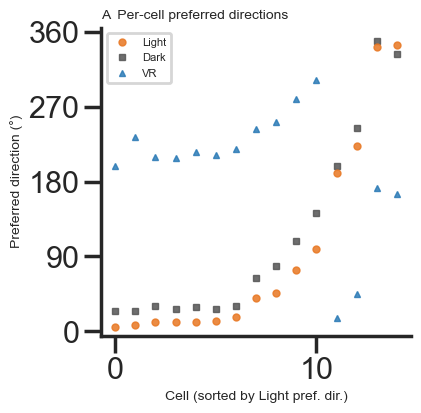

JA179_20220802
249.90473770993378 15.0886946146413 [-123  -96 -107 -116 -123  -91 -121 -122  -95 -122 -105  -75 -101 -114
 -127  -99 -133]
PearsonRResult(statistic=0.9185373830020854, pvalue=7.363915552723525e-56)


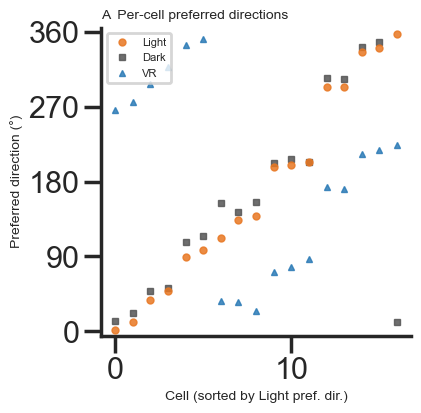

JA179_20220804
262.14971128483035 9.534498275746717 [-105 -100  -79  -89  -89 -104  -94 -113  -95 -106 -103  -86  -87 -109
 -105  -90 -118  -97 -100  -94  -92]
PearsonRResult(statistic=0.9680335219395972, pvalue=6.667984375441738e-127)


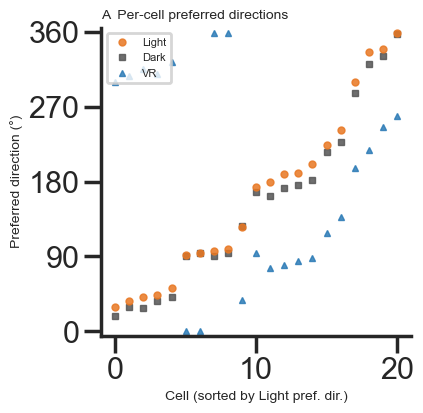

JA179_20220805
129.9792922474353 23.317074252787904 [ 117  132  119  118  132  131  113  129 -142  132  112  150  160  119
  102  130  132  140  114]
PearsonRResult(statistic=0.8238846170489504, pvalue=1.5647400517225348e-43)


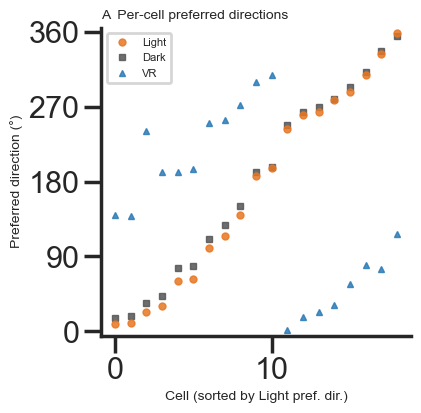

JA180_20220809
98.1707892276015 31.21331659504857 [ 97 107  -3 116 109 118 106 111 109  51  96  41 117 100 115 122 100]
PearsonRResult(statistic=0.7026097264734166, pvalue=1.5319754962679304e-21)


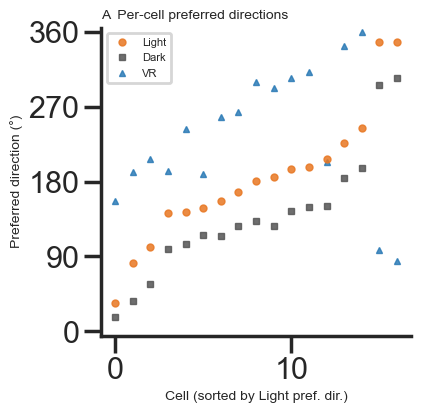

JA180_20220810
119.85175189351598 18.111737681200765 [121 129 119 140  50 125 124 122 106 117 148 110 110  91 126 122 129 124
 130 136 125 119 118]
PearsonRResult(statistic=0.8917285982911107, pvalue=2.129397685397452e-88)


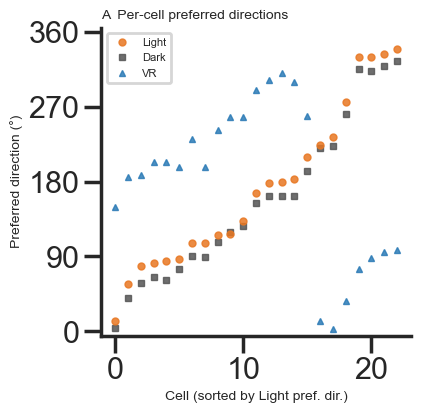

JA180_20220811
115.95785038239148 10.123966349561005 [103 113 114 122 116 104 105 122 100 117 103 120 103 124 101 113 107 110
 122 125 123 121 135 130 124 136 118]
PearsonRResult(statistic=0.9598223729630628, pvalue=1.0839098614928095e-194)


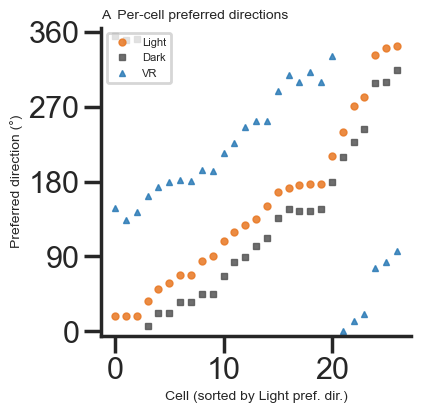

JA180_20220819
200.77795659460213 19.127779220923443 [-155  170 -129 -153 -144 -154 -169 -158 -154 -142 -153 -168 -135  132
  167 -157 -154 -143 -165 -154 -167 -144 -164 -174 -150 -166 -152]
PearsonRResult(statistic=0.8858168672073428, pvalue=2.0358228129680945e-118)


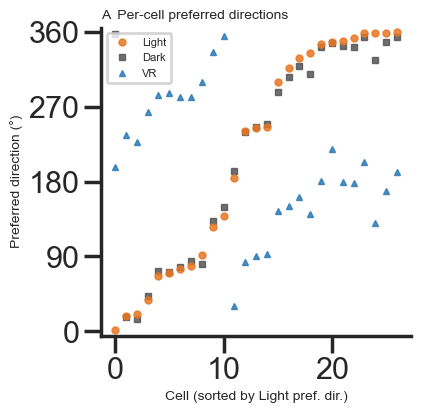

JA181_20220809
JA181_20220812
235.04236351468484 11.577548051268206 [-123 -111 -111 -120 -117 -133 -134 -120 -127 -122 -125 -125 -158]
PearsonRResult(statistic=0.9466720845663236, pvalue=3.987163143781093e-39)


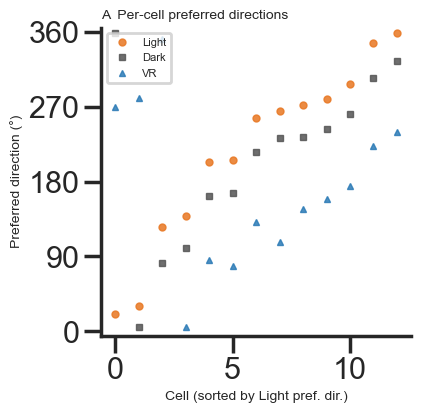

MC022_20220627
344.31759879298113 12.244133236454607 [ -9 -24 -25 -19 -23 -28   7  27 -14 -20 -20  -5 -20 -25 -22 -22 -26   1
 -10 -23 -16 -13 -19 -24]
PearsonRResult(statistic=0.9469573996769323, pvalue=4.1839748311275343e-137)


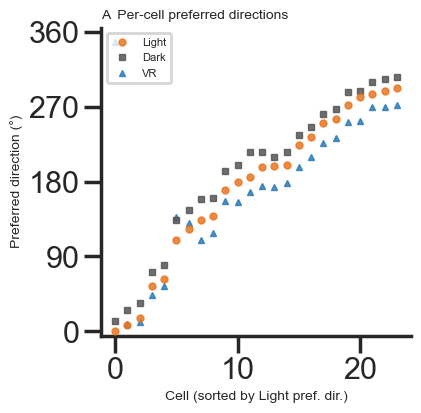

MC022_20220629
66.35992383717976 56.41703160253561 [  80 -119   74   72   68   63   41   71   60   88 -162   55  127   53
   63  -65   11]
PearsonRResult(statistic=0.28029507683441324, pvalue=0.0009493773199092282)


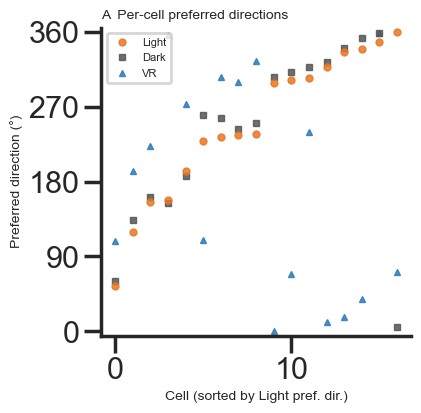

JA178_20220907
235.80419325456378 7.783414029403161 [-120 -112 -127 -121 -128 -113 -140 -125 -127 -129]
PearsonRResult(statistic=0.976053284746776, pvalue=4.038205127928638e-30)


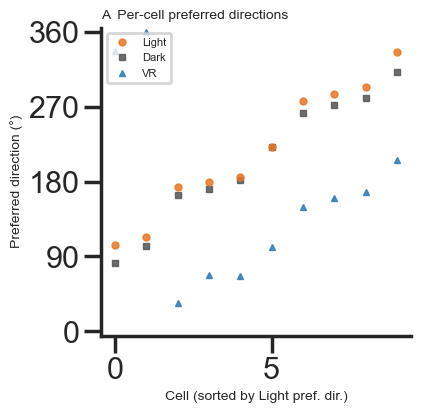

,rec_session,variable,value
0,JA178_20220819,r_LD,0.978020
1,JA178_20220823,r_LD,0.959993
2,JA179_20220802,r_LD,0.972889
3,JA179_20220804,r_LD,0.986772
4,JA179_20220805,r_LD,0.989079


In [177]:
COLORS = {"light": "#E87722", "dark": "#555555", "vr": "#2C7BB6"}
ls = [] 

for rec in df_pref_remap.rec_session.unique():
    print(rec)

    # if 'JA178_20220819' not in rec:
    #     continue
            
    this_rec = df_pref_remap[df_pref_remap.rec_session == rec]
    pref_light = (this_rec[this_rec.cond == 'L1'].pref_dir_circ.values)
    pref_dark = (this_rec[this_rec.cond == 'D1'].pref_dir_circ.values)
    pref_vr = (this_rec[this_rec.cond == 'TS7-HF'].pref_dir_circ.values)
    if pref_vr.size < 10:
        continue
    
    mean_LD, std_LD, off_LD = ensemble_offset(pref_light, pref_dark)
    mean_LV, std_LV, off_LV = ensemble_offset(pref_light, pref_vr)
    mean_DV, std_DV, off_DV = ensemble_offset(pref_dark, pref_vr)
    print (mean_LV, std_LV, off_LV)
    r_LD, r_LV = pairwise_preservation_test(pref_light, pref_dark, pref_vr)
    remap_prop_LD = compute_remap_hdc_prop(off_LD)
    remap_prop_LV = compute_remap_hdc_prop(off_LV)

    tmp_df = pd.DataFrame({'rec_session': rec, 'r_LD':r_LD, 'r_LV':r_LV, 'remap_prop_LD':remap_prop_LD, 
                           'remap_prop_LV': remap_prop_LV}, index = [0])
    ls.append(tmp_df)
    
    pw_L = pairwise_angular_differences(pref_light)
    pw_D = pairwise_angular_differences(pref_dark)
    pw_V = pairwise_angular_differences(pref_vr)
    
    plot_pref_dir(pref_light, pref_dark, pref_vr)
    print(pearsonr(pw_L, pw_V))
    # filepath = save_dir / f'scatter_prefdir_{rec}.pdf'
    # plt.savefig(filepath, transparent = True)
    
    plt.show()
    # break
    
df_remap_r = pd.concat(ls)
df_remap_r_long = df_remap_r.melt(id_vars = ['rec_session'])
df_remap_r_long.head()

In [154]:
np.mean(abs(off_LV))

104.31818181818181

In [173]:
def compute_remap_hdc_prop(off_LV): 
    threshold = 30
    abs_off_LV = abs(off_LV)
    mean_offset = np.mean(abs_off_LV)
    remap_hdc_n = np.where((abs_off_LV > mean_offset + threshold) | (abs_off_LV < mean_offset - threshold))[0].size
    remap_prop = remap_hdc_n/abs_off_LV.size
    return round(remap_prop,2 )

### Proportion of remapped HDC

<Axes: >

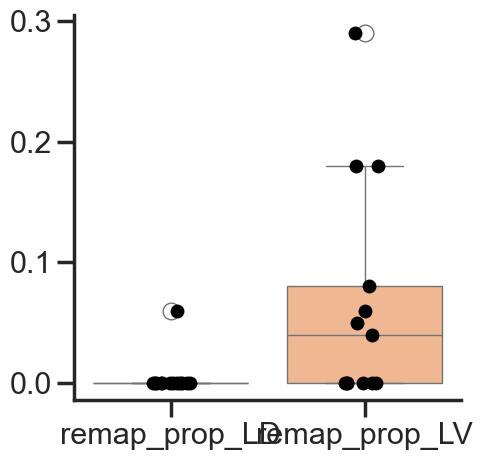

In [178]:
f, ax = plt.subplots(figsize = (5, 5))
y = 'value'
sns.boxplot(data=df_remap_r[['remap_prop_LD', 'remap_prop_LV']])
sns.stripplot(data=df_remap_r[['remap_prop_LD', 'remap_prop_LV']], s = 10, color = 'k')
# plt.savefig(f'box_remap_ratio_LD-LV.pdf' , transparent=True)

In [150]:
df_remap_r_long.groupby('variable').describe()

value                                                    \
              count      mean       std       min       25%       50%   
variable                                                                
r_LD           13.0  0.979816  0.009438  0.959993  0.972889  0.982891   
r_LV           13.0  0.841469  0.196277  0.280295  0.823885  0.918537   
remap_prop_LD  13.0  0.004615  0.016641  0.000000  0.000000  0.000000   
remap_prop_LV  13.0  0.067692  0.092840  0.000000  0.000000  0.040000   

                                   
                    75%       max  
variable                           
r_LD           0.987750  0.990004  
r_LV           0.959822  0.976053  
remap_prop_LD  0.000000  0.060000  
remap_prop_LV  0.080000  0.290000

In [151]:
a1 = df_remap_r_long[(df_remap_r_long.variable == 'remap_prop_LD') ][y].values
a2 = df_remap_r_long[(df_remap_r_long.variable == 'remap_prop_LV') ][y].values

stat1, pval1 = stats.mannwhitneyu(a1, a2)
print(f'remap % LD vs LVR {stat1} {pval1}')

remap % LD vs LVR 44.5 0.01319905394302527


PearsonRResult(statistic=0.9780196607914529, pvalue=6.493174185498435e-158)


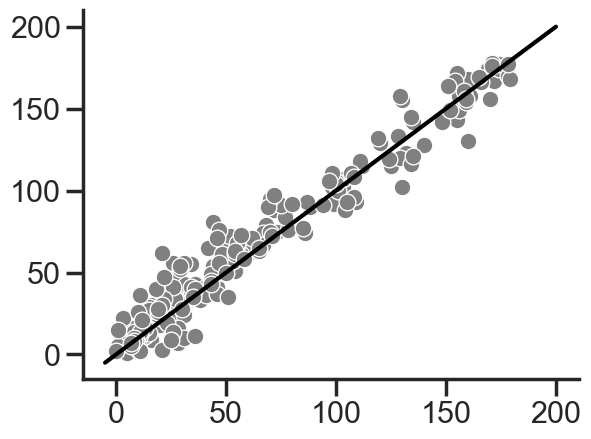

In [64]:
unity_line = [-5, 200]
plt.plot(unity_line, unity_line, 'k')
sns.scatterplot(x = pw_L, y = pw_D, color='gray')
print(pearsonr(pw_L, pw_D))

# plt.savefig(f'scatter_pw_L-pw_D_ex2.pdf' , transparent=True)

PearsonRResult(statistic=0.6676186026337548, pvalue=3.5660796471053193e-31)


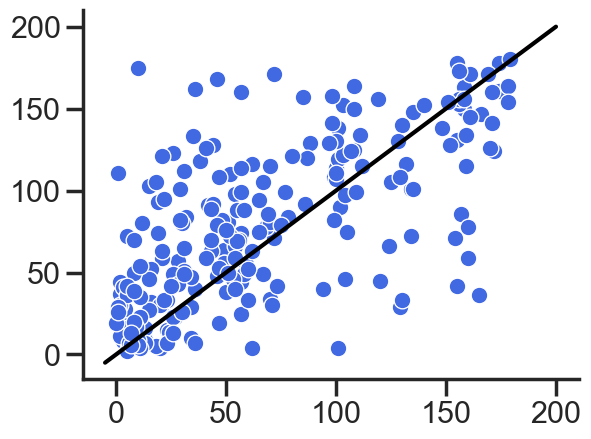

In [65]:
unity_line = [-5, 200]
plt.plot(unity_line, unity_line, 'k')
sns.scatterplot(x = pw_L, y = pw_V, color='royalblue')
print(pearsonr(pw_L, pw_V))

# plt.savefig(f'scatter_pw_L-pw_V_ex2.pdf' , transparent=True)

In [103]:

# f, ax_C = plt.subplots(figsize = (4, 4))
# ax_C.scatter(pw_L, pw_D, s=8, alpha=0.4, color=COLORS["dark"],
#              label=f"Light vs Dark  r={r_LD:.2f}")
# ax_C.scatter(pw_L, pw_V, s=8, alpha=0.4, color=COLORS["vr"],
#              label=f"Light vs VR    r={r_LV:.2f}")
# lim = [0, 180]
# ax_C.plot(lim, lim, "k--", lw=1, alpha=0.6)
# ax_C.set_xlabel("Pairwise diff in Light (°)", fontsize=10)
# ax_C.set_ylabel("Pairwise diff in other cond. (°)", fontsize=10)
# ax_C.set_xlim(0, 180); ax_C.set_ylim(0, 180)
# ax_C.legend(fontsize=8)
# ax_C.set_title("C  Pairwise ΔDir preservation", fontsize=10, loc="left")
# ax_C.text(0.05, 0.92, "Perfect preservation → diagonal",
#           transform=ax_C.transAxes, fontsize=7.5, color="gray")

### Pearson r remapping 

In [138]:
df_remap_r_long.variable.unique()

array(['r_LD', 'r_LV', 'remap_prop_LD', 'remap_prop_LV'], dtype=object)

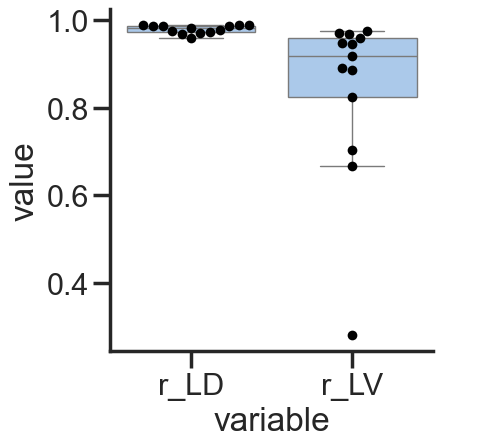

In [106]:
y = 'value'
_inp = df_remap_r_long[df_remap_r_long]
g = sns.catplot(
    data=df_remap_r_long, 
    x="variable", 
    y="value", 
    kind="box", 
    height=5,     # Height is 5 inches
    aspect=1    # Width will be 5 * 1.5 = 7.5 inches
)

g.map_dataframe(
    sns.swarmplot,
    x="variable", 
    y="value", 
    color = 'k',
    s = 7
)

# plt.savefig(f'box_pw_LD-LV.pdf' , transparent=True)

In [105]:
df_remap_r_long.groupby('variable').describe()

value                                                              \
         count      mean       std       min       25%       50%       75%   
variable                                                                     
r_LD      13.0  0.979816  0.009438  0.959993  0.972889  0.982891  0.987750   
r_LV      13.0  0.841469  0.196277  0.280295  0.823885  0.918537  0.959822   

                    
               max  
variable            
r_LD      0.990004  
r_LV      0.976053

In [107]:
a1 = df_remap_r_long[(df_remap_r_long.variable == 'r_LD') ][y].values
a2 = df_remap_r_long[(df_remap_r_long.variable == 'r_LV') ][y].values

stat1, pval1 = stats.mannwhitneyu(a1, a2)
print(f'r LD vs LVR {stat1} {pval1}')

 r LD vs LVR 161.0 9.721654366930001e-05


### Select good rec sessions (# of HD >10 in a single shank)

In [136]:
df_tun_proc.cond.unique()

array(['D1', 'L1', 'TS6-HF', 'TS6-MR', 'TS6-RPLCOMB', 'TS6-RPLVIS',
       'TS7-MR', 'TS7-RPLVEST', 'TS7-RPLVIS', 'TS7-HF', 'TS7-RPLCOMB',
       'TS6-OVAR10', 'TS6-OVAR20', 'TS6-RPLVEST', 'TS7-HFLMK',
       'TS6-HFLMK180', 'TS7-HFLMK180', 'TS7-RPL', 'TS7-VIS', 'TS6-RPL',
       'TS6-VIS', 'TS6-HFLMK30', 'TS6-LMK30'], dtype=object)

In [107]:
df_tun_proc[(df_tun_proc.dir == 0) & (df_tun_proc.cond == 'TS7-HF')].groupby(['implant', 'dts', 'cond',])['hz'].count()

implant     dts       cond  
JA178_lADN  20220819  TS7-HF     89
            20220823  TS7-HF     53
JA178_rADN  20220907  TS7-HF     79
JA179_lADN  20220802  TS7-HF    139
            20220804  TS7-HF    113
            20220805  TS7-HF     88
JA180_lADN  20220809  TS7-HF     81
            20220810  TS7-HF     92
            20220811  TS7-HF     99
            20220819  TS7-HF    123
JA181_lADN  20220809  TS7-HF     85
            20220812  TS7-HF     51
MC022_lADN  20220627  TS7-HF     85
            20220629  TS7-HF     63
MC038_lADN  20220829  TS7-HF     55
Name: hz, dtype: int64

In [108]:
df_tun_loc.head()

NameError: name 'df_tun_loc' is not defined

In [109]:
tmp = df_tun_proc[(df_tun_proc.hdc == 1) & (df_tun_proc.dir == 0) & (df_tun_proc.vr_env == 'L1')]
sess_cuid = tmp.mouse_id + '_' + tmp.dts + '_' + tmp.cids.astype(int).astype(str)

In [110]:
# with open('sess_hdc.npy', 'wb') as f:
#     np.save(f, np.array(sess_cuid.values))


In [111]:
df_tun_proc.vr_env.unique()

array(['D1', 'L1', 'TS6', 'TS7'], dtype=object)

In [168]:
data = df_tun_proc2[ (df_tun_proc2.hdc == 1)
                   & ((df_tun_proc2.vr_env == 'L1') | (df_tun_proc2.head_fixation == 'HF'))
                   & (df_tun_proc2.rec_session == 'JA180_20220809')
#                    | ((df_tun_proc.head_fixation == 'HF') & (df_tun_proc.vr_env == 'TS6'))
                     ]
# data = df_tun_loc
angles = np.arange(0, 360, 20)
a = np.deg2rad(angles)
a = np.append(a, a[0])

for rec in data.rec_session.unique()[:]:
#     if 'TS6-HF' not in rec:
#         continue
    if 'JA180' not in rec:
        continue
    print(rec)
    tmp = data[data.rec_session == rec]
#     print(rec)
    for unit in tmp.cids.unique()[:]:
        print(unit)
        ax = plt.subplot(111, projection = 'polar')
#         ax.yaxis.grid(linewidth=0)
#         ax.xaxis.grid(linewidth=6)
        ax.set_yticklabels([])
        ax.set_xticklabels([])
        ax.grid(False)
    #         ax.set_theta_zero_location("N")
    #         ax.set_theta_direction(-1)
        fr1 = tmp[(tmp.cids == unit) & (tmp.vr_env == 'L1')].hz
        fr2 = tmp[(tmp.cids == unit) & (tmp.vr_env == 'TS6')].hz
        r_r = np.round(tmp[(tmp.cids == unit) & (tmp.vr_env == 'L1')].r.min(), 2)
        r_vr = np.round(tmp[(tmp.cids == unit) & (tmp.vr_env == 'TS6')].r.min(), 2)
        
        if fr1.size < 1 or fr2.size < 1 or r_r < 0.3:
            continue
#         angles_arena = tmp[(tmp.cids == unit) & (tmp.head_fixation == 'HF')].dir_adj

        fr1 = np.append(fr1, fr1[0])
        fr2 = np.append(fr2, fr2[0])
        max_fr1 = round(fr1.max())
        max_fr2 = round(fr2.max())
        # angles were reflected in arena code, so use[::-1] for arena
        ax.plot(a[::-1], fr1, label = f'{r_r}, {max_fr1} Hz', c = current_palette[1])
        ax.plot(a[:], fr2, label = f'{r_vr}, {max_fr2} Hz',  c = current_palette[0])
        ax.legend(loc='best', bbox_to_anchor=(1.5, 0.5, 0.5, 0.5))
        
#         fr_resam, results_half = hd_tuning_width(fr2)
#         plt.plot(fr_resam)
#         plt.hlines(*results_half[1:])
        ax.set_xticks(np.pi/180. * np.linspace(180,  -180, 8, endpoint=False))
        ax.set_thetalim(-np.pi, np.pi)
        
        plt.show()
        time.sleep(1)
        plt.savefig(f'{rec}_{unit}_L_TS6-HF_run.pdf' , transparent=True)
        plt.clf()
    break

NameError: name 'df_tun_proc2' is not defined

In [203]:
data.vr_env.unique()

array(['L1', 'TS6', 'TS7'], dtype=object)

In [24]:
def save_dict(fname, d_data):
    with open(fname, 'wb') as file:
        pickle.dump(d_data, file)
    return fname

In [123]:
d_rec_hdc = {}
cond_ls = ['D1', 'L1', 'TS6-HF', 'TS6-MR', 'TS7-MR', 'TS7-HF']
for cond in cond_ls:
    d_rec_hdc[cond] = {}
    tmp2 = tmp[tmp.cond == cond]
    d_out = tmp2.groupby('rec_session').cids.count().to_dict()
    d_rec_hdc[cond] = d_out
    

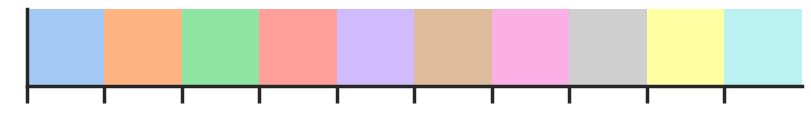

In [77]:
current_palette = sns.color_palette()
sns.palplot(current_palette[:][:])

## Plot HDC Tuning 

In [162]:
df_tun_proc.head()

,hz,dir,cids,mouse_id,r,p_val,rec_id,dts,probe_conf,vr_env,head_fixation,cuid,rec_session,rec_unit,cond,hdc,implant,dir_adj
0,19.374491,0.0,1.0,JA178,0.492617,0.003,20220818_JA178_lADN_red_H2_R_D1,20220818,H2,D1,na,1-JA178-lADN-0818-D1na,JA178_20220818,JA178_20220818_1.0,D1,1,JA178_lADN,340.0
1,8.332602,20.0,1.0,JA178,0.492617,0.003,20220818_JA178_lADN_red_H2_R_D1,20220818,H2,D1,na,1-JA178-lADN-0818-D1na,JA178_20220818,JA178_20220818_1.0,D1,1,JA178_lADN,320.0
2,3.224077,40.0,1.0,JA178,0.492617,0.003,20220818_JA178_lADN_red_H2_R_D1,20220818,H2,D1,na,1-JA178-lADN-0818-D1na,JA178_20220818,JA178_20220818_1.0,D1,1,JA178_lADN,300.0
3,3.784274,60.0,1.0,JA178,0.492617,0.003,20220818_JA178_lADN_red_H2_R_D1,20220818,H2,D1,na,1-JA178-lADN-0818-D1na,JA178_20220818,JA178_20220818_1.0,D1,1,JA178_lADN,280.0
4,3.191489,80.0,1.0,JA178,0.492617,0.003,20220818_JA178_lADN_red_H2_R_D1,20220818,H2,D1,na,1-JA178-lADN-0818-D1na,JA178_20220818,JA178_20220818_1.0,D1,1,JA178_lADN,260.0


In [146]:
vr_sess = df_tun_proc[df_tun_proc.cond == 'TS7-HF'].rec_session.unique()

<Axes: xlabel='r', ylabel='Density'>

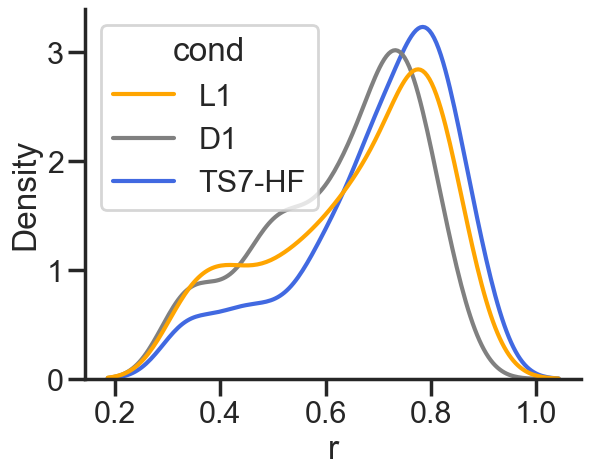

In [183]:
y = 'r'
coi = ['L1', 'D1', 'TS7-HF']
# pal = ('royalblue', 'magenta')
# pal = ('darkgreen', 'lightgreen')
pal = ('orange', 'gray', 'royalblue')

# vis_rec_sess = df_tun_proc[(df_tun_proc.head_fixation == 'VIS') & (df_tun_proc.dir == 0)].rec_session.unique()

# sessions_in = df_betti[(df_betti.cond == 'TS6-HF') & (df_betti.stat_off_manifold > 0.5)].rec_session.unique()
# data = df_tun_proc[(df_tun_proc.rec_id.isin(vis_rec_id))]
# rec_units = data[data.hdc == 1].rec_unit.unique()



_inp_plot = df_tun_proc[ ((df_tun_proc.cond.isin(coi))) 
    & (df_tun_proc.hdc == 1) & (df_tun_proc.rec_session.isin(vr_sess))
            # & (data.rec_unit.isin(rec_units))
            ].groupby(['mouse_id', 'rec_session','rec_id', 'cids', 'cond'])[y].max().reset_index()


sns.kdeplot(x = y, data = _inp_plot, hue = 'cond',  fill=False, hue_order= coi,
            cumulative=False, common_grid=True,
           common_norm = False, legend = True, 
#             cut = 0,
            palette = pal)


# plt.xlim(0, 1)
# filepath = save_dir / f'kde_{y}_{coi}_{cond2}.pdf'
# plt.savefig(filepath, transparent = True)

In [186]:
_inp_plot.groupby(['cond', ])[y].describe()

,count,mean,std,min,25%,50%,75%,max
cond,,,,,,,,
D1,301.0,0.628685,0.146735,0.307613,0.520214,0.660542,0.746254,0.867157
L1,359.0,0.654339,0.160558,0.301913,0.538171,0.693347,0.783264,0.926951
TS7-HF,373.0,0.694988,0.149430,0.304250,0.618143,0.732661,0.801924,0.920235


In [187]:
a1 = _inp_plot[_inp_plot.cond == coi[0]][y].values
b1 = _inp_plot[_inp_plot.cond == coi[1]][y].values
c1 = _inp_plot[_inp_plot.cond == coi[2]][y].values
print(f'test for {y}')
# print(f'# of implntations {_inp_plot.implant.unique().size}')

print(f'{coi[0]} vs {coi[1]}', stats.mannwhitneyu(a1, b1))
print(f'{coi[0]} vs {coi[2]}', stats.mannwhitneyu(a1, c1))

test for r
L1 vs D1 MannwhitneyuResult(statistic=60814.0, pvalue=0.005425133257076515)
L1 vs TS7-HF MannwhitneyuResult(statistic=57076.0, pvalue=0.0005533200677555228)


In [53]:
df_tun_run_sel = df_tun_run[df_tun_run.rec_session.isin(vr_com_sess)]

In [191]:
_inp_plot[_inp_plot.cond == 'L1'].groupby('rec_id').count()

,mouse_id,rec_session,cids,cond,r
rec_id,,,,,
20220627_MC022_lADN_red_H2_R_L1,28,28,28,28,28
20220629_MC022_lADN_red_H2_R_L1,20,20,20,20,20
20220802_JA179_lADN_red_H2_VR1_L1,20,20,20,20,20
20220804_JA179_lADN_red_H2_VR1_L1,23,23,23,23,23
20220805_JA179_lADN_red_H2_VR1_L1,21,21,21,21,21
20220809_JA180_lADN_red_H2_VR1_L1,25,25,25,25,25
20220809_JA181_lADN_red_H2_VR1_L1,24,24,24,24,24
20220810_JA180_lADN_red_H2_VR1_L1,27,27,27,27,27
20220811_JA180_lADN_red_H2_VR1_L1,29,29,29,29,29


<Axes: xlabel='cond', ylabel='hz'>

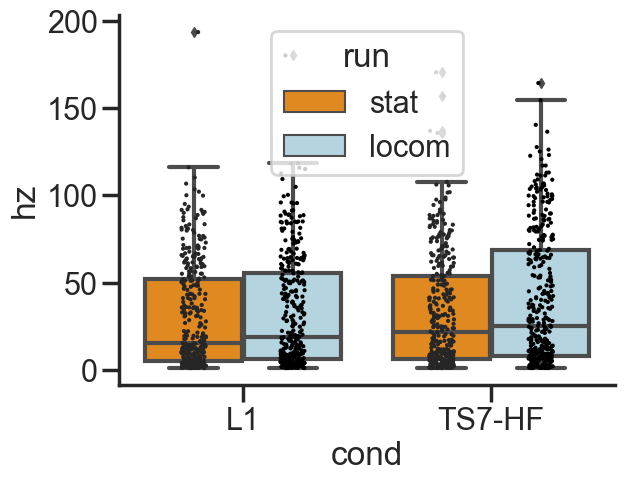

In [96]:
y = 'hz'
cond1 = 'stat'
cond2 = 'locom'
coi = ['L1', 'TS7-HF']
# vis_rec_sess = df_tun_proc[(df_tun_proc.head_fixation == 'VIS') & (df_tun_proc.dir == 0)].rec_session.unique()
# sessions_in = df_betti[(df_betti.cond == 'TS6-HF') & (df_betti.stat_off_manifold > 0.5)].rec_session.unique()

pal = ('darkorange', 'lightblue', 'gold',  'darkblue',)
# _inp_plot = df_tun_proc[ (df_tun_proc.hdc == 1)
#             & (df_tun_proc.rec_session.isin(sessions_in))
#             & ((df_tun_proc.cond == cond1) | (df_tun_proc.cond == cond2))
#             ].groupby([ 'implant', 'cond', 'rec_session','cids' , 'cuid'])[y].max().reset_index()

_inp_plot = df_tun_run_sel[df_tun_run_sel.cond.isin(coi)].groupby([ 'cond', 'rec_id', 'run', 'cids'])[y].max().reset_index()
_inp_plot2 = _inp_plot.pivot(index = ['cond', 'rec_id', 'cids'], columns = 'run', values = y).dropna().reset_index()
_inp_plot3 = pd.melt(_inp_plot2, id_vars = ['cond', 'rec_id', 'cids'], value_vars = ['stat', 'locom'], value_name=y)

sns.boxplot(data=_inp_plot3, x ='cond', y = y, hue = 'run', palette = pal)
sns.stripplot(data=_inp_plot3, x ='cond', y = y, hue = 'run', size = 3,
              dodge = True, palette='dark:black', legend = None)

# plt.xlim(0, 1)
# fname = f'kde_TS6-HF_{y}_{cond1}_{cond2}.pdf'
# plt.savefig(f'boxplot_{coi}_{y}.pdf', transparent=True)

In [97]:
_inp_plot3.groupby(['cond', 'run'])[y].describe()

count       mean        std       min       25%        50%  \
cond   run                                                                 
L1     locom  355.0  32.029590  31.460748  1.012285  5.968426  19.057878   
       stat   355.0  29.983985  30.323453  1.022267  4.941713  15.131687   
TS7-HF locom  365.0  40.396869  37.951632  1.038760  7.674197  25.440079   
       stat   365.0  32.499087  31.558276  1.017937  6.244898  21.741007   

                    75%         max  
cond   run                           
L1     locom  55.424201  180.285012  
       stat   51.919971  193.658537  
TS7-HF locom  68.719969  164.459846  
       stat   53.928571  170.618182

In [98]:
a1 = _inp_plot3[(_inp_plot3.cond == coi[0]) & (_inp_plot3.run == 'stat')][y].values
a2 = _inp_plot3[(_inp_plot3.cond == coi[0]) & (_inp_plot3.run == 'locom')][y].values
b1 = _inp_plot3[(_inp_plot3.cond == coi[1]) & (_inp_plot3.run == 'stat')][y].values
b2 = _inp_plot3[(_inp_plot3.cond == coi[1]) & (_inp_plot3.run == 'locom')][y].values


print(f'test for {y}')
# print(f'# of implntations {_inp_plot.implant.unique().size}')
print(f'# of sessions {coi[0]} {_inp_plot3[_inp_plot3.cond == coi[0]].rec_id.unique().size}')
print(f'# of sessions {coi[1]} {_inp_plot3[_inp_plot3.cond == coi[1]].rec_id.unique().size}')


stat1, pval1 = stats.wilcoxon(a1, a2)
print(f'{coi[0]} stat vs run {stat1} {pval1}')
stat2, pval2 = stats.wilcoxon(b1, b2)
print(f'{coi[1]} stat vs run {stat2} {pval2}')
stat3, pval3 = stats.mannwhitneyu(a1, b1)
print(f'stat  {stat3} {pval3}')
stat4, pval4 = stats.mannwhitneyu(a2, b2)
print(f'run {stat4} {pval4}')
pvals = [pval1, pval2, pval3, pval4]  
print('Benjamini/Hochberg (non-negative)')
print(multipletests(pvals, alpha=0.05, method='fdr_bh'))


test for hz
# of sessions L1 15
# of sessions TS7-HF 15
L1 stat vs run 15957.0 6.377140721077411e-16
TS7-HF stat vs run 10749.0 2.9738911762902935e-29
stat  61395.0 0.2241079620181904
run 56747.0 0.003957888159673389
Benjamini/Hochberg (non-negative)
(array([ True,  True, False,  True]), array([1.27542814e-15, 1.18955647e-28, 2.24107962e-01, 5.27718421e-03]), 0.012741455098566168, 0.0125)


In [164]:
df_tun_proc

,hz,dir,cids,mouse_id,r,p_val,rec_id,dts,probe_conf,vr_env,head_fixation,cuid,rec_session,rec_unit,cond,hdc,implant,dir_adj
0,19.374491,0.0,1.0,JA178,0.492617,0.003,20220818_JA178_lADN_red_H2_R_D1,20220818,H2,D1,na,1-JA178-lADN-0818-D1na,JA178_20220818,JA178_20220818_1.0,D1,1,JA178_lADN,340.0
1,8.332602,20.0,1.0,JA178,0.492617,0.003,20220818_JA178_lADN_red_H2_R_D1,20220818,H2,D1,na,1-JA178-lADN-0818-D1na,JA178_20220818,JA178_20220818_1.0,D1,1,JA178_lADN,320.0
2,3.224077,40.0,1.0,JA178,0.492617,0.003,20220818_JA178_lADN_red_H2_R_D1,20220818,H2,D1,na,1-JA178-lADN-0818-D1na,JA178_20220818,JA178_20220818_1.0,D1,1,JA178_lADN,300.0
3,3.784274,60.0,1.0,JA178,0.492617,0.003,20220818_JA178_lADN_red_H2_R_D1,20220818,H2,D1,na,1-JA178-lADN-0818-D1na,JA178_20220818,JA178_20220818_1.0,D1,1,JA178_lADN,280.0
4,3.191489,80.0,1.0,JA178,0.492617,0.003,20220818_JA178_lADN_red_H2_R_D1,20220818,H2,D1,na,1-JA178-lADN-0818-D1na,JA178_20220818,JA178_20220818_1.0,D1,1,JA178_lADN,260.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13,1.233491,260.0,651.0,JA178,0.057593,0.285,20220909_JA178_rADN_yel_H2_VR1_TS6-VIS,20220909,H2,TS6,VIS,651-JA178-rADN-0909-TS6VIS,JA178_20220909,JA178_20220909_651.0,TS6-VIS,0,JA178_rADN,80.0
14,1.352885,280.0,651.0,JA178,0.057593,0.285,20220909_JA178_rADN_yel_H2_VR1_TS6-VIS,20220909,H2,TS6,VIS,651-JA178-rADN-0909-TS6VIS,JA178_20220909,JA178_20220909_651.0,TS6-VIS,0,JA178_rADN,60.0
15,1.154891,300.0,651.0,JA178,0.057593,0.285,20220909_JA178_rADN_yel_H2_VR1_TS6-VIS,20220909,H2,TS6,VIS,651-JA178-rADN-0909-TS6VIS,JA178_20220909,JA178_20220909_651.0,TS6-VIS,0,JA178_rADN,40.0
16,1.110932,320.0,651.0,JA178,0.057593,0.285,20220909_JA178_rADN_yel_H2_VR1_TS6-VIS,20220909,H2,TS6,VIS,651-JA178-rADN-0909-TS6VIS,JA178_20220909,JA178_20220909_651.0,TS6-VIS,0,JA178_rADN,20.0


#### Two way ANOVA

                      sum_sq      df         F    PR(>F)
C(cond)         1.044675e+04     1.0  9.554121  0.002033
C(run)          6.429256e+03     1.0  5.879907  0.015437
C(cond):C(run)  2.393793e+03     1.0  2.189255  0.139196
Residual        1.567976e+06  1434.0       NaN       NaN
Check normality of residuals
Shapiro-Wilk test for normality: ShapiroResult(statistic=0.8762833476066589, pvalue=2.5202919203840443e-32)
Check homoscedasticity
LeveneResult(statistic=5.470583122692447, pvalue=0.0009729691393211972)


Text(0.5, 1.0, 'Residuals vs. Fitted Plot')

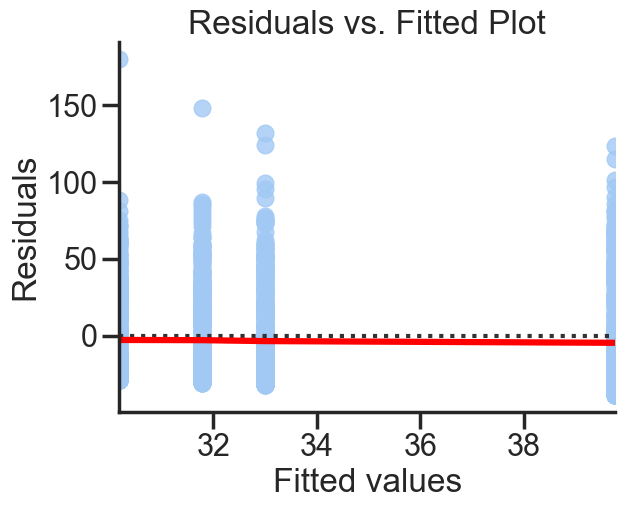

In [255]:
# Create a DataFrame with your data
df = _inp_plot3[['cond', 'run', y]]
group_val = df.groupby(['cond', 'run'])[y].apply(list)
# Fit the ANOVA model
formula = f'{y} ~ C(cond) + C(run) + C(cond):C(run)'
model = ols(formula, data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

# Display the ANOVA table
print(anova_table)

print('Check normality of residuals') 
residuals = model.resid
shapiro_test = shapiro(residuals)
print(f"Shapiro-Wilk test for normality: {shapiro_test}")

# # Check homoscedasticity
# _, p_value, _, _ = het_breuschpagan(residuals, df[['cond', 'run']])
# print(f"Homoscedasticity test (Breusch-Pagan): p-value = {p_value}")

print('Check homoscedasticity') 
print(stats.levene(group_val[0], group_val[1], group_val[2], group_val[3]))

# Residuals vs. Fitted Plot
sns.residplot(x=model.fittedvalues, y=residuals, lowess=True, line_kws={'color': 'red'})
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted Plot')


#### Post hoc Tukey

In [256]:
_inp_plot3.pairwise_tukey(dv = y, between='cond_run').round(3)

,A,B,mean(A),mean(B),diff,se,T,p-tukey,hedges
0,L1_locom,L1_stat,31.789,30.180,1.609,2.485,0.647,0.917,0.052
1,L1_locom,TS7-HF_locom,31.789,39.761,-7.972,2.467,-3.232,0.007,-0.231
2,L1_locom,TS7-HF_stat,31.789,32.991,-1.202,2.467,-0.487,0.962,-0.038
3,L1_stat,TS7-HF_locom,30.180,39.761,-9.581,2.467,-3.884,0.001,-0.279
4,L1_stat,TS7-HF_stat,30.180,32.991,-2.811,2.467,-1.139,0.665,-0.089
5,TS7-HF_locom,TS7-HF_stat,39.761,32.991,6.770,2.448,2.766,0.029,0.194


meta NOT subset; don't know how to subset; dropped


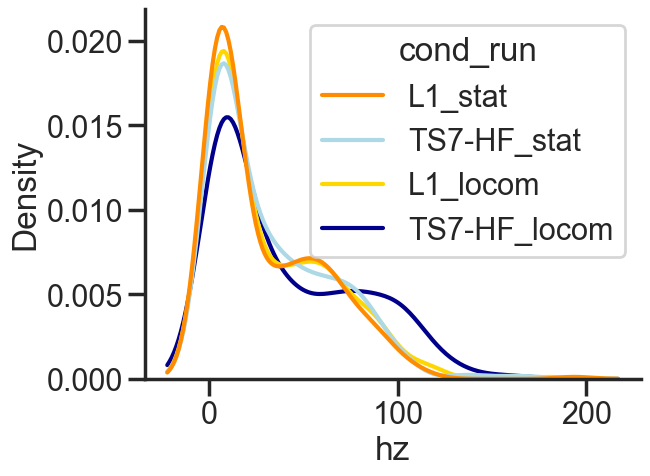

In [100]:
y = 'hz'
cond1 = 'stat'
cond2 = 'locom'

# vis_rec_sess = df_tun_proc[(df_tun_proc.head_fixation == 'VIS') & (df_tun_proc.dir == 0)].rec_session.unique()
# sessions_in = df_betti[(df_betti.cond == 'TS6-HF') & (df_betti.stat_off_manifold > 0.5)].rec_session.unique()

pal = ('darkorange', 'lightblue', 'gold',  'darkblue',)
# _inp_plot = df_tun_proc[ (df_tun_proc.hdc == 1)
#             & (df_tun_proc.rec_session.isin(sessions_in))
#             & ((df_tun_proc.cond == cond1) | (df_tun_proc.cond == cond2))
#             ].groupby([ 'implant', 'cond', 'rec_session','cids' , 'cuid'])[y].max().reset_index()

_inp_plot = df_tun_run_sel[df_tun_run_sel.cond.isin(coi)].groupby(['cond', 'cond_run', 'rec_id',
                                                        'rec_session', 'run', 'cids'])[y].max().reset_index()
_inp_plot2 = _inp_plot.pivot(index = ['cond', 'rec_id', 'cids'], columns = 'run', values = y).dropna().reset_index()
_inp_plot3 = pd.melt(_inp_plot2, id_vars = ['cond', 'rec_id', 'cids'], value_vars = ['stat', 'locom'], value_name = y)
_inp_plot3['cond_run'] = _inp_plot3['cond'] + '_' + _inp_plot3['run']


sns.kdeplot(x = y, data = _inp_plot3, hue = 'cond_run',  fill=False, 
            cumulative=False, common_grid=True,
           common_norm = False, legend = True, 
#             cut = 0,
            palette = pal)


# plt.xlim(0, 1)
# fname = f'kde_TS6-HF_{y}_{cond1}_{cond2}.pdf'
plt.savefig(f'kde_{coi}_{y}.pdf', transparent=True)

In [205]:
_inp_plot3.groupby('cond_run')[y].describe()

,count,mean,std,min,25%,50%,75%,max
cond_run,,,,,,,,
L1_locom,354.0,31.789100,31.259930,1.051664,5.839209,18.081360,54.362328,180.211982
L1_stat,354.0,30.180392,30.792262,1.028169,5.090538,14.753077,53.056982,210.250000
TS7-HF_locom,365.0,39.761123,37.363657,1.024806,7.579646,25.083582,68.374429,163.106132
TS7-HF_stat,365.0,32.990929,32.317494,1.000000,6.666667,21.748571,53.835294,165.000000


In [208]:
a = _inp_plot3[_inp_plot3.cond_run == 'L1_stat'][y].values
a1 = _inp_plot3[_inp_plot3.cond_run == 'L1_locom'][y].values

b = _inp_plot3[_inp_plot3.cond_run == 'TS7-HF_stat'][y].values
b1 = _inp_plot3[_inp_plot3.cond_run == 'TS7-HF_locom'][y].values
print(f'test for {y}')
# print(f'# of implntations {_inp_plot.implant.unique().size}')
print(f'# of sessions {_inp_plot3.rec_id.unique().size/2}')
print(f'# of units in L1 {a.size}')
print(f'# of units in TS7-HF {b.size}')
print('stat vs run')
print(stats.wilcoxon(a, a1))
print(stats.wilcoxon(b, b1))
print('stat vs stat, run vs run')
print(stats.mannwhitneyu(a, b))
print(stats.mannwhitneyu(a1, b1))

test for hz
# of sessions 15.0
# of units in L1 354
# of units in TS7-HF 365
stat vs run
WilcoxonResult(statistic=19264.0, pvalue=2.8329137190217447e-10)
WilcoxonResult(statistic=14959.0, pvalue=6.197587406752201e-20)
stat vs stat, run vs run
MannwhitneyuResult(statistic=60870.5, pvalue=0.17989849444585504)
MannwhitneyuResult(statistic=56895.0, pvalue=0.0056251116668405024)


array([ 0.13  , -0.0067,  0.237 , ...,  0.1665,  0.3762,  0.3446])

rec_id
20220627_MC022_lADN_red_H2_R_L1          0.053077
20220627_MC022_lADN_red_H2_VR1_TS6-HF    0.076359
20220627_MC022_lADN_red_H2_VR1_TS7-HF    0.185664
20220628_MC022_lADN_red_H2_R_L1          0.097624
20220628_MC022_lADN_red_H2_VR1_TS6-HF    0.154367
                                           ...   
20220907_JA178_rADN_yel_H2_VR1_TS7-HF    0.364026
20220908_JA178_rADN_yel_H2_R_L1          0.145074
20220908_JA178_rADN_yel_H2_VR1_TS6-HF    0.982796
20220909_JA178_rADN_yel_H2_R_L1          0.001066
20220909_JA178_rADN_yel_H2_VR1_TS6-HF    0.222531
Name: run_gain, Length: 93, dtype: float64

0.07635859450342594

### Plot tuning stat vs run

In [1]:
from pylr2 import regress2

In [839]:
_inp_plot['condition'] = _inp_plot['cond'].str.split('_', expand = True)[0]
_inp_plot['cuid'] = _inp_plot.rec_session + '_' +  _inp_plot.cids.astype(str) + '_' +  _inp_plot['condition']
_inp_plot['implant'] = _inp_plot.rec_id.str.split('_', expand = True)[1] + '_' + _inp_plot.rec_id.str.split('_', expand = True)[2]

meta NOT subset; don't know how to subset; dropped


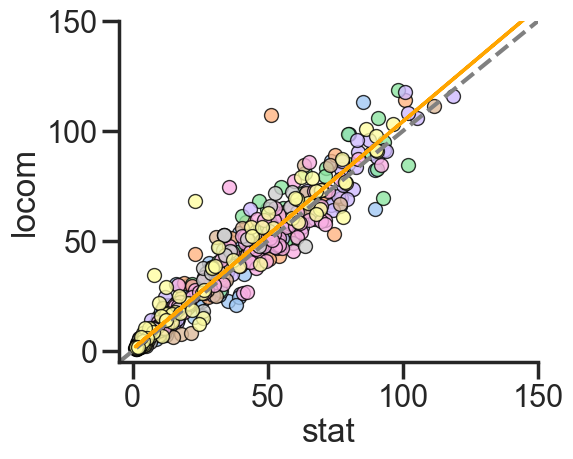

In [846]:
coi = ['stat', 'locom']
y = 'hz'
unity_line = [-5, 150]
_inp_plot2 = _inp_plot[_inp_plot.cond.str.contains('L1')].pivot(index = ['implant', 'rec_id', 'cuid'], 
                                             columns = 'run', values = y).reset_index().dropna()

# sns.scatterplot(data = _inp_plot2, x = coi[0], y = coi[1], hue = 'rec_id', legend = False,
#                 edgecolor = 'k', alpha = 1, size = 1
#             )
# Generate a dataset
xreg = _inp_plot2['stat'].values
yreg = _inp_plot2['locom'].values
# Compute regression type 2
results = regress2(xreg, yreg, _method_type_2="reduced major axis")
a = results['intercept']
b = results['slope']

sns.lmplot(data = _inp_plot2, x = coi[0], y = coi[1], aspect = 1.2, hue = 'implant',
           scatter_kws={"s": 100, 'edgecolor':"black"}, legend = None, fit_reg = False,
#            line_kws={'color': 'lightblue'},
#            col = 'rec_id', col_wrap=3, 
          )

plt.plot(unity_line, unity_line, ls = '--', c = 'gray')
plt.plot(xreg, a + b * xreg, color = "orange", lw=2.5);
plt.xlim(-5, 150)
plt.ylim(-5, 150)
# plt.savefig(f'lmplot_L1_{y}_{coi[0]}_{coi[1]}.png', dpi = 300 , transparent=True)
# plt.savefig(f'lmplot_L1_{y}_{coi[0]}_{coi[1]}.pdf', transparent=True)

In [580]:
_inp_plot = df_tun_loc[df_tun_loc.cond.str.contains('TS6-HF')].groupby([ 'cond', 'rec_id',
                                                        'rec_session', 'run', 'cids'])[y].max().reset_index()
_inp_plot['condition'] = _inp_plot['cond'].str.split('_', expand = True)[0]
_inp_plot['cuid'] = _inp_plot.rec_session + '_' +  _inp_plot.cids.astype(str) + '_' +  _inp_plot['condition']

In [312]:
def label_pnt_change(value):
    if value < -20:
        return "<-20"
    if -20 <= value < 0:
        return "-20-0"
    if 0 <= value < 20:
        return "0-20"
    elif 20 <= value < 40:
        return "20-40"
    elif value >= 40:
        return ">40"

In [588]:
out_df['fr_pnt_change'] = (out_df['run'] - out_df['stat'])/out_df['stat']*100
out_df['pnt_group'] = out_df['fr_pnt_change'].map(label_pnt_change)
out_df.head()

,run,stat,diff,fr_pnt_change,pnt_group
0,170.518717,149.752560,20.766157,13.866980,0-20
1,157.994318,103.750000,54.244318,52.283680,>40
2,126.072977,76.067468,50.005509,65.738364,>40
3,123.741150,82.007692,41.733458,50.889687,>40
4,123.028846,118.821429,4.207418,3.540959,0-20


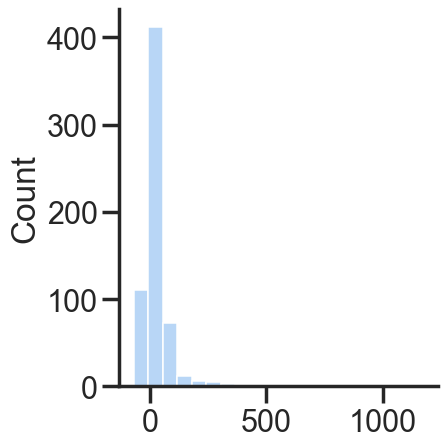

In [589]:
sns.displot(out_df['fr_pnt_change'].values, bins = 20)

<Axes: xlabel='pnt_group', ylabel='prop'>

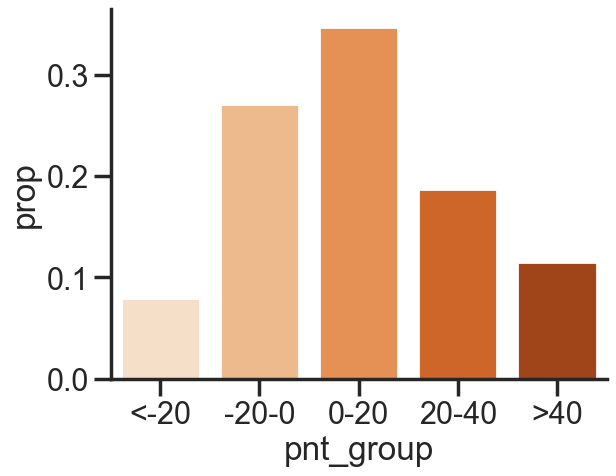

In [585]:
to_plot = out_df.groupby('pnt_group').count().reset_index()
to_plot['prop'] = to_plot['fr_pnt_change']/to_plot['fr_pnt_change'].sum()
sns.barplot(data = to_plot, x = 'pnt_group', y = 'prop', palette='Oranges',
            order = ['<-20', '-20-0', '0-20', '20-40', '>40'] )
# plt.savefig(f'barplot_L1_run_fr_prnt_change.pdf', transparent=True)

(626, 2)


<Axes: >

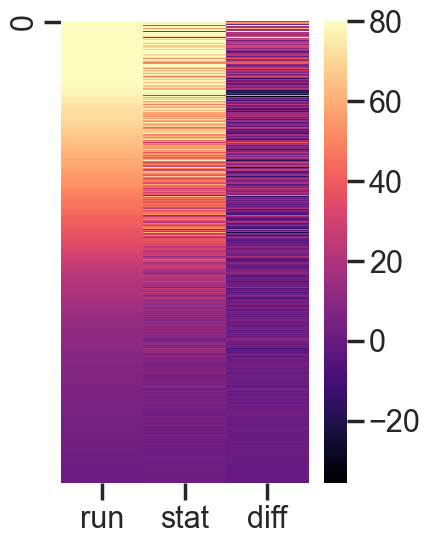

In [586]:
fr_arr = _inp_plot.pivot(index = 'cuid', columns = 'run', values = 'hz').dropna().values
print(fr_arr.shape)
d_fr = fr_arr[:, 0] - fr_arr[:, 1]
f, ax = plt.subplots(figsize = (4, 6))

out = np.vstack((fr_arr.T, d_fr))
out_df = pd.DataFrame(out.T, columns = ['run', 'stat', 'diff'])
out_df = out_df.sort_values(by = 'run', ascending=False).reset_index(drop = True)
sns.heatmap(out_df, cmap = 'magma', yticklabels = 1000, vmax = 80)

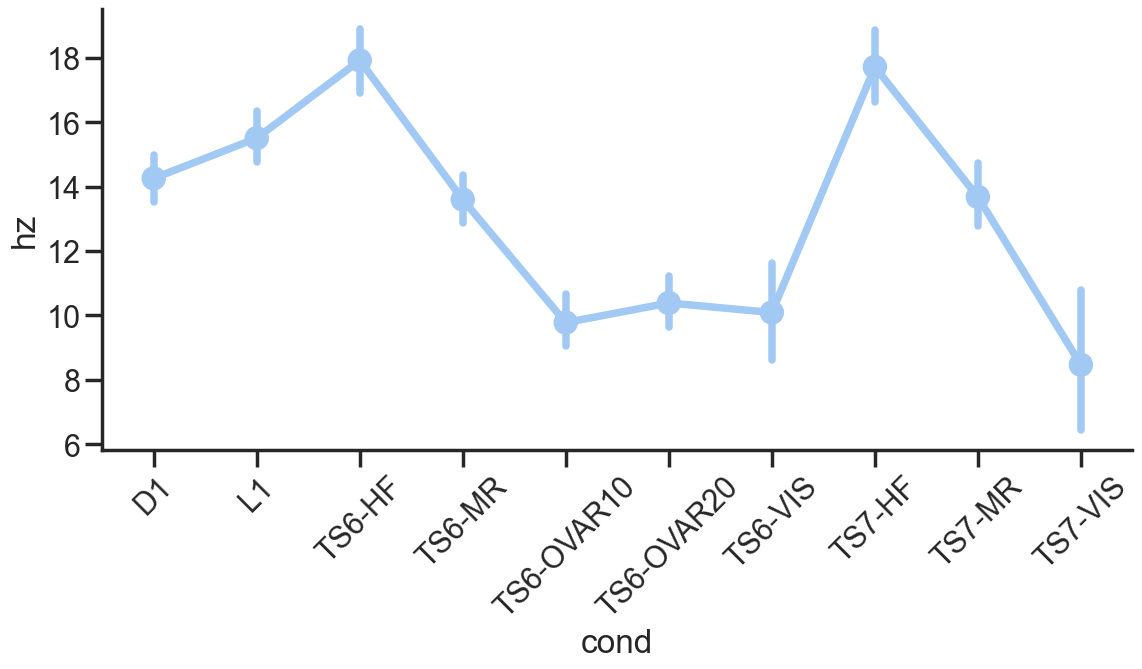

In [30]:
y = 'hz'
coi = ['D1', 'L1', 'TS6-HF', 'TS6-MR', 'TS7-MR', 'TS7-HF',
        'TS6-OVAR20', 'TS6-OVAR10', 'TS7-VIS',  'TS6-VIS', ]

_inp = df_tun_proc[df_tun_proc.cond.isin(coi)].groupby([ 'cond', 'cuid'])[y].max().reset_index()
o
plot = sns.catplot(x = 'cond', y = y,   data = _inp, kind = 'point', errorbar=('ci', 95),
#                    color = '0.9', inner = None, 
#                cut = 0, split = True, 
                      height = 6, aspect = 2)

for axes in plot.axes.flat:
    _ = axes.set_xticklabels([t.get_text().split(" ")[0] for t in axes.get_xticklabels()], rotation=45)

In [24]:
len(good_arena_sessions)

28

In [344]:
d_hfdat.keys()

dict_keys(['20220818_JA178_lADN_red_H2_VR1_TS6-HF', '20220819_JA178_lADN_red_H2_VR1_TS6-HF', '20220819_JA178_lADN_red_H2_VR1_TS7-HF', '20220823_JA178_lADN_red_H2_VR1_TS6-HF', '20220823_JA178_lADN_red_H2_VR1_TS7-HF', '20220823_JA178_lADN_red_H2_VR1_TS7-HFLMK', '20220824_JA178_lADN_red_H2_VR1_TS6-HF', '20220824_JA178_lADN_red_H2_VR1_TS6-HFLMK180', '20220824_JA178_lADN_red_H2_VR1_TS7-HF', '20220902_JA178_rADN_yel_H2_VR1_TS6-HF', '20220902_JA178_rADN_yel_H2_VR1_TS7-HF', '20220906_JA178_rADN_yel_H2_VR1_TS6-HF', '20220907_JA178_rADN_yel_H2_VR1_TS6-HF', '20220907_JA178_rADN_yel_H2_VR1_TS7-HF', '20220908_JA178_rADN_yel_H2_VR1_TS6-HF', '20220908_JA178_rADN_yel_H2_VR1_TS6-HFLMK30', '20220908_JA178_rADN_yel_H2_VR1_TS6-VIS', '20220909_JA178_rADN_yel_H2_VR1_TS6-HF', '20220909_JA178_rADN_yel_H2_VR1_TS6-VIS', '20220802_JA179_lADN_red_H2_VR1_TS6-HF', '20220802_JA179_lADN_red_H2_VR1_TS7-HF', '20220803_JA179_lADN_red_H2_VR1_TS6-HF', '20220803_JA179_lADN_red_H2_VR1_TS7-HF', '20220804_JA179_lADN_red_H2_VR

#### dPref in RPL

In [162]:
# ls_df = []
# for rec in _inp.rec_session.unique():
#     _inp2 = _inp[_inp.rec_session == rec]
#     hf_pref = _inp2[(_inp2.rec_unit.isin(com_ar)) 
#                     & (_inp2.cond == cond1)].pref_dir*20
#     mr_pref = _inp2[(_inp2.rec_unit.isin(com_ar)) 
#                     & (_inp2.cond == cond2)].pref_dir*20

#     ls = []
#     ls2 = []
#     for each in itertools.combinations(hf_pref, 2):
#         ls.append(ang_diff(each[0], each[1]))

#     for each in itertools.combinations(mr_pref, 2):
#         ls2.append(ang_diff(each[0], each[1]))

#     # delta_pref = ang_diff(ls, ls2)
#     # ls3.append(np.mean(delta_pref))

#     df_tmp = pd.DataFrame({ 'idx': np.arange(len(ls)), 'hf': ls, 'mr': ls2, 'rec':rec })
#     ls_df.append(df_tmp)

# df_dpref = pd.concat(ls_df)
    

AttributeError: 'DataFrame' object has no attribute 'rec_unit'

In [225]:
30/518

0.05791505791505792

In [1636]:
np.sum(ls_n1), np.sum(ls_n2), np.sum(ls_n3)

(146, 6, 6)

meta NOT subset; don't know how to subset; dropped


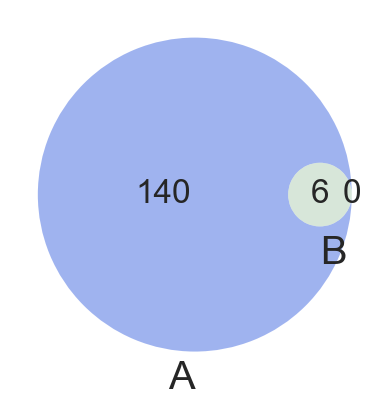

In [1640]:
v = venn2(subsets = (np.sum(ls_n1) - np.sum(ls_n3) , np.sum(ls_n2) - np.sum(ls_n3), np.sum(ls_n3)), 
#           set_labels = ("", ""), 
          set_colors = ('royalblue', sns.color_palette("tab10")[8] ), alpha = 0.5)

plt.savefig(f'venn2_{cond1}_{cond2}.pdf', transparent=True)

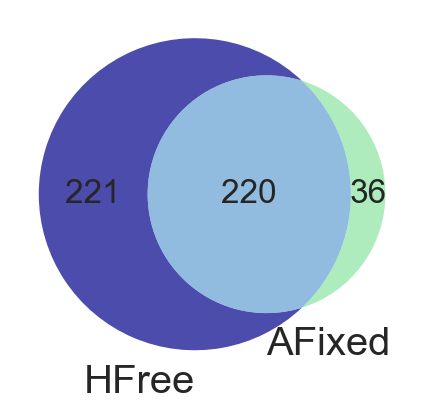

In [335]:
v = venn2(subsets = (221 , 36, 220), 
#           set_labels = (cond1, cond2), 
          set_labels = ('HFree', 'AFixed'), 
          set_colors = ('darkblue', current_palette[2]), alpha = 0.7)

# plt.savefig('venn2_hd-hfvis.pdf', transparent=True)

#### Delta pref dir

## Off-ring manifold dynamics

In [ ]:

from typing import Union, List
def circular_distance(angle1: np.ndarray, angle2: float) -> np.ndarray:
    """
    Compute the minimum angular distance between two angles on a circle.
    All angles in degrees. Returns values in [0, 180].
    """
    diff = np.abs(angle1 - angle2) % 360
    return np.minimum(diff, 360 - diff)


def split_hdc_by_heading(
    pref_directions: Union[list, np.ndarray],
    current_heading: float,
    bin1_thresh: float = 45.0,
    bin2_thresh: float = 90.0,
    antipodal_half_width: float = 45.0,
) -> dict:
    """
    Split HDCs into 3 groups based on angular offset from current heading.

    Groups:
        Group 1 - Preferred (on-bump):     offset <= bin1_thresh          [0, 45°]
        Group 2 - Flanking (shoulder):     bin1_thresh < offset <= bin2_thresh  (45°, 90°]
        Group 3 - Antipodal (off-bump):    offset >= (180 - antipodal_half_width)  [135°, 180°]

    Note: cells with offsets in (90°, 135°) are not assigned to any group by default.
    You can change bin2_thresh and antipodal_half_width to make the bins contiguous (e.g.,
    bin2_thresh=135, antipodal_half_width=45 gives 3 contiguous bins of 45° each on each side).

    Parameters
    ----------
    pref_directions : array-like
        Preferred firing directions of each HDC, in degrees [0, 360).
    current_heading : float
        Animal's mean head direction during the epoch, in degrees [0, 360).
    bin1_thresh : float
        Upper bound of the preferred (on-bump) group in degrees. Default 45°.
    bin2_thresh : float
        Upper bound of the flanking group in degrees. Default 90°.
    antipodal_half_width : float
        Half-width of the antipodal bin around 180°. Default 45° → [135°, 180°].

    Returns
    -------
    dict with keys:
        'offsets'     : np.ndarray, angular offset of each cell from current heading [0, 180°]
        'group1_idx'  : np.ndarray, indices of preferred (on-bump) cells
        'group2_idx'  : np.ndarray, indices of flanking cells
        'group3_idx'  : np.ndarray, indices of antipodal cells
        'unassigned_idx': np.ndarray, indices of cells not in any group
        'labels'      : np.ndarray of str, group label for each cell
    """
    pref_directions = np.asarray(pref_directions, dtype=float)
    offsets = circular_distance(pref_directions, current_heading)

    antipodal_lower = 180.0 - antipodal_half_width

    group1_idx = np.where(offsets <= bin1_thresh)[0]
    group2_idx = np.where((offsets > bin1_thresh) & (offsets <= bin2_thresh))[0]
    group3_idx = np.where(offsets >= antipodal_lower)[0]
    unassigned_idx = np.where(
        (offsets > bin2_thresh) & (offsets < antipodal_lower)
    )[0]

    labels = np.full(len(pref_directions), "unassigned", dtype=object)
    labels[group1_idx] = "preferred"
    labels[group2_idx] = "flanking"
    labels[group3_idx] = "antipodal"

    return {
        "offsets": offsets,
        "group1_idx": group1_idx,
        "group2_idx": group2_idx,
        "group3_idx": group3_idx,
        "unassigned_idx": unassigned_idx,
        "labels": labels,
    }


def split_hdc_contiguous(
    pref_directions: Union[list, np.ndarray],
    current_heading: float,
) -> dict:
    """
    Convenience wrapper using contiguous 60° bins covering the full 180°:
        Group 1 - Preferred:   [0°,  60°]
        Group 2 - Flanking:    (60°, 120°]
        Group 3 - Antipodal:   (120°, 180°]

    All cells are assigned; no unassigned group.
    """
    return split_hdc_by_heading(
        pref_directions=pref_directions,
        current_heading=current_heading,
        bin1_thresh=60.0,
        bin2_thresh=120.0,
        antipodal_half_width=60.0,
    )



In [18]:
df_emb_hdc.head()

NameError: name 'df_emb_hdc' is not defined

In [ ]:

df_pref_hf.head()

20220804_JA179_lADN_red_H2_VR1_TS7-HF
20220804_JA179_lADN_red_H2_VR1_TS7-HF, ep idx: 12, circmean 23.06114121839955, circstd 0.08536756988182398
len 125, std: 13.94, idx: 1420 - 1520
(6, 100) (17, 100)
pref HDC 0.9152268743830443 non pref HDC -0.6261831531012284
rand pref HDC 0.20972350364314032



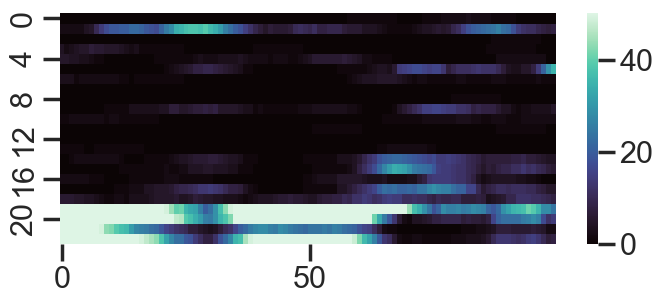

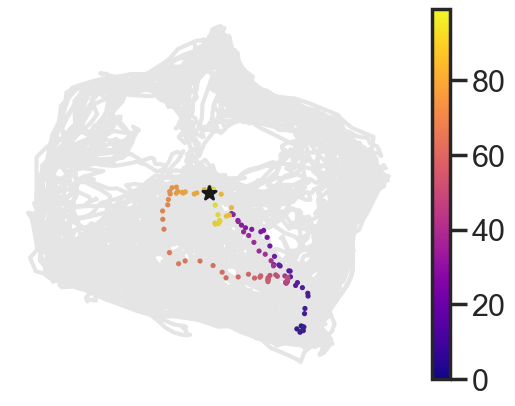

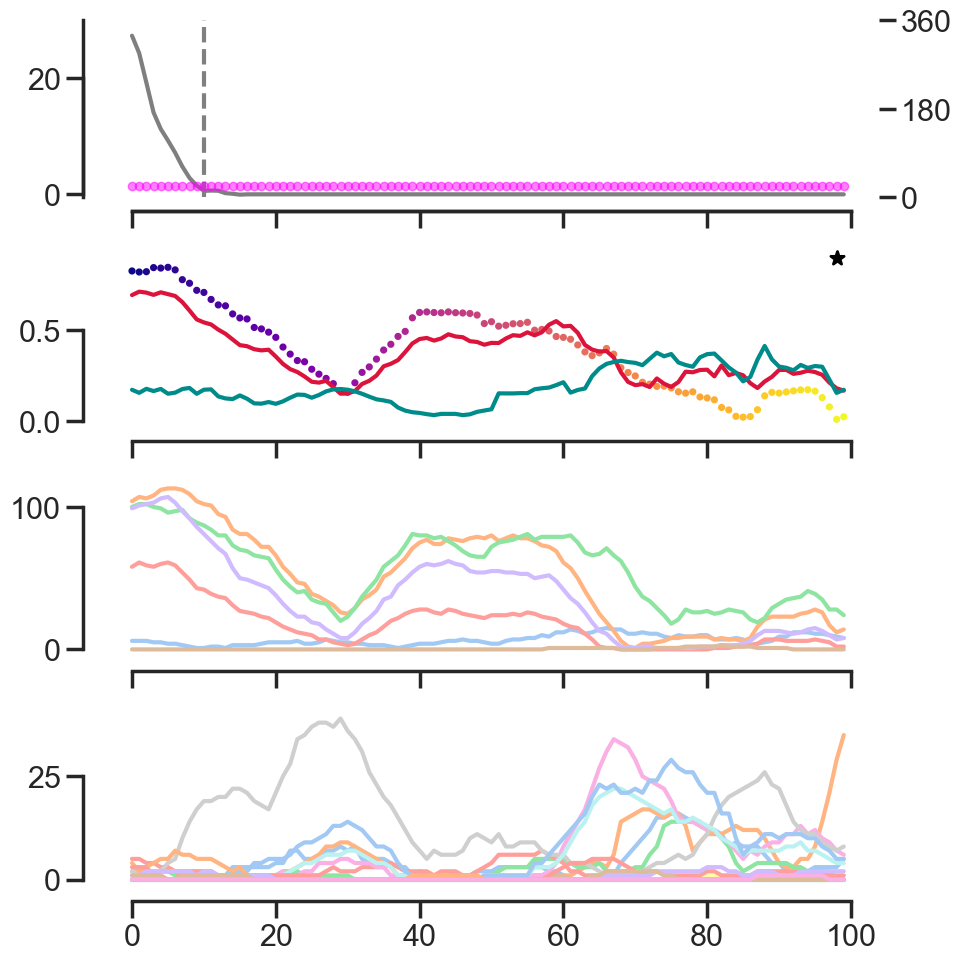

In [28]:
ls_pref, ls_nonpref, ls_rand = [], [], []
ls_df = []
pref_dir_thr = 45
speed_thr = 5
ep_offset = 10
to_plot = True
# 10s
ep_min_dur, ep_max_dur = 30, 100

for k in df_emb_hdc.rec_id.unique():
    if 'TS7-HF' not in k:
        continue
    if '20220804_JA179' not in k:
        continue
    print(k)
    dts, mouse_id, hem, hstripe, cond, rec_session = get_recinfo_fname(k)
    if 'l' in hem:
        hem = 'left'
    else:
        hem = 'right'
    implant = mouse_id + '_' + hem
        
    tmp_df = df_emb_hdc[(df_emb_hdc.rec_id == k)]
    # for k in d_manifold_master.keys():
    emb_x, emb_y = tmp_df['emb_x'].values, tmp_df['emb_y'].values
    lin_speed = d_emb[k]['lin_vel']
    stat_idx, run_idx = get_stat_run_epochs(lin_speed, window_size=5, speed_thr = speed_thr)
    # get stat epochs
    stat_epoch = consecutive(stat_idx)

    measured_yaw = tmp_df['measured_yaw'].values
    # compute off manifold ratios
    run_mask = np.zeros(lin_speed.size, dtype=bool)
    run_mask[run_idx] = True

    # new function to compute rad
    cxy, rad_manifold = compute_radius(emb_x, emb_y, run_mask)
    rad_manifold_norm = rad_manifold/rad_manifold.max()
    
    tmp_ephys =  d_master[k]['ephys']

    # find hdc ids for this rec
    hdc_units = df_pref_hf[df_pref_hf.rec_id == k].cids.values
    pref_dir = df_pref_hf[df_pref_hf.rec_id == k].dir.values
    sorted_pref_dir = np.argsort(pref_dir)
    tmp_ephys_sel = tmp_ephys[tmp_ephys.cids.isin(hdc_units)]
    offman_ep_flag = False
    
    for ep_idx, ep in enumerate(stat_epoch):
        # at least 3s and no change in az
        if (len(ep) > ep_min_dur):
            if ep_idx != 12:
                continue
            start, end = ep[0] - ep_offset, ep[:][-1]+1
            if start < 0:
                continue
                 
            if ep.size > ep_max_dur:
                end = start + ep_max_dur
            # check that ring radius changes in epoch
            this_man_rad = rad_manifold_norm[start:end]
            if this_man_rad.max() - this_man_rad.min() > 0.2:
                offman_ep_flag = True
            else:
                print('no chnages in man rad')
                continue
       
            # check that az doe snot change before and during epoch
            angles = np.deg2rad(measured_yaw[start:end])
            circmean = stats.circmean(angles)
            circstd = stats.circstd(angles)
            circstd = np.rad2deg(circstd)
            this_yaw = np.rad2deg(circmean)
            if circstd > 1:
                print(f'high circ std {circstd}')
                continue
            print(f'{k}, ep idx: {ep_idx}, circmean {this_yaw}, circstd {circstd}')
            print(f'len {len(ep)}, std: {round(np.std(measured_yaw[ep]), 2)}, idx: {start} - {end}')
            
            # get hdc preferring this yaw
            pref_idx = ang_diff(pref_dir, this_yaw) <= pref_dir_thr
            if sum(pref_idx) < 3:
                print(f'few pref HDC {pref_idx.size}')
                continue
            non_pref_idx = ang_diff(pref_dir, this_yaw) > pref_dir_thr 

            _inp = tmp_ephys_sel.pivot(index = 'cids', columns = 'times', values = 'hz').values[:, ::5][:, start:end]
            _inp_hdc = tmp_ephys_sel[tmp_ephys_sel.cids.isin(hdc_units[pref_idx])].pivot(index = 'cids', 
                                         columns = 'times', values = 'hz').values[:, ::5][:, start:end]
            _inp_nonhdc = tmp_ephys_sel[tmp_ephys_sel.cids.isin(hdc_units[non_pref_idx])].pivot(index = 'cids', 
                                         columns = 'times', values = 'hz').values[:, ::5][:, start:end]


            # to calculate corrs
            _inp_norm = _inp[:, :]/(_inp.max(axis = 1) + 1e-9)[:,np.newaxis]
            _inp_hdc_norm = _inp_hdc[:, :]/(_inp_hdc.max(axis = 1) + 1e-9)[:,np.newaxis]
            _inp_nonhdc_norm = _inp_nonhdc[:, :]/(_inp_nonhdc.max(axis = 1) + 1e-9)[:,np.newaxis]
            
            ring_minrad_idx = this_man_rad.argmin()
            ring_maxrad_idx = this_man_rad.argmax()
            print(_inp_hdc.shape, _inp_nonhdc_norm.shape)
            hdc_vec = _inp_hdc_norm.sum(axis = 0)
            hdc_gain = hdc_vec/hdc_vec.max()
            nonhdc_vec = _inp_nonhdc_norm.sum(axis = 0)
            nonhdc_gain = nonhdc_vec/nonhdc_vec.max()
            
            # shuffled population
            ls_rand = []
            for i in range(20):
                rand_n = np.random.randint(3, hdc_units.size//2)
                rand_units = np.random.choice(hdc_units, size = rand_n)
                _inp_rand = tmp_ephys_sel[tmp_ephys_sel.cids.isin(rand_units)].pivot(index = 'cids', 
                                                             columns = 'times', values = 'hz').values[:, ::5][:, start:end]
                _inp_rand_norm = _inp_rand[:, :]/(_inp_rand.max(axis = 1) + 1e-9)[:,np.newaxis]
                if np.sum(_inp_rand_norm) < 1:
                    continue
                rand_vec = _inp_rand_norm.sum(axis = 0)
                rand_gain = rand_vec/rand_vec.max()
                r_rand, pval = stats.pearsonr(this_man_rad, rand_gain)
                ls_rand.append(r_rand)
            
            hdc_gain = _inp_hdc_norm.mean(axis = 0)
            nonhdc_gain = _inp_nonhdc_norm.mean(axis = 0)
            r_hdc, pval = (stats.pearsonr(this_man_rad, hdc_gain[:]))
            r_nonhdc, pval = (stats.pearsonr(this_man_rad, nonhdc_gain[:]))
            print(f'pref HDC {r_hdc} non pref HDC {r_nonhdc}')
            print(f'rand pref HDC {np.mean(ls_rand)}')
            
            if to_plot == True:
                # to plot
                # all_hdc = tmp_ephys_sel[(tmp_ephys_sel.times < end*5/50) & (tmp_ephys_sel.times > start*5/50)].pivot(index = 'cids', 
                #                          columns = 'times', values = 'hz')
                
                # _inp_norm = _inp[:, start:end]/_inp.max(axis = 1)[:,np.newaxis]
                # _inp_hdc_norm = _inp_hdc[:, start:end]/_inp_hdc.max(axis = 1)[:,np.newaxis]
                # _inp_nonhdc_norm = _inp_nonhdc[:, start:end]/_inp_nonhdc.max(axis = 1)[:,np.newaxis]
                # hdc_vec = _inp_hdc_norm.sum(axis = 0)
                # hdc_gain = hdc_vec/hdc_vec.max()
                # nonhdc_vec = _inp_nonhdc_norm.sum(axis = 0)
                # nonhdc_gain = nonhdc_vec/nonhdc_vec.max()
            
                f, ax = plt.subplots(1, figsize = (8, 3))
                sns.heatmap(_inp[(sorted_pref_dir[::-1])], cmap = 'mako', xticklabels=50, vmax = 50)
                # ax_1 = ax.twinx()
                # ax_1.plot( lin_speed[start:end],  color = 'gray', label = 'lin speed', alpha = 1)
                # ax_1.set_yticks([0, 15, 30])
                # ax_2 = ax.twinx()
                # ax_2.plot( measured_yaw[start:end],  color = 'magenta', label = 'yaw', alpha = 0.75)
                # ax_2.set_yticks([0, 180, 360])
#                 plt.savefig(f'heatmap_hdc_{k}_{ep_idx}.pdf', transparent = True)

                filepath = save_dir / f'heatmap_hdc_{k}_{ep_idx}_.pdf'
                plt.savefig(filepath, transparent = True)
                
                f, ax = plt.subplots()
                x_tmp, y_tmp = emb_x[start:end], emb_y[start:end]
                u = np.diff(x_tmp)
                v = np.diff(y_tmp)
                pos_x = x_tmp[:-1] + u/2
                pos_y = y_tmp[:-1] + v/2
                norm = np.sqrt(u**2+v**2) 
                plt.plot(emb_x, emb_y, c = 'gray', alpha = 0.2)
    #             plt.scatter(x_tmp[:], y_tmp[:], alpha = 1, s = 10,  c = x_time, cmap = 'afmhot', vmax = 400)
    #             plt.colorbar()
                plt.scatter(x_tmp[:], y_tmp[:], alpha = 1, s = 3,  c = np.arange(0, x_tmp.size)[:], 
                            cmap = 'plasma')

                plt.colorbar()
    #             plt.quiver(pos_x[::10], pos_y[::10], (u/norm)[::10], (v/norm)[::10], angles="xy", 
    #                        zorder=5, pivot="mid", alpha = 0.5 )
                plt.scatter(emb_x[start + ring_minrad_idx], emb_y[start + ring_minrad_idx], c = 'k', s = 100, marker = "*")
                plt.axis('off')

                filepath = save_dir / f'scatter_isomap-traj_{k}_{ep_idx}_.pdf'
                plt.savefig(filepath, transparent = True)
                
                f, ax = plt.subplots(4, figsize = (10, 10), sharex = 'col')
                x_time = np.arange(0, x_tmp.size)
                sorted_idx = np.argsort(pref_dir[pref_idx])
    #             sns.heatmap(_inp_hdc_norm[sorted_idx[::-1]], cmap = 'mako', xticklabels = 50,
    #                         yticklabels = 5, vmin = 0, vmax = 1, ax  = ax[1], cbar = False
    # #                         cbar_kws = dict(use_gridspec=False, location = "top")
    #                        )
    #             sorted_idx = np.argsort(pref_dir[non_pref_idx])
    #             sns.heatmap(_inp_nonhdc_norm[sorted_idx[::-1]], cmap = 'mako', xticklabels = 50,
    #                         yticklabels = 5, vmin = 0, vmax = 0.5, ax  = ax[2], cbar = False)
                # d_pref_groups = split_hdc_by_heading(pref_dir, np.rad2deg(circmean))
                # group_hdc_ls = ['group1_idx', 'group2_idx', 'group3_idx']
                # gr_c = ['crimson', 'darkcyan', 'brown']
                
                for i in range(_inp_hdc
                    .shape[0]):
                    ax[2].plot(_inp_hdc[i, :])
            
                for i in range(_inp_nonhdc.shape[0]):
                    ax[3].plot(_inp_nonhdc[i, :])
    
                # for idx, gr in enumerate(group_hdc_ls):
                #     sel_hdc = list(d_pref_groups[gr])
                #     gr_hdc_fr = all_hdc.iloc[sel_hdc].values[:, ::5]
                #     # sns.heatmap(gr_hdc_fr, cmap = 'mako', xticklabels = 50,
                #     #             yticklabels = 5, vmin = 0, vmax = 50, ax  = ax[idx+1], cbar = False)
                
                #     gr_max_fr = gr_hdc_fr.max(axis = 1)[:,np.newaxis] + 1e-9
                #     gr_hdc_fr_norm = np.mean(gr_hdc_fr, axis = 0)
                #     ax[1].plot(gr_hdc_fr_norm, label = 'gr', c = gr_c[idx])

                    
                #     for x in range(gr_hdc_fr.shape[0]):
                #         ax[idx+2].plot(gr_hdc_fr[x][:])
                #     max_rad_fr = gr_hdc_fr[:, ring_maxrad_idx].mean()
                #     min_rad_fr = gr_hdc_fr[:, ring_minrad_idx].mean()
                #     ax[idx+2].axvline(x = (ring_maxrad_idx))
                #     ax[idx+2].axvline(x = ring_minrad_idx)
                    
                #     print(max_rad_fr, min_rad_fr)
                    
                ax[1].scatter( x_time, rad_manifold_norm[start:end], s = 10, label = 'iso rad',  
                              c = x_time, cmap = 'plasma')
                ax[1].plot( hdc_gain, label = 'hdc gain', c = 'crimson')
                ax[1].plot( nonhdc_gain, label = 'non-hdc gain', c = 'darkcyan')
                ax[1].scatter(x = ring_minrad_idx, y = 0.9, c = 'k', s = 100, marker = "*")

                ax[0].plot( lin_speed[start:end],  color = 'k', label = 'lin speed', alpha = 0.5)
                ax[0].axvline(x = ep_offset, c = 'gray', ls = '--')
                ax[0].set_ylim(-0.5, 30)
                ax_2 = ax[0].twinx()
                ax_2.plot( measured_yaw[start:end], '.', color = 'magenta', label = 'yaw', alpha = 0.5)
                ax_2.set_yticks([0, 180, 360])

    #             f.legend(loc='outside upper right')
                f.tight_layout()
                sns.despine(offset = 10, trim = True)
                # plt.show()
                filepath = save_dir / f'line_hd-gain_{k}_{ep_idx}_.pdf'
                plt.savefig(filepath, transparent = True)
                
                # time.sleep(0.2)
                # break
#             df_tmp = pd.DataFrame({ 
#             'dts': dts, 'mouse_id': mouse_id, 'hem':hem, 'rec_session': rec_session, 
#             'cond': cond, 'rec_id':k, 'implant':implant,'ep_idx': ep_idx,
# #             'rad_manifold_ep':rad_manifold_norm[ep], 'hdc_pop'O: hdc_vec[ep_offset:], 'nonhdc_pop': nonhdc_vec[ep_offset:],
#             'r_hdc': r_hdc, 'r_nonhdc': r_nonhdc, 'r_rand': r_rand, 
#                 'offman_ep_flag': offman_ep_flag, 'min_rad' :rad_manifold_norm[ep].min() 
# #                 'emb_x':emb_x[ep] , 'emb_y':emb_y[ep],  'ep': ep, 
#                               }, index = [0])
#             ls_df.append(df_tmp)
            print('')
            # break
    # break
# df_mandyn = pd.concat(ls_df)
# df_mandyn.head()

In [184]:
df_mandyn.shape

(124, 13)

In [199]:
hdc_units.size

23

In [443]:
# from mpl_toolkits.mplot3d.axes3d import Axes3D
# from mpl_toolkits.mplot3d import proj3d
# def short_proj():
#     return np.dot(Axes3D.get_proj(ax), scale)

In [595]:
# fig = plt.figure(figsize=(12, 8))


# ax = fig.add_subplot(111, projection='3d')
# # ax.get_proj=short_proj
# time_values = np.arange( emb_x[start:end].size)
# time_values_full = np.arange(emb_x[:].size)
# # Plot with time as z-axis
# ax.scatter(time_values, emb_x[start:end], emb_y[start:end], 
#                     c=time_values, cmap='plasma', s=30, alpha=0.8)
# # ax.axis('off')

# # ax.view_init(elev=60, azim=60) 

# # ax.plot(time_values_full, emb_x[:], emb_y[:], 
# #                     c='gray',  alpha=0.5)
                
# # ax.view_init(elev=60, azim=60) 

# # plt.xlim(0, 1000)

In [185]:
df_mandyn.shape

(124, 13)

In [186]:

df_mandyn.groupby('rec_id').count()

,dts,mouse_id,hem,rec_session,cond,implant,ep_idx,r_hdc,r_nonhdc,r_rand,offman_ep_flag,min_rad
rec_id,,,,,,,,,,,,
20220627_MC022_lADN_red_H2_VR1_TS7-HF,3,3,3,3,3,3,3,3,3,3,3,3
20220629_MC022_lADN_red_H2_VR1_TS7-HF,7,7,7,7,7,7,7,7,7,7,7,7
20220802_JA179_lADN_red_H2_VR1_TS7-HF,13,13,13,13,13,13,13,13,13,13,13,13
20220804_JA179_lADN_red_H2_VR1_TS7-HF,14,14,14,14,14,14,14,14,14,14,14,14
20220805_JA179_lADN_red_H2_VR1_TS7-HF,3,3,3,3,3,3,3,3,3,3,3,3
20220809_JA180_lADN_red_H2_VR1_TS7-HF,13,13,13,13,13,13,13,13,13,13,13,13
20220809_JA181_lADN_red_H2_VR1_TS7-HF,6,6,6,6,6,6,6,6,6,6,6,6
20220810_JA180_lADN_red_H2_VR1_TS7-HF,16,16,16,16,16,16,16,16,16,16,16,16
20220811_JA180_lADN_red_H2_VR1_TS7-HF,31,31,31,31,31,31,31,31,31,31,31,31


In [187]:
df_mandyn.head()

,dts,mouse_id,hem,rec_session,cond,rec_id,implant,ep_idx,r_hdc,r_nonhdc,r_rand,offman_ep_flag,min_rad
0,20220819,JA178,left,JA178_20220819,TS7-HF,20220819_JA178_lADN_red_H2_VR1_TS7-HF,JA178_left,19,0.260688,-0.370942,0.207056,True,0.645084
0,20220819,JA178,left,JA178_20220819,TS7-HF,20220819_JA178_lADN_red_H2_VR1_TS7-HF,JA178_left,21,0.657698,-0.715973,0.012411,True,0.552272
0,20220819,JA178,left,JA178_20220819,TS7-HF,20220819_JA178_lADN_red_H2_VR1_TS7-HF,JA178_left,23,0.811271,-0.461238,0.628513,True,0.604425
0,20220819,JA178,left,JA178_20220819,TS7-HF,20220819_JA178_lADN_red_H2_VR1_TS7-HF,JA178_left,34,0.827151,-0.217566,0.567869,True,0.666710
0,20220819,JA178,left,JA178_20220819,TS7-HF,20220819_JA178_lADN_red_H2_VR1_TS7-HF,JA178_left,37,0.829850,-0.584043,-0.578524,True,0.517518


#### Stats

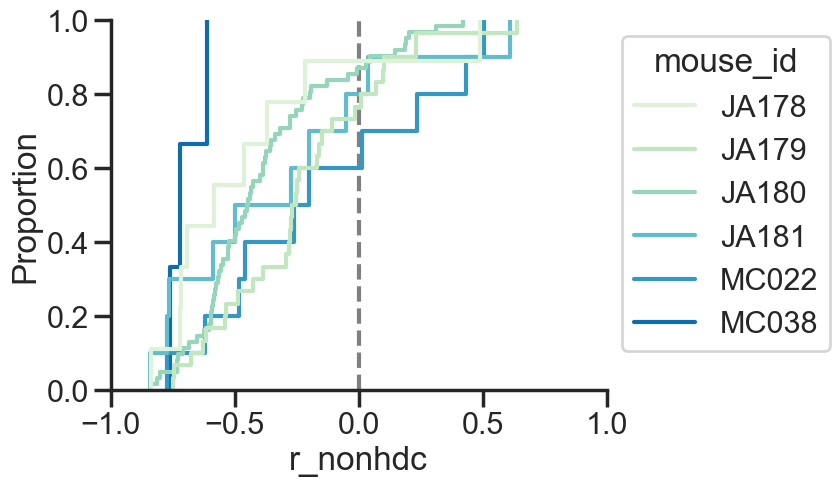

In [191]:

_inp_plot = df_mandyn.groupby(['implant', 'rec_id', 'ep_idx']).max().reset_index()
plt.axvline(x = 0, color = 'gray', ls = '--')

# y = 'r_hdc'
# g = sns.ecdfplot(data = _inp_plot, x = y, hue = "mouse_id", palette = 'Reds')
# sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))

y = 'r_nonhdc'
g = sns.ecdfplot(data = _inp_plot, x = y, hue = "mouse_id", palette = 'GnBu')
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))

# y = 'r_rand'
# g = sns.ecdfplot(data = _inp_plot, x = y, hue = "implant", palette = 'Greys')
# sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
plt.xlim(-1, 1)

# filepath = save_dir / f'ecdf_мr_isomap-dyn_nonhdc.pdf'
# plt.savefig(filepath, transparent = True)

(-1.0, 1.0)

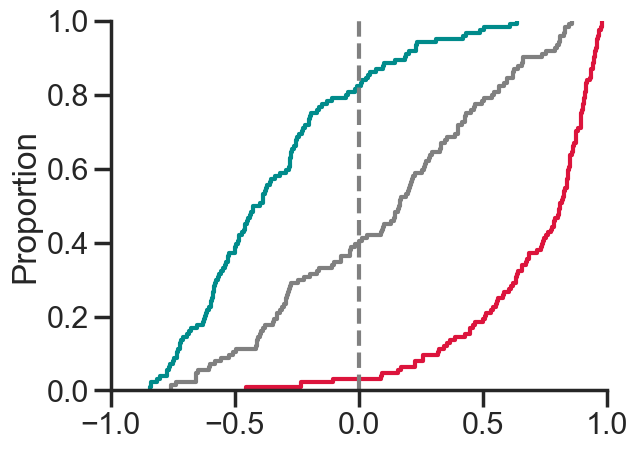

In [192]:
_inp_plot = df_mandyn[df_mandyn.offman_ep_flag == True].groupby(['implant', 
                                                                 'rec_id', 'ep_idx']).max().reset_index()

a1 = _inp_plot['r_hdc'].values
b1 = _inp_plot['r_nonhdc'].values
c1 = _inp_plot['r_rand'].values

sns.ecdfplot(a1, color = 'crimson')
sns.ecdfplot(b1, color = 'darkcyan')
sns.ecdfplot(c1, color = 'Gray')
plt.axvline(x = 0, color = 'gray', ls = '--')
plt.xlim(-1, 1)

# filepath = save_dir / f'ecdf_мr_isomap-dyn_all.pdf'
# plt.savefig(filepath, transparent = True)

In [193]:
_inp_plot.describe()

,ep_idx,r_hdc,r_nonhdc,r_rand,min_rad
count,124.000000,124.000000,124.000000,124.000000,124.000000
mean,46.145161,0.700074,-0.340803,0.108013,0.231476
std,33.371205,0.283623,0.341073,0.443421,0.196999
min,0.000000,-0.454547,-0.841424,-0.757796,0.001399
25%,23.000000,0.576316,-0.588172,-0.289739,0.046875
50%,39.500000,0.811116,-0.411531,0.163129,0.206677
75%,55.000000,0.898871,-0.187380,0.437578,0.367468
max,147.000000,0.980452,0.640710,0.858937,0.666710


In [194]:
print('r hdc vs nonhdc')
print(stats.ks_2samp(a1, b1))
print('r hdc vs rand')
print(stats.ks_2samp(a1, c1))
print('r rand vs nonhdc')
print(stats.ks_2samp(b1, c1))

r hdc vs nonhdc
KstestResult(statistic=0.8629032258064516, pvalue=7.117025776796575e-48, statistic_location=0.23580431781098937, statistic_sign=-1)
r hdc vs rand
KstestResult(statistic=0.5967741935483871, pvalue=7.528028331057359e-21, statistic_location=0.42915875706404555, statistic_sign=-1)
r rand vs nonhdc
KstestResult(statistic=0.45161290322580644, pvalue=9.106098748207826e-12, statistic_location=-0.12621417200875096, statistic_sign=1)


## Pairwise Kendall tau corr

In [54]:
path = r'y:\Users\Alex\Data Analysis\VR1 ATN data\Processed\df_tau_active.pkl'
df_tau_master = pd.read_pickle(path)
df_tau_master.head()

,pair,tau,pval,running,gam,cond,rec_id,rec_session
0,"(1.0, 4.0)",0.779125,4.491944e-17,0,"[0, 8]",D1,20220818_JA178_lADN_red_H2_R_D1,JA178_20220818
0,"(1.0, 4.0)",0.665665,6.854953e-09,1,"[0, 8]",D1,20220818_JA178_lADN_red_H2_R_D1,JA178_20220818
0,"(1.0, 7.0)",-0.401753,1.511348e-05,0,"[4, 8]",D1,20220818_JA178_lADN_red_H2_R_D1,JA178_20220818
0,"(1.0, 7.0)",-0.232908,4.262152e-02,1,"[4, 8]",D1,20220818_JA178_lADN_red_H2_R_D1,JA178_20220818
0,"(1.0, 8.0)",-0.235536,1.146463e-02,0,"[0, 8]",D1,20220818_JA178_lADN_red_H2_R_D1,JA178_20220818


In [339]:
df_tun_proc.rec_id.iloc[0]

'20220818_JA178_lADN_red_H2_R_D1'

In [81]:
_inp.head()

,cond,rec_session,cids
0,L1,JA178_20220818,"[1.0, 4.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13..."
1,L1,JA178_20220819,"[0.0, 2.0, 3.0, 5.0, 6.0, 9.0, 10.0, 12.0, 13...."
2,L1,JA178_20220823,"[8.0, 10.0, 11.0, 14.0, 16.0, 17.0, 20.0, 22.0..."
3,L1,JA178_20220906,"[8.0, 13.0, 14.0, 15.0, 30.0, 32.0, 33.0, 35.0..."
4,L1,JA178_20220907,"[24.0, 49.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57...."


In [31]:
cond1 = 'L1'
cond2 = 'TS6-HF'
cond_ls = ['TS6-HF', 'TS7-HF', 'L1', 'D1'
#            'TS6-MR', 'TS7-MR',  
#        'TS6-OVAR10', 'TS6-OVAR20', 
#            'TS7-VIS', 'TS6-VIS'
    ]
_inp = df_tun_proc[ (df_tun_proc.hdc == 1)
            & (df_tun_proc.rec_session.isin(good_rec_shanks))
#             & (df_tun_proc.dir == 0)
            & (df_tun_proc.cond.isin(cond_ls))
#             & ((df_tun_proc.cond == cond1) | (df_tun_proc.cond == cond2))
            ].groupby([ 'cond', 'rec_session', 'rec_id']).cids.apply(list).reset_index()

In [67]:
vis_rec_id = ['20220627_MC022_lADN_red_H2_VR1_TS7-HF',  '20220627_MC022_lADN_red_H2_VR1_TS7-VIS',
       '20220628_MC022_lADN_red_H2_VR1_TS6-HF', '20220628_MC022_lADN_red_H2_VR1_TS7-VIS',
       '20220629_MC022_lADN_red_H2_VR1_TS6-HF', '20220629_MC022_lADN_red_H2_VR1_TS6-VIS',
       '20220908_JA178_rADN_yel_H2_VR1_TS6-HF', '20220908_JA178_rADN_yel_H2_VR1_TS6-VIS',
       '20220909_JA178_rADN_yel_H2_VR1_TS6-HF', '20220909_JA178_rADN_yel_H2_VR1_TS6-VIS']

In [68]:
cond_ls = ['TS6-VIS', 'TS7-VIS'] 
_inp = df_tun_proc[ (df_tun_proc.hdc > -1)
            & (df_tun_proc.rec_id.isin(vis_rec_id))
#             & (df_tun_proc.dir == 0)
#             & (df_tun_proc.cond.isin(cond_ls))
#             & ((df_tun_proc.cond == cond1) | (df_tun_proc.cond == cond2))
            ]

# idx = _inp[(_inp.head_fixation == 'HF')
#             & (_inp.hdc == 1)].groupby(['rec_id', 'cuid'])['hz'].transform(max) == _inp['hz']

# df_pref = _inp[idx][['rec_session', 'rec_id', 'rec_unit', 'cids', 'dir', 'hz']]

In [884]:
# df_pref.to_pickle('df_pref_hf.pkl')

In [39]:
ls, ls2, ls3 = [], [], []
ls_df = []
speed_thr = 5
for rec in _inp.rec_id.unique()[:]:
    print(rec)
    if 'D1' not in rec:
        continue
    tmp = _inp[_inp.rec_id == rec]
    dts, mouse_id, hem, hstripe, cond, rec_session = get_recinfo_fname(rec)
    if 'l' in hem:
        hem = 'left'
    else:
        hem = 'right'
    implant = mouse_id + '_' + hem
    
    sh = d_good_shanks[implant]
    tmp_hist = df_hist_master[(df_hist_master.mouse_id == mouse_id) 
           & (df_hist_master.dts == dts)
           & (df_hist_master.group != 'noise')
          & (df_hist_master.shank.isin(sh))]

    units_in = tmp_hist.id.unique()
    sess_hdc = tmp_hist[tmp_hist.hdc == 1].id.values
    ls2.append(sess_hdc.size)
    tmp_ephys = d_master[rec]['ephys']   
    yaw_sm, lin_speed = get_yaw_speed_rec(rec, d_master)
    dYaw = compute_dYaw(yaw_sm)
    # convert to deg/s, 50 HZ sampling rate
    ang_vel = dYaw*50
    
    if 'MR' in rec or 'VIS' in rec or 'RPL' in rec or 'OVAR' in rec:
        stat_idx, run_idx = get_stat_run_epochs(ang_vel, window_size=25, speed_thr = 7)
    else:
        stat_idx, run_idx = get_stat_run_epochs(lin_speed, window_size=25, speed_thr = 5)
    print(stat_idx.size, run_idx.size)


#     for each in itertools.combinations(sess_hdc, 2):
#         if each[0] in sess_hdc and each[1] in sess_hdc:
#             hdc_pair = '1_1'
#         elif each[0] in sess_hdc or each[1] in sess_hdc:
#             hdc_pair = '1_0'
#         else:
#             hdc_pair = '0_0'
#         # all data points
#         corr_1 = tmp_ephys[tmp_ephys.cids == each[0]].hz.values[:]
#         corr_2 = tmp_ephys[tmp_ephys.cids == each[1]].hz.values[:]
#         if corr_1.size < 100 or corr_2.size < 100:
#             continue
#         tau1, p_value1 = kendalltau(corr_1, corr_2)
#         ls_df.append(pd.DataFrame({ 'pair': str(each), 'tau': tau1, 'abstau': abs(tau1), 'pval': p_value1, 
#                    'rec_session':rec_session, 'cond': cond, 'head_fix':cond[-2:], 'rec_id': rec, 'hdc_pair': hdc_pair, 
#                    'speed_thr':speed_thr, 'run': 'all'}, index = [0]))
        
#         # stationary data points
#         corr_1 = tmp_ephys[tmp_ephys.cids == each[0]].hz.values
#         corr_2 = tmp_ephys[tmp_ephys.cids == each[1]].hz.values
#         if corr_1.size < 100 or corr_2.size < 100:
#             continue
#         tau1, p_value1 = kendalltau(corr_1[stat_idx], corr_2[stat_idx])
#         ls_df.append(pd.DataFrame({ 'pair': str(each), 'tau': tau1, 'abstau': abs(tau1), 'pval': p_value1, 
#                    'rec_session':rec_session, 'cond': cond, 'head_fix':cond[-2:], 'rec_id': rec, 'hdc_pair': hdc_pair, 
#                    'speed_thr':speed_thr, 'run': 'stat'}, index = [0]))
        
#         # runnning data points
#         corr_1 = tmp_ephys[tmp_ephys.cids == each[0]].hz.values
#         corr_2 = tmp_ephys[tmp_ephys.cids == each[1]].hz.values
#         if corr_1.size < 100 or corr_2.size < 100:
#             continue
#         tau1, p_value1 = kendalltau(corr_1[run_idx], corr_2[run_idx])
#         ls_df.append(pd.DataFrame({ 'pair': str(each), 'tau': tau1, 'abstau': abs(tau1), 'pval': p_value1, 
#                    'rec_session':rec_session, 'cond': cond, 'head_fix':cond[-2:], 'rec_id': rec, 'hdc_pair': hdc_pair, 
#                    'speed_thr':speed_thr, 'run': 'run'}, index = [0]))

        
    
# df_tau_corr = pd.concat(ls_df)
# df_tau_corr.head()

20220818_JA178_lADN_red_H2_R_D1
17065 6165
20220819_JA178_lADN_red_H2_R_D1
9615 13615
20220823_JA178_lADN_red_H2_R_D1
16215 7015
20220906_JA178_rADN_yel_H2_R_D1
9140 14090
20220907_JA178_rADN_yel_H2_R_D1
14140 9090
20220908_JA178_rADN_yel_H2_R_D1
11965 11265
20220909_JA178_rADN_yel_H2_R_D1
12340 10890
20220802_JA179_lADN_red_H2_VR1_D1
18115 5115
20220804_JA179_lADN_red_H2_VR1_D1
11840 11390
20220805_JA179_lADN_red_H2_VR1_D1
12590 10640
20220809_JA180_lADN_red_H2_VR1_D1
13515 9715
20220810_JA180_lADN_red_H2_VR1_D1
10390 12840
20220811_JA180_lADN_red_H2_VR1_D1
13440 9790
20220819_JA180_lADN_red_H2_R_D1
12015 11215
20220809_JA181_lADN_red_H2_VR1_D1
8290 14940
20220812_JA181_lADN_red_H2_VR1_D1
11415 11815
20220817_JA181_lADN_red_H2_R_D1
8690 14540
20220627_MC022_lADN_red_H2_R_D1
10065 13165
20220628_MC022_lADN_red_H2_R_D1
11990 11240
20220629_MC022_lADN_red_H2_R_D1
14715 8515
20220718_MC022_lADN_red_H2_VR1_D1
10265 12965
20220830_MC038_lADN_red_H2_R_D1
12190 11040
20220818_JA178_lADN_red_H

In [40]:
np.mean(ls2), np.min(ls2), np.max(ls2)

(21.545454545454547, 11, 37)

In [75]:
df_tau_corr.head()

,pair,tau,pval,rec_session,cond,head_fix,rec_id,hdc_pair,speed_thr,run
0,"(1, 4)",0.653044,0.0,JA178_20220818,D1,D1,20220818_JA178_lADN_red_H2_R_D1,1_1,5,all
0,"(1, 4)",0.680417,0.0,JA178_20220818,D1,D1,20220818_JA178_lADN_red_H2_R_D1,1_1,5,stat
0,"(1, 4)",0.506986,0.0,JA178_20220818,D1,D1,20220818_JA178_lADN_red_H2_R_D1,1_1,5,run
0,"(1, 7)",-0.333650,0.0,JA178_20220818,D1,D1,20220818_JA178_lADN_red_H2_R_D1,1_1,5,all
0,"(1, 7)",-0.367457,0.0,JA178_20220818,D1,D1,20220818_JA178_lADN_red_H2_R_D1,1_1,5,stat


In [78]:
# df_tau_corr.to_pickle('df_tau_corr5.pkl')

In [77]:
df_tau_corr['abstau'] = abs(df_tau_corr['tau'].values)

C:\Users\ap7454\AppData\Local\Temp\ipykernel_19228\4150331452.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  _inp_plot = data[(data.tau > 0)
meta NOT subset; don't know how to subset; dropped


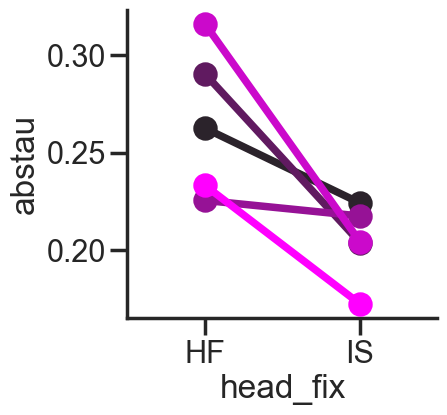

In [71]:
f, ax = plt.subplots(figsize = (4, 4))

data = df_tau_vis_corr
_inp_plot = data[(data.tau > 0) 
                & (data.rec_id.isin(vis_rec_id))
                & (data.run == 'all')
                & (data.hdc_pair == '1_1')].groupby(['head_fix', 'rec_session', 'run']).mean().reset_index()

pal = 'royalblue', 'magenta'
# ax = sns.barplot(data = _inp_plot, x = 'head_fix', y = 'tau', errorbar = ('ci', 68), 
#                  palette= pal
# #             order = ['L1', 'D1', 'HF'], palette = ['orange', 'gray', 'royalblue'],
# #                         hue = 'run',  hue_order = ['stat', 'locom'], 
#            )
# sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
# sns.swarmplot(data = _inp_plot, x = 'head_fix', y = 'abstau', s = 7,   
# #               order = ['L1', 'D1','HF'],
# #             hue = 'run',  hue_order = ['stat', 'locom'], 
#               dodge = True, color = 'k', legend = False)

sns.pointplot(data = _inp_plot, x = 'head_fix', y = 'abstau', hue = 'rec_session',
#               order = ['L1', 'D1','HF'],
#             hue = 'run',  hue_order = ['stat', 'locom'], 
              dodge = False, color = 'magenta', )
plt.legend([],[], frameon=False)
# plt.ylim(-0.4, -0.1)
# plt.savefig('pointplot_visonly_abstau_all.pdf', transparent = True)

In [68]:
_inp_plot.groupby(['head_fix'])[y].describe()

,count,mean,std,min,25%,50%,75%,max
head_fix,,,,,,,,
HF,5.0,0.265624,0.038215,0.225526,0.233257,0.262614,0.290539,0.316182
IS,5.0,0.204463,0.019944,0.172364,0.203866,0.204348,0.217533,0.224201


In [73]:
stat_cond = 'corr_sign'
y = 'tau'

a1 = _inp_plot[(_inp_plot.head_fix == 'HF')][y].values
b1 = _inp_plot[(_inp_plot.head_fix == 'IS')][y].values
# c1 = _inp_plot[(_inp_plot.head_fix == 'HF')][y].values

# print(stats.kruskal(a1, b1, c1))
# print(stats.kruskal(d1, e1, f1))
print (y)
print('HF vs vis')
print(stats.ttest_rel(a1, b1))


tau
HF vs vis
TtestResult(statistic=3.376262704973531, pvalue=0.02788164754894424, df=4)


In [800]:
data = df_tau_vis_corr
tau_df = data[(data.rec_id.isin(vis_rec_id))
                & (data.run == 'all')
                & (data.hdc_pair == '1_1')].pivot(index = ['rec_session', 'pair'], 
                          columns =  'head_fix', values = 'tau').dropna().reset_index()
coi = ['HF', 'IS']

for ses in tau_df.rec_session.unique():
    tau_arr = tau_df[tau_df.rec_session == ses][coi].values
    print(ses, tau_arr.shape)
    diff_tau = tau_arr[:, 0] - tau_arr[:, 1]
    out = np.vstack((tau_arr.T, diff_tau))
    out_df = pd.DataFrame(out.T, columns = [coi[0], coi[1], 'diff'])
    out_df = out_df.sort_values(by = coi[0], ascending=False).reset_index(drop = True)
    sns.heatmap(out_df, cmap = 'bwr', vmin = -1, vmax = 1, yticklabels = 10)
#     plt.show()
    plt.savefig(f'{ses}_{coi}.pdf', transparent = True)
    time.sleep(0.5)
    plt.clf()

JA178_20220908 (66, 2)


meta NOT subset; don't know how to subset; dropped


JA178_20220909 (55, 2)


meta NOT subset; don't know how to subset; dropped


MC022_20220627 (325, 2)


...

MC022_20220628 (300, 2)


meta NOT subset; don't know how to subset; dropped


MC022_20220629 (190, 2)


meta NOT subset; don't know how to subset; dropped


<Figure size 640x480 with 0 Axes>

(190, 2)

In [713]:
_inp_plot = df_tau_corr[(df_tau_corr.cond.isin(coi)) 
                     & (df_tau_corr.hdc_pair == pt) ].pivot(index = ['rec_session',
                 'pair'], columns = 'cond', values = 'tau').reset_index().dropna()


print(cp, recs)
tmp = _inp_plot[_inp_plot.rec_session == recs]
tau_arr = tmp[coi].values


#     idx_sort = np.argsort(tau_arr[:, 0])
diff_tau = tau_arr[:, 0] - tau_arr[:, 1]


out = np.vstack((tau_arr.T, diff_tau))
out_df = pd.DataFrame(out.T, columns = [coi[0], coi[1], 'diff'])
out_df = out_df.sort_values(by = coi[0], ascending=False).reset_index(drop = True)
sns.heatmap(out_df, cmap = 'bwr', vmin = -0.5, vmax = 0.5, yticklabels = 10)

,head_fix,rec_session,run,tau,pval
0,HF,JA178_20220908,all,0.262614,0.021154
1,HF,JA178_20220909,all,0.290539,0.031875
2,HF,MC022_20220627,all,0.239715,0.007887
3,HF,MC022_20220628,all,0.316182,0.003217
4,HF,MC022_20220629,all,0.210515,0.000450
5,IS,JA178_20220908,all,0.224201,0.002572
6,IS,JA178_20220909,all,0.203866,0.022448
7,IS,MC022_20220627,all,0.217533,0.008868
8,IS,MC022_20220628,all,0.204348,0.020267
9,IS,MC022_20220629,all,0.172364,0.017353


In [107]:
# df_tau_corr.to_pickle('df_tau_corr.pkl')
path = r'y:\Users\Alex\Data Analysis\VR1 ATN data\Processed_paper\df_tau_corr.pkl'
df_tau_corr = pd.read_pickle(path)
df_tau_corr['head_fix'] = df_tau_corr.cond.str[-2:]
df_tau_corr['abstau'] = abs(df_tau_corr['tau'].values)
df_tau_corr.head()

,pair,tau,pval,rec_session,cond,rec_id,hdc_pair,run
0,"(1, 2)",-0.015930,3.460285e-03,JA178_20220818,D1,20220818_JA178_lADN_red_H2_R_D1,1_0,all
0,"(1, 2)",-0.050715,5.212845e-13,JA178_20220818,D1,20220818_JA178_lADN_red_H2_R_D1,1_0,stat
0,"(1, 2)",0.036358,2.909172e-05,JA178_20220818,D1,20220818_JA178_lADN_red_H2_R_D1,1_0,locom
0,"(1, 4)",0.653044,0.000000e+00,JA178_20220818,D1,20220818_JA178_lADN_red_H2_R_D1,1_1,all
0,"(1, 4)",0.684116,0.000000e+00,JA178_20220818,D1,20220818_JA178_lADN_red_H2_R_D1,1_1,stat


C:\Users\lab\AppData\Local\Temp\ipykernel_16840\842789995.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  _inp_plot = df_tau_corr[(df_tau_corr.tau > -10)
meta NOT subset; don't know how to subset; dropped


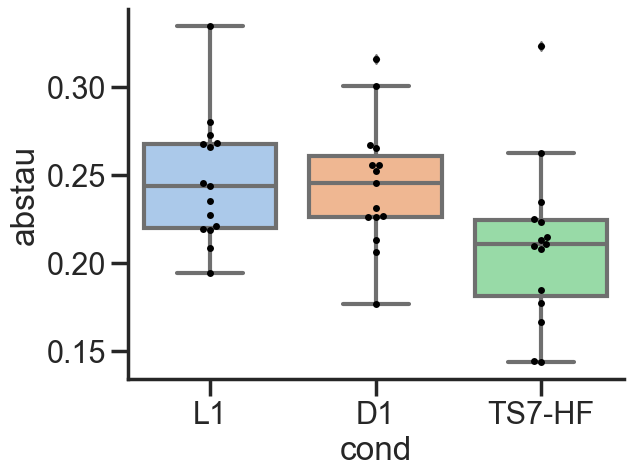

In [368]:
y = 'abstau'
coi = ['L1', 'D1', 'TS7-HF']
_inp_plot = df_tau_corr[(df_tau_corr.tau > -10)
                        & (df_tau_corr.run == 'all')
                        & (df_tau_corr.cond.isin(coi))
                        & (df_tau_corr.rec_session.isin(d_L1comm_sess[coi[2]]))
                        & (df_tau_corr.hdc_pair == '1_1')].groupby(['cond', 'rec_id', 'run']).mean().reset_index()

_inp_plot['cond_run'] = _inp_plot['cond'] + _inp_plot['run']

sns.boxplot(data = _inp_plot, x = 'cond', y = y, order = coi, 
#             hue = 'run', hue_order = ['stat', 'locom'],
           )
sns.swarmplot(data = _inp_plot, x = 'cond', y = y,  order = coi,
#               hue = 'run', hue_order = ['stat', 'locom'],
              dodge = True, color = 'k', legend = False)

# plt.ylim(-0.5, 0)
# plt.savefig(f'boxplot_run_{coi}_{y}.pdf', transparent = True)

In [367]:
_inp_plot.groupby('cond')[y].describe()

,count,mean,std,min,25%,50%,75%,max
cond,,,,,,,,
D1,15.0,0.244230,0.035610,0.176498,0.226092,0.245199,0.260490,0.316146
L1,15.0,0.246853,0.035544,0.194430,0.220065,0.243884,0.267668,0.334693
TS7-HF,15.0,0.209289,0.045554,0.143449,0.180907,0.210438,0.224060,0.323424


In [369]:
a1 = _inp_plot[(_inp_plot.cond == coi[0]) ][y].values
a2 = _inp_plot[(_inp_plot.cond == coi[1]) ][y].values
a3 = _inp_plot[(_inp_plot.cond == coi[2]) ][y].values

# print(stats.kruskal(a1, b1, c1))
# print(stats.kruskal(d1, e1, f1))

print(coi[0], coi[1], stats.mannwhitneyu(a1, a2))
print(coi[0], coi[2], stats.mannwhitneyu(a1, a3))
print(coi[1], coi[2], stats.mannwhitneyu(a2, a3))

L1 D1 MannwhitneyuResult(statistic=119.0, pvalue=0.8034625743147712)
L1 TS7-HF MannwhitneyuResult(statistic=177.0, pvalue=0.007940336264246579)
D1 TS7-HF MannwhitneyuResult(statistic=173.0, pvalue=0.012821684691391543)


In [353]:
a1 = _inp_plot[(_inp_plot.cond == coi[0]) & (_inp_plot.run =='stat')][y].values
a2 = _inp_plot[(_inp_plot.cond == coi[0]) & (_inp_plot.run =='locom')][y].values

b1 = _inp_plot[(_inp_plot.cond == coi[1]) & (_inp_plot.run =='stat')][y].values
b2 = _inp_plot[(_inp_plot.cond == coi[1]) & (_inp_plot.run =='locom')][y].values

print(coi[0], 'stat vs run', stats.wilcoxon(a1, a2))
print(coi[1], 'stat vs run', stats.wilcoxon(b1, b2))
print('stat', stats.mannwhitneyu(a1, b1))
print('run', stats.mannwhitneyu(a2, b2))

TS6-HF stat vs run WilcoxonResult(statistic=55.0, pvalue=0.010109186172485352)
TS7-HF stat vs run WilcoxonResult(statistic=0.0, pvalue=6.103515625e-05)
stat MannwhitneyuResult(statistic=222.0, pvalue=0.14337472895573222)
run MannwhitneyuResult(statistic=172.0, pvalue=1.0)


In [345]:
0.02*4

0.08

### R Loc vs VR Loc

In [496]:
_inp_tmp = df_tau_corr[(df_tau_corr.tau > -1) 
                           & (df_tau_corr.hdc_pair == '1_1')
                          ]
ls, ls2 = [], []
coi = ['TS6-HF', 'TS7-HF', 'D1']
for rec in _inp_tmp.rec_session.unique():
#     dts, mouse_id, hem, hstripe, cond, rec_session = get_recinfo_fname(rec)
    tmp_tau = _inp_tmp[_inp_tmp.rec_session == rec]
    for cond in coi:
        try:
            rec_id = tmp_tau[tmp_tau.cond == cond].rec_id.values[0]
            tmp_tau_stat = tmp_tau[(tmp_tau.run == 'stat')].pivot(index = 'pair', 
                                                     columns = 'cond', values = 'tau')[['L1', cond]].dropna().values
            tmp_tau_locom = tmp_tau[(tmp_tau.run == 'locom')].pivot(index = 'pair', 
                                                     columns = 'cond', values = 'tau')[['L1', cond]].dropna().values
            tmp_tau_all = tmp_tau[(tmp_tau.run == 'all')].pivot(index = 'pair', 
                                                     columns = 'cond', values = 'tau')[['L1', cond]].dropna().values
            idx_pos_all = tmp_tau_all[:, 0] > 0
            idx_neg_all = tmp_tau_all[:, 0] < 0
            idx_pos_stat = tmp_tau_stat[:, 0] > 0
            idx_neg_stat = tmp_tau_stat[:, 0] < 0
            idx_pos_run = tmp_tau_locom[:, 0] > 0
            idx_neg_run = tmp_tau_locom[:, 0] < 0
            
            delta_all_pos =  np.mean(tmp_tau_all[idx_pos_all, 0] -  tmp_tau_all[idx_pos_all, 1])
            delta_all_neg =  np.mean(tmp_tau_all[idx_neg_all, 0] -  tmp_tau_all[idx_neg_all, 1])
            pear_all_pos, pval = stats.pearsonr(tmp_tau_all[idx_pos_all, 0], tmp_tau_all[idx_pos_all, 1])
            pear_all_neg, pval = stats.pearsonr(tmp_tau_all[idx_neg_all, 0], tmp_tau_all[idx_neg_all, 1])
            
            
            delta_stat_pos =  np.mean(tmp_tau_stat[idx_pos_stat, 0] -  tmp_tau_stat[idx_pos_stat, 1])
            delta_stat_neg =  np.mean(tmp_tau_stat[idx_neg_stat, 0] -  tmp_tau_stat[idx_neg_stat, 1])
            delta_run_pos =  np.mean(tmp_tau_stat[idx_pos_run, 0] -  tmp_tau_stat[idx_pos_run, 1])
            delta_run_neg =  np.mean(tmp_tau_stat[idx_neg_run, 0] -  tmp_tau_stat[idx_neg_run, 1])
            
            pear_stat_pos, pval = stats.pearsonr(tmp_tau_stat[idx_pos_stat, 0], tmp_tau_stat[idx_pos_stat, 1])
            pear_run_pos, pval = stats.pearsonr(tmp_tau_locom[idx_pos_run, 0], tmp_tau_locom[idx_pos_run, 1])
            pear_stat_neg, pval = stats.pearsonr(tmp_tau_stat[idx_neg_stat, 0], tmp_tau_stat[idx_neg_stat, 1])
            pear_run_neg, pval = stats.pearsonr(tmp_tau_locom[idx_neg_run, 0], tmp_tau_locom[idx_neg_run, 1])

            tmp_df = pd.DataFrame({
             'rec_session': rec_session, 'cond':  f'L1_{cond}',
            'pear_all_pos':round(pear_all_pos, 3), 'pear_all_neg': round(pear_all_neg, 3), 'head_fix': cond[-2:], 
            'pear_stat_pos':round(pear_stat_pos, 3), 'pear_run_pos': round(pear_run_pos, 3), 'rec_id':rec_id,
            'pear_stat_neg':round(pear_stat_neg, 3), 'pear_run_neg': round(pear_run_neg, 3),   
                   'pos_stat_n': loc_pos_stat.sum(), 'neg_stat_n': loc_neg_stat.sum(),
            'delta_all_pos':round(delta_all_pos, 3), 'delta_all_neg': round(delta_all_neg, 3),
            'delta_stat_pos':round(delta_stat_pos, 3), 'delta_run_pos': round(delta_run_pos, 3),
            'delta_stat_neg':round(delta_stat_neg, 3), 'delta_run_neg': round(delta_run_neg, 3),   
            }, index = [0]                 )
            ls.append(tmp_df)

        except Exception as e:
            print (f'{rec} {cond} {e}')
            continue
        
df_remap = pd.concat(ls)
df_remap.head()

JA178_20220818 TS6-HF boolean index did not match indexed array along dimension 0; dimension is 561 but corresponding boolean dimension is 595
JA178_20220818 TS7-HF index 0 is out of bounds for axis 0 with size 0
JA178_20220906 TS7-HF index 0 is out of bounds for axis 0 with size 0
JA178_20220908 TS7-HF index 0 is out of bounds for axis 0 with size 0
JA178_20220909 TS7-HF index 0 is out of bounds for axis 0 with size 0
JA180_20220809 TS7-HF boolean index did not match indexed array along dimension 0; dimension is 276 but corresponding boolean dimension is 253
JA181_20220817 TS7-HF index 0 is out of bounds for axis 0 with size 0
MC022_20220628 TS7-HF index 0 is out of bounds for axis 0 with size 0
MC022_20220718 TS7-HF index 0 is out of bounds for axis 0 with size 0
MC038_20220829 TS7-HF boolean index did not match indexed array along dimension 0; dimension is 435 but corresponding boolean dimension is 406
MC038_20220830 TS7-HF index 0 is out of bounds for axis 0 with size 0


,rec_session,cond,pear_all_pos,pear_all_neg,head_fix,pear_stat_pos,pear_run_pos,rec_id,pear_stat_neg,pear_run_neg,pos_stat_n,neg_stat_n,delta_all_pos,delta_all_neg,delta_stat_pos,delta_run_pos,delta_stat_neg,delta_run_neg
0,MC038_20220829,L1_D1,0.853,0.752,D1,0.843,0.837,20220818_JA178_lADN_red_H2_R_D1,0.719,0.759,175,203,0.074,0.010,0.076,0.076,0.007,0.002
0,MC038_20220829,L1_TS6-HF,0.372,0.255,HF,0.445,0.363,20220819_JA178_lADN_red_H2_VR1_TS6-HF,0.026,0.190,175,203,0.114,-0.128,0.162,0.140,-0.067,-0.107
0,MC038_20220829,L1_TS7-HF,0.480,0.417,HF,0.410,0.594,20220819_JA178_lADN_red_H2_VR1_TS7-HF,0.286,0.410,175,203,0.104,-0.151,0.170,0.117,-0.146,-0.147
0,MC038_20220829,L1_D1,0.906,0.811,D1,0.827,0.898,20220819_JA178_lADN_red_H2_R_D1,0.766,0.814,175,203,-0.034,0.013,-0.049,-0.058,-0.013,0.023
0,MC038_20220829,L1_TS6-HF,0.676,0.531,HF,0.503,0.810,20220823_JA178_lADN_red_H2_VR1_TS6-HF,0.282,0.567,175,203,0.149,-0.080,0.201,0.135,-0.116,-0.067


In [74]:
tau_sign = 'pos'
y  = 'pear'
_inp_plot = pd.melt(df_remap, id_vars=['rec_session', 'head_fix'], value_vars=['pear_all_pos', 'pear_all_neg',
                                                                              'delta_all_pos', 'delta_all_neg'])
_inp_plot['run'] = _inp_plot['variable'].str.split('_', expand = True)[1]
_inp_plot['corr_sign'] = _inp_plot['variable'].str.split('_', expand = True)[2]
_inp_plot['y'] = _inp_plot['variable'].str.split('_', expand = True)[0]
_inp_plot = _inp_plot[ (_inp_plot.y == y)]

pal = current_palette[1], current_palette[0] 
# f, ax = plt.subplots(figsize = (6, 4))
sns.boxplot(data = _inp_plot, x = 'corr_sign', y = 'value', hue = 'head_fix',
#             hue = 'run', order = ['D1', 'HF'], hue_order = ['stat', 'loc'], palette=pal
           )
sns.swarmplot(data = _inp_plot, x = 'corr_sign', y = 'value', hue = 'head_fix',
#               hue = 'run', hue_order = ['stat', 'loc'], order = ['D1', 'HF'],  
              color = 'k', dodge = True, legend = None)
plt.xticks(rotation=45)
# plt.ylim(0, 1.1)
# plt.savefig(f'boxplot_{tau_sign}-neg_{y}.pdf', transparent = True)

NameError: name 'df_remap' is not defined

In [416]:
stat_cond = 'corr_sign'
print (_inp_plot.groupby(['head_fix', stat_cond]).describe())
a1 = _inp_plot[(_inp_plot.head_fix == 'D1') & (_inp_plot[stat_cond] =='pos')].value.values
# b1 = _inp_plot[(_inp_plot.head_fix == 'D1') & (_inp_plot.run =='stat')].tau.values
c1 = _inp_plot[(_inp_plot.head_fix == 'HF') & (_inp_plot[stat_cond] =='pos')].value.values

d1 = _inp_plot[(_inp_plot.head_fix == 'D1') & (_inp_plot[stat_cond] =='neg')].value.values
# e1 = _inp_plot[(_inp_plot.head_fix == 'D1') & (_inp_plot.run =='locom')].tau.values
f1 = _inp_plot[(_inp_plot.head_fix == 'HF') & (_inp_plot[stat_cond] =='neg')].value.values

# print(stats.kruskal(a1, b1, c1))
# print(stats.kruskal(d1, e1, f1))
print (stat_cond, y)
# print('LD vs LVR')
# print(stats.wilcoxon(a1, d1))
print('pos LD vs LVR')
print(stats.mannwhitneyu(a1, c1))
# print('VR stat vs run')
# print(stats.wilcoxon(c1, f1))
print('neg LD vs LVR')
print(stats.mannwhitneyu(d1, f1))

                   value                                                    \
                   count      mean       std    min     25%    50%     75%   
head_fix corr_sign                                                           
D1       neg        23.0  0.847217  0.073299  0.700  0.8005  0.851  0.8990   
         pos        23.0  0.921565  0.035642  0.853  0.8975  0.923  0.9500   
HF       neg        35.0  0.478143  0.197750  0.051  0.3205  0.501  0.6525   
         pos        35.0  0.638486  0.180020  0.171  0.5065  0.680  0.7800   

                           
                      max  
head_fix corr_sign         
D1       neg        0.974  
         pos        0.981  
HF       neg        0.781  
         pos        0.892  
corr_sign pear
pos LD vs LVR
MannwhitneyuResult(statistic=792.0, pvalue=6.279813785720711e-10)
neg LD vs LVR
MannwhitneyuResult(statistic=793.0, pvalue=5.670460095227672e-10)


cond
pair


### R, VR Loc vs Stat

In [159]:
df_tau_corr.head()

,pair,tau,pval,rec_session,cond,head_fix,rec_id,hdc_pair,speed_thr,run,abstau
0,"(1, 4)",0.653044,0.0,JA178_20220818,D1,D1,20220818_JA178_lADN_red_H2_R_D1,1_1,5,all,0.653044
0,"(1, 4)",0.680417,0.0,JA178_20220818,D1,D1,20220818_JA178_lADN_red_H2_R_D1,1_1,5,stat,0.680417
0,"(1, 4)",0.506986,0.0,JA178_20220818,D1,D1,20220818_JA178_lADN_red_H2_R_D1,1_1,5,run,0.506986
0,"(1, 7)",-0.333650,0.0,JA178_20220818,D1,D1,20220818_JA178_lADN_red_H2_R_D1,1_1,5,all,0.333650
0,"(1, 7)",-0.367457,0.0,JA178_20220818,D1,D1,20220818_JA178_lADN_red_H2_R_D1,1_1,5,stat,0.367457


In [162]:
_inp_tmp = df_tau_corr[(df_tau_corr.tau > -1) 
                           & (df_tau_corr.hdc_pair == '1_1')
                          ]
ls, ls2 = [], []

for rec in _inp_tmp.rec_id.unique():
    dts, mouse_id, hem, hstripe, cond, rec_session = get_recinfo_fname(rec)
    tmp_tau = _inp_tmp[_inp_tmp.rec_id == rec]
#     tmp_tau = _inp_tmp[_inp_tmp.rec_session == rec]
#     try:
#         tmp_tau_stat = tmp_tau[(tmp_tau.run == 'stat')].pivot(index = 'pair', 
#                                                 columns = 'cond', values = 'tau')[['L1', 'TS6-HF']].dropna().values
#         tmp_tau_locom = tmp_tau[(tmp_tau.run == 'locom')].pivot(index = 'pair', 
#                                                 columns = 'cond', values = 'tau')[['L1', 'TS6-HF']].dropna().values

#     except:
#         continue
#     pear_r, pval = stats.pearsonr(tmp_tau_stat[:, 0], tmp_tau_stat[:, 1])
#     pear_r_loc, pval = stats.pearsonr(tmp_tau_locom[:, 0], tmp_tau_locom[:, 1])

    tmp_tau_arr = tmp_tau.pivot(index = 'pair', columns = 'run', values = 'tau')[['run', 'stat']].dropna().values
    loc_pos = tmp_tau_arr[:, 0] > 0
    loc_neg = tmp_tau_arr[:, 0] < 0
    delta_pos = np.mean((tmp_tau_arr[loc_pos, 0] - tmp_tau_arr[loc_pos, 1]))
    delta_neg = np.mean((tmp_tau_arr[loc_neg, 0] - tmp_tau_arr[loc_neg, 1]))
    delta_all = np.mean(abs(tmp_tau_arr[:, 0] - tmp_tau_arr[:, 1]))
    
    pear_r_pos, pval = stats.pearsonr(tmp_tau_arr[loc_pos, 0], tmp_tau_arr[loc_pos, 1])
    pear_r_neg, pval = stats.pearsonr(tmp_tau_arr[loc_neg, 0], tmp_tau_arr[loc_neg, 1])
  
    tmp_df = pd.DataFrame({
        'rec_id': rec, 'mouse_id': mouse_id, 'cond': cond, 'rec_session': rec_session, 'head_fix': cond[-2:], 
        'delta_pos':delta_pos, 'pear_pos': round(pear_r_pos, 3), 'pos_n': loc_pos.sum(), 'neg_n': loc_neg.sum(),
        'delta_neg':delta_neg, 'pear_neg': round(pear_r_neg, 3), 'delta_all': delta_all}, index = [0]
                         )
#     if pear_r < 0.65:
#         print(rec, pear_r)
    ls.append(tmp_df)
#     ls.append(pear_r)
#     ls2.append(pear_r_loc)
    
df_delta_tau = pd.concat(ls)
df_delta_tau.head()

,rec_id,mouse_id,cond,rec_session,head_fix,delta_pos,pear_pos,pos_n,neg_n,delta_neg,pear_neg,delta_all
0,20220818_JA178_lADN_red_H2_R_D1,JA178,D1,JA178_20220818,D1,0.050375,0.871,436,194,-0.000856,0.789,0.086442
0,20220819_JA178_lADN_red_H2_R_D1,JA178,D1,JA178_20220819,D1,0.027938,0.946,159,94,-0.001835,0.912,0.057222
0,20220823_JA178_lADN_red_H2_R_D1,JA178,D1,JA178_20220823,D1,0.077275,0.923,82,38,-0.062613,0.855,0.093833
0,20220906_JA178_rADN_yel_H2_R_D1,JA178,D1,JA178_20220906,D1,0.022868,0.927,29,37,-0.070556,0.883,0.074667
0,20220907_JA178_rADN_yel_H2_R_D1,JA178,D1,JA178_20220907,D1,0.018345,0.750,30,25,-0.047618,0.852,0.083834


In [161]:
df_tau_run.cond.unique()

array(['D1', 'L1', 'TS6-HF', 'TS7-HF'], dtype=object)

In [163]:
# df_delta_tau.to_pickle('df_delta_tau.pkl')

<Axes: xlabel='cond', ylabel='delta_all'>

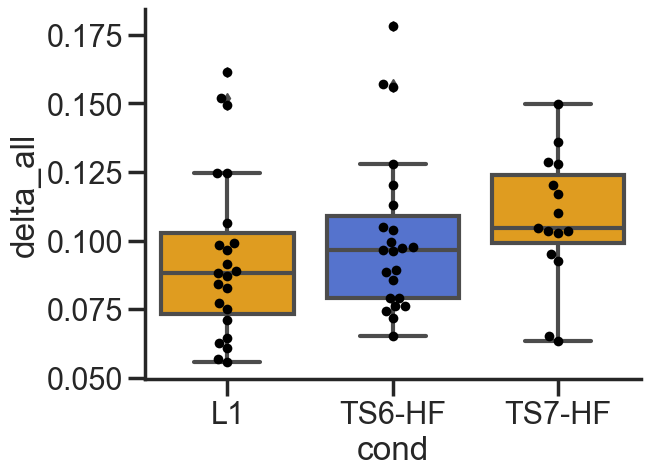

In [249]:
coi = ['L1', 'TS6-HF', 'TS7-HF']
y = 'delta_all'
pal = ['orange', 'royalblue']

_inp_plot = df_tau_run[df_tau_run.cond.isin(coi)]
# sns.pointplot(data = _inp_plot, x = 'cond', y = y, hue = 'dts', color = 'red')
sns.boxplot(data = _inp_plot, x = 'cond', y = y,  palette=pal)
sns.swarmplot(data = _inp_plot, x = 'cond', y = y, size = 7, color = 'k')
# plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
# plt.savefig(f'bar_hr_{y}.pdf', transparent = True)  

In [250]:
(_inp_plot.groupby(['cond'])[y].describe())

,count,mean,std,min,25%,50%,75%,max
cond,,,,,,,,
L1,23.0,0.093853,0.030374,0.055745,0.073113,0.088129,0.102803,0.161265
TS6-HF,23.0,0.101477,0.029369,0.065335,0.079157,0.096669,0.108959,0.178116
TS7-HF,15.0,0.107982,0.023759,0.063258,0.098954,0.104746,0.123986,0.149843


In [253]:
a1 = _inp_plot[(_inp_plot.cond == coi[0])][y].values
b1 = _inp_plot[(_inp_plot.cond == coi[1])][y].values
c1 = _inp_plot[(_inp_plot.cond == coi[2])][y].values
print('L1 vs TS6-HF')
print(stats.mannwhitneyu(a1, b1))
print('TS6-HF vs TS7-HF')
print(stats.mannwhitneyu(b1, c1))

L1 vs TS6-HF
MannwhitneyuResult(statistic=214.0, pvalue=0.2720040994277395)
TS6-HF vs TS7-HF
MannwhitneyuResult(statistic=131.0, pvalue=0.2207914750275245)


C:\ProgramData\Anaconda3\envs\pyn38\lib\site-packages\seaborn\categorical.py:166: FutureWarning: Setting a gradient palette using color= is deprecated and will be removed in version 0.13. Set `palette='dark:k'` for same effect.
  warnings.warn(msg, FutureWarning)


(array([0, 1]), [Text(0, 0, 'pos'), Text(1, 0, 'neg')])

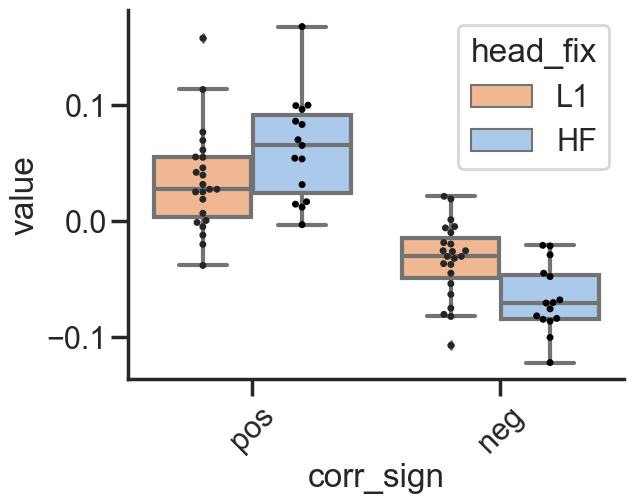

In [234]:
tau_sign = 'pos'
y  = 'delta'
coi = ['L1', 'TS7-HF']
_inp_plot = pd.melt(df_tau_run[df_tau_run.cond.isin(coi)], id_vars=['rec_session', 'head_fix'], 
                    value_vars=['pear_pos', 'pear_neg', 'delta_pos', 'delta_neg'])
_inp_plot['y'] = _inp_plot['variable'].str.split('_', expand = True)[0]
_inp_plot['corr_sign'] = _inp_plot['variable'].str.split('_', expand = True)[1]
_inp_plot = _inp_plot[ (_inp_plot.y == y)]

pal = current_palette[1], current_palette[0] 
# f, ax = plt.subplots(figsize = (6, 4))
sns.boxplot(data = _inp_plot, x = 'corr_sign', y = 'value', hue = 'head_fix', palette=pal
#             hue = 'run', order = ['D1', 'HF'], hue_order = ['stat', 'loc'], 
           )
sns.swarmplot(data = _inp_plot, x = 'corr_sign', y = 'value', hue = 'head_fix',
#               hue = 'run', hue_order = ['stat', 'loc'], order = ['D1', 'HF'],  
              color = 'k', dodge = True, legend = None)
plt.xticks(rotation=45)
# plt.ylim(0, 1.1)
# plt.savefig(f'boxplot_stat_run_{tau_sign}-neg_{y}.pdf', transparent = True)

In [439]:
stat_cond = 'corr_sign'
print (_inp_plot.groupby(['head_fix', stat_cond]).describe())
a1 = _inp_plot[(_inp_plot.head_fix == 'L1') & (_inp_plot[stat_cond] =='pos')].value.values
# b1 = _inp_plot[(_inp_plot.head_fix == 'D1') & (_inp_plot.run =='stat')].tau.values
c1 = _inp_plot[(_inp_plot.head_fix == 'HF') & (_inp_plot[stat_cond] =='pos')].value.values

d1 = _inp_plot[(_inp_plot.head_fix == 'L1') & (_inp_plot[stat_cond] =='neg')].value.values
# e1 = _inp_plot[(_inp_plot.head_fix == 'D1') & (_inp_plot.run =='locom')].tau.values
f1 = _inp_plot[(_inp_plot.head_fix == 'HF') & (_inp_plot[stat_cond] =='neg')].value.values

# print(stats.kruskal(a1, b1, c1))
# print(stats.kruskal(d1, e1, f1))
print (stat_cond, y)
# print('LD vs LVR')
# print(stats.wilcoxon(a1, d1))
print('pos LD vs LVR')
print(stats.mannwhitneyu(a1, c1))
# print('VR stat vs run')
# print(stats.wilcoxon(c1, f1))
print('neg LD vs LVR')
print(stats.mannwhitneyu(d1, f1))

                   value                                                    \
                   count      mean       std       min       25%       50%   
head_fix corr_sign                                                           
HF       neg        38.0 -0.046446  0.040704 -0.121692 -0.075204 -0.052055   
         pos        38.0  0.056078  0.044908 -0.053894  0.029018  0.051513   
L1       neg        23.0 -0.033283  0.032227 -0.106933 -0.049285 -0.030305   
         pos        23.0  0.034921  0.043580 -0.038117  0.003690  0.027464   

                                        
                         75%       max  
head_fix corr_sign                      
HF       neg       -0.025593  0.089273  
         pos        0.085310  0.167491  
L1       neg       -0.014087  0.021361  
         pos        0.055084  0.157534  
corr_sign delta
pos LD vs LVR
MannwhitneyuResult(statistic=303.0, pvalue=0.04696172074961561)
neg LD vs LVR
MannwhitneyuResult(statistic=558.0, pvalue=0.0729426801432

In [192]:
df_tau_corr.head()

NameError: name 'df_tau_corr' is not defined

['JA178_20220819',
 'JA178_20220823',
 'JA178_20220907',
 'JA179_20220802',
 'JA179_20220804',
 'JA179_20220805',
 'JA180_20220809',
 'JA180_20220810',
 'JA180_20220811',
 'JA180_20220819',
 'JA181_20220809',
 'JA181_20220812',
 'MC022_20220627',
 'MC022_20220629',
 'MC038_20220829']

In [88]:
corr_pair_count = df_tau_corr[(df_tau_corr.run == 'stat') 
                              & (df_tau_corr.hdc_pair == '1_1')].groupby(['rec_id'])['pair'].count().reset_index()
corr_pair_count[corr_pair_count.pair > 100]

,rec_id,pair
0,20220627_MC022_lADN_red_H2_R_D1,325
1,20220627_MC022_lADN_red_H2_R_L1,325
2,20220627_MC022_lADN_red_H2_VR1_TS6-HF,325
3,20220627_MC022_lADN_red_H2_VR1_TS7-HF,325
4,20220628_MC022_lADN_red_H2_R_D1,300
...,...,...
65,20220829_MC038_lADN_red_H2_VR1_TS6-HF,406
66,20220829_MC038_lADN_red_H2_VR1_TS7-HF,435
67,20220830_MC038_lADN_red_H2_R_D1,378
68,20220830_MC038_lADN_red_H2_R_L1,378


C:\Users\ap7454\AppData\Local\Temp\ipykernel_19228\3374274367.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  _inp_plot = df_tau_corr[(df_tau_corr.tau > -10)
C:\Users\ap7454\.conda\envs\pyn38\lib\site-packages\seaborn\categorical.py:166: FutureWarning: Setting a gradient palette using color= is deprecated and will be removed in version 0.13. Set `palette='dark:k'` for same effect.
  warnings.warn(msg, FutureWarning)
meta NOT subset; don't know how to subset; dropped


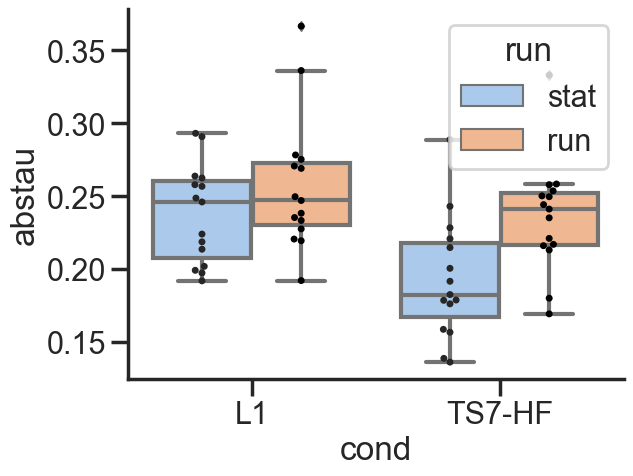

In [93]:
y = 'abstau'
coi = ['L1', 'TS7-HF']
_inp_plot = df_tau_corr[(df_tau_corr.tau > -10)
                        & (df_tau_corr.run != 'all')
                        & (df_tau_corr.cond.isin(coi))
                        & (df_tau_corr.rec_session.isin(vr_com_sess))
                        & (df_tau_corr.hdc_pair == '1_1')].groupby(['cond', 'rec_id', 'run']).mean().reset_index()

sns.boxplot(data = _inp_plot, x = 'cond', y = y, order = coi, 
            hue = 'run', hue_order = ['stat', 'run'],
           )
sns.swarmplot(data = _inp_plot, x = 'cond', y = y,  order = coi,
              hue = 'run', hue_order = ['stat', 'run'],
              dodge = True, color = 'k', legend = False)

# plt.ylim(-0.5, 0)
plt.savefig(f'boxplot_{coi}_{y}_run.pdf', transparent = True)

In [94]:
(_inp_plot.groupby(['cond', 'run'])[y].describe())

count      mean       std       min       25%       50%  \
cond   run                                                             
L1     run    15.0  0.257410  0.045299  0.192253  0.230584  0.247152   
       stat   15.0  0.237860  0.033548  0.192060  0.207880  0.246145   
TS7-HF run    15.0  0.236100  0.038053  0.169415  0.216621  0.241274   
       stat   15.0  0.193082  0.041135  0.136337  0.167556  0.182657   

                  75%       max  
cond   run                       
L1     run   0.273075  0.366714  
       stat  0.260281  0.293208  
TS7-HF run   0.252047  0.333136  
       stat  0.217897  0.288886

In [95]:
a1 = _inp_plot[(_inp_plot.cond == coi[0]) & (_inp_plot.run == 'stat')][y].values
a2 = _inp_plot[(_inp_plot.cond == coi[0]) & (_inp_plot.run == 'run')][y].values
b1 = _inp_plot[(_inp_plot.cond == coi[1]) & (_inp_plot.run == 'stat')][y].values
b2 = _inp_plot[(_inp_plot.cond == coi[1]) & (_inp_plot.run == 'run')][y].values


print(f'test for {y}')

stat1, pval1 = stats.wilcoxon(a1, a2)
print(f'{coi[0]} stat vs run {stat1} {pval1}')
stat2, pval2 = stats.wilcoxon(b1, b2)
print(f'{coi[1]} stat vs run {stat2} {pval2}')
stat3, pval3 = stats.mannwhitneyu(a1, b1)
print(f'stat  {stat3} {pval3}')
stat4, pval4 = stats.mannwhitneyu(a2, b2)
print(f'run {stat4} {pval4}')
pvals = [pval1, pval2, pval3, pval4]  
print('Benjamini/Hochberg (non-negative)')
print(multipletests(pvals, alpha=0.05, method='fdr_bh'))


test for abstau
L1 stat vs run 23.0 0.03533935546875
TS7-HF stat vs run 0.0 6.103515625e-05
stat  184.0 0.0032301435955866646
run 143.0 0.21337370709311831
Benjamini/Hochberg (non-negative)
(array([ True,  True,  True, False]), array([0.04711914, 0.00024414, 0.00646029, 0.21337371]), 0.012741455098566168, 0.0125)


In [91]:
a1.mean()

0.24730532197116892

PearsonRResult(statistic=0.9643338111673478, pvalue=1.6084297657927638e-188)


meta NOT subset; don't know how to subset; dropped


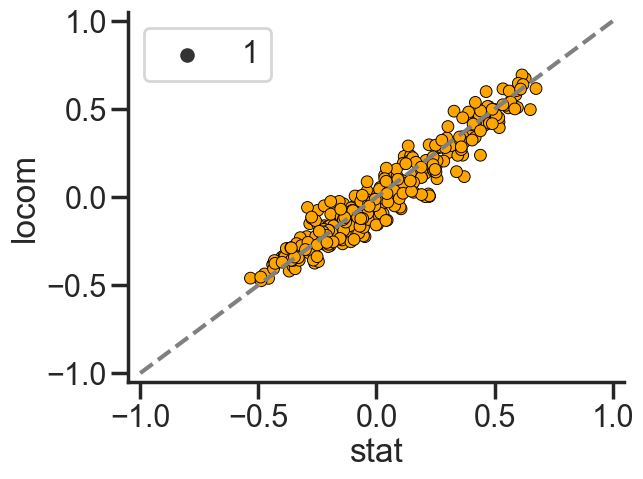

In [471]:
coi = ['stat', 'locom']
unity_line = [-1, 1]
_inp_plot = df_tau_corr[(df_tau_corr.hdc_pair == '1_1')
                        & (df_tau_corr.rec_id == '20220810_JA180_lADN_red_H2_VR1_L1')
                        & (df_tau_corr.run != 'all')
#                         & (df_tau_corr.cond.isin(coi))
                       ].pivot(index = ['rec_session',
                     'pair'], columns = 'run', values = 'tau').reset_index().dropna()

sns.scatterplot(data = _inp_plot, x = coi[0], y = coi[1], legend = True, c = 'orange', edgecolor = 'k', alpha = 1, size = 1
            )
plt.xlim(-1.05, 1.05)
plt.ylim(-1.05, 1.05)
plt.plot(unity_line, unity_line, ls = '--', c = 'gray')
print(stats.pearsonr(_inp_plot[coi[0]], _inp_plot[coi[1]]))
# plt.savefig(f'scatter_tau_{coi[0]}_{coi[1]}.png', dpi = 300 , transparent=True)
# plt.savefig(f'scatter_tau_L1_0810-JA180_{coi[0]}_{coi[1]}.pdf', transparent=True)

PearsonRResult(statistic=0.9643338111673478, pvalue=1.6084297657927638e-188)


### Stat off-manifold index vs tau

In [446]:
# df_betti.to_pickle('df_betti.pkl')
path = r'y:\Users\Alex\Data Analysis\VR1 ATN data\Processed_paper\df_betti.pkl'
df_betti = pd.read_pickle(path)
df_betti = df_betti[~df_betti.cond.str.contains('LMK')]
df_betti.head()

,rec_id,rec_session,cond,run,h1_bar,dec_err,stat_off_manifold
0,20220818_JA178_lADN_red_H2_R_D1,JA178_20220818,D1,stat,18.926,27.740,0.026354
0,20220818_JA178_lADN_red_H2_R_D1,JA178_20220818,D1,locom,19.324,33.879,0.026354
0,20220818_JA178_lADN_red_H2_R_L1,JA178_20220818,L1,stat,34.995,33.612,0.137179
0,20220818_JA178_lADN_red_H2_R_L1,JA178_20220818,L1,locom,35.622,43.523,0.137179
0,20220819_JA178_lADN_red_H2_R_D1,JA178_20220819,D1,stat,22.074,26.476,0.059107


In [498]:
a = df_betti[df_betti.run == 'stat'].rec_id.values
b = df_betti[df_betti.run == 'stat'].stat_off_manifold.values
d_iso_idx = dict(zip(a, b))

In [518]:
df_remap['stat_off_manifold'] = df_remap.rec_id.map(d_iso_idx)
df_tau_run['stat_off_manifold'] = df_tau_run.rec_id.map(d_iso_idx)

In [551]:
df_remap.head()

,rec_session,cond,pear_all_pos,pear_all_neg,head_fix,pear_stat_pos,pear_run_pos,rec_id,pear_stat_neg,pear_run_neg,pos_stat_n,neg_stat_n,delta_all_pos,delta_all_neg,delta_stat_pos,delta_run_pos,delta_stat_neg,delta_run_neg,stat_off_manifold
0,MC038_20220829,L1_D1,0.853,0.752,D1,0.843,0.837,20220818_JA178_lADN_red_H2_R_D1,0.719,0.759,175,203,0.074,0.010,0.076,0.076,0.007,0.002,0.026354
0,MC038_20220829,L1_TS6-HF,0.372,0.255,HF,0.445,0.363,20220819_JA178_lADN_red_H2_VR1_TS6-HF,0.026,0.190,175,203,0.114,-0.128,0.162,0.140,-0.067,-0.107,0.192308
0,MC038_20220829,L1_TS7-HF,0.480,0.417,HF,0.410,0.594,20220819_JA178_lADN_red_H2_VR1_TS7-HF,0.286,0.410,175,203,0.104,-0.151,0.170,0.117,-0.146,-0.147,0.702053
0,MC038_20220829,L1_D1,0.906,0.811,D1,0.827,0.898,20220819_JA178_lADN_red_H2_R_D1,0.766,0.814,175,203,-0.034,0.013,-0.049,-0.058,-0.013,0.023,0.059107
0,MC038_20220829,L1_TS6-HF,0.676,0.531,HF,0.503,0.810,20220823_JA178_lADN_red_H2_VR1_TS6-HF,0.282,0.567,175,203,0.149,-0.080,0.201,0.135,-0.116,-0.067,0.740570


L1 PearsonRResult(statistic=-0.1617613889369508, pvalue=0.46088188916129014)
HF PearsonRResult(statistic=-0.27586927369769537, pvalue=0.10869298909771903)


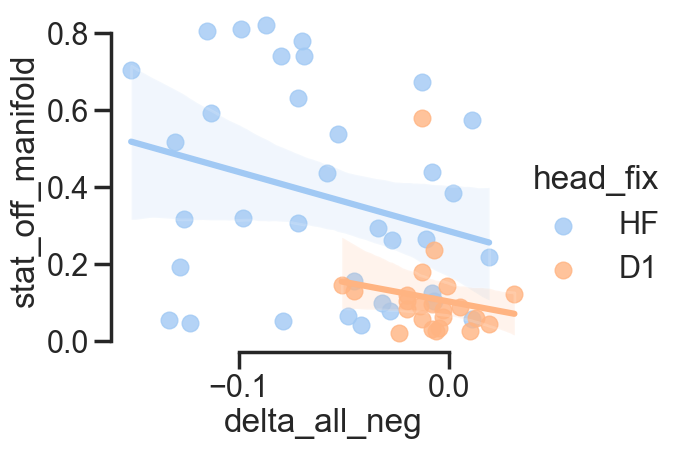

In [554]:
_inp_plot = df_remap
x, y = 'delta_all_neg', 'stat_off_manifold'
sns.lmplot(data = _inp_plot, x = x, y = y, hue = 'head_fix', hue_order = ['HF', 'D1'], aspect = 1.2, truncate = True)

a1 = _inp_plot[(_inp_plot.head_fix == 'D1')][x].values
a2 = _inp_plot[(_inp_plot.head_fix == 'D1')][y].values
b1 = _inp_plot[(_inp_plot.head_fix == 'HF')][x].values
b2 = _inp_plot[(_inp_plot.head_fix == 'HF')][y].values

print('L1', stats.pearsonr(a1, a2))
print('HF', stats.pearsonr(b1, b2))
sns.despine(offset=1, trim=True)

# plt.savefig(f'lmplot_{x}_{y}.pdf', transparent = True)

,rec_id,mouse_id,cond,rec_session,head_fix,delta_pos,pear_pos,pos_n,neg_n,delta_neg,pear_neg,stat_off_manifold
0,20220818_JA178_lADN_red_H2_R_D1,JA178,D1,JA178_20220818,D1,0.035798,0.861,427,203,0.003626,0.787,0.026354
0,20220819_JA178_lADN_red_H2_R_D1,JA178,D1,JA178_20220819,D1,0.043539,0.940,159,94,-0.005689,0.819,0.059107
0,20220823_JA178_lADN_red_H2_R_D1,JA178,D1,JA178_20220823,D1,0.085987,0.929,82,38,-0.062096,0.854,0.577436
0,20220906_JA178_rADN_yel_H2_R_D1,JA178,D1,JA178_20220906,D1,0.009997,0.949,31,35,-0.066954,0.915,0.179623
0,20220907_JA178_rADN_yel_H2_R_D1,JA178,D1,JA178_20220907,D1,0.037582,0.724,30,25,-0.068850,0.854,0.145455


In [663]:
df_remap['run_gain'] = df_remap.rec_id.map(d_run_gain)

<Axes: xlabel='run_gain', ylabel='stat_off_manifold'>

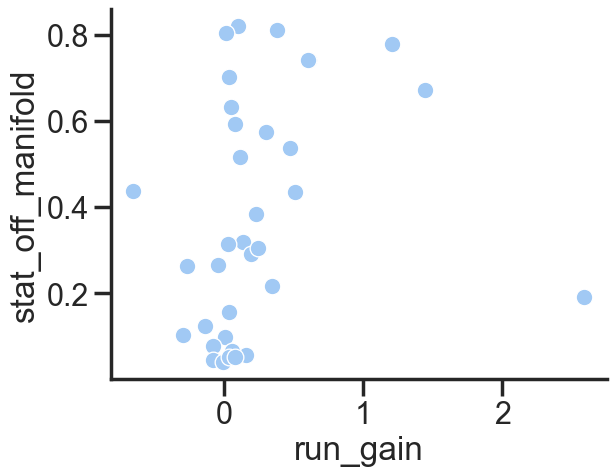

In [666]:
sns.scatterplot(data = df_remap.dropna(), x = 'run_gain', y = 'stat_off_manifold')

In [669]:
out = df_remap.dropna()[['run_gain', 'stat_off_manifold']].values

In [675]:
stats.spearmanr(out[:, 0], out[:, 1])

SignificanceResult(statistic=0.46778711484593843, pvalue=0.004602025313716138)

### Delta tau

In [41]:
ls = []
cond_pairs = [['L1', 'D1'], ['L1', 'TS6-HF'], 
              ['L1', 'TS7-HF'], ['TS6-HF', 'TS7-HF'] 
#               ['L1', 'TS6-MR'], ['L1', 'TS7-MR'], ['TS6-MR', 'TS7-MR']
             ]
pair_hdc = ['1_1', '1_0', '0_0']
for pt in pair_hdc:
    for cp in cond_pairs:
        coi = cp
        _inp_plot = df_tau_corr[(df_tau_corr.cond.isin(coi)) 
                                 & (df_tau_corr.hdc_pair == pt) ].pivot(index = ['rec_session',
                             'pair'], columns = 'cond', values = 'tau').reset_index().dropna()

        for recs in _inp_plot.rec_session.unique()[:]:
            print(cp, recs)
            tmp = _inp_plot[_inp_plot.rec_session == recs]
            tau_arr = tmp[coi].values
    #         gam = tmp['gam'].values
            sign_corr = (np.sign(tau_arr)[:, 0] * np.sign(tau_arr)[:, 1]) < 0

        #     idx_sort = np.argsort(tau_arr[:, 0])
            diff_tau = tau_arr[:, 0] - tau_arr[:, 1]
            pear_r, p_val = stats.pearsonr(tau_arr[:, 0], tau_arr[:, 1])
            strong_pairs = abs(diff_tau) > 0.1
            sign_sw = sign_corr & strong_pairs
            abs_tau = abs(diff_tau)
            ls.append(pd.DataFrame({'rec_session': recs, 'tau1': tau_arr[:, 0], 'tau2':tau_arr[:, 1], 'pair_hdc': pt,
                                    'pear_r': round(pear_r, 3), 'pear_pval': round(p_val, 3), 'n_pairs': tau_arr[:, 0].size, 
                  'diff_tau': diff_tau, 'abs_tau':abs_tau, 'cond': coi[0] + '_' + coi[1], 'sign_sw': sign_sw })) 

    #         if tau_arr.shape[0] > 100:
    #             f, ax = plt.subplots(figsize = (4, 12))
    #         else:
    #             f, ax = plt.subplots(figsize = (4, 6))

    #         out = np.vstack((tau_arr.T, diff_tau))
    #         out_df = pd.DataFrame(out.T, columns = [coi[0], coi[1], 'diff'])
    #         out_df = out_df.sort_values(by = coi[0], ascending=False).reset_index(drop = True)
    #         sns.heatmap(out_df, cmap = 'bwr', vmin = -0.5, vmax = 0.5, yticklabels = 10)

    #         plt.show()
    #         plt.savefig(f'heatmap_nhdc_pearson_{cp}.pdf', transparent=True)
        
    
df_delta_tau = pd.concat(ls)
df_delta_tau.head()

NameError: name 'df_tau_corr' is not defined

In [195]:
# df_delta_tau.to_pickle('df_delta_tau.pkl')

In [620]:
df_delta_tau.head()

,rec_session,tau1,tau2,pair_hdc,pear_r,pear_pval,n_pairs,diff_tau,abs_tau,cond,sign_sw
0,20220627_MC022,-0.041421,0.039070,1_1,0.943,0.0,325,-0.080491,0.080491,L1_D1,False
1,20220627_MC022,-0.071692,-0.021589,1_1,0.943,0.0,325,-0.050103,0.050103,L1_D1,False
2,20220627_MC022,-0.363002,-0.378657,1_1,0.943,0.0,325,0.015655,0.015655,L1_D1,False
3,20220627_MC022,-0.401631,-0.331831,1_1,0.943,0.0,325,-0.069800,0.069800,L1_D1,False
4,20220627_MC022,0.304334,0.271884,1_1,0.943,0.0,325,0.032451,0.032451,L1_D1,False


### Corr during stat vs loc

In [217]:
# ls_df = []
# cond1 = 'L1'
# cond2 = 'TS7-HF'
# cond_ls = ['L1', 'TS6-HF',   'TS7-HF', 'TS7-VIS', 'TS6-VIS', 'TS6-MR', 'TS7-MR',
#     ]
# window_size = 25
# speed_thr = 4

# _inp = df_tun_proc[ (df_tun_proc.hdc  == 1)
# #             & (df_tun_proc.rec_unit.isin(hdc_hf_units))
#             & (df_tun_proc.dir == 0)
#             & (df_tun_proc.cond.isin(cond_ls))
# #             & ((df_tun_proc.cond == cond1) | (df_tun_proc.cond == cond2))
#             ].groupby([ 'cond', 'rec_session', 'rec_id']).cids.apply(list).reset_index()

# for rec in _inp.rec_id.unique()[:]:
#     print(rec)
    
#     tmp = _inp[_inp.rec_id == rec]
#     rec_session = tmp.rec_session.values[0]
#     cond = tmp.cond.values[0]
# #     print(tmp.rec_id.values[0])
#     tmp_ephys = d_master[rec]['ephys']   
#     tmp_beh = d_master[rec]['unity']   
#     if len(cond.split('-')) > 1:
#         walls, hfix = cond.split('-')[0], cond.split('-')[1]
#     else:
#         walls, hfix = 'no', 'no'
    
#     if 'HF' in rec:
#         yaw = tmp_beh['head_dir'].values
#         yaw_sm = smooth_interp_yaw(yaw)
#         lin_speed = tmp_beh['speed'].values*100
#         lin_speed_sm = savgol_filter(lin_speed, window_length=25, polyorder=2)
#     elif 'L1' in rec or 'D1' in rec:
#         # speed in cm/s
#         yaw = tmp_beh['hd'].values
#         yaw_sm = smooth_interp_yaw(yaw)
#         lin_speed = tmp_beh['tail_speed'].values
#         lin_speed_sm = savgol_filter(lin_speed, window_length=25, polyorder=2)
#     else:
#         yaw_sm = tmp_beh['RotY'].values
#         lin_speed = tmp_beh['speed'].values*100
#         lin_speed_sm = savgol_filter(lin_speed, window_length=25, polyorder=2)
    

#     lin_speed_sm = lin_speed_sm[:lin_speed_sm.size//window_size*window_size]
#     speed_bin_mean = np.nanmean(lin_speed_sm.reshape(-1, window_size), 1)  

#     chunk_mean = np.mean(lin_speed_sm.reshape(-1, window_size), 1)
#     run_idx = np.concatenate([np.arange(pair[0]*window_size, pair[0]*window_size + window_size) for 
#                             pair in enumerate(speed_bin_mean) if pair[1] > speed_thr])[:-10]
#     stat_idx = np.concatenate([np.arange(pair[0]*window_size, pair[0]*window_size + window_size) for 
#                             pair in enumerate(speed_bin_mean) if pair[1] <= speed_thr])[:-10]

#     rec_units = tmp.cids.values[0]
#     arena_hdc = [float(r.split('_')[-1]) for r in hdc_l1_units if rec_session in r]
#     print(stat_idx.size, run_idx.size)
    
#     for each in itertools.combinations(arena_hdc, 2):
#         bm = ()
#         for idx, val in enumerate(each):
#             try:
#                 bm = bm + (d_gam_proc[rec_session][int(val)],)
#             except:
#                 bm = bm + (0,)
#         if tmp_ephys[tmp_ephys.cids == each[0]].shape[0] < 10 or tmp_ephys[tmp_ephys.cids == each[1]].shape[0] < 10:
#             continue
# #         hdc_flag_1 = df_tun_proc[(df_tun_proc.rec_id == rec) & (df_tun_proc.cids == each[0])]['hdc'][0]
# #         hdc_flag_2 = df_tun_proc[(df_tun_proc.rec_id == rec) & (df_tun_proc.cids == each[1])]['hdc'][0]
# #         hdc_flag = str(hdc_flag_1) + '_' + str(hdc_flag_2)
#         # 5s *50 bin size, 1st value is NaN
#         fr_1 = tmp_ephys[tmp_ephys.cids == each[0]].hz[stat_idx].values
#         fr_2 = tmp_ephys[tmp_ephys.cids == each[1]].hz[stat_idx].values
        
#         tau, p_value = kendalltau(fr_1, fr_2)
#         ls_df.append(pd.DataFrame({ 'pair': str(each), 'tau': tau, 'pval': p_value, 
#                    'running': 0, 'gam': str(sorted(bm)),  'walls': walls, 'hfix': hfix,
#                    'bin_size': '20ms', 'cond': cond, 'rec_id': rec, 'rec_session': rec_session}, index = [0]))
        
# #         fr_1, fr_2 = 0, 0
# #         fr_1 = tmp_ephys[tmp_ephys.cids == each[0]].hz[stat_idx].rolling(250).mean()[::250].values[1:]
# #         fr_2 = tmp_ephys[tmp_ephys.cids == each[1]].hz[stat_idx].rolling(250).mean()[::250].values[1:]
        
# #         tau, p_value = kendalltau(fr_1, fr_2)
# #         ls_df.append(pd.DataFrame({ 'pair': str(each), 'tau': tau, 'pval': p_value, 
# #                    'running': 0, 'gam': str(sorted(bm)), 'walls': walls, 'hfix': hfix,
# #                   'bin_size': '5s',  'cond': cond, 'rec_id': rec, 'rec_session': rec_session}, index = [0]))
        
#         fr_1, fr_2 = 0, 0
#         fr_1 = tmp_ephys[tmp_ephys.cids == each[0]].hz[run_idx]
#         fr_2 = tmp_ephys[tmp_ephys.cids == each[1]].hz[run_idx]

#         tau, p_value = kendalltau(fr_1, fr_2)
#         ls_df.append(pd.DataFrame({ 'pair': str(each), 'tau': tau, 'pval': p_value, 
#                    'running': 1, 'gam': str(sorted(bm)), 'walls': walls, 'hfix': hfix,
#                  'bin_size': '20ms', 'cond': cond, 'rec_id': rec, 'rec_session': rec_session}, index = [0]))
        
# #         fr_1, fr_2 = 0, 0
# #         fr_1 = tmp_ephys[tmp_ephys.cids == each[0]].hz[run_idx].rolling(250).mean()[::250].values[1:]
# #         fr_2 = tmp_ephys[tmp_ephys.cids == each[1]].hz[run_idx].rolling(250).mean()[::250].values[1:]

# #         tau, p_value = kendalltau(fr_1, fr_2)
# #         ls_df.append(pd.DataFrame({ 'pair': str(each), 'tau': tau, 'pval': p_value, 
# #                    'running': 1, 'gam': str(sorted(bm)), 'walls': walls, 'hfix': hfix,
# #                  'bin_size': '5s', 'cond': cond, 'rec_id': rec, 'rec_session': rec_session}, index = [0]))
        
# df_tau_master = pd.concat(ls_df)
# df_tau_master.head()

20220818_JA178_lADN_red_H2_R_L1
11765 11465
20220819_JA178_lADN_red_H2_R_L1
15090 8140
20220823_JA178_lADN_red_H2_R_L1
12190 11040
20220902_JA178_rADN_yel_H2_R_L1
12140 11090
20220906_JA178_rADN_yel_H2_R_L1
8440 14790
20220907_JA178_rADN_yel_H2_R_L1
8540 14690
20220908_JA178_rADN_yel_H2_R_L1
7315 15915
20220909_JA178_rADN_yel_H2_R_L1
5590 17640
20220802_JA179_lADN_red_H2_VR1_L1
7665 15565
20220803_JA179_lADN_red_H2_VR1_L1
3415 19815
20220804_JA179_lADN_red_H2_VR1_L1
7815 15415
20220805_JA179_lADN_red_H2_VR1_L1
5290 17940
20220811_JA179_rADN_yel_H1_VR1_L1
5040 18190
20220809_JA180_lADN_red_H2_VR1_L1
8690 14540
20220810_JA180_lADN_red_H2_VR1_L1
8390 14840
20220811_JA180_lADN_red_H2_VR1_L1
4865 18365
20220819_JA180_lADN_red_H2_R_L1
9315 13915
20220809_JA181_lADN_red_H2_VR1_L1
6790 16440
20220812_JA181_lADN_red_H2_VR1_L1
11515 11715
20220817_JA181_lADN_red_H2_R_L1
10465 12765
20220627_MC022_lADN_red_H2_R_L1
7290 15940
20220628_MC022_lADN_red_H2_R_L1
8640 14590
20220629_MC022_lADN_red_H2_R_

,pair,tau,pval,running,gam,walls,hfix,bin_size,cond,rec_id,rec_session
0,"(1.0, 4.0)",0.592233,0.000000e+00,0,"[0, 8]",no,no,20ms,L1,20220818_JA178_lADN_red_H2_R_L1,JA178_20220818
0,"(1.0, 4.0)",0.450288,0.000000e+00,1,"[0, 8]",no,no,20ms,L1,20220818_JA178_lADN_red_H2_R_L1,JA178_20220818
0,"(1.0, 7.0)",-0.394964,0.000000e+00,0,"[4, 8]",no,no,20ms,L1,20220818_JA178_lADN_red_H2_R_L1,JA178_20220818
0,"(1.0, 7.0)",-0.352397,0.000000e+00,1,"[4, 8]",no,no,20ms,L1,20220818_JA178_lADN_red_H2_R_L1,JA178_20220818
0,"(1.0, 8.0)",-0.206136,1.826999e-213,0,"[0, 8]",no,no,20ms,L1,20220818_JA178_lADN_red_H2_R_L1,JA178_20220818


In [272]:

def compute_deltaYaw(yaw):
    dYaw = np.diff(yaw)
    dYaw[dYaw < -180] = dYaw[dYaw < -180] + 360
    dYaw[dYaw > 180] = dYaw[dYaw > 180] - 360
    dYaw = np.insert(dYaw, 0, 0)
    return dYaw

def fullTurnIdx(dYaw):

    full_turn_idx = []
    clw_ls = []
    ang_sum = 0

    flag = 0
    for idx, val in enumerate(dYaw):
        ang_sum += val
            
        if ang_sum > 359:
            flag = 1
        elif ang_sum < -359:
            flag = -1
            
        if flag != 0:
            full_turn_idx.append(idx)
            clw_ls.append(flag)
            flag = 0
            ang_sum = 0
            
    return full_turn_idx, clw_ls

In [463]:
df_tun_pas.vr_env.unique()

array(['TS6', 'TS7'], dtype=object)

In [3287]:
sns.color_palette("Set2")[-1]

(0.7019607843137254, 0.7019607843137254, 0.7019607843137254)

In [637]:
ballSpeed.size

5650

C:\Users\lab\anaconda3\envs\npxenv\lib\site-packages\seaborn\categorical.py:3750: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


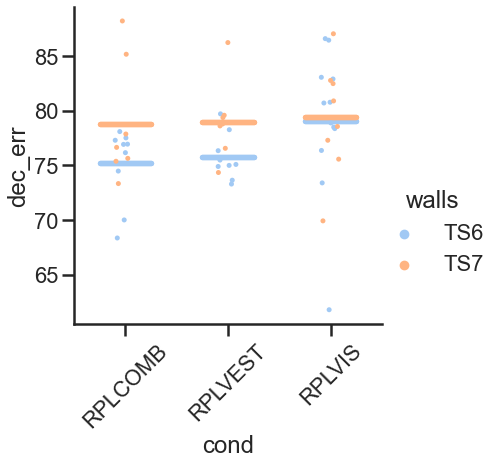

In [609]:
y = 'dec_err'
_inp = df_dec_pas_fixed_walls
_inp = _inp[(_inp.dec_err > 0) & (_inp.ringness > 0)].groupby(['cond' ,'walls', 'rec_id']).mean().reset_index()
_inp[y] = abs(_inp[y])

sns.catplot(x = 'cond', y = y, hue = 'walls' , data = _inp, size  = 6, orient = 'v', legend = True)
sns.pointplot(x = 'cond', y = y, hue = 'walls', data = _inp, join=False, ci=0, capsize=.5, 
              scale=0, orient = 'v')

# sns.swarmplot(data =_inp, x = "vr_env", y = y, size=3, color = sns.color_palette("tab10")[:2] )
# for axes in plot.axes.flat:
#     _ = axes.set_xticklabels([t.get_text().split(" ")[0] for t in axes.get_xticklabels()], rotation=45)
    
# plt.savefig('vectorlength_by_cond.pdf', transparent=False)
# plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend([],[], frameon=False)

In [709]:
def consecutive(data, stepsize=1):
    return np.split(data, np.where(np.diff(data) != stepsize)[0]+1)

a = np.array([0, 47, 48, 49, 50, 97, 98, 99])
vspan = consecutive(a)

In [1050]:
def burst_amp_std(y, yaw, thres):
#     thres = y.mean()
    peaks, _ = find_peaks(y, prominence = thres, distance = 20, height = 3)
    b_rad = np.deg2rad((yaw[peaks]))

    # number of bursts
    if peaks.size > 10:
        mean_b = y[peaks].mean()
        b_std = circstd(b_rad)
    else:
        mean_b = np.nan
        b_std = np.nan
    return peaks, mean_b, b_std

In [712]:
df_tun_proc.cond.unique()

array(['D1', 'L1', 'TS6-HF', 'TS6-MR', 'TS6-RPLCOMB', 'TS6-RPLVIS',
       'TS7-MR', 'TS7-RPLVEST', 'TS7-RPLVIS', 'TS7-HF', 'TS7-RPLCOMB',
       'TS6-OVAR10', 'TS6-OVAR20', 'TS6-RPLVEST', 'TS7-HFLMK',
       'TS6-HFLMK180', 'TS7-HFLMK180', 'TS7-RPL', 'TS7-VIS', 'TS6-RPL',
       'TS6-VIS', 'DARK-VEST', 'TS6-HFLMKDoR', 'TS6-OVAR20BALLDIS',
       'TS6-RPLCOMBBALLDIS', 'TS6-HFLMK30', 'TS6-LMK30', 'VR1'],
      dtype=object)

20220818_JA178_lADN_red_H2_R_L1
20220818_JA178_lADN_red_H2_VR1_TS6-HF
20220819_JA178_lADN_red_H2_R_L1
20220819_JA178_lADN_red_H2_VR1_TS6-HF
20220819_JA178_lADN_red_H2_VR1_TS7-HF
20220823_JA178_lADN_red_H2_R_L1
20220823_JA178_lADN_red_H2_VR1_TS6-HF
20220823_JA178_lADN_red_H2_VR1_TS7-HF
20220824_JA178_lADN_red_H2_R_L1
20220824_JA178_lADN_red_H2_VR1_TS6-HF
20220824_JA178_lADN_red_H2_VR1_TS7-HF
20220802_JA179_lADN_red_H2_VR1_L1
20220802_JA179_lADN_red_H2_VR1_TS6-HF
20220802_JA179_lADN_red_H2_VR1_TS7-HF
20220803_JA179_lADN_red_H2_VR1_L1
20220803_JA179_lADN_red_H2_VR1_TS6-HF
20220803_JA179_lADN_red_H2_VR1_TS7-HF
20220804_JA179_lADN_red_H2_VR1_L1
20220804_JA179_lADN_red_H2_VR1_TS6-HF
20220804_JA179_lADN_red_H2_VR1_TS7-HF
20220805_JA179_lADN_red_H2_VR1_L1
20220805_JA179_lADN_red_H2_VR1_TS6-HF
20220805_JA179_lADN_red_H2_VR1_TS7-HF
20220811_JA179_rADN_yel_H1_VR1_L1
20220811_JA179_rADN_yel_H1_VR1_TS6-HF
20220811_JA179_rADN_yel_H1_VR1_TS7-HF
20220812_JA179_rADN_yel_H1_VR1_L1
20220812_JA179_rADN_ye

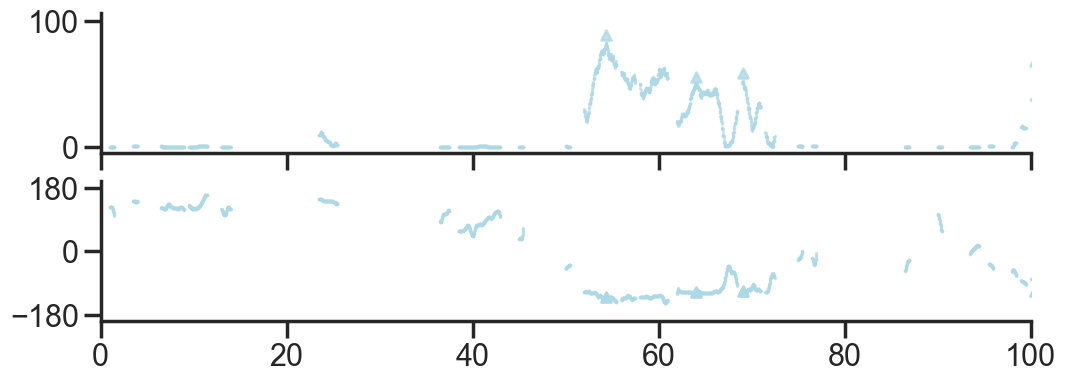

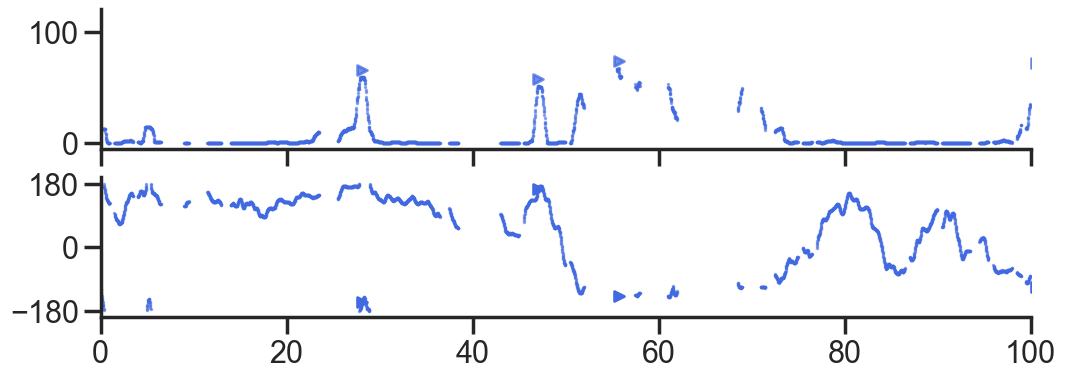

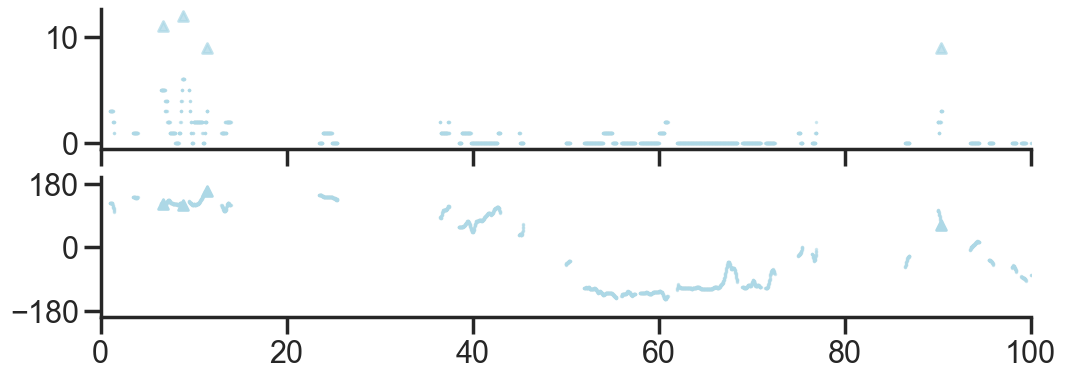

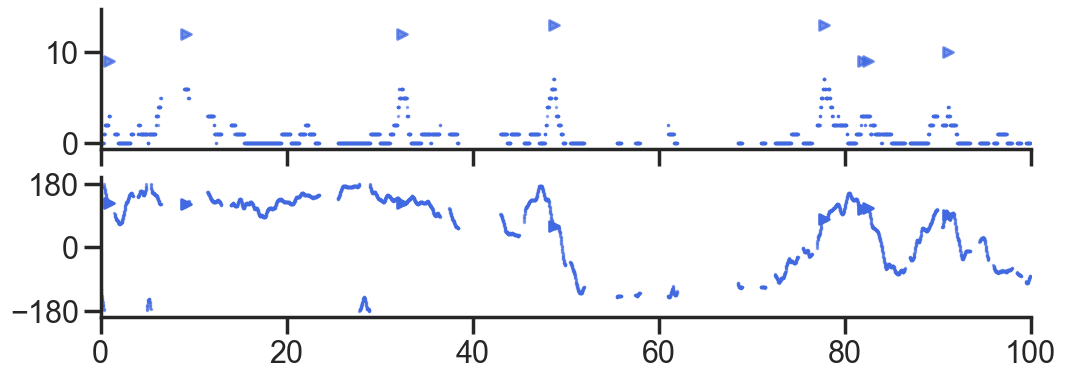

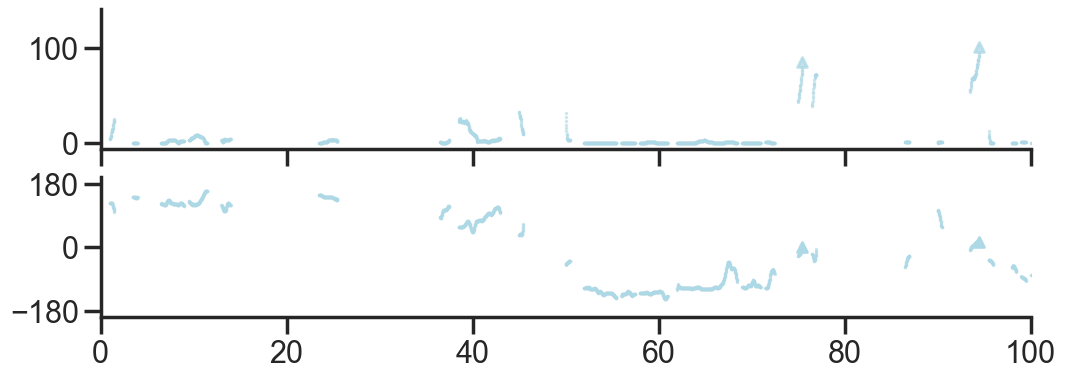

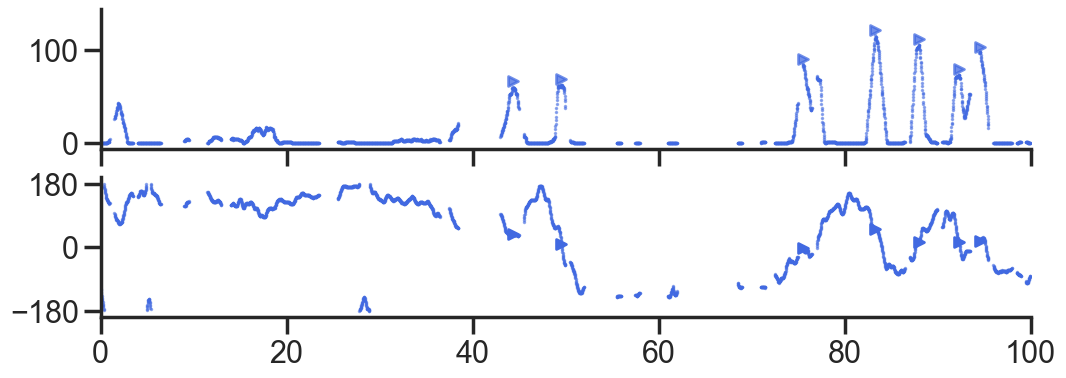

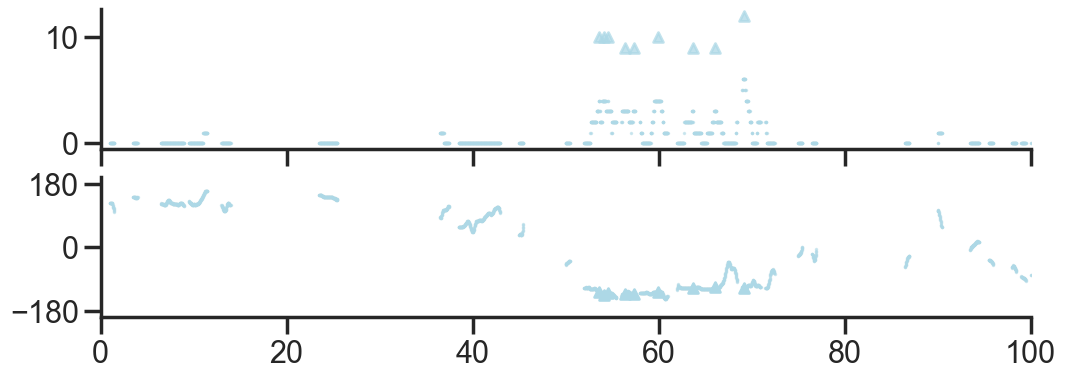

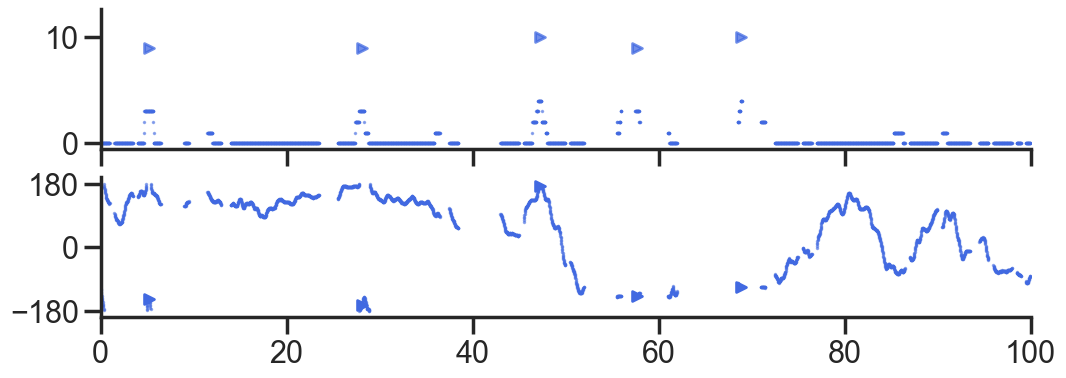

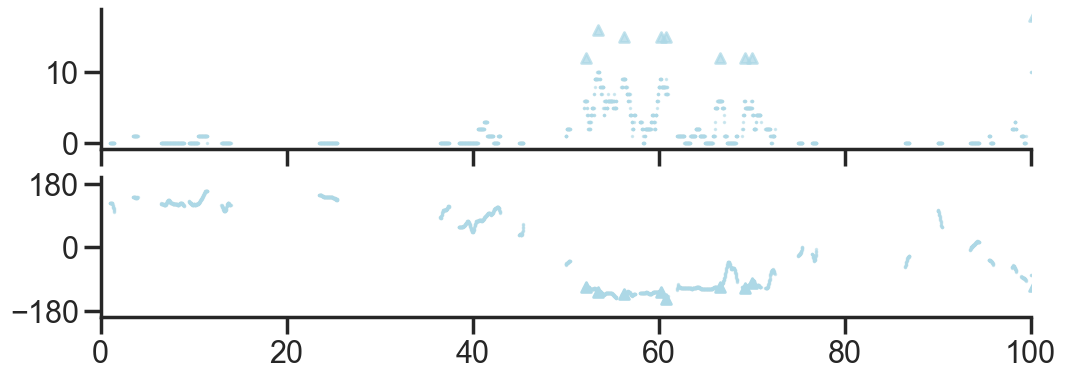

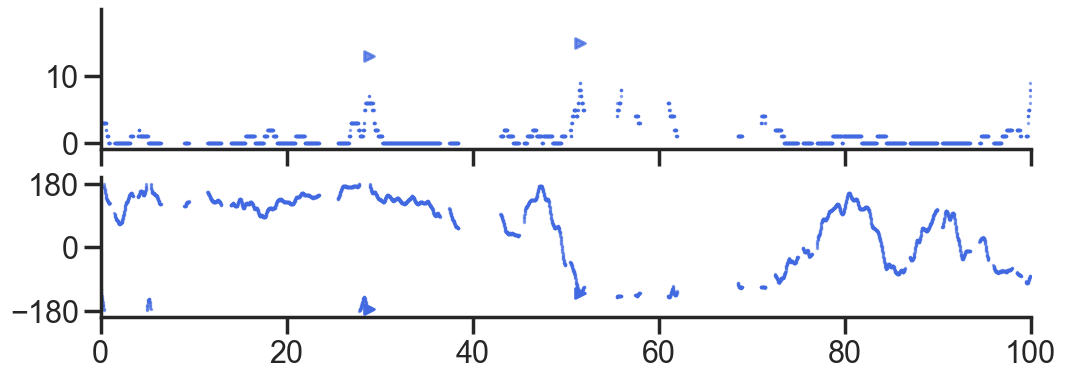

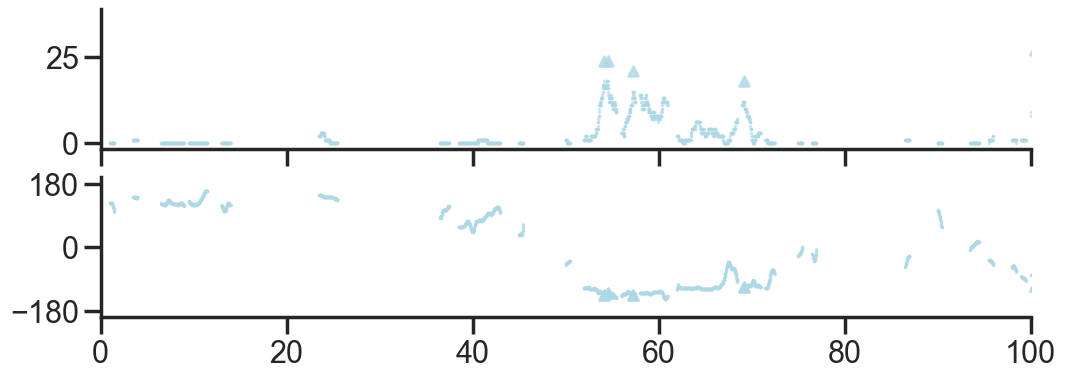

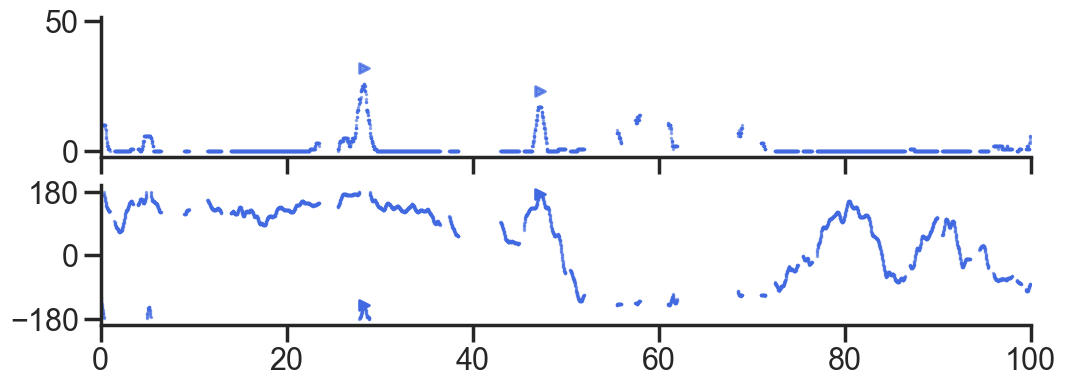

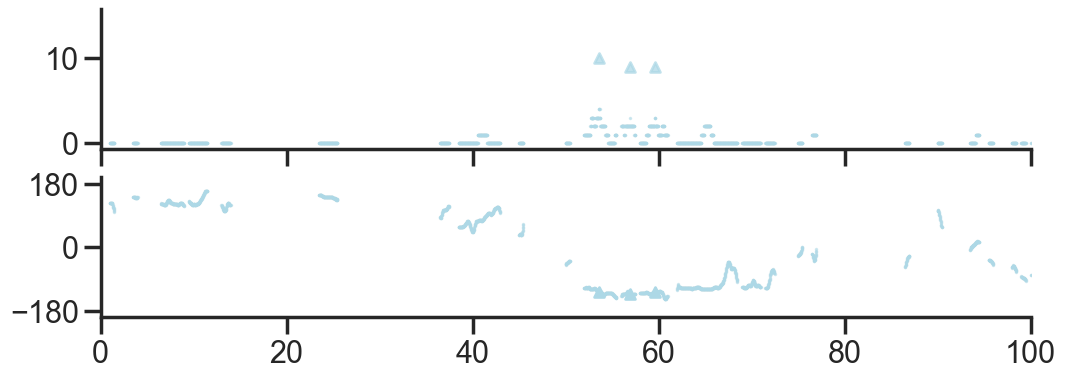

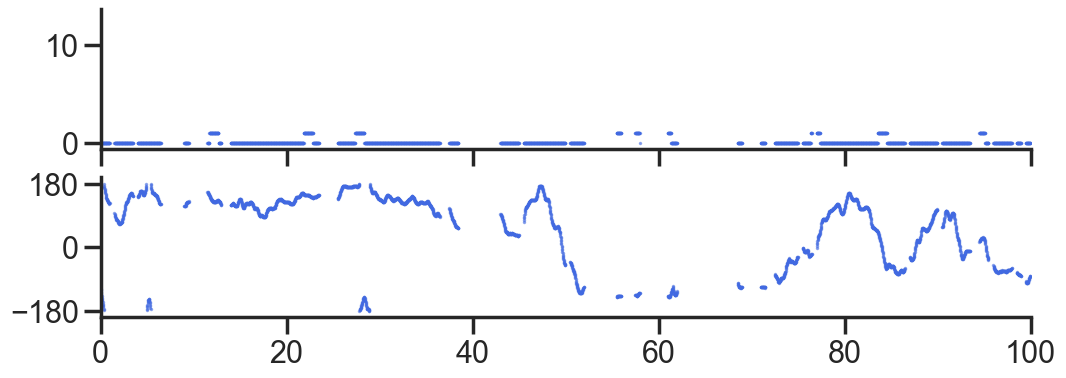

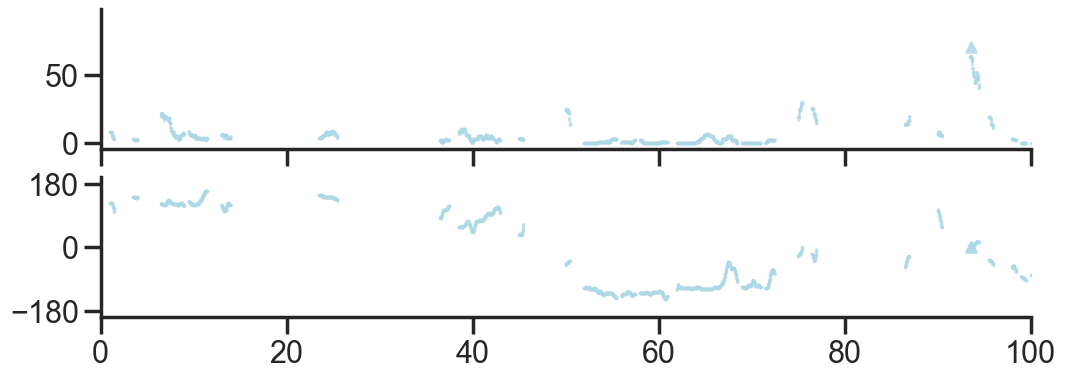

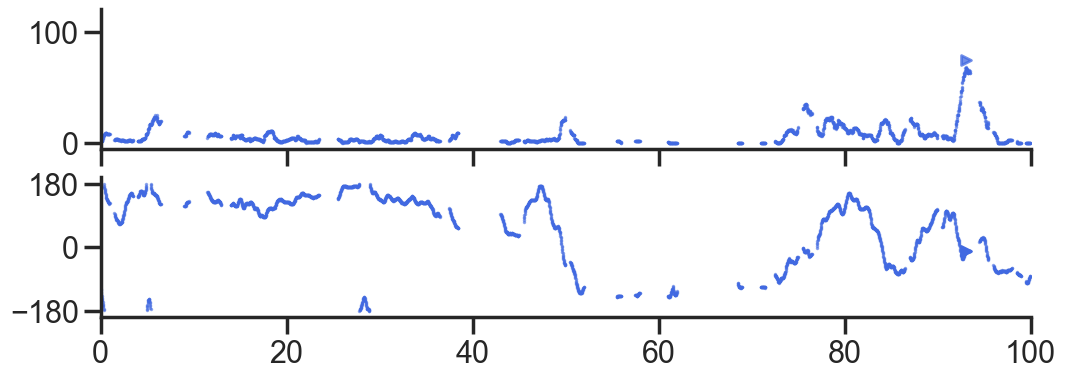

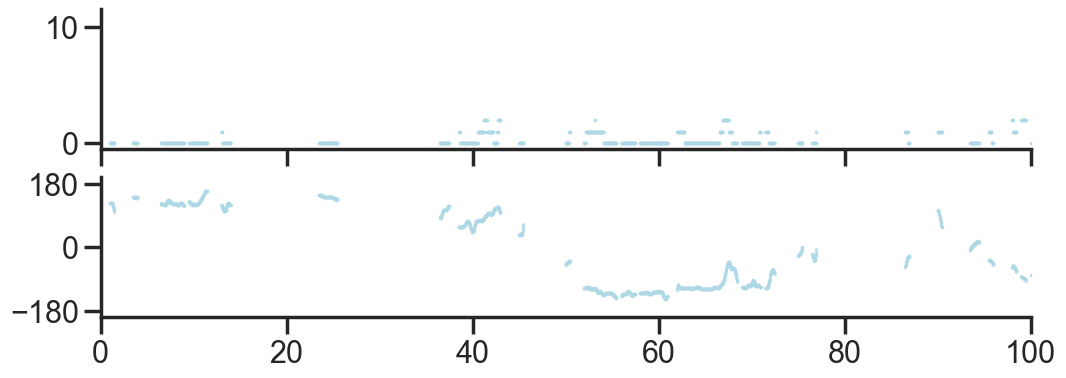

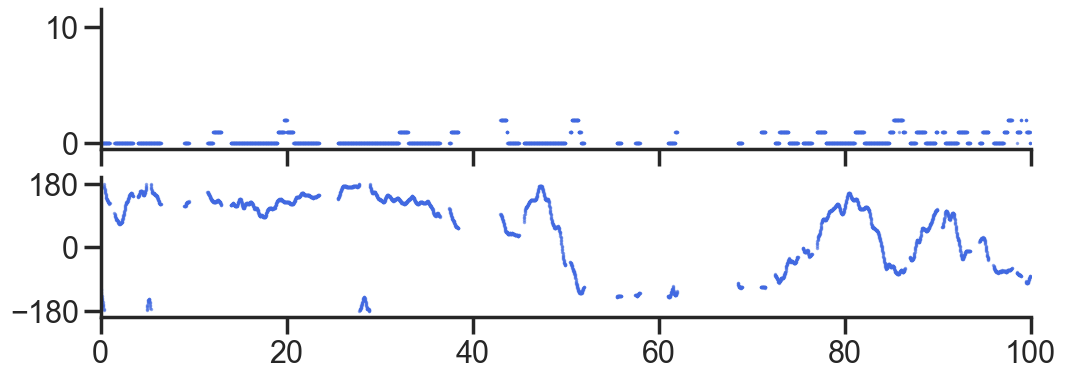

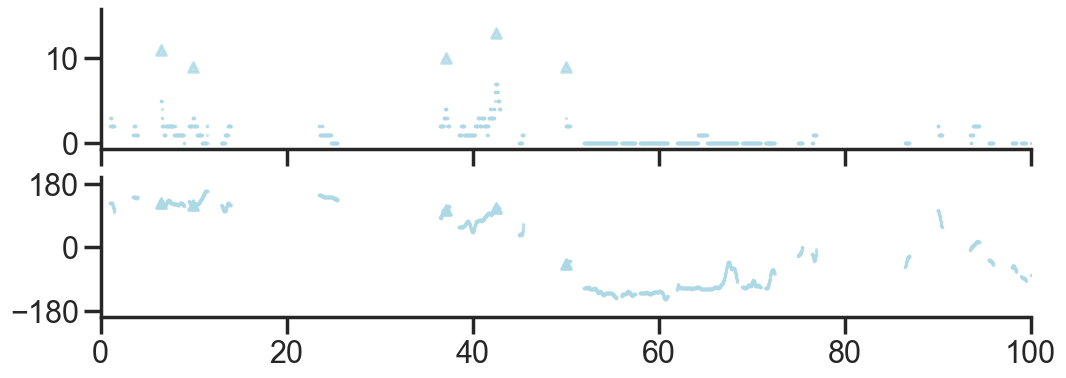

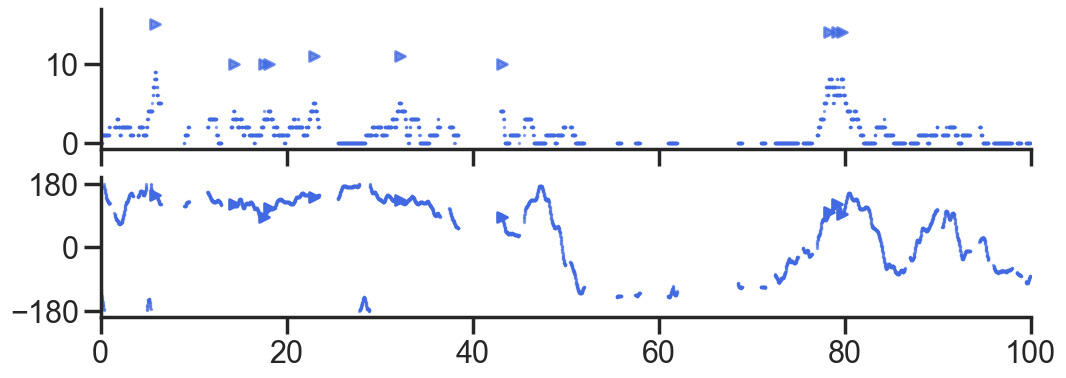

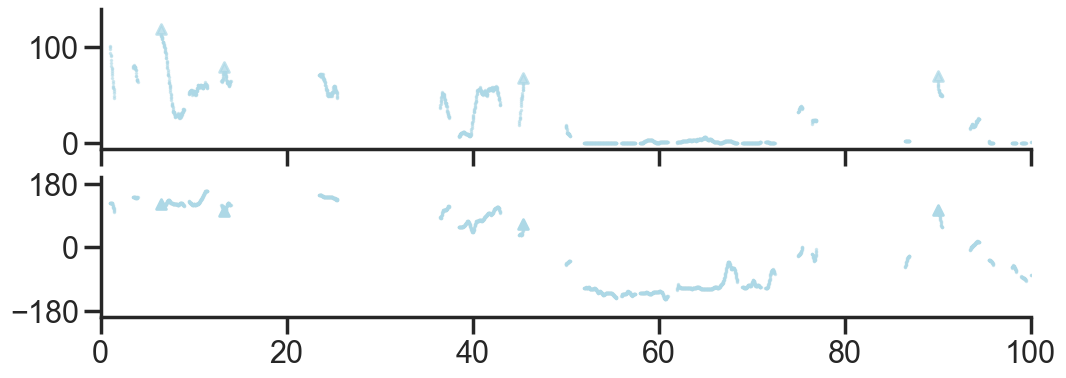

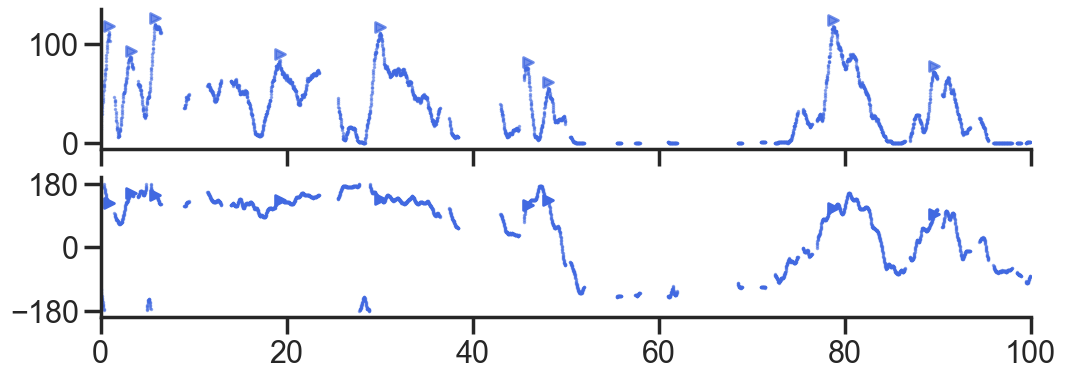

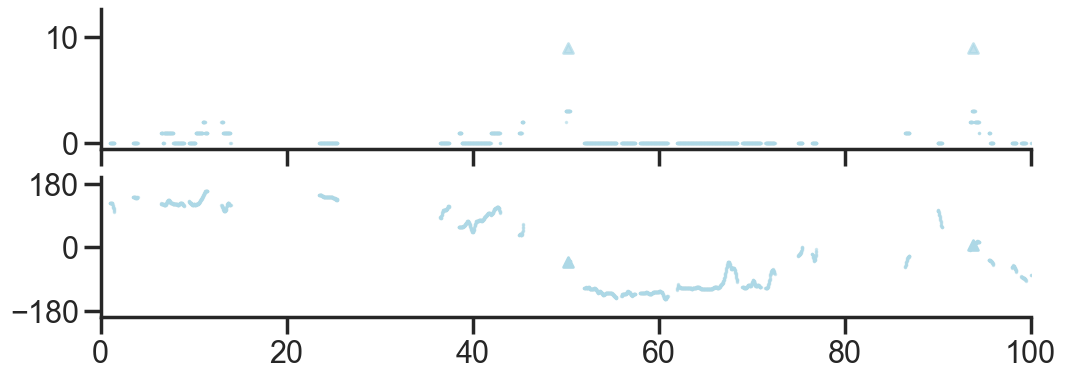

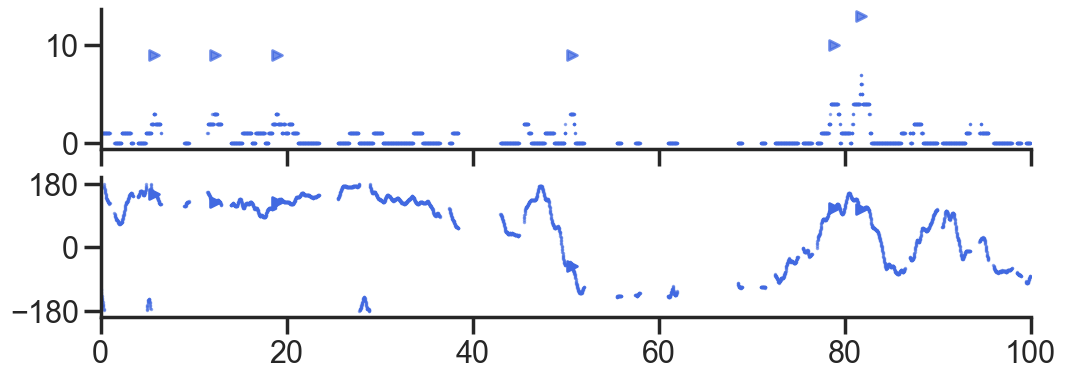

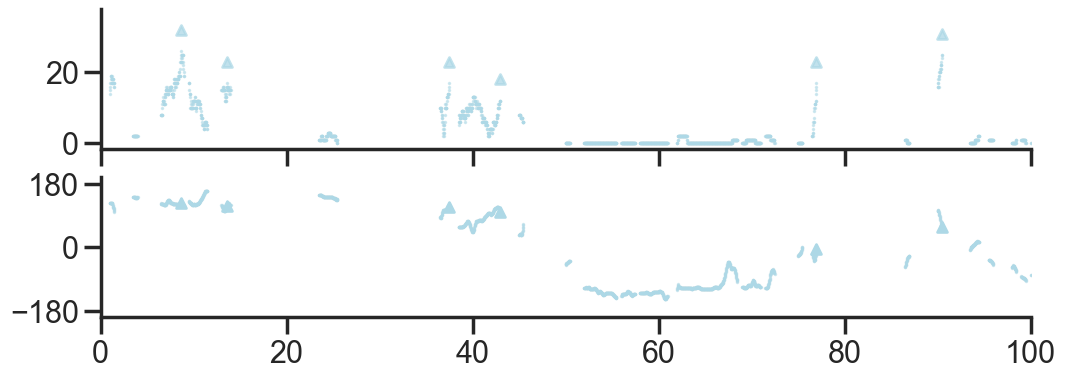

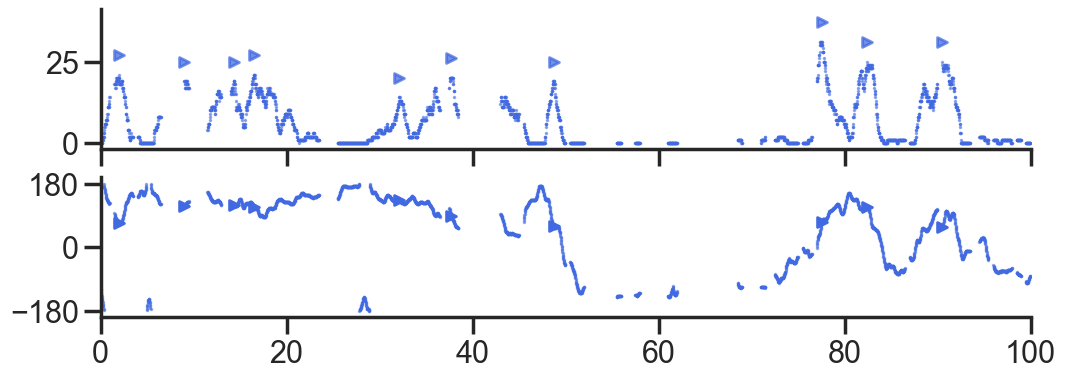

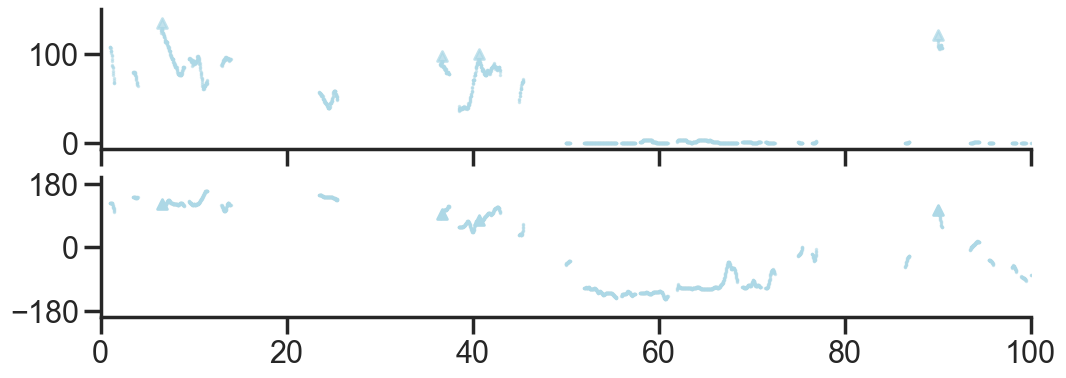

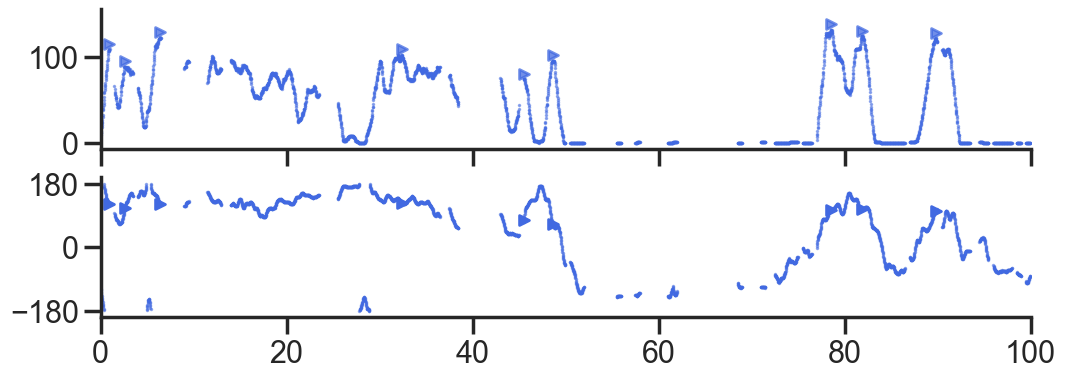

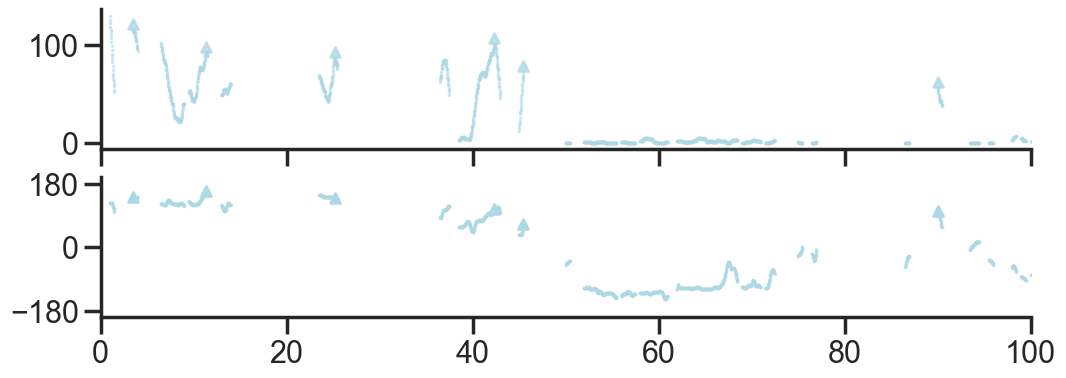

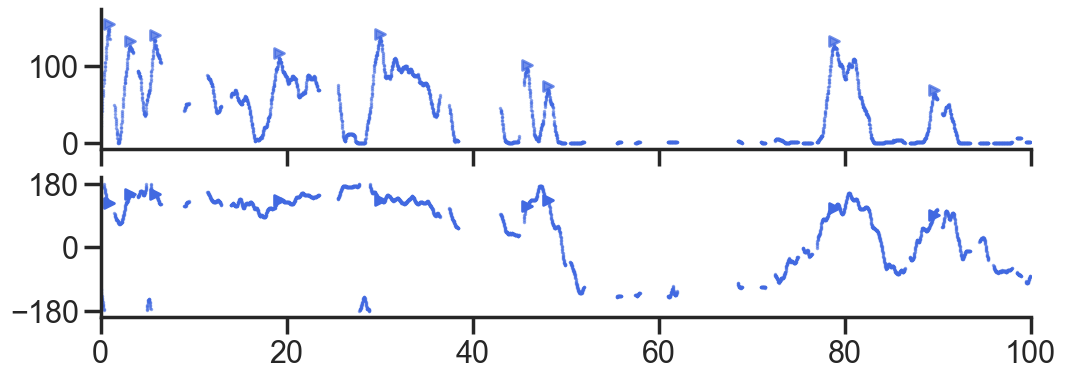

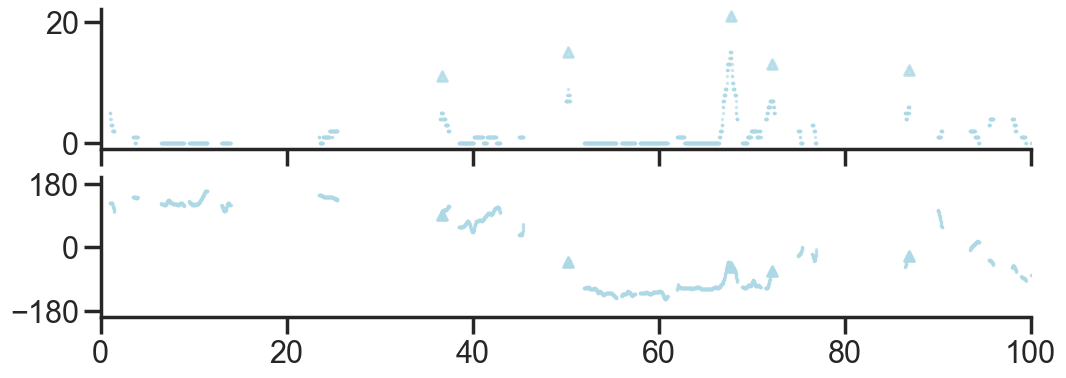

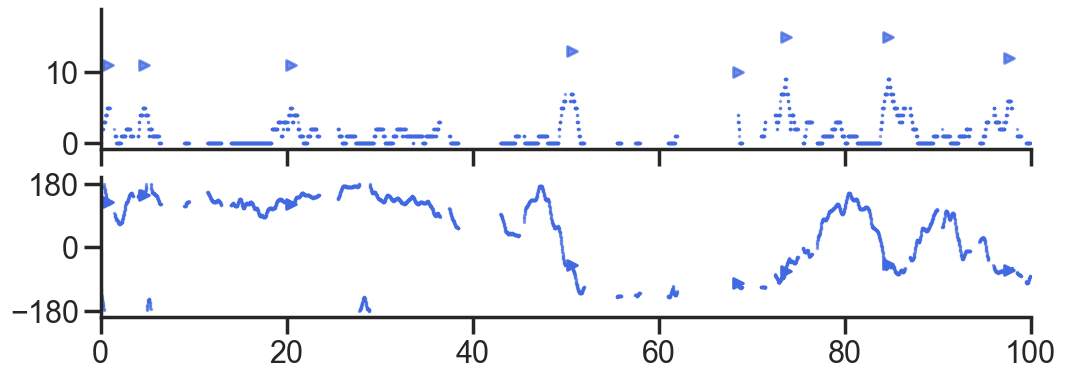

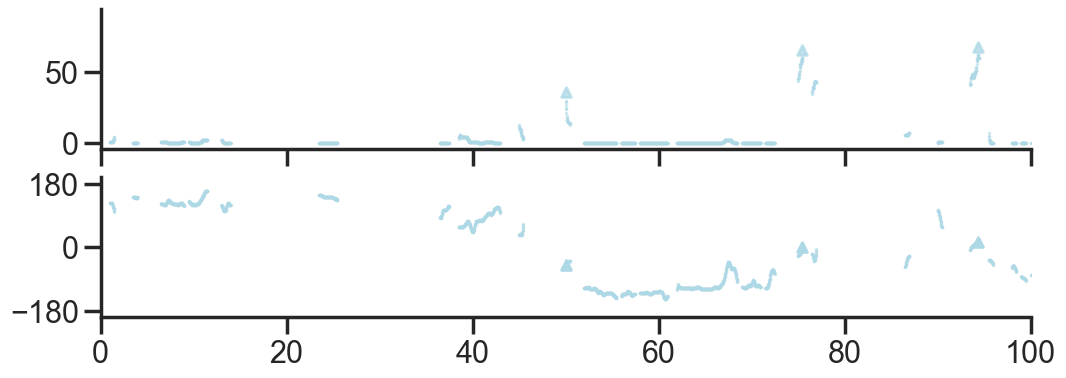

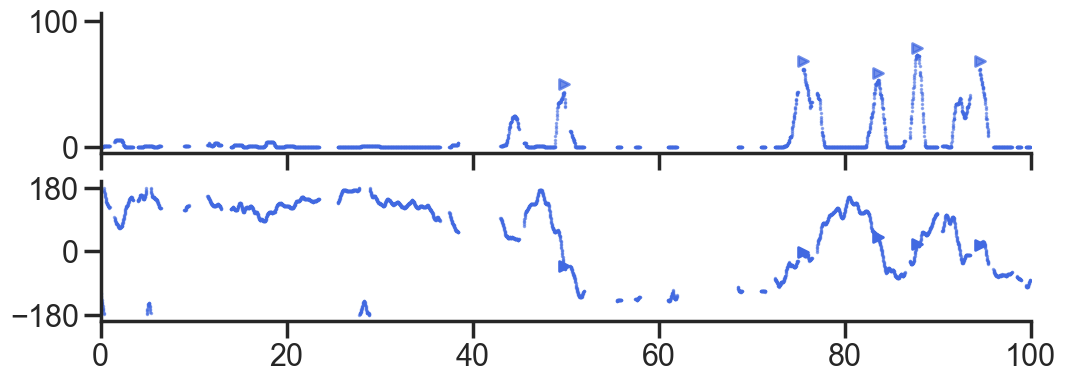

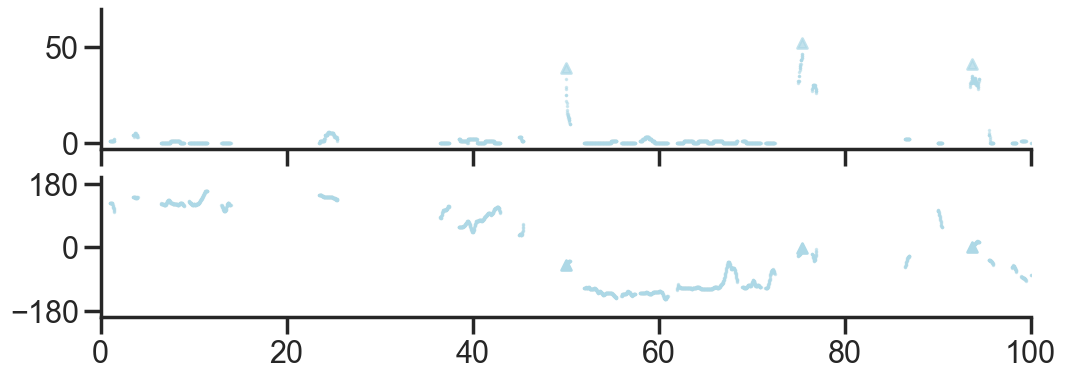

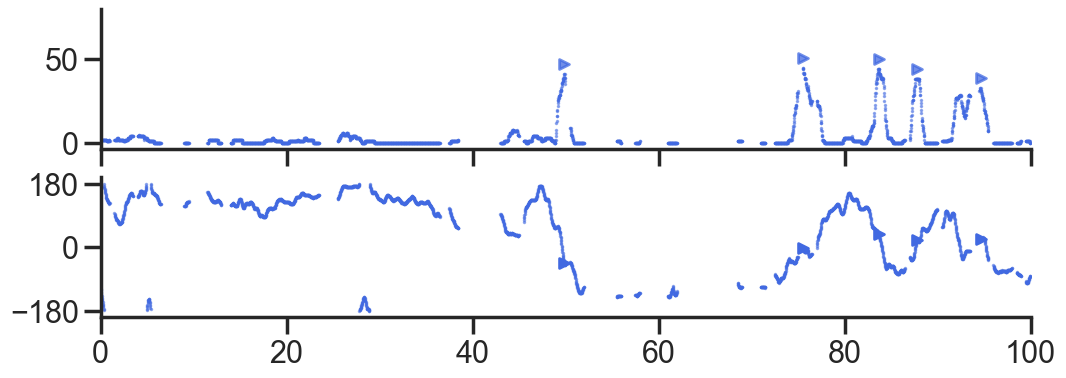

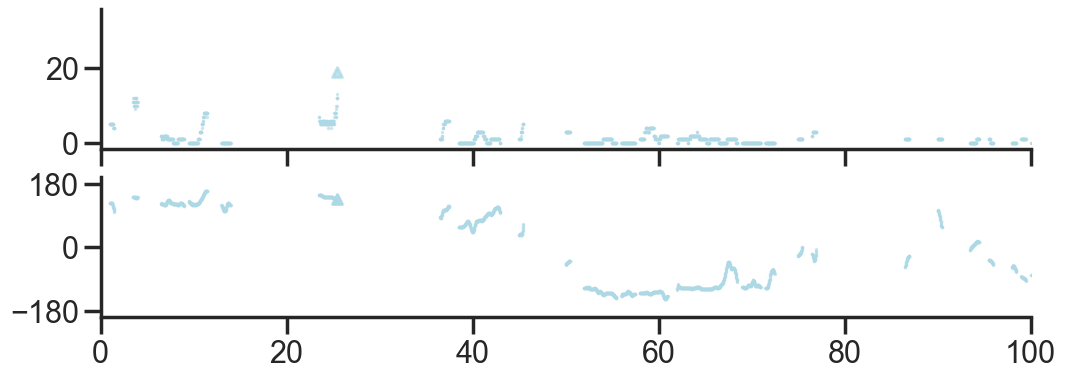

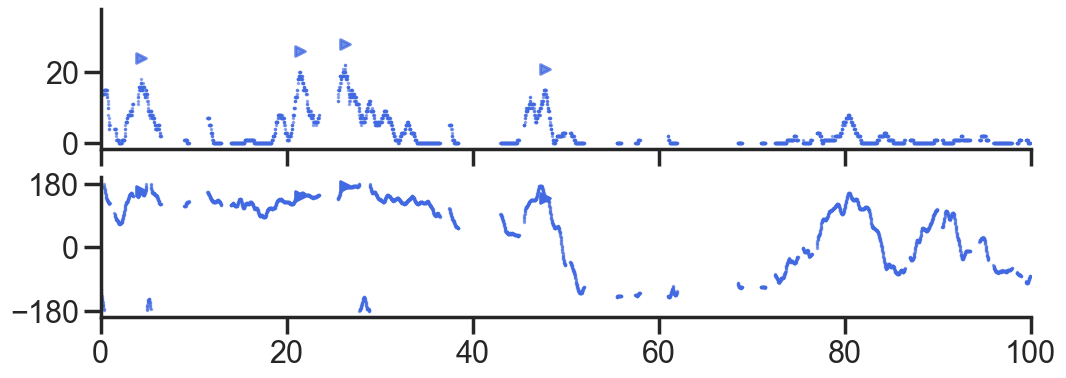

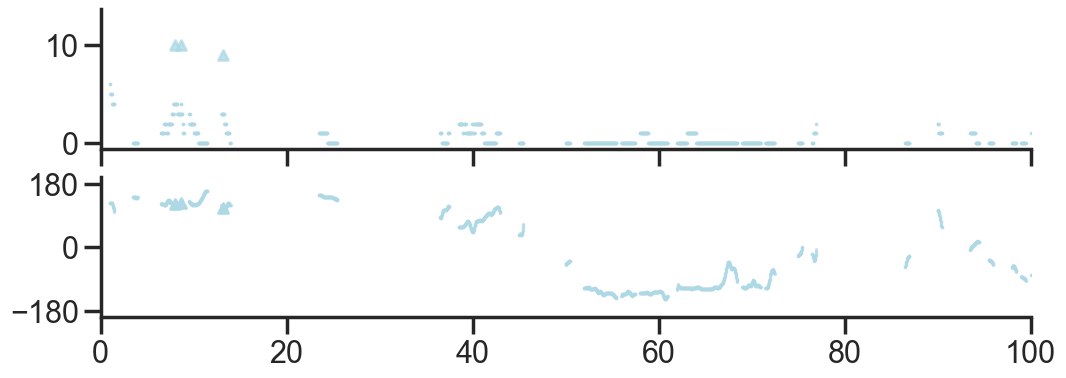

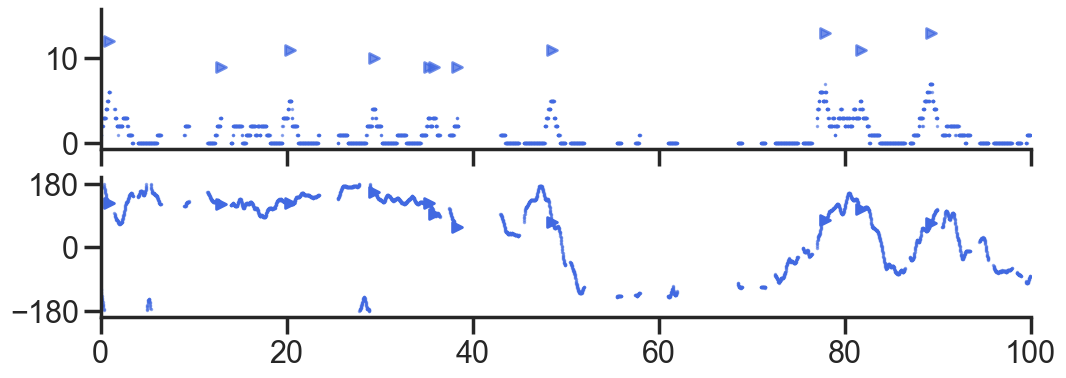

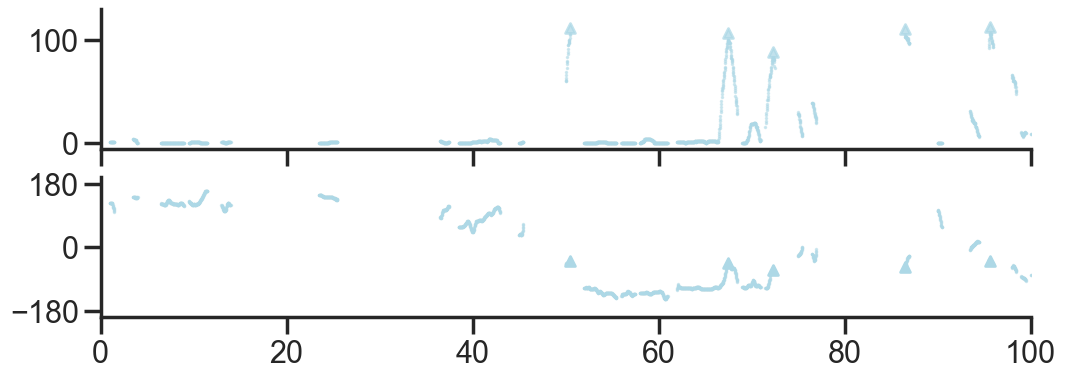

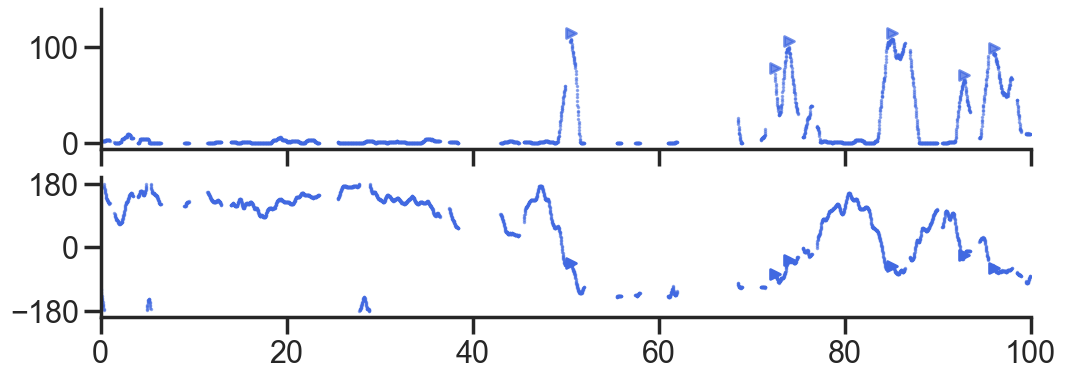

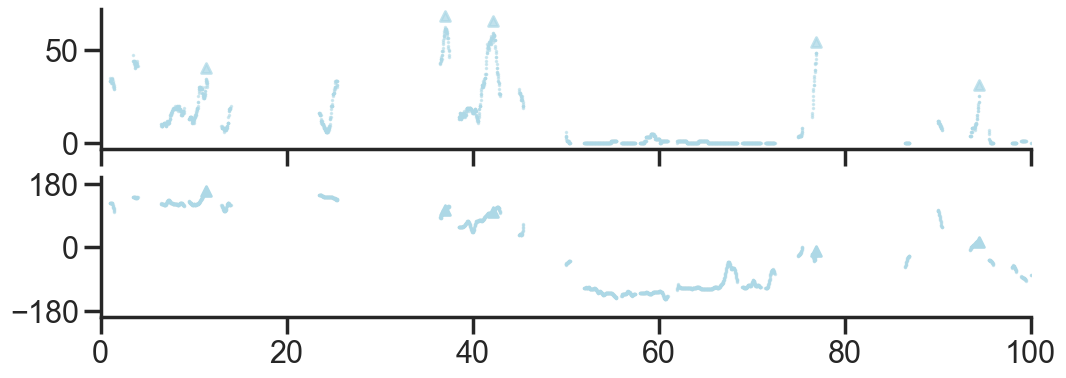

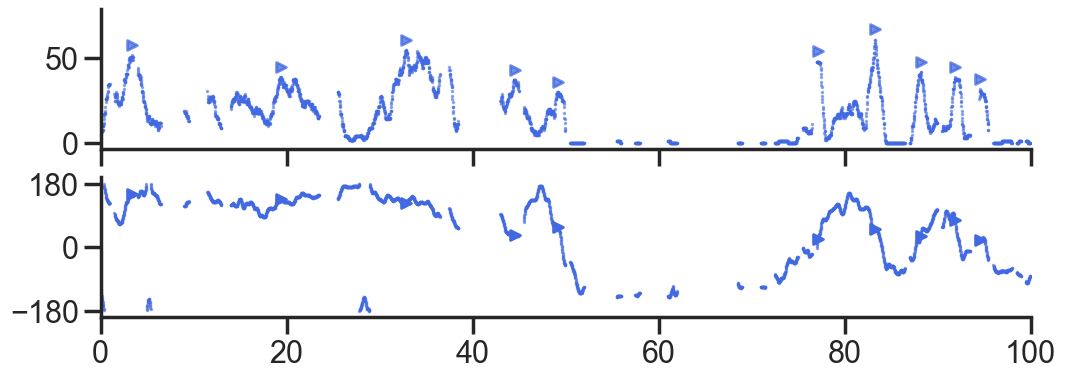

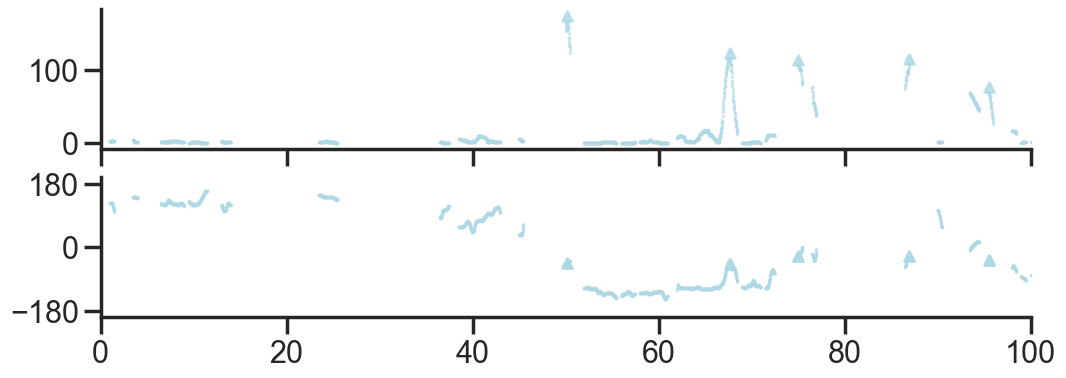

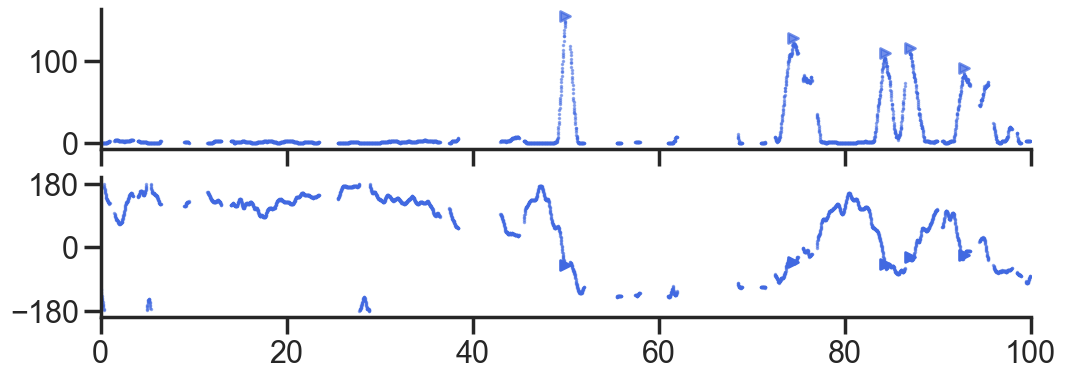

20220810_JA180_lADN_red_H2_VR1_TS6-HF
22490 32490


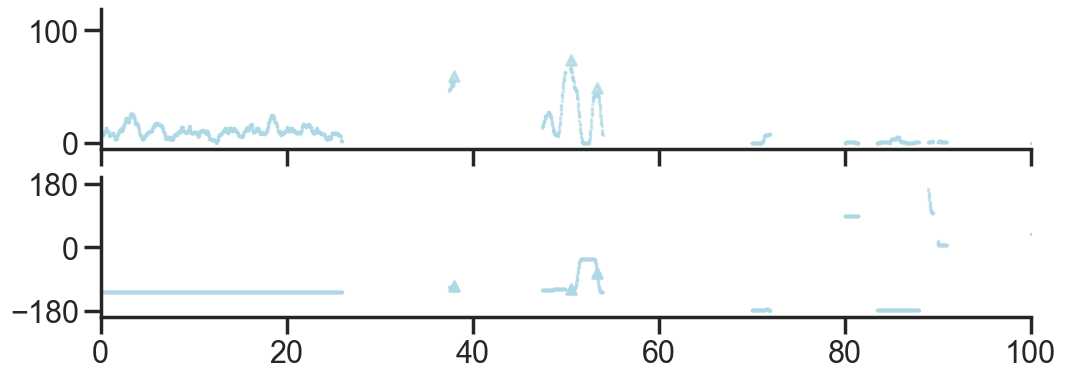

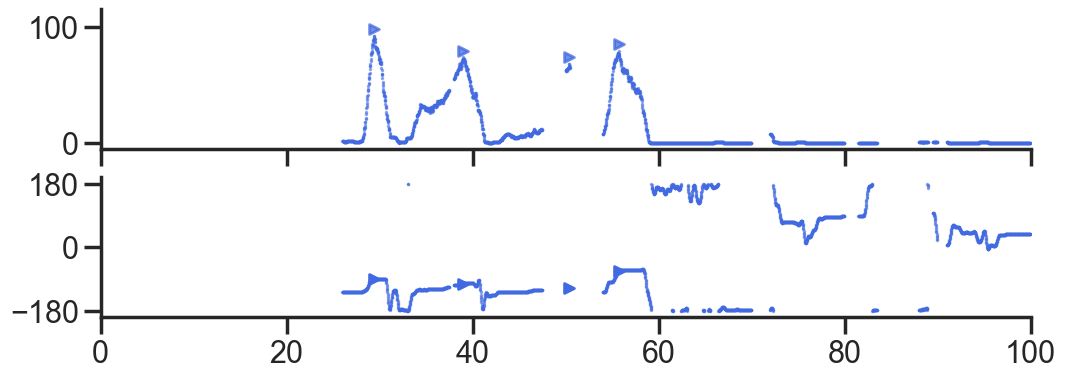

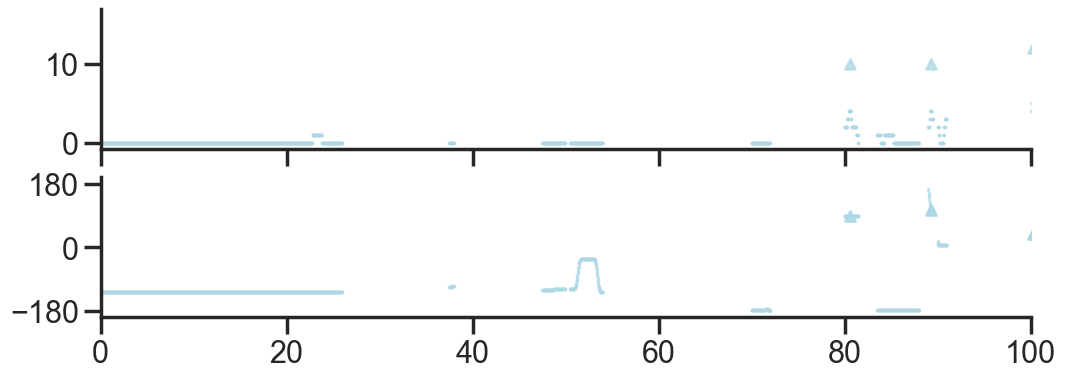

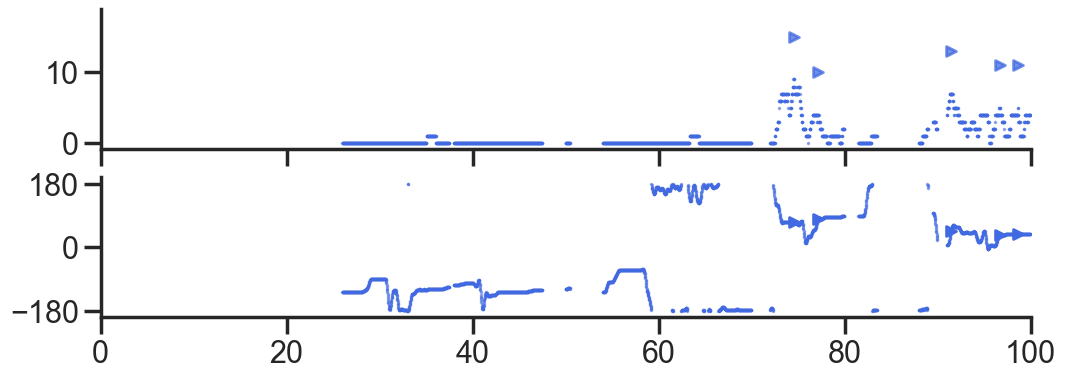

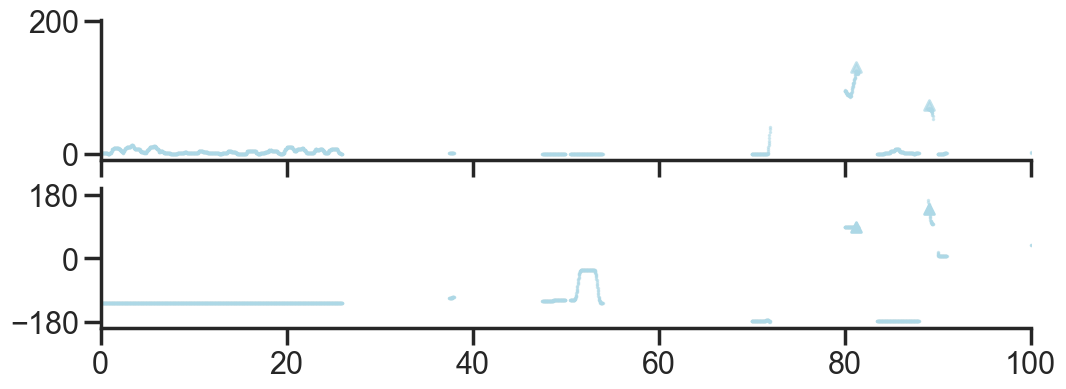

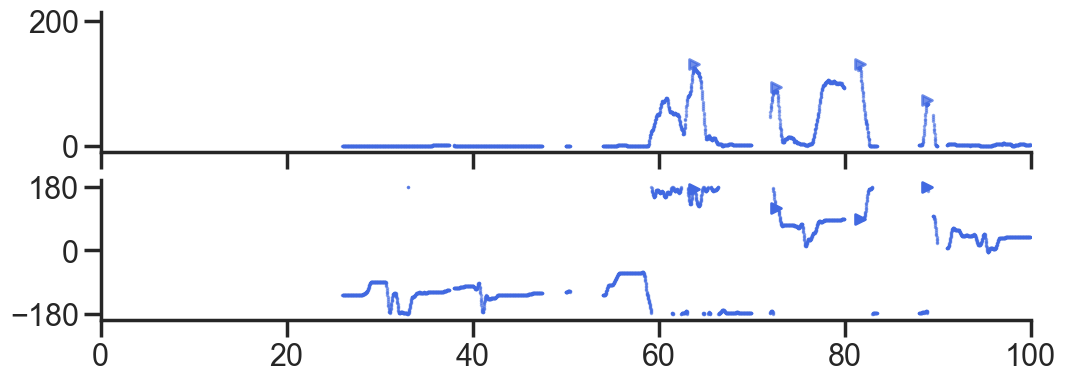

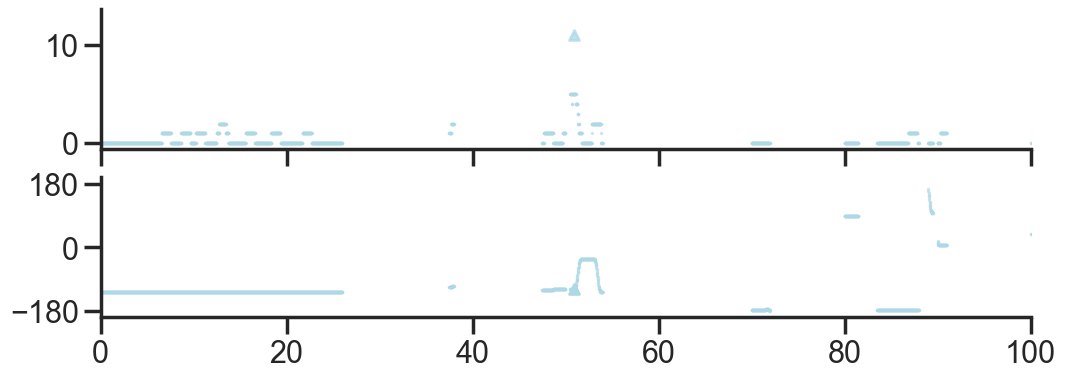

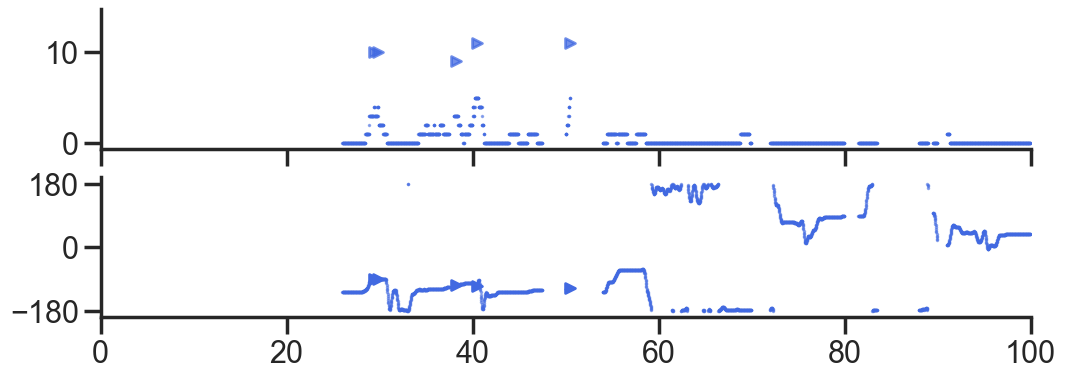

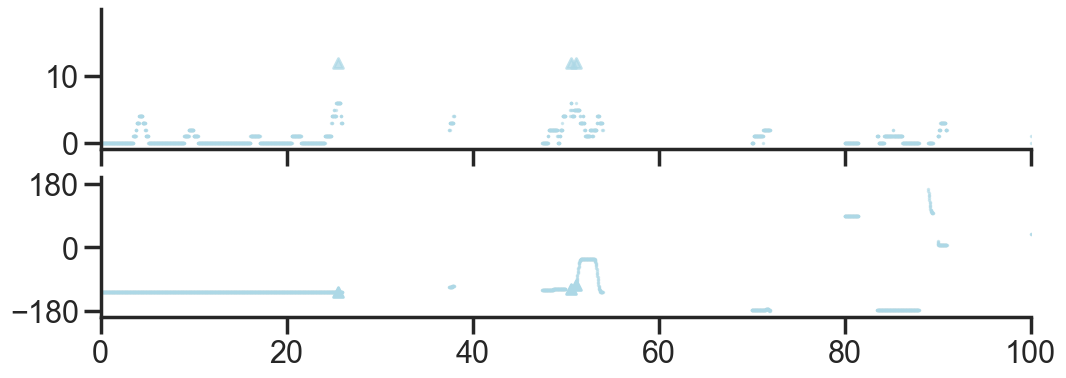

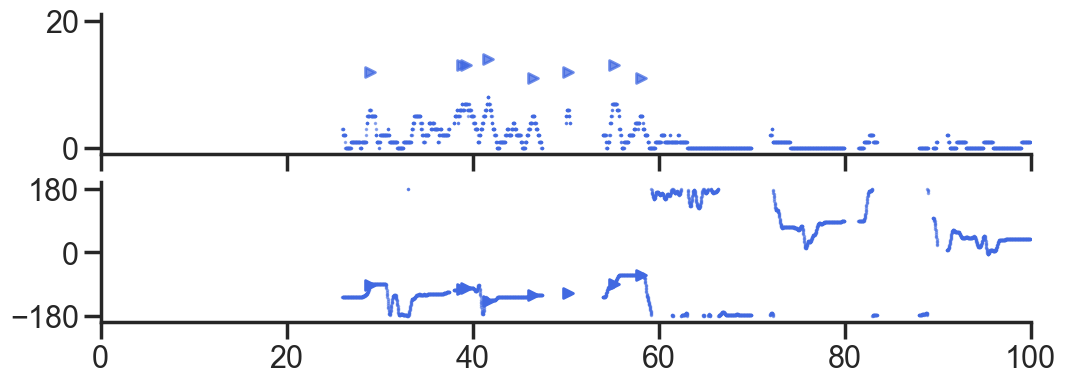

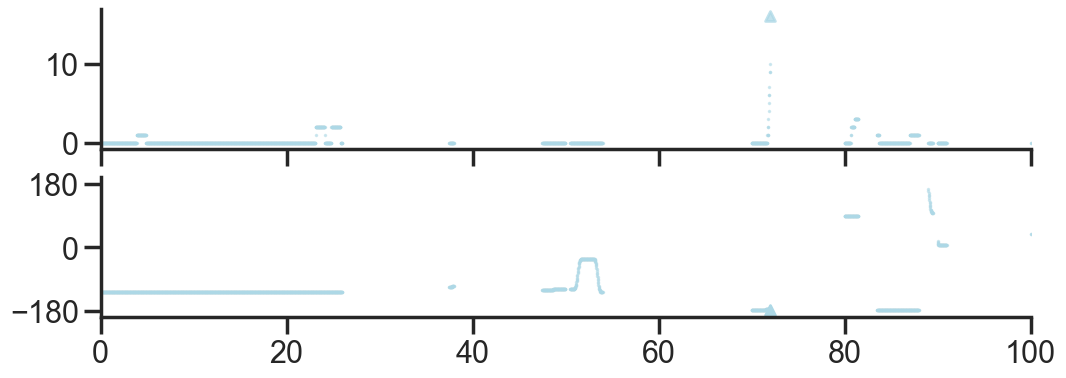

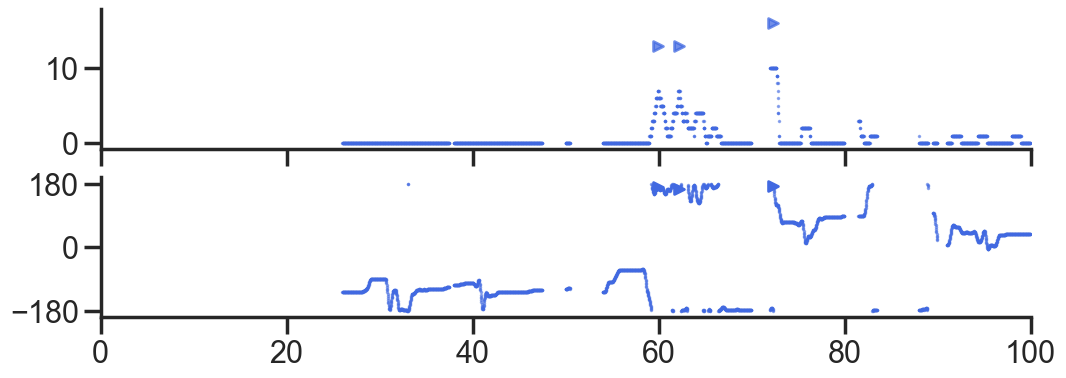

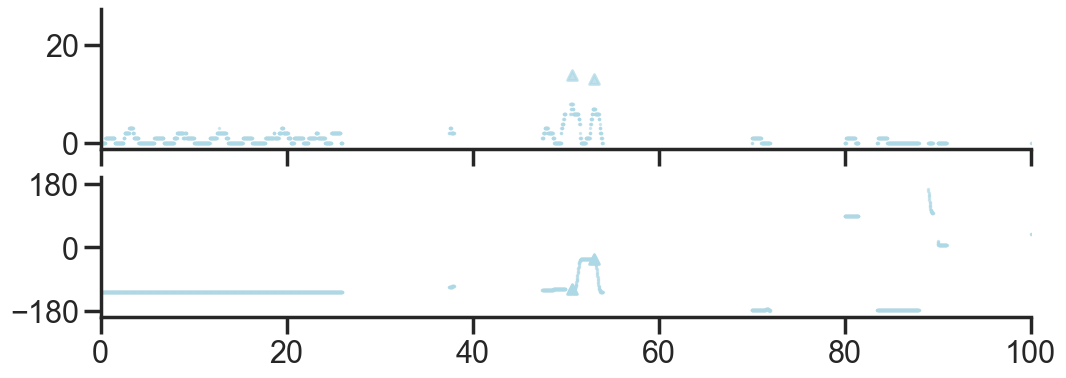

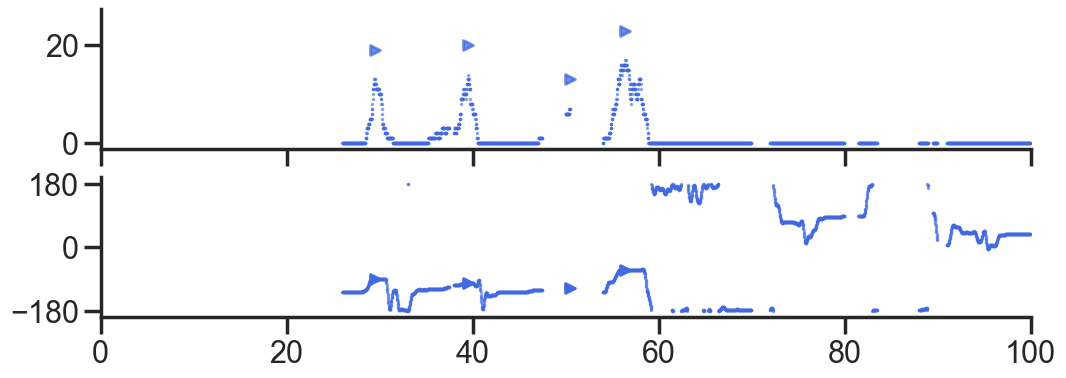

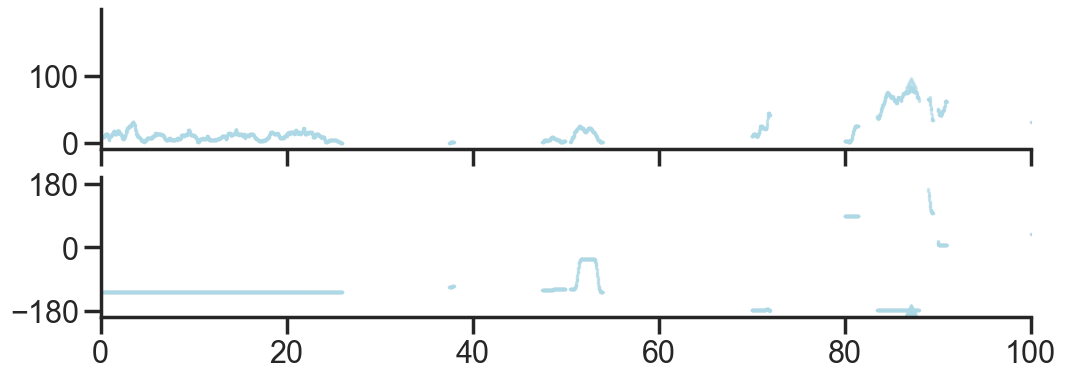

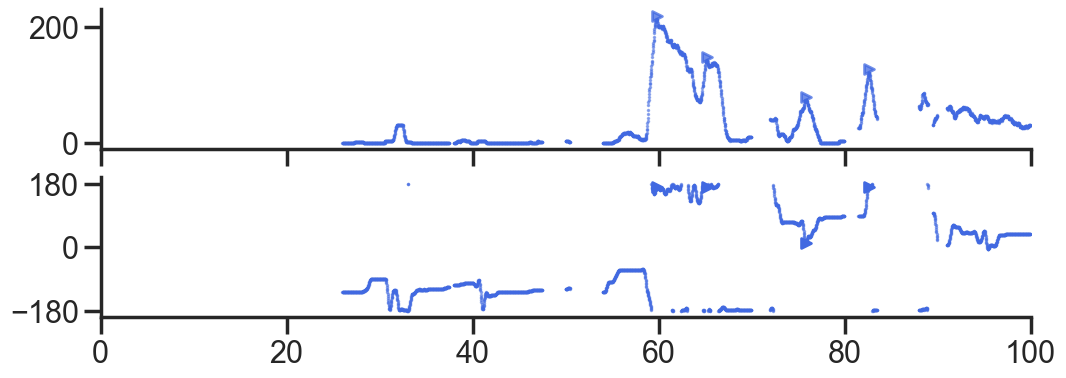

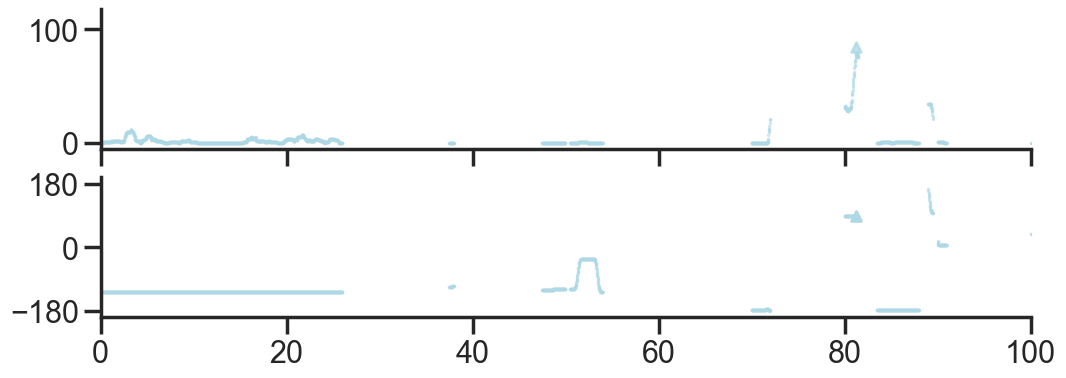

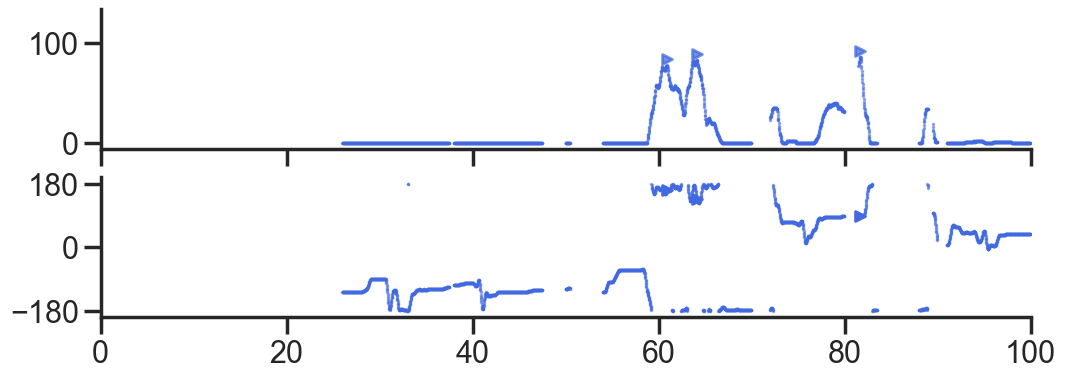

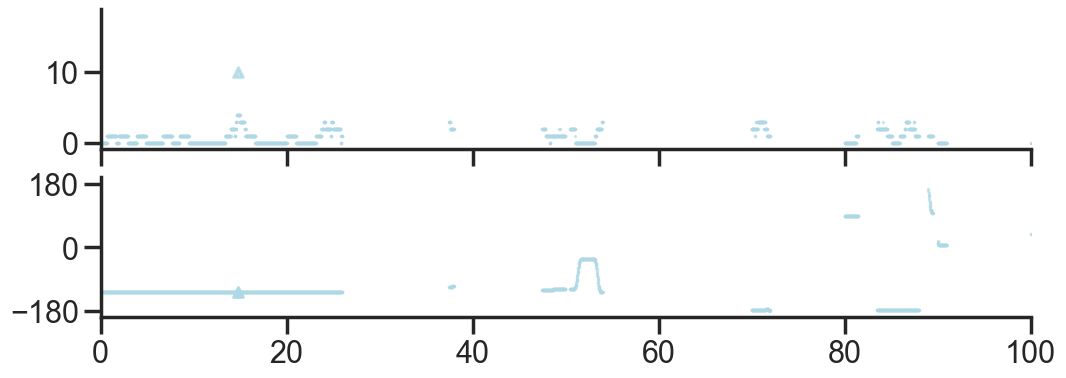

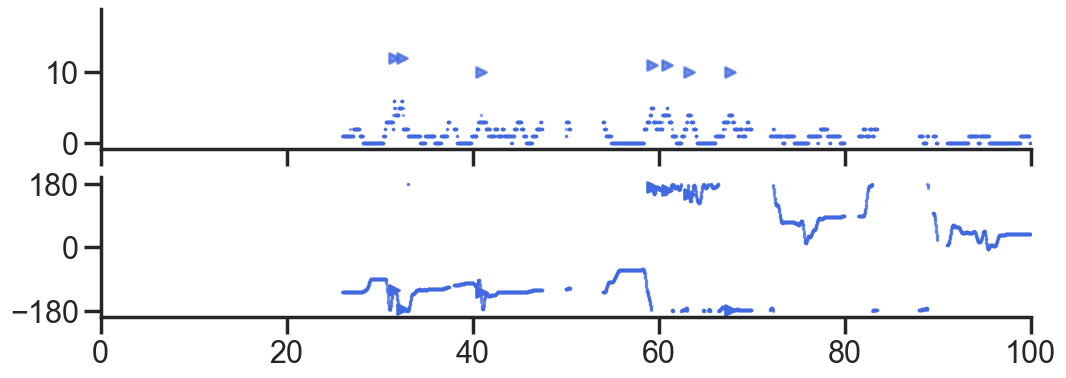

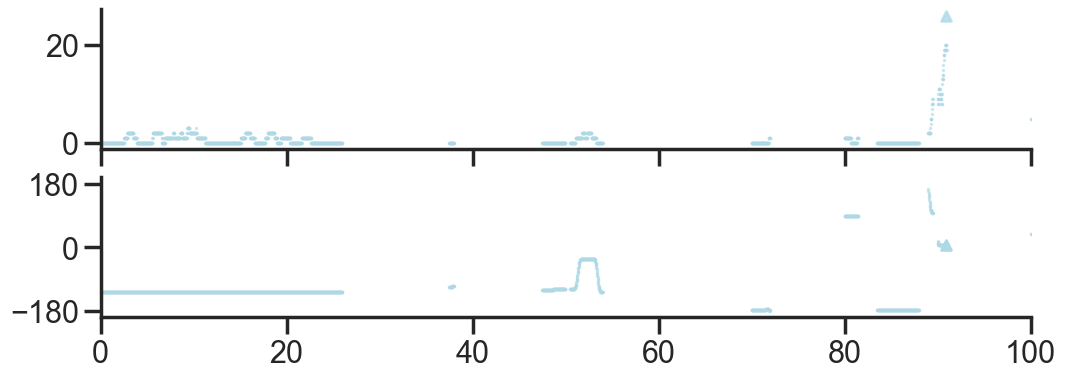

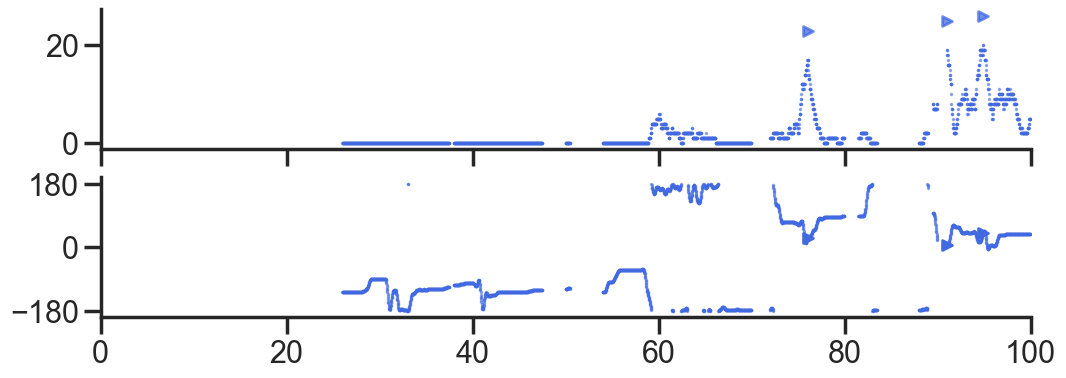

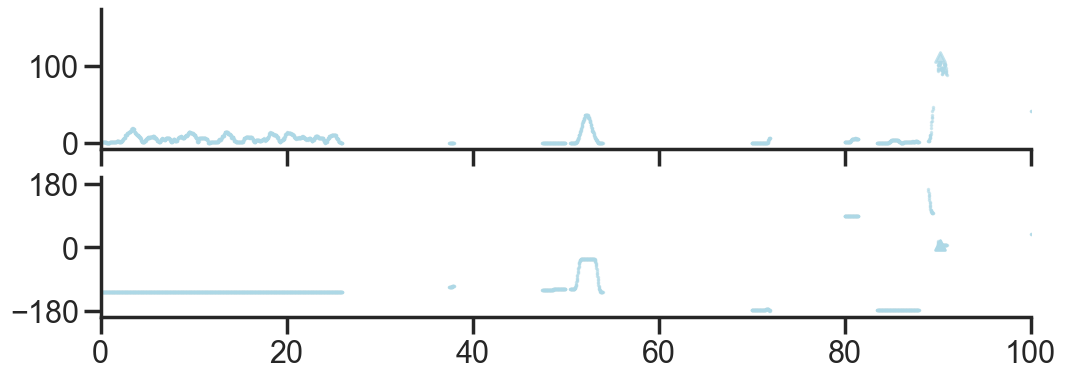

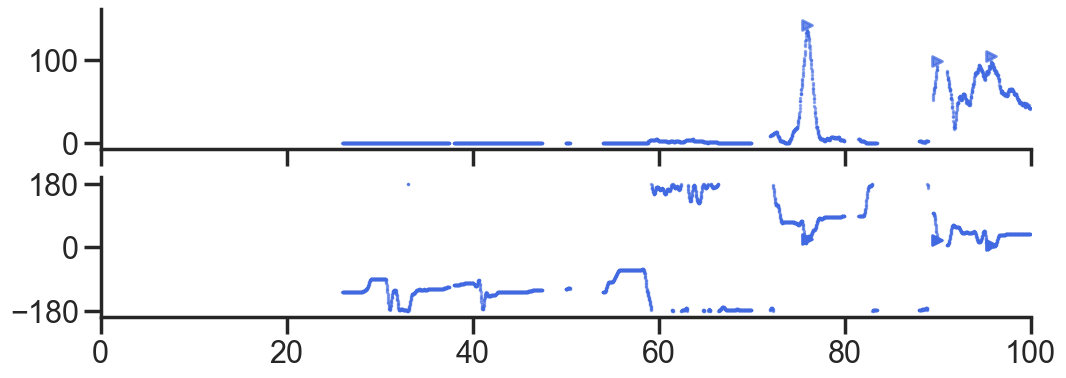

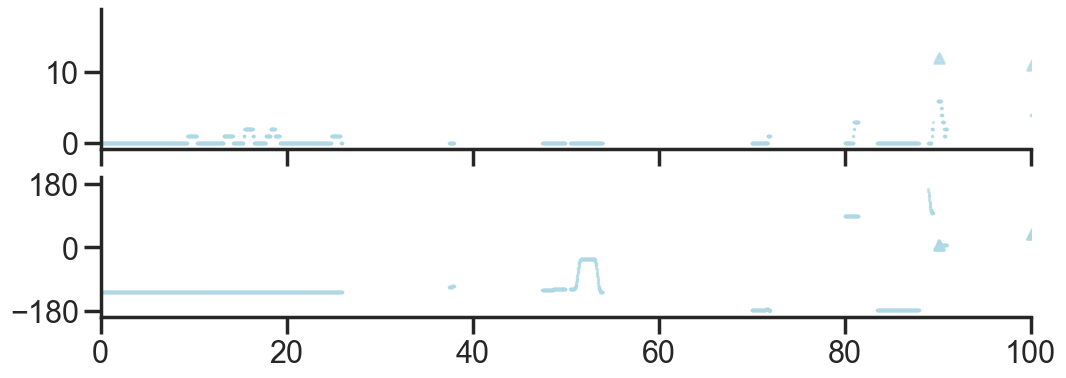

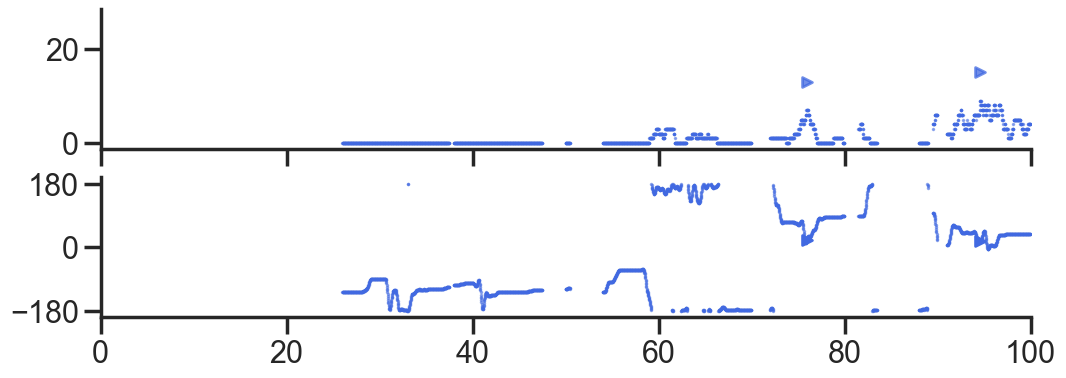

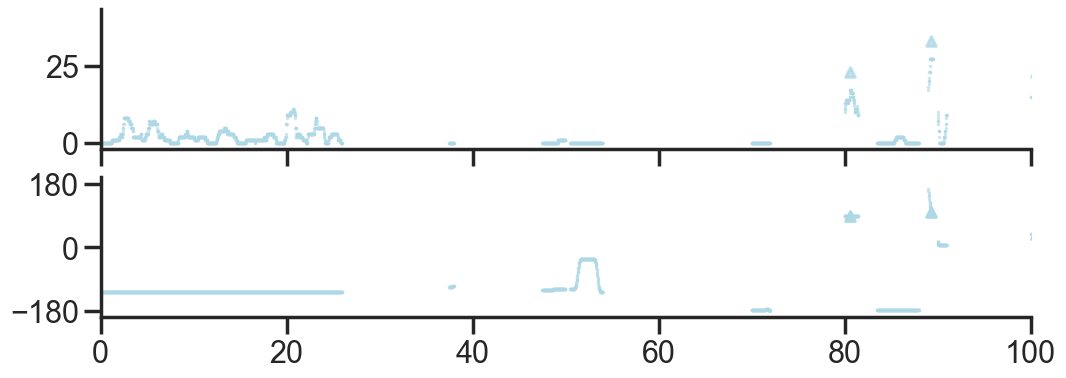

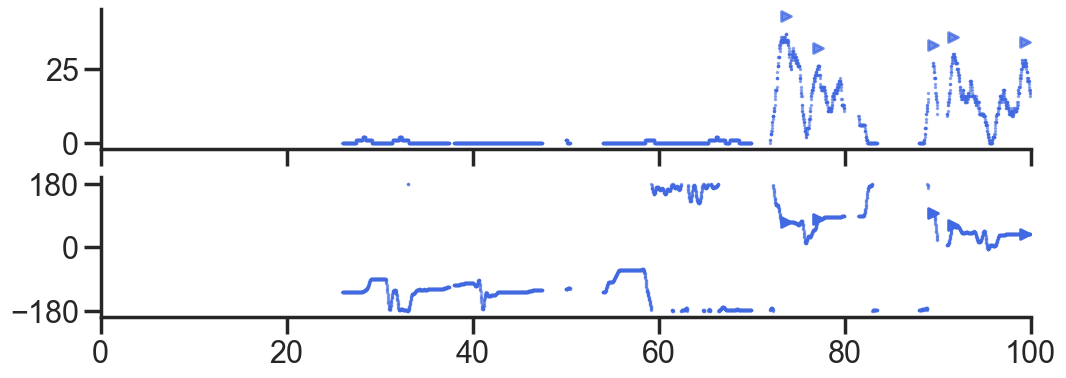

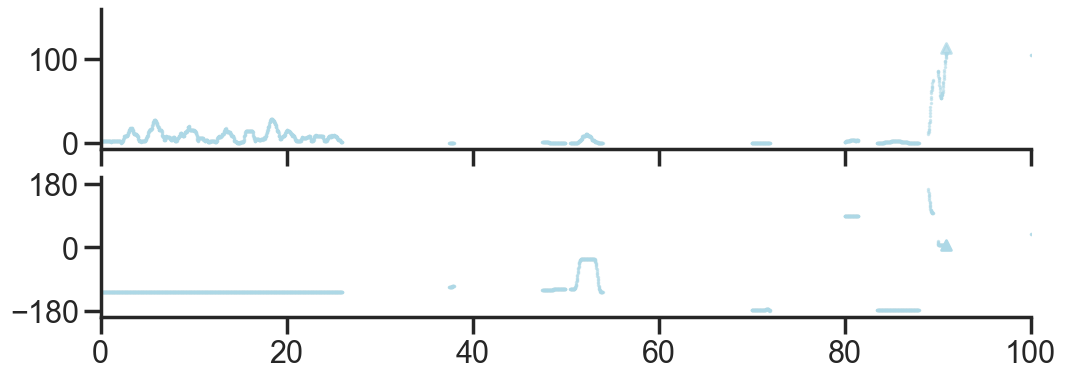

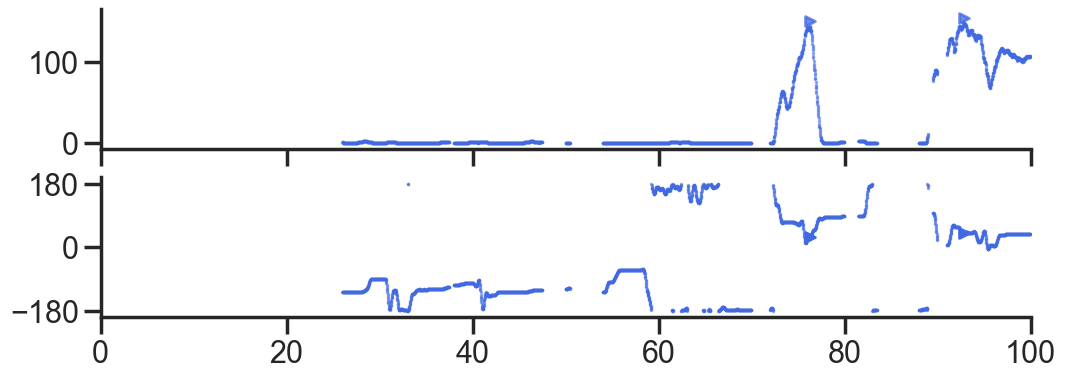

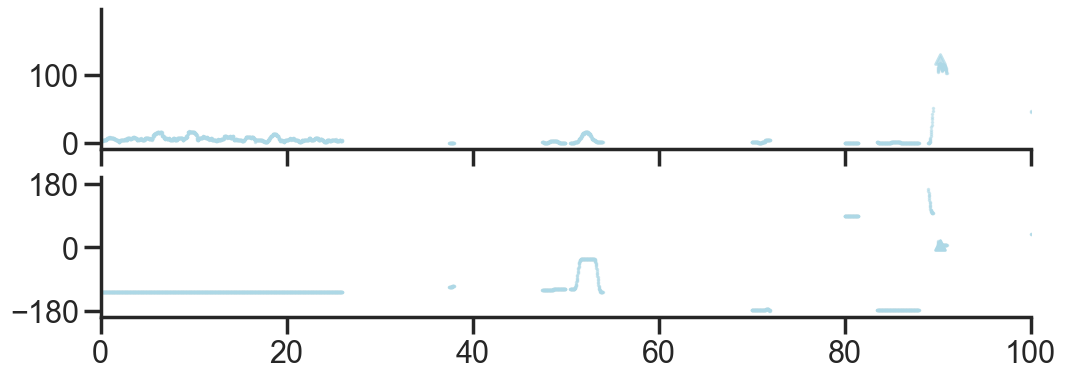

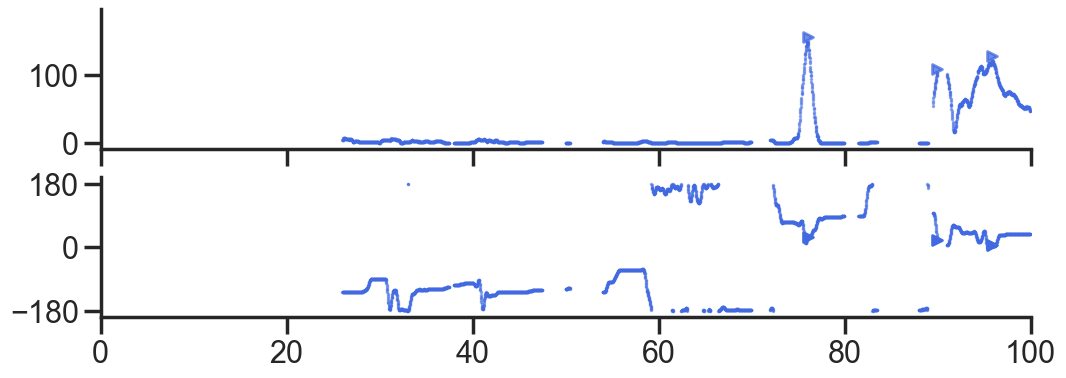

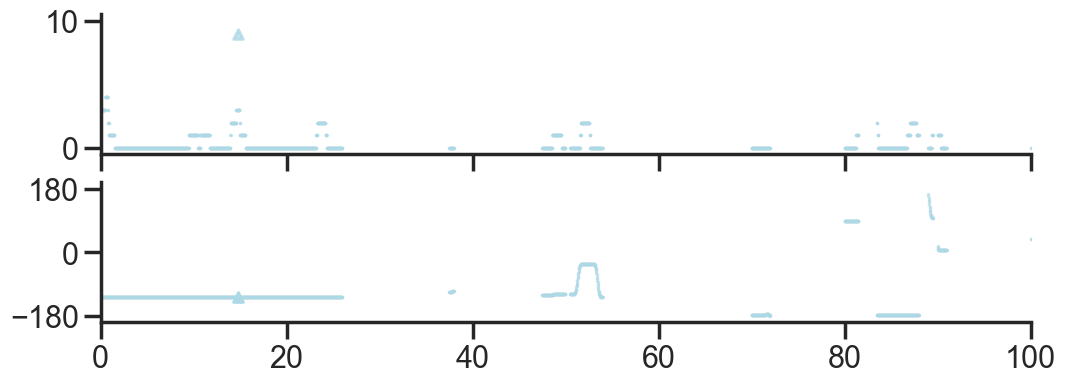

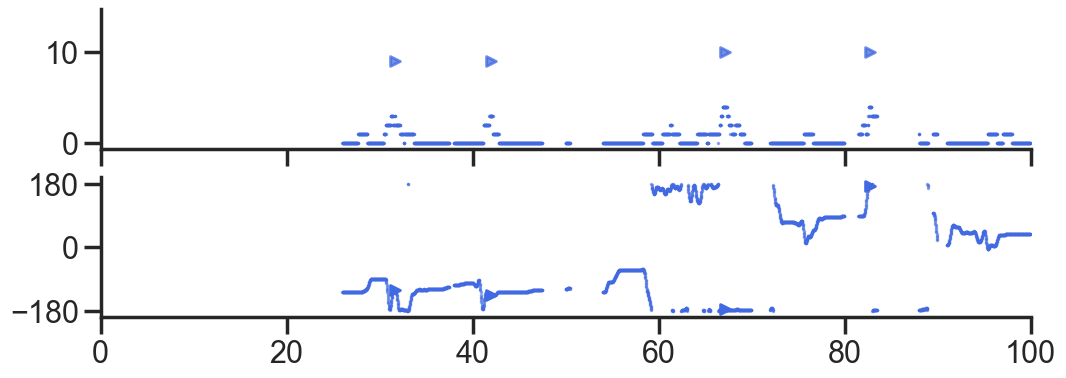

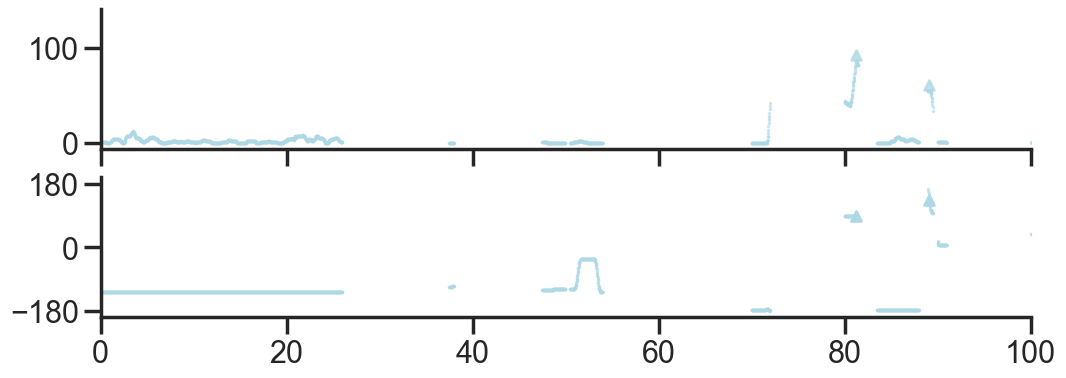

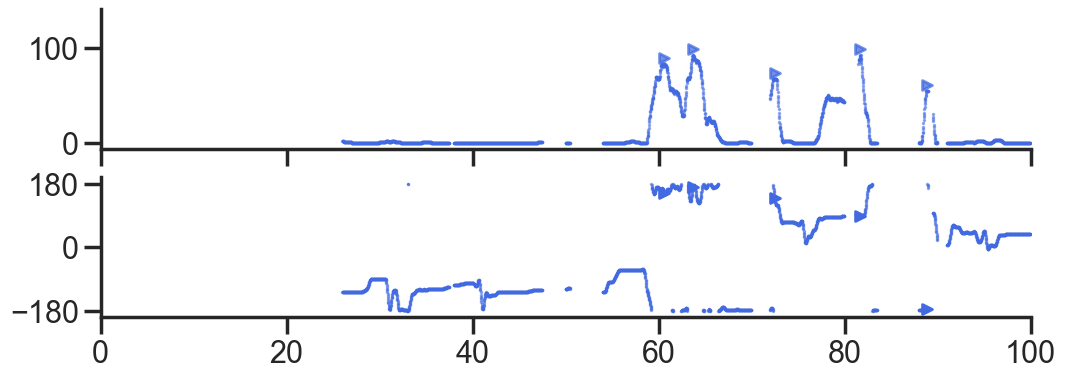

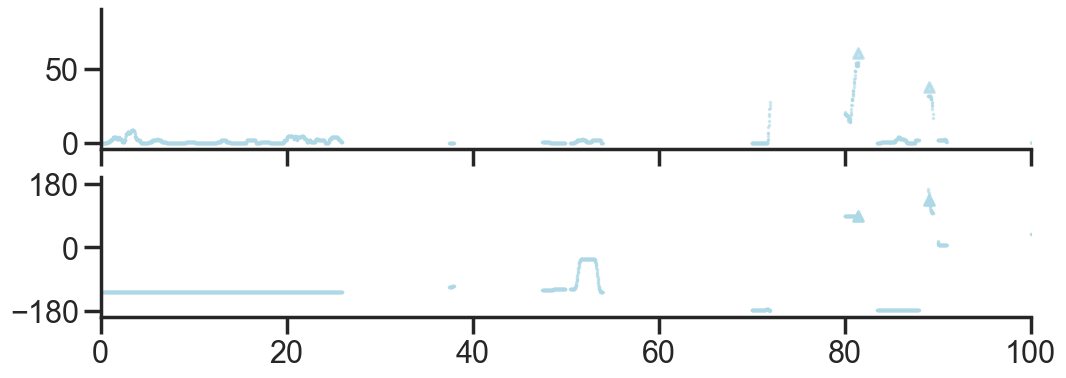

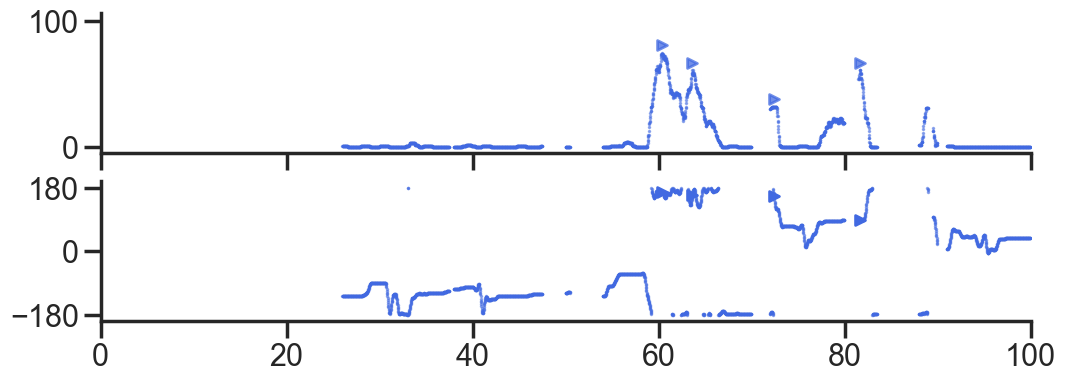

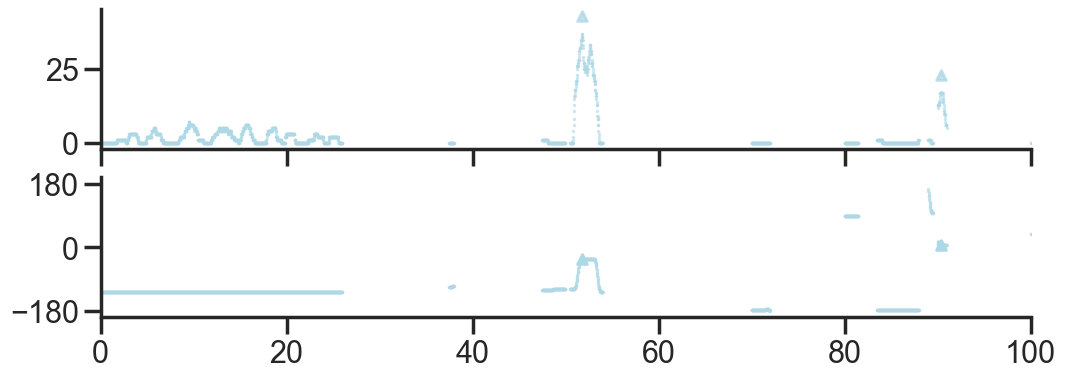

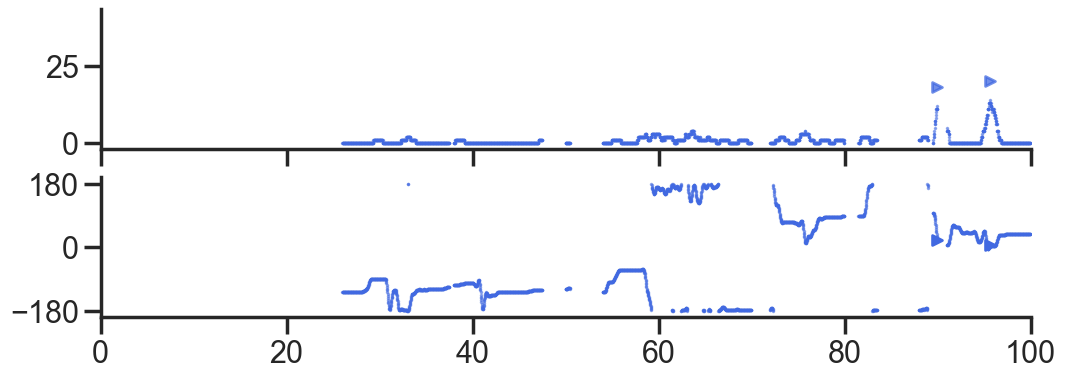

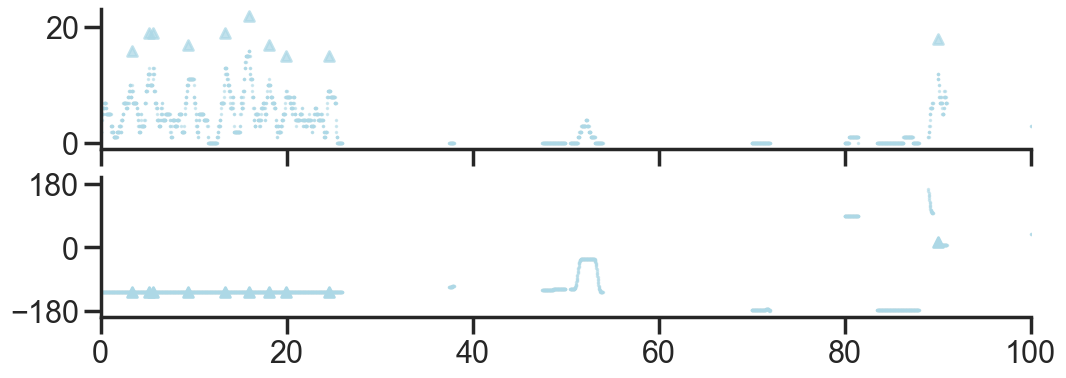

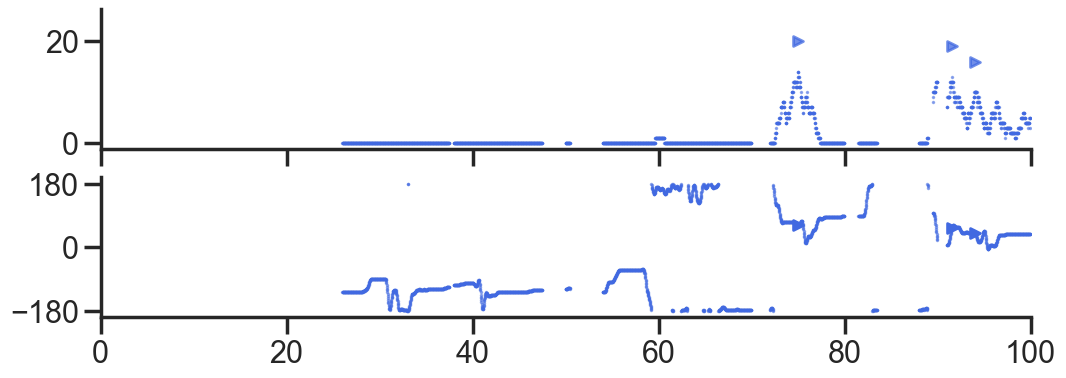

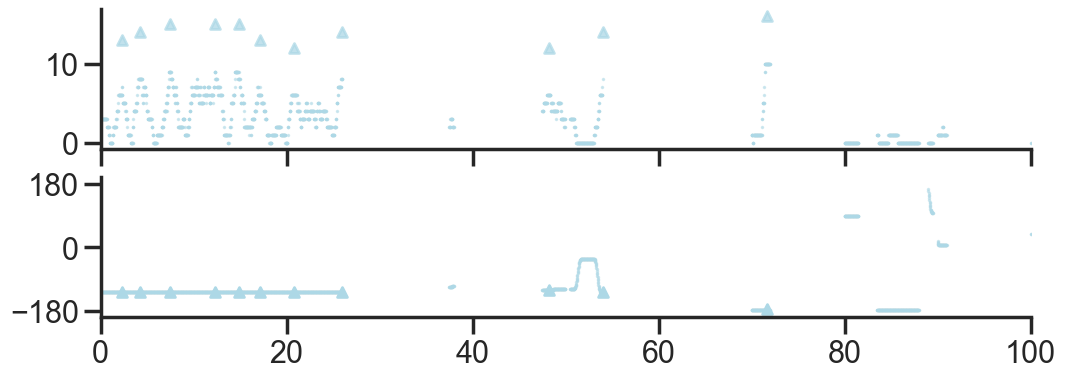

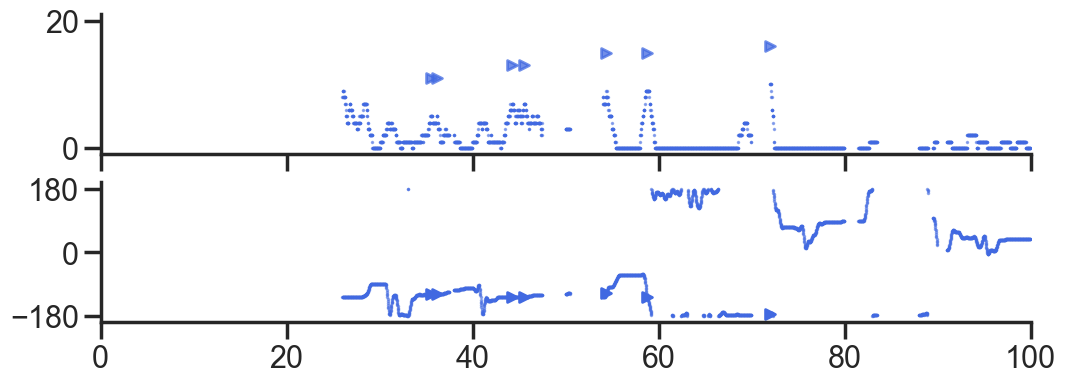

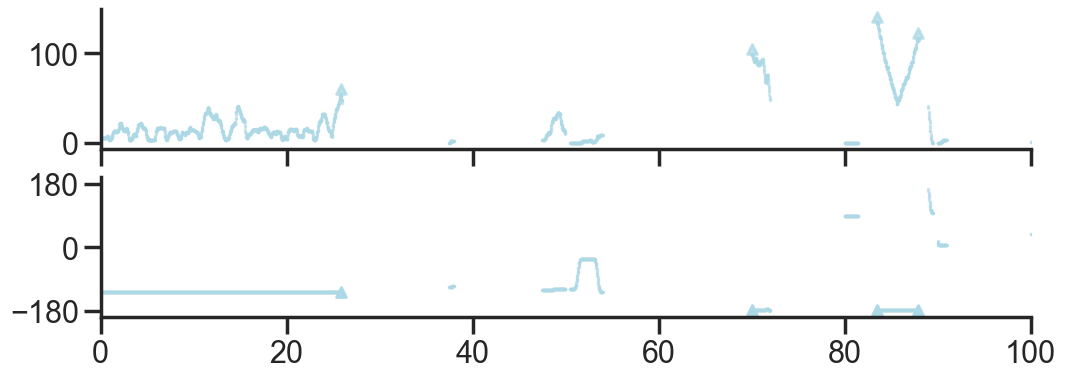

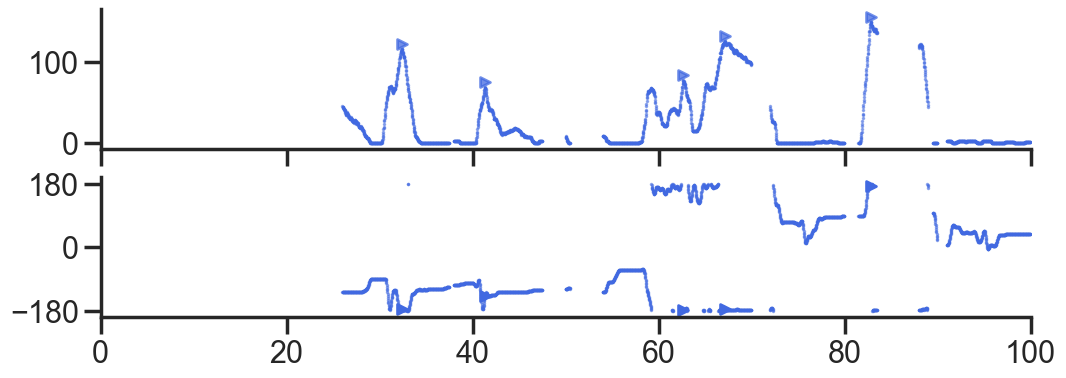

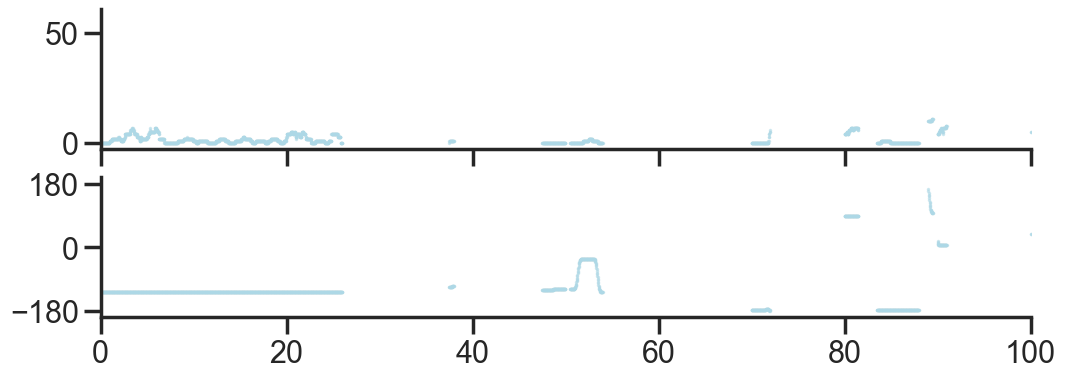

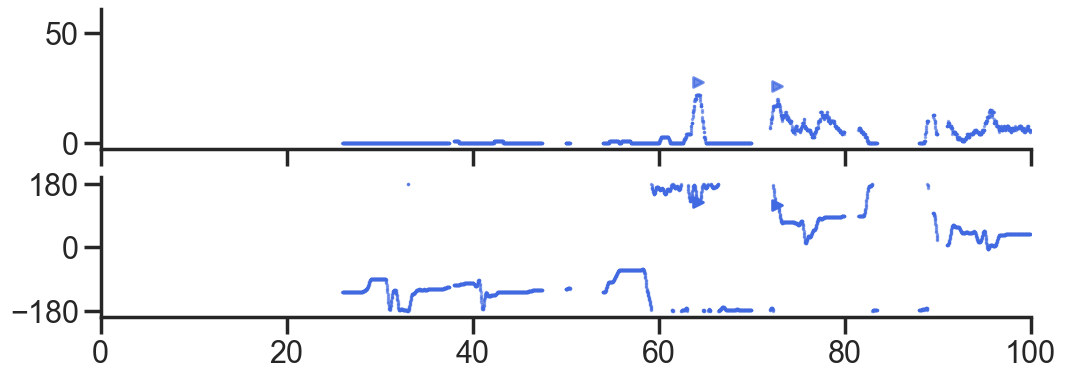

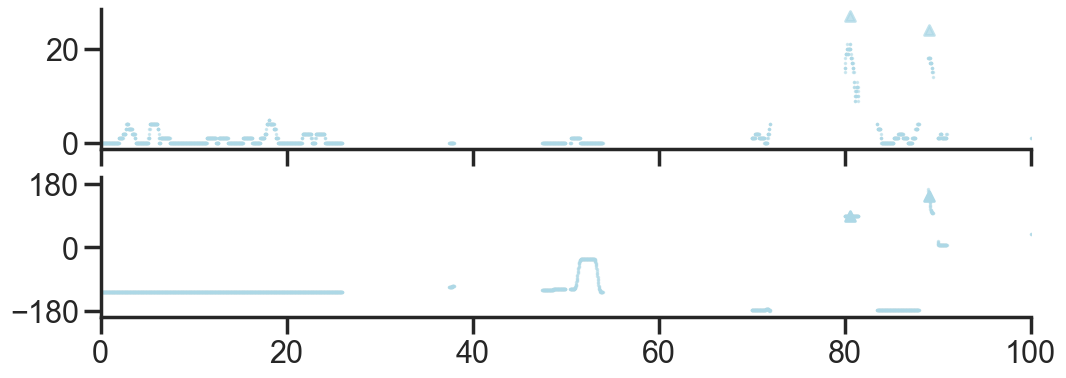

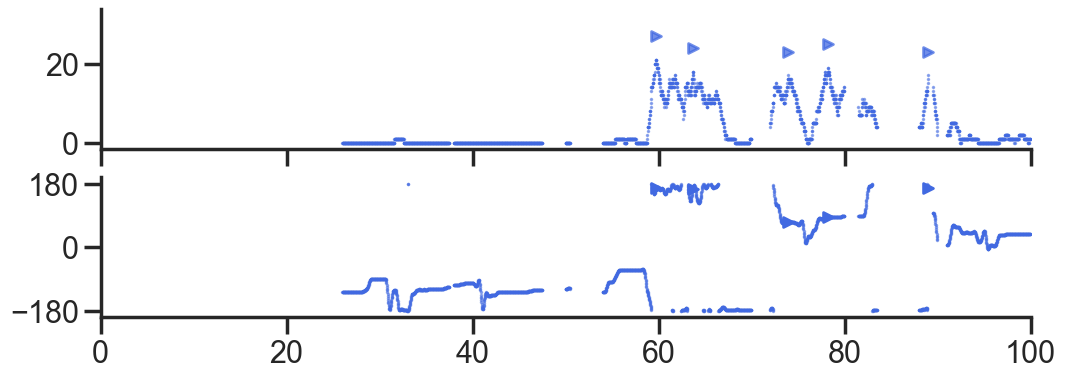

20220810_JA180_lADN_red_H2_VR1_TS7-HF
30715 24265


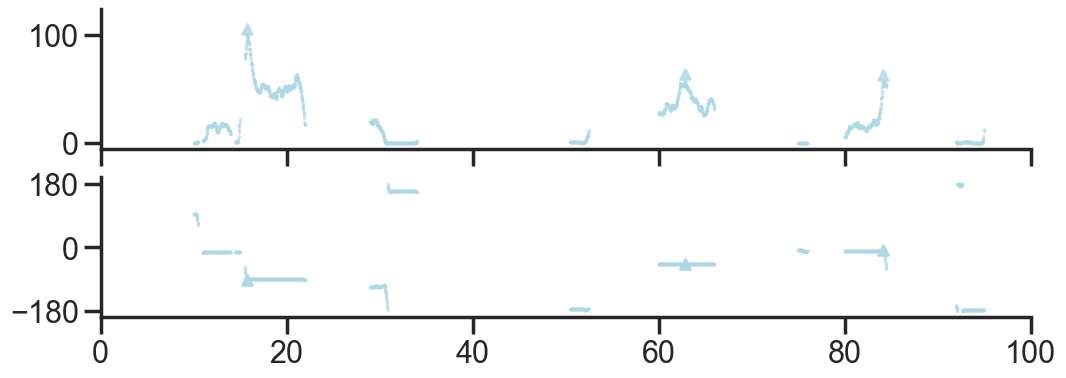

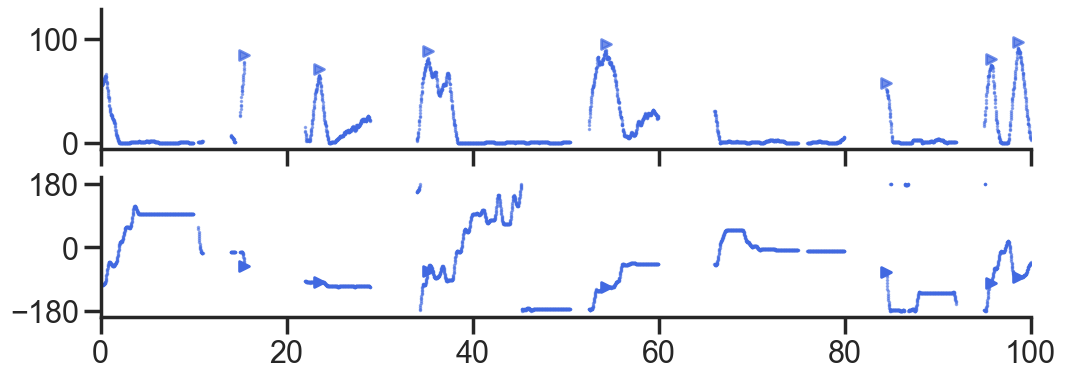

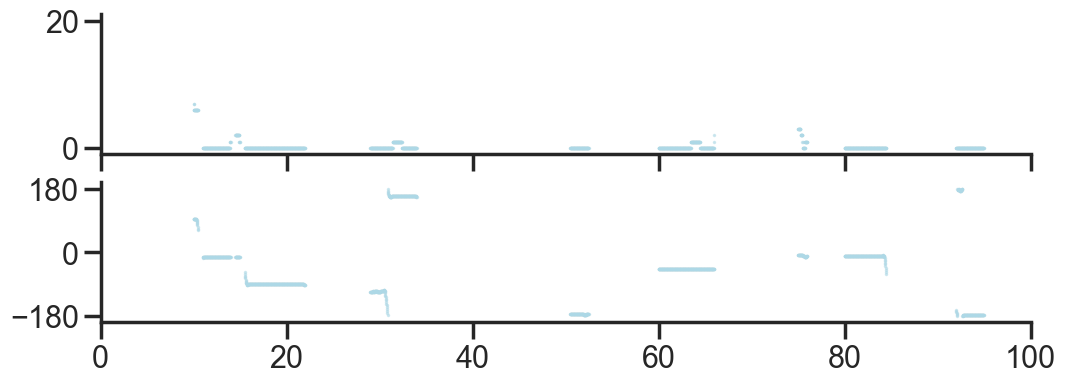

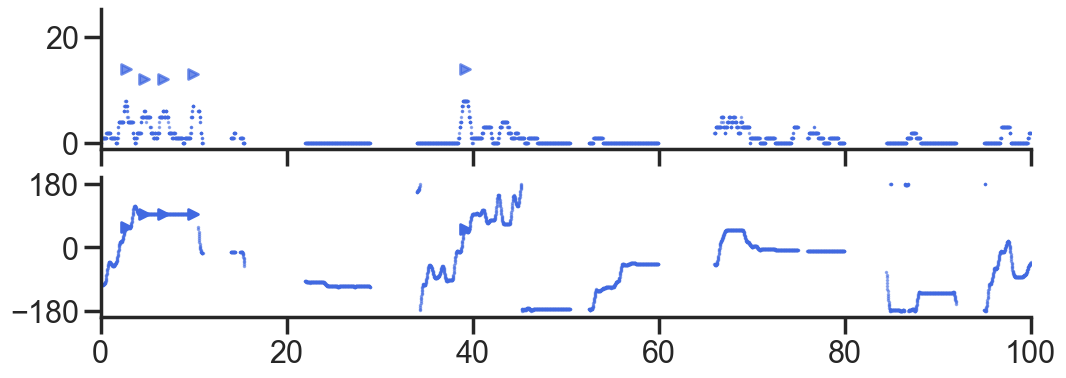

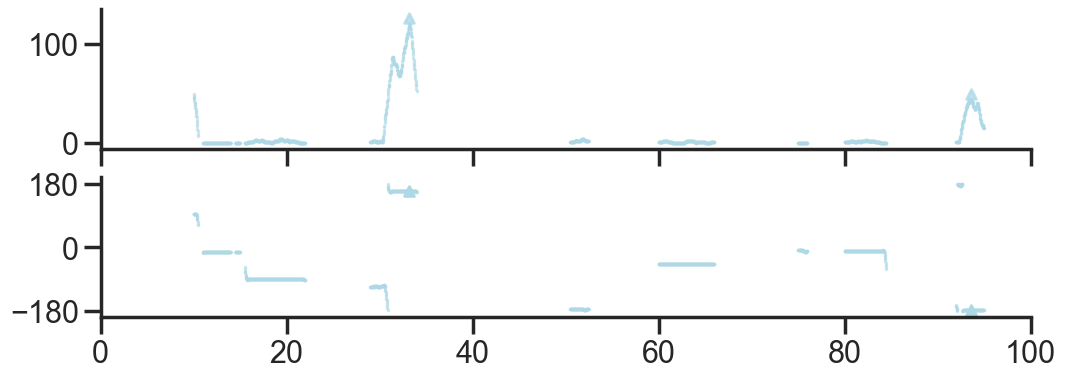

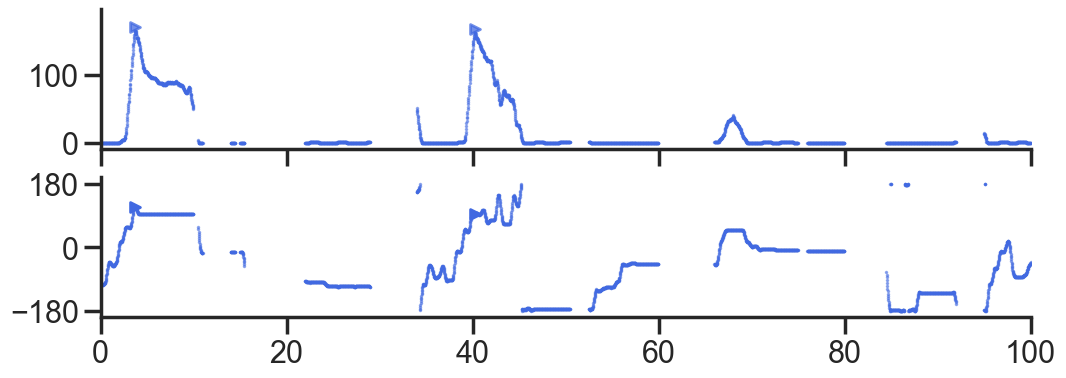

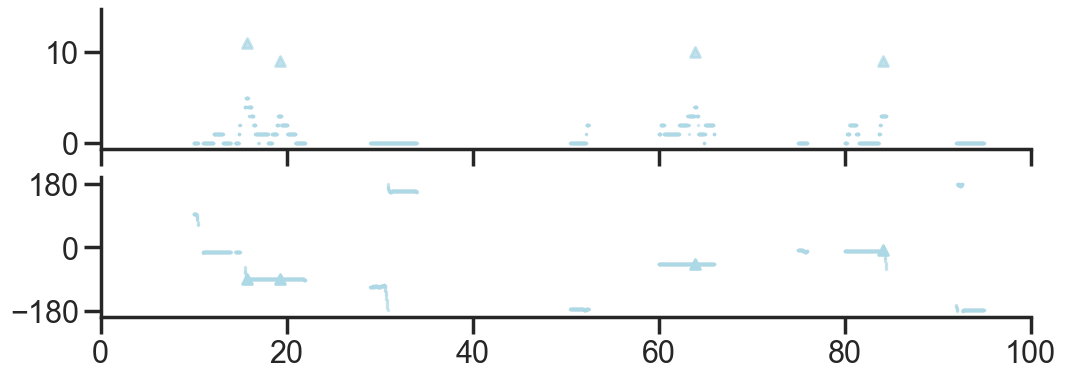

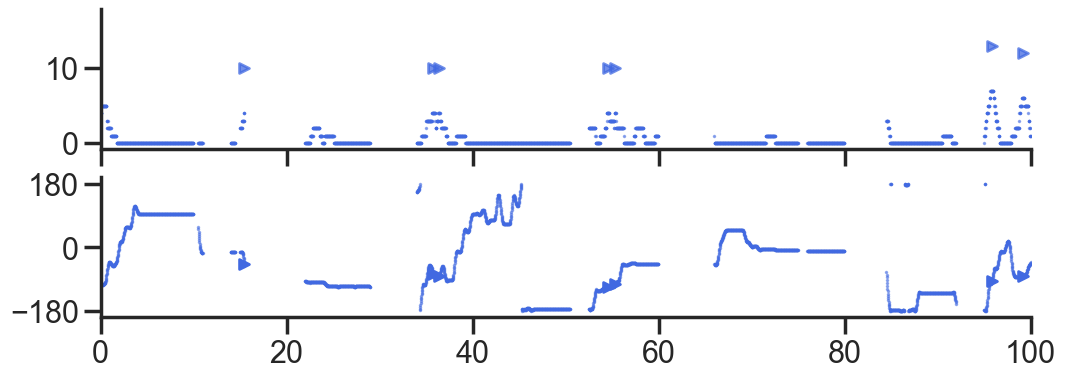

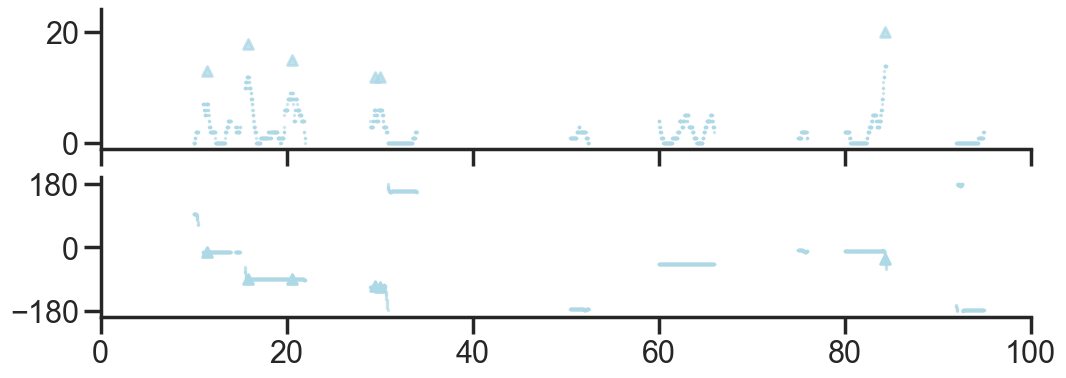

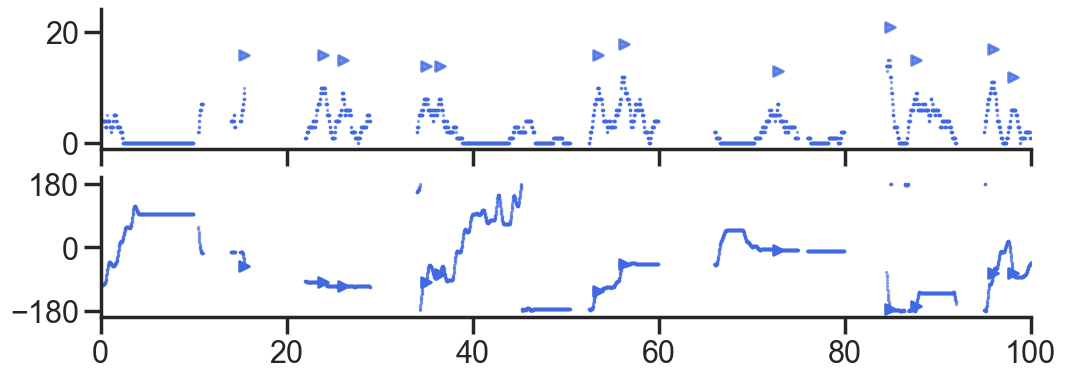

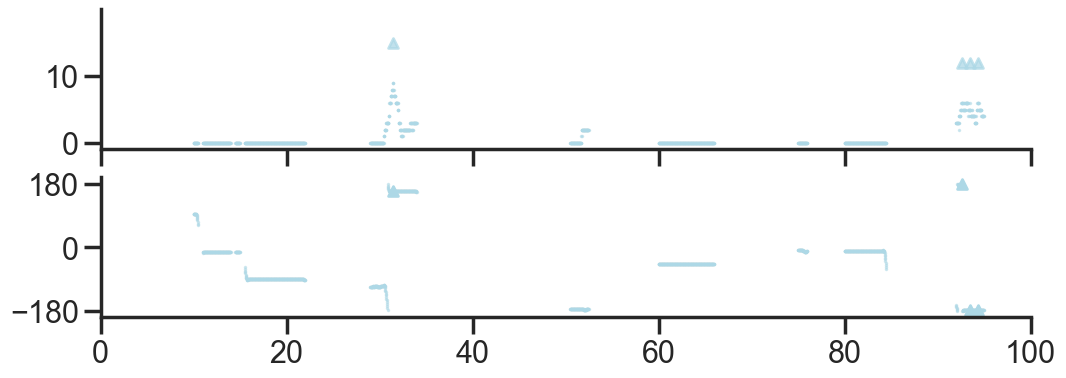

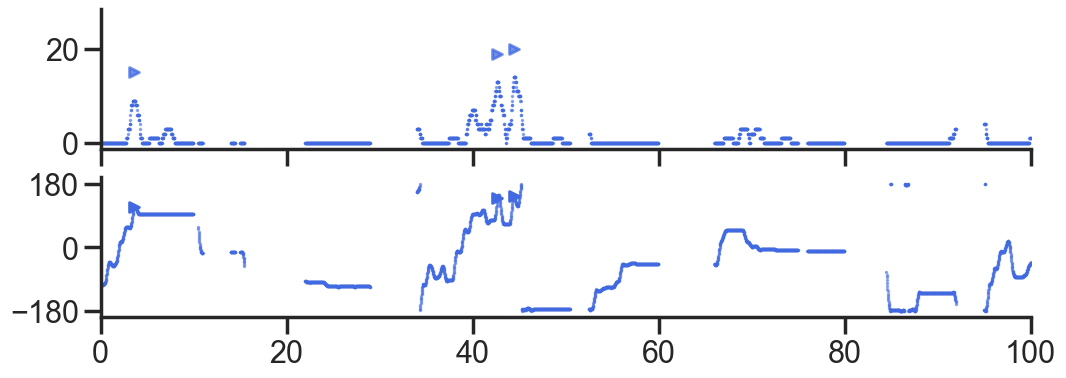

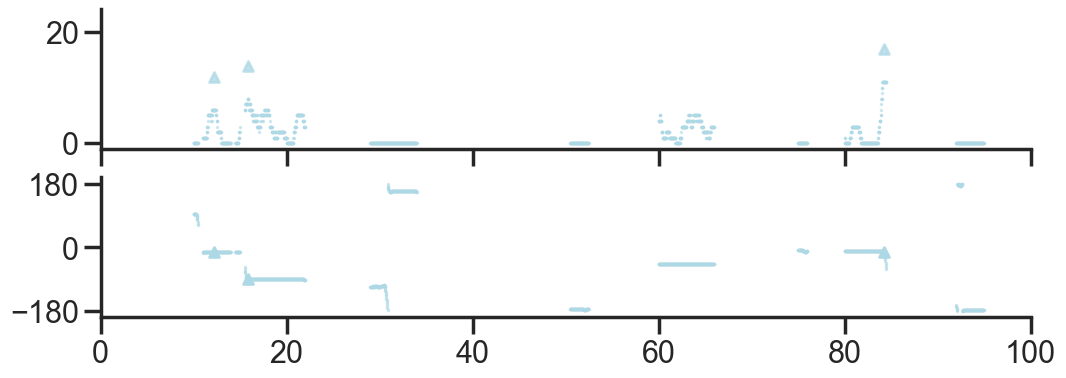

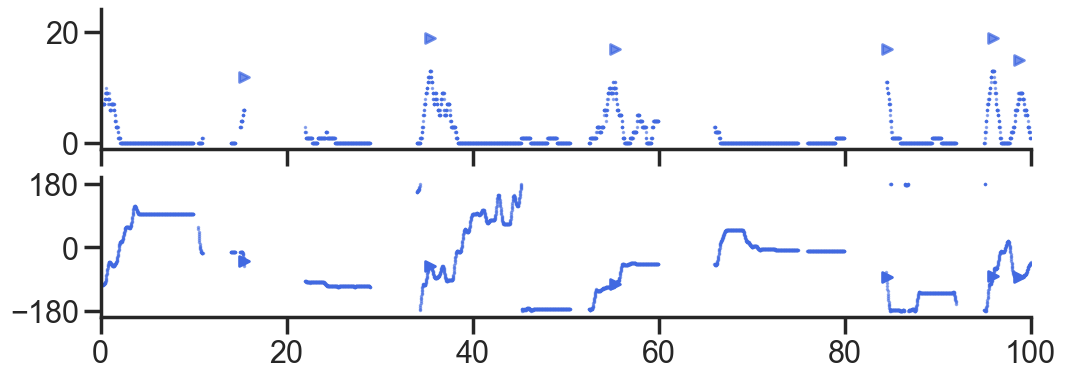

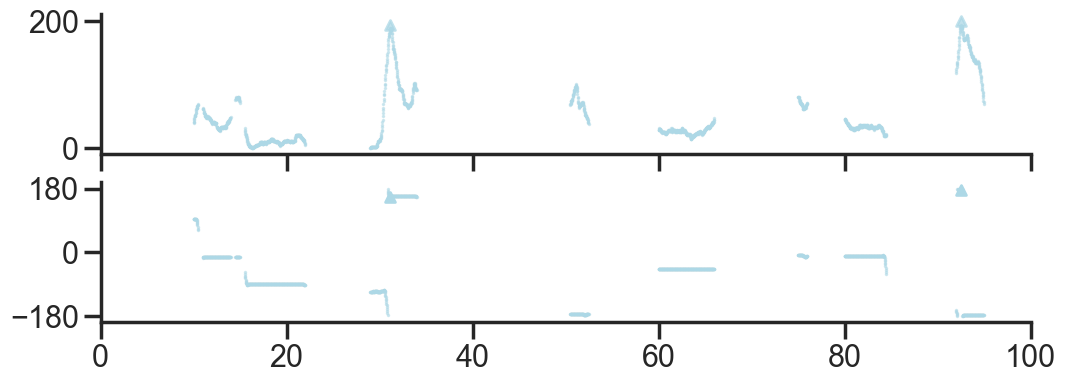

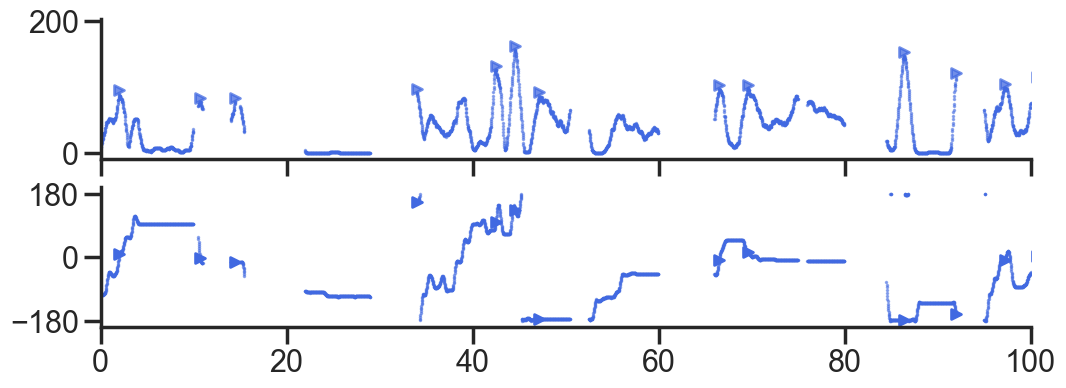

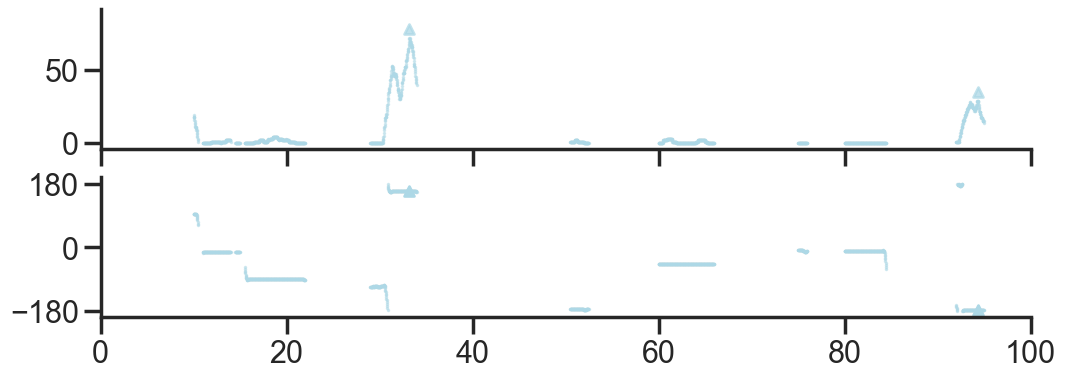

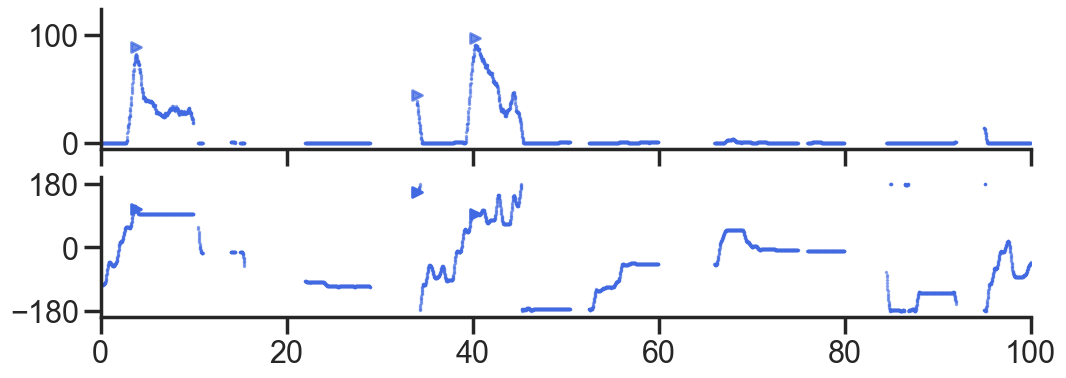

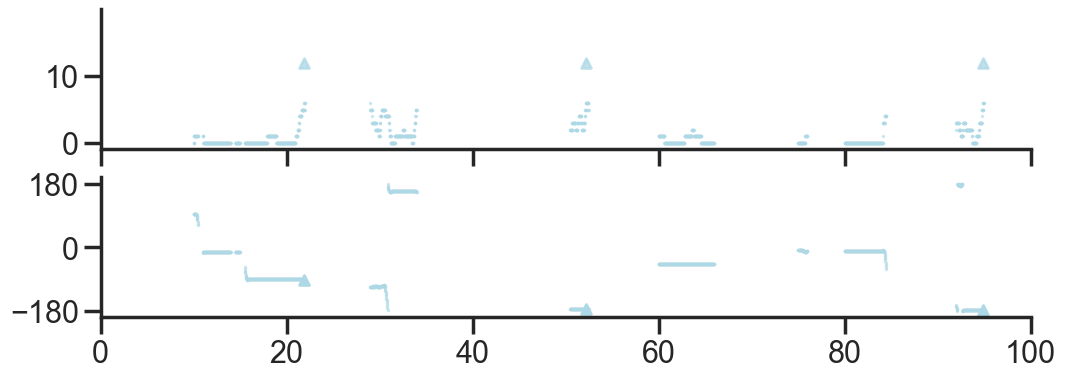

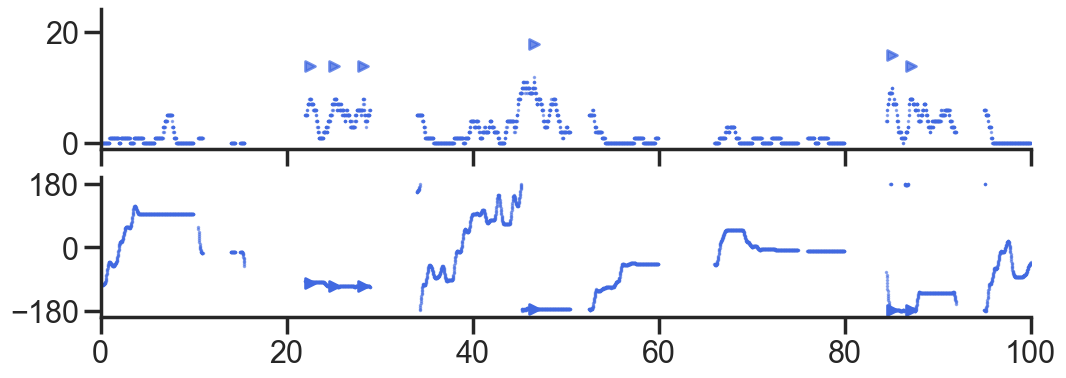

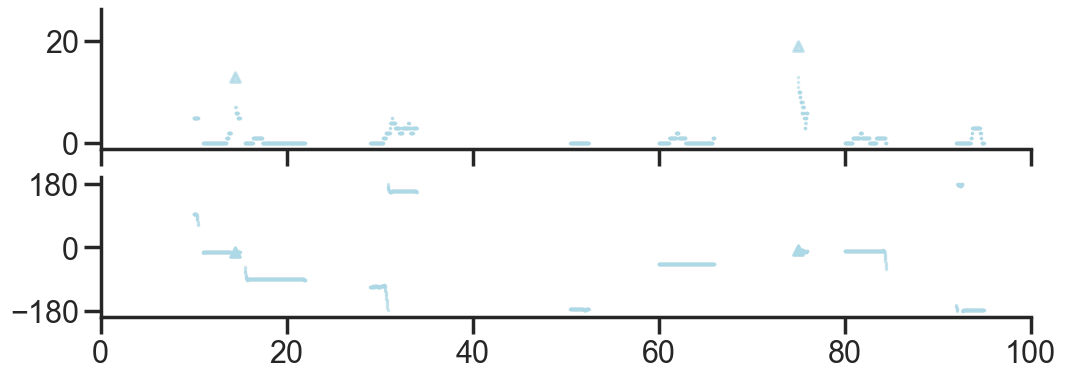

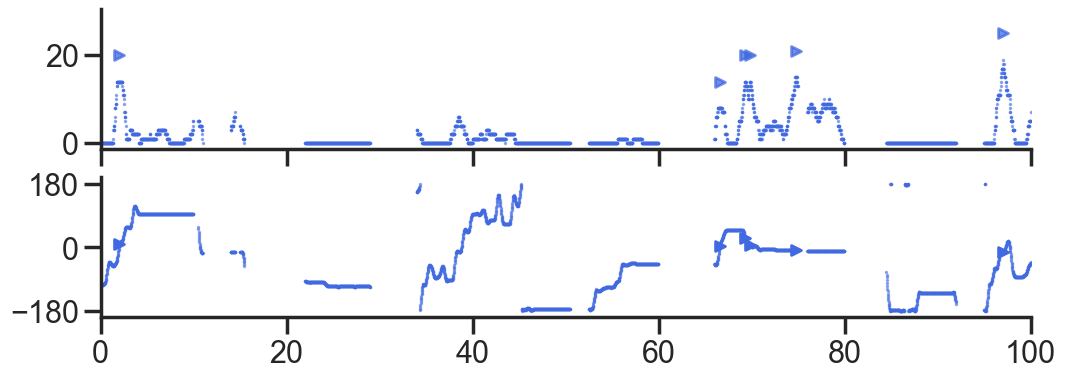

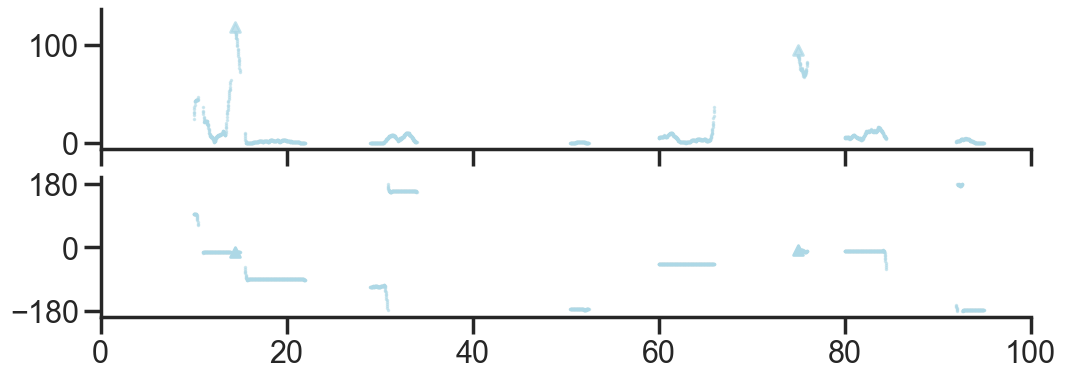

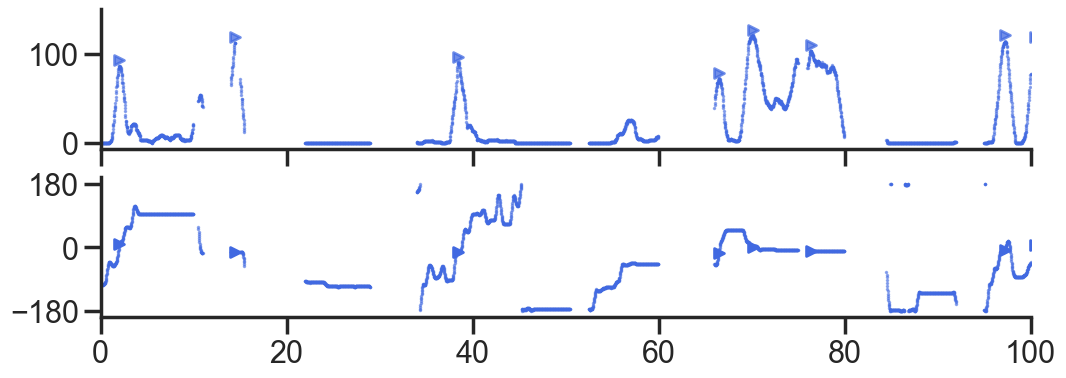

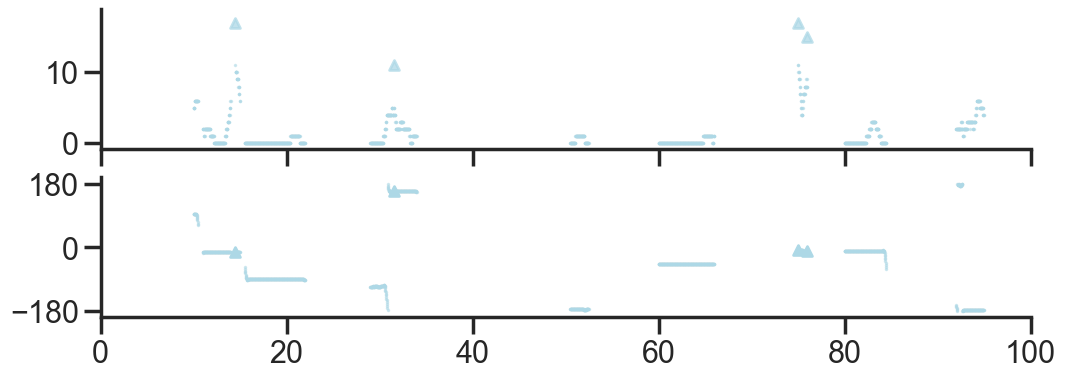

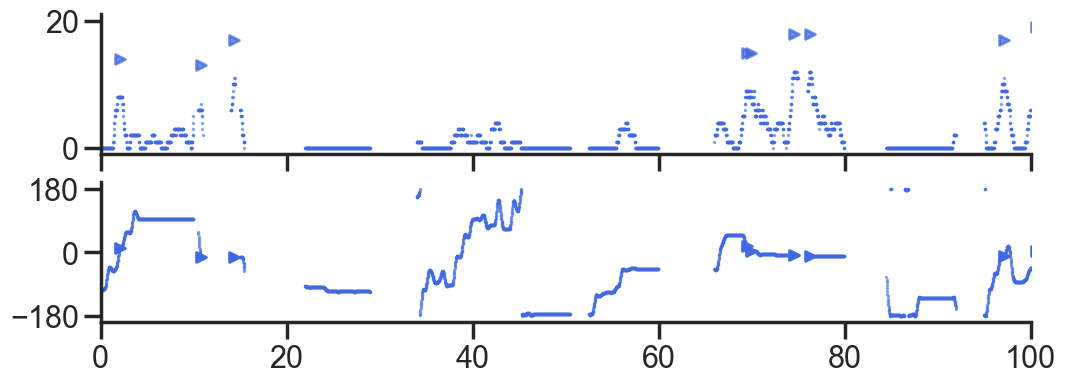

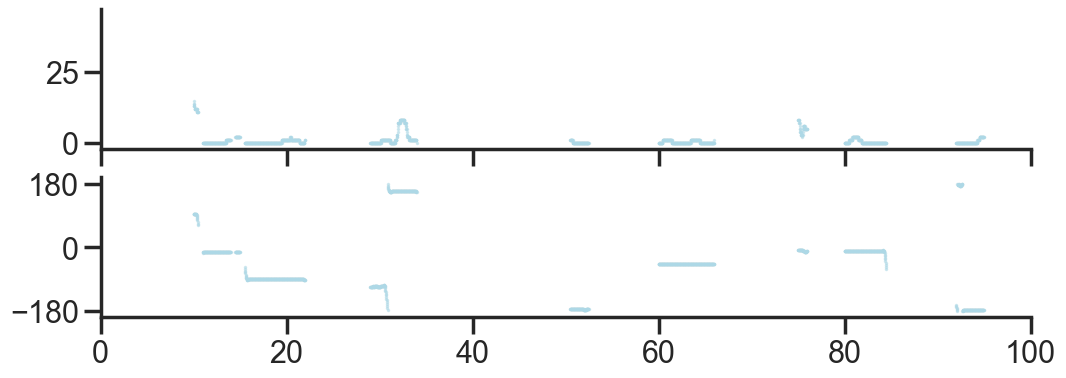

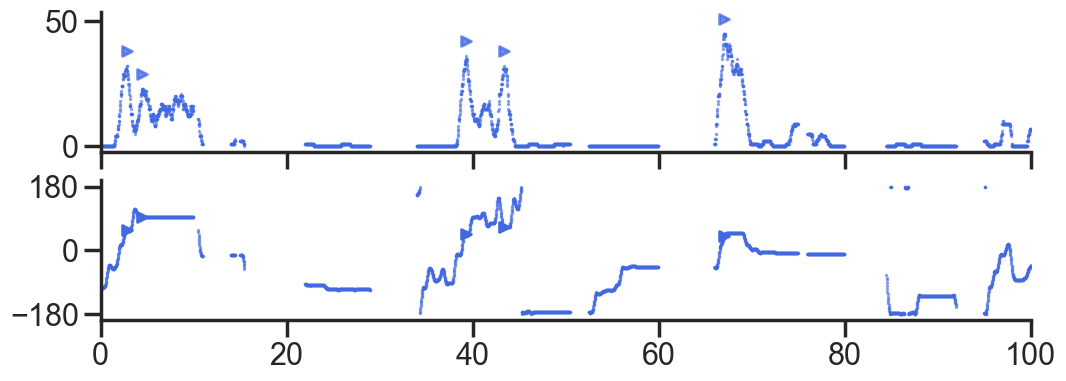

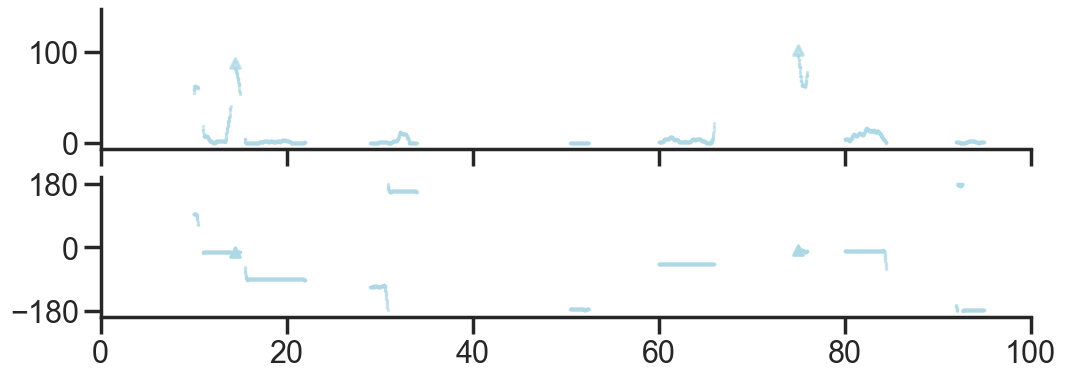

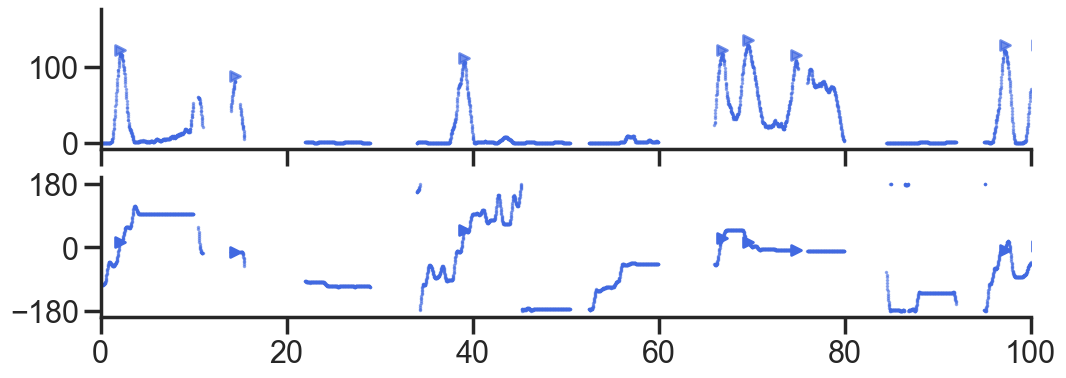

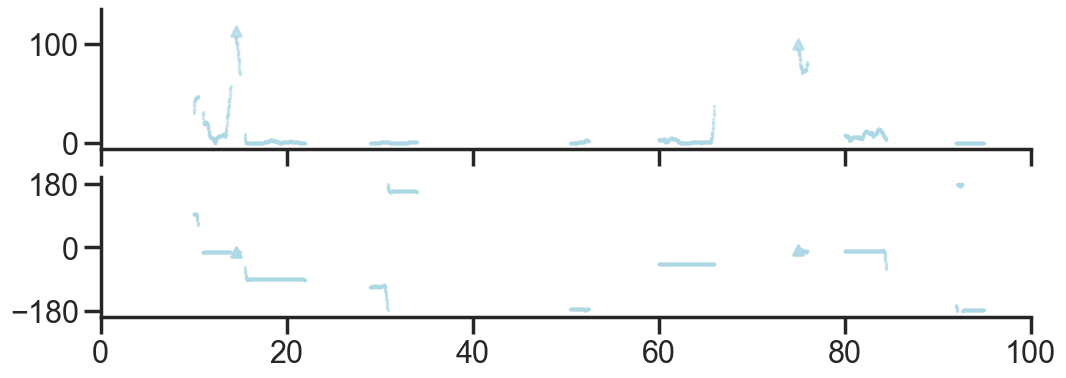

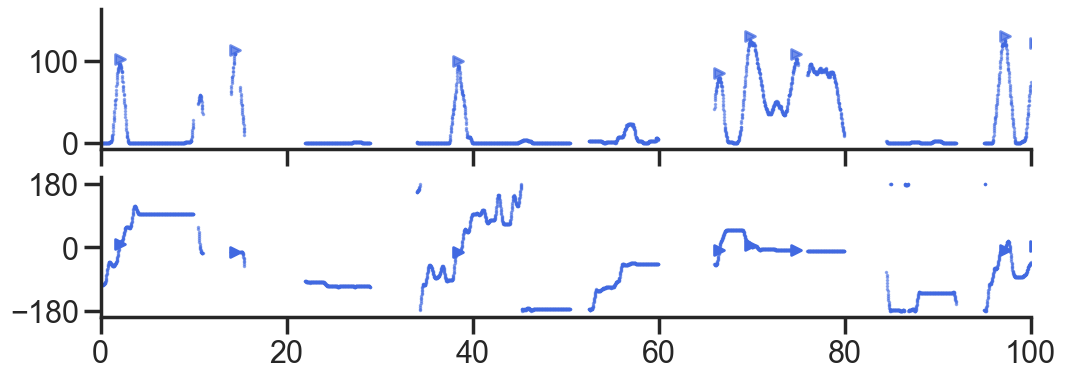

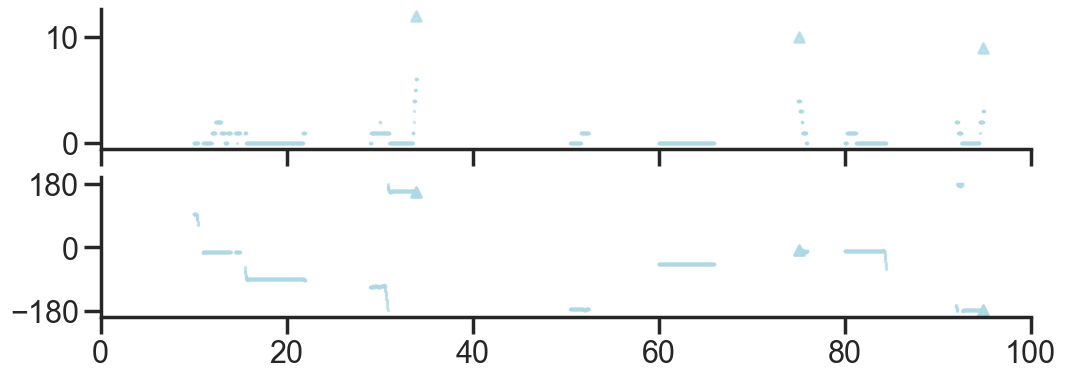

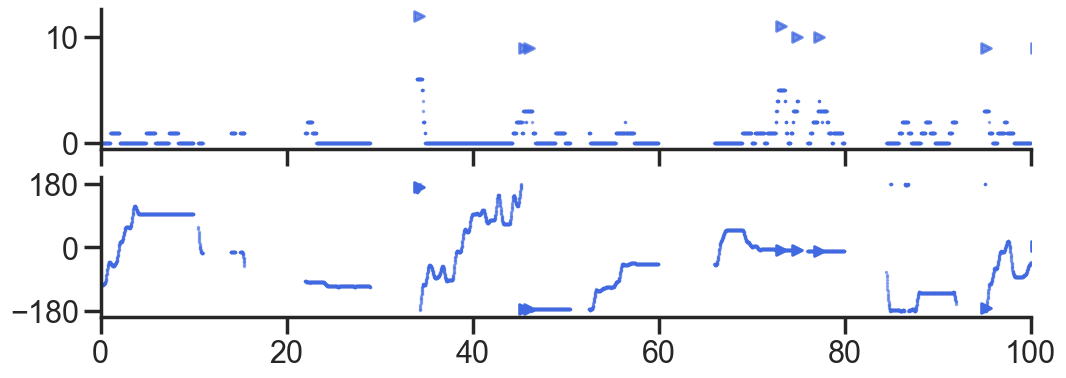

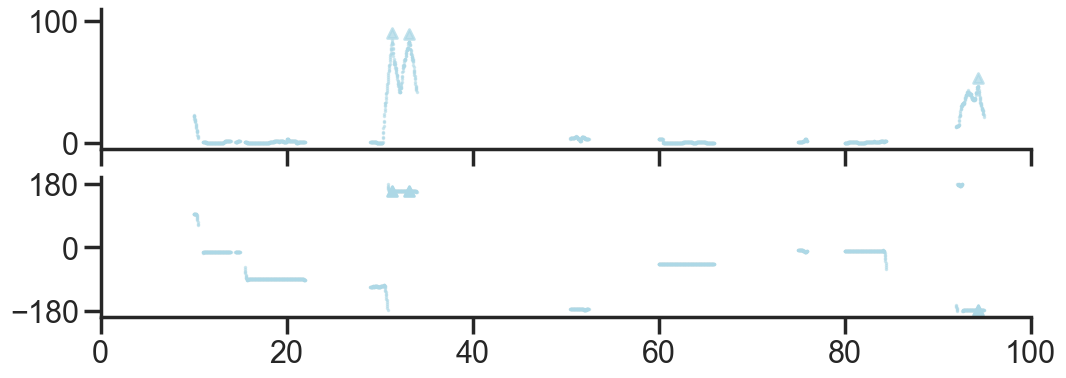

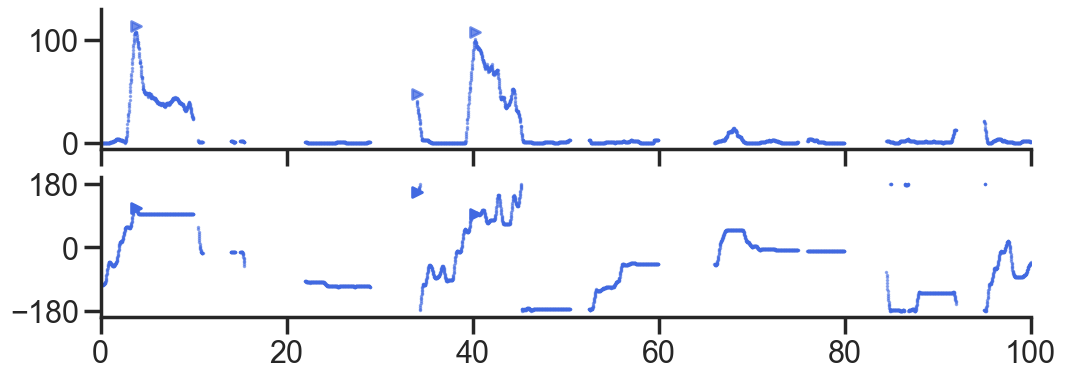

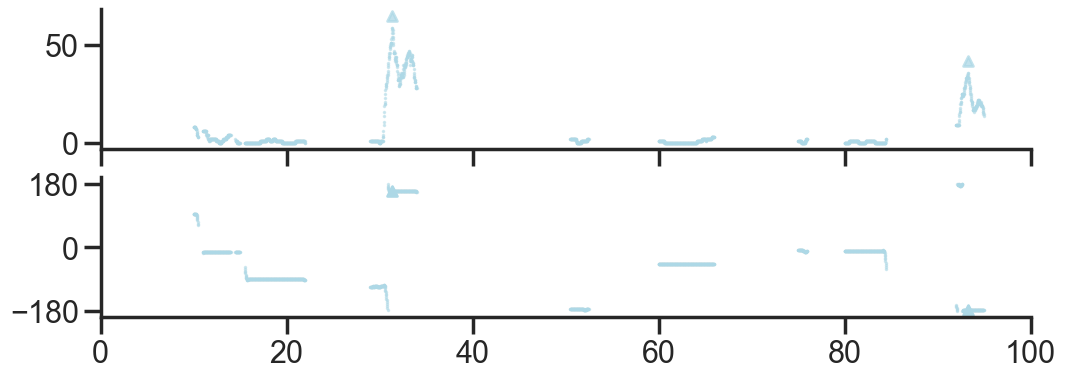

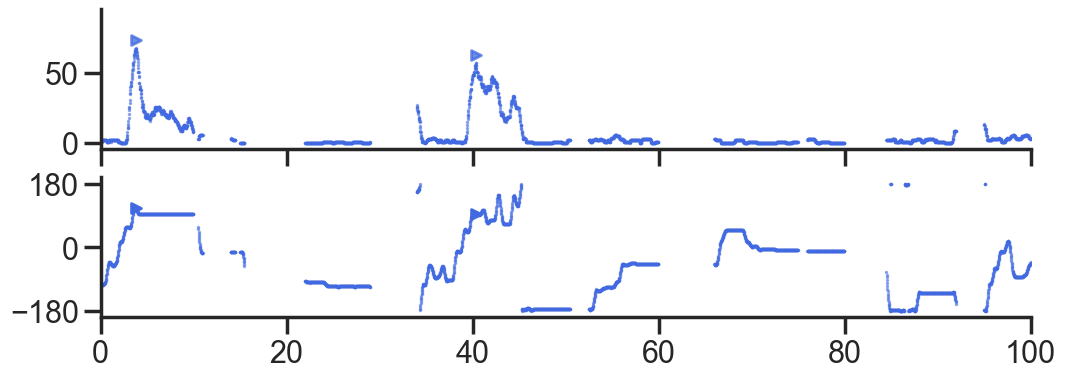

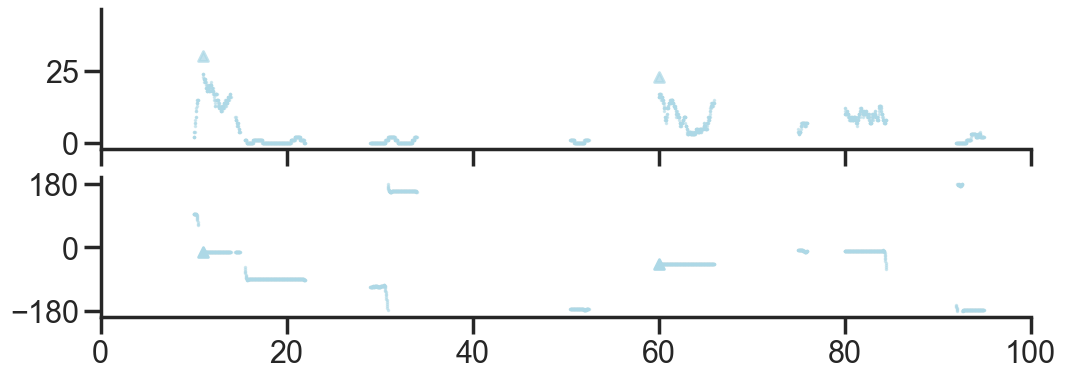

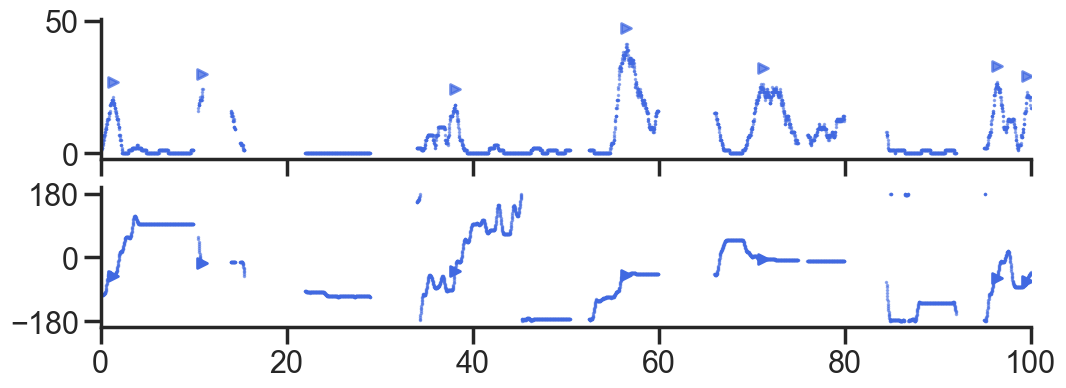

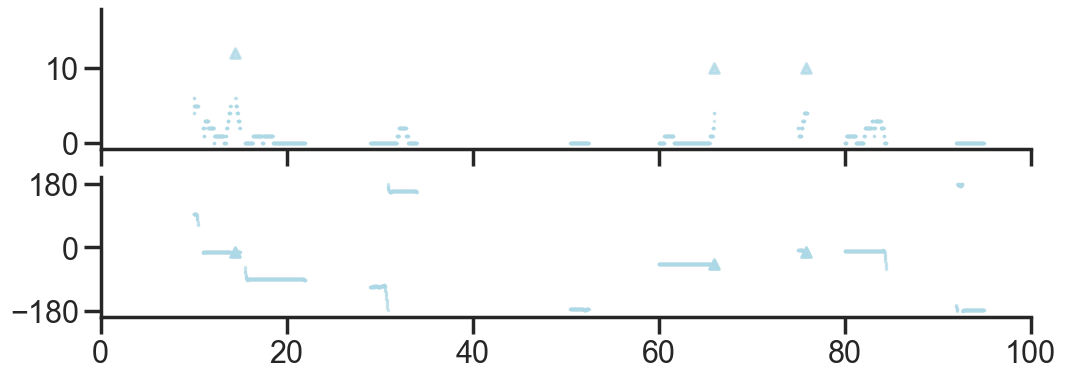

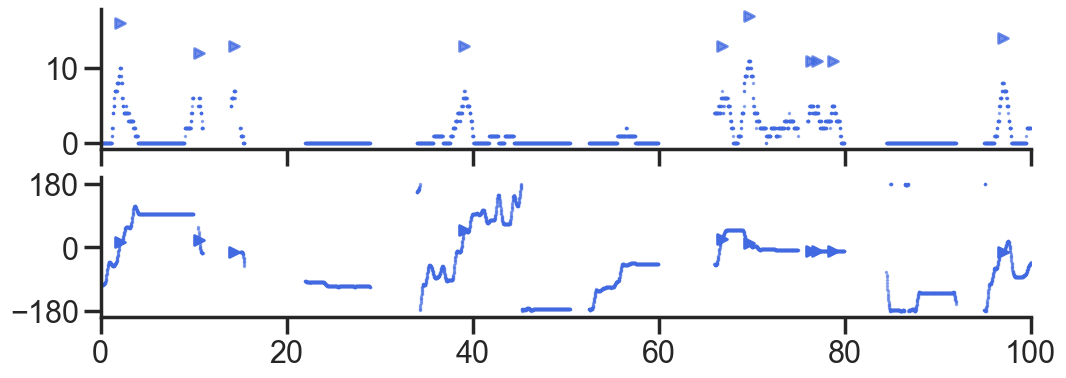

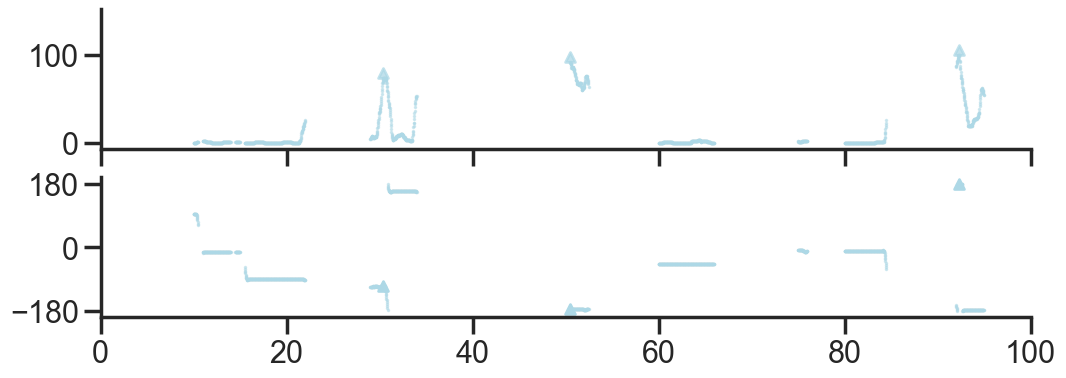

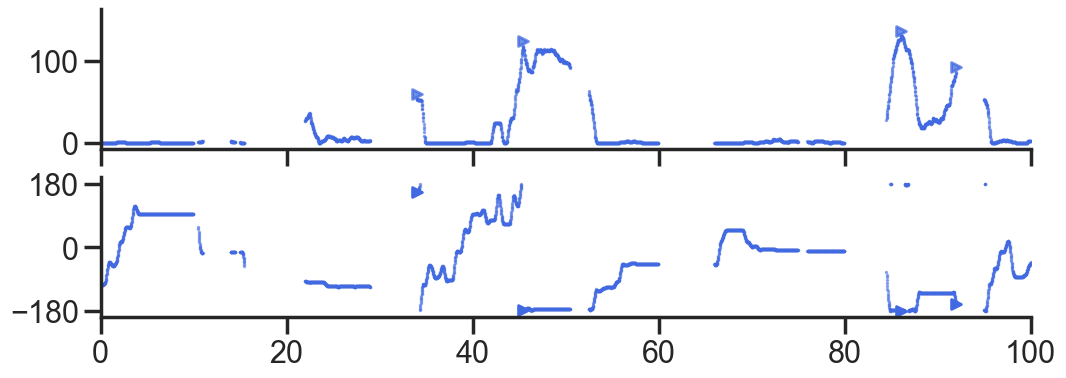

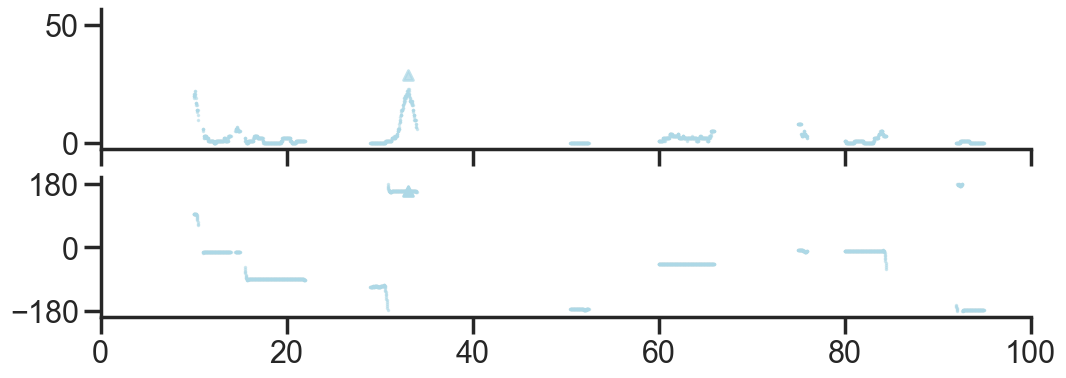

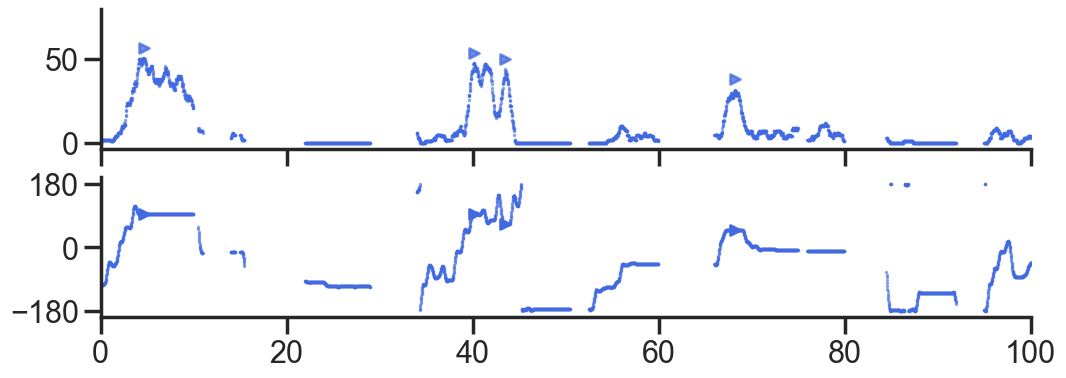

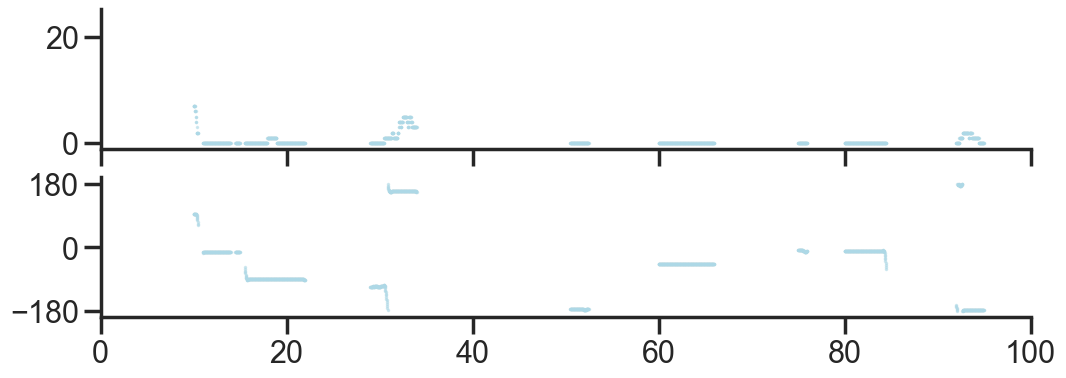

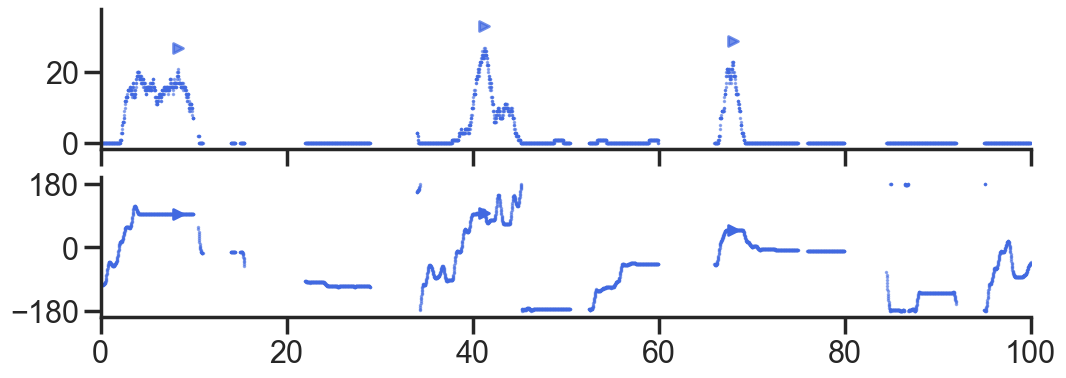

20220811_JA180_lADN_red_H2_VR1_L1
20220811_JA180_lADN_red_H2_VR1_TS6-HF
20220811_JA180_lADN_red_H2_VR1_TS7-HF
20220819_JA180_lADN_red_H2_R_L1
20220819_JA180_lADN_red_H2_VR1_TS6-HF
20220819_JA180_lADN_red_H2_VR1_TS7-HF
20220809_JA181_lADN_red_H2_VR1_L1
20220809_JA181_lADN_red_H2_VR1_TS6-HF
20220809_JA181_lADN_red_H2_VR1_TS7-HF
20220810_JA181_lADN_red_H2_VR1_L1
20220810_JA181_lADN_red_H2_VR1_TS6-HF
20220812_JA181_lADN_red_H2_VR1_L1
20220812_JA181_lADN_red_H2_VR1_TS6-HF
20220812_JA181_lADN_red_H2_VR1_TS7-HF
20220817_JA181_lADN_red_H2_R_L1
20220817_JA181_lADN_red_H2_VR1_TS6-HF
20220627_MC022_lADN_red_H2_R_L1
20220627_MC022_lADN_red_H2_VR1_TS6-HF
20220627_MC022_lADN_red_H2_VR1_TS7-HF
20220628_MC022_lADN_red_H2_R_L1
20220628_MC022_lADN_red_H2_VR1_TS6-HF
20220629_MC022_lADN_red_H2_R_L1
20220629_MC022_lADN_red_H2_VR1_TS6-HF
20220629_MC022_lADN_red_H2_VR1_TS7-HF
20220706_MC022_lADN_red_H2_VR1_TS6-HF
20220715_MC022_lADN_red_H2_VR1_L1
20220718_MC022_lADN_red_H2_VR1_L1
20220718_MC022_lADN_red_H2_V

In [1827]:
ls_df = []
ls_p_b = []
ls_hf_b = []
ls_ibi = []
to_plot = True
cond1 = 'TS6-HF'
cond2 = 'TS6-VIS'
cond_ls = [  'L1', 'TS6-HF', 'TS7-HF'
#            'TS6-MR', 'TS7-MR',
#        'TS6-OVAR10', 'TS6-OVAR20', 'TS7-VIS', 'TS6-VIS'
    ]

_inp = df_tun_proc[ (df_tun_proc.hdc > -1)
#             &(df_tun_proc.rec_unit.isin(hdc_hf_units))
            & (df_tun_proc.dir == 0)
#             & ((df_tun_proc.cond == cond1) | (df_tun_proc.cond == cond2))
            & (df_tun_proc.cond.isin(cond_ls))
            ]

for rec in _inp.rec_id.unique()[:]:
    print(rec)
    if 'JA180' not in rec or '0810' not in rec:
        continue
        
    tmp = _inp[_inp.rec_id == rec]
    dts, mouse_id, hem, hstripe, cond, rec_session = get_recinfo_fname(rec)
    if rec_session not in good_rec_shanks:
        continue
    if 'l' in hem:
        hem = 'left'
    else:
        hem = 'right'
    implant = mouse_id + '_' + hem
    
    sh = d_good_shanks[implant]
    tmp_hist = df_hist_master[(df_hist_master.mouse_id == mouse_id) 
           & (df_hist_master.dts == dts)
           & (df_hist_master.group != 'noise')
          & (df_hist_master.shank.isin(sh))]

    units_in = tmp_hist.id.unique()
    sess_hdc = tmp_hist[tmp_hist.hdc == 1].id.values
#     print(tmp.rec_id.values[0])
    tmp_ephys = d_master[rec]['ephys']   
    yaw_sm, lin_speed = get_yaw_speed_rec(rec, d_master)
    dYaw = compute_dYaw(yaw_sm)
    # convert to deg/s, 50 HZ sampling rate
    ang_vel = dYaw*50
    
    if 'MR' in rec or 'VIS' in rec or 'RPL' in rec or 'OVAR' in rec:
        stat_idx, run_idx = get_stat_run_epochs(ang_vel, window_size=25, speed_thr = 7)
    else:
        stat_idx, run_idx = get_stat_run_epochs(lin_speed, window_size=25, speed_thr = 4)
    print(stat_idx.size, run_idx.size)


    for unit in units_in:
        if unit in sess_hdc:
            hdc_flag = 'yes'
            
        else:
            hdc_flag = 'no'
            continue
        tmp_ephys2 = tmp_ephys[tmp_ephys.cids == unit]
        # check if empty
        if tmp_ephys2.size < 100:
            continue
        x = tmp_ephys2.times[stat_idx].values
        y = tmp_ephys2.hz[stat_idx].values
        global_thres = tmp_ephys2.hz.mean()
        global_max = tmp_ephys2.hz.max()
        # at least 20s running
        if y.size < 1000:
            continue
        y_cp = y.copy()
        y_cp_mean = y_cp.mean()
        # threshold for bursting
        thresh = y_cp.max()/3
        peaks, mean_b, b_std = burst_amp_std(y_cp, yaw_sm[stat_idx], thresh)
        if peaks.size < 10:
            continue
        # ibi
        ibi = np.diff(peaks)
        ibi =  medfilt(ibi, kernel_size = 3)
        ls_ibi.append(ibi)
        
        tmp_df = pd.DataFrame({'cids': unit, 'burst': mean_b,  'cond': cond, 'rec_id':rec, 
                               'mean_fr': y_cp_mean, 'rec_session':rec_session, 'n_peaks': peaks.size,
                               'hdc': hdc_flag, 'mouse_id':mouse_id, 'b_circstd': b_std, 'run': 'stat',
                              }, index = [0])
        ls_df.append(tmp_df)
        
        if to_plot == True:
            f, ax = plt.subplots( 2, sharex = True, figsize = (12, 4))
#             f, ax = plt.subplots( 1, 2, sharex = True, figsize = (8, 6), subplot_kw={'projection': 'polar'})
            ax[0].scatter(x[peaks], y[peaks] + 6, alpha = 0.75, s = 50, marker = '^', color = 'lightblue')
            ax[0].plot(x, y, '.', markersize = 3, c = 'lightblue', alpha = 0.5)
            ax[0].set_xlim(0, 100)
            ax[1].plot(x[:yaw_sm[stat_idx].size], yaw_sm[stat_idx] - 180, '.', markersize = 3, c = 'lightblue', alpha = 0.5, zorder = -1)
            ax[1].scatter(x[peaks], yaw_sm[stat_idx][peaks] - 180 , alpha = 1, s = 50, marker = '^', color = 'lightblue')
            ax[1].set_yticks([-180, 0, 180])
            
#             r = y_cp[peaks]
#             theta = np.deg2rad(yaw_sm[stat_idx][peaks])
#             r_mean = round(np.mean(r), 1)
#             theta_deg = round(np.rad2deg(b_std), 1)
#             ax[0].plot(theta, r, '^', c = 'orange', label = f'{r_mean}, {theta_deg} deg')
#             ax[0].set_rmax(global_max)
#             ax[0].legend(loc='best', bbox_to_anchor=(0.5, 0.75, 0.5, 0.5))
#             if 'L1' in cond or 'D1' in cond:
#                 ax[0].set_theta_direction(-1)
            # ax.set_rmax(2)
            # ax.set_rticks([0.5, 1, 1.5, 2])  # Less radial ticks
            # ax.set_rlabel_position(-22.5)  # Move radial labels away from plotted line
        
        x = tmp_ephys2.times[run_idx].values
        y = tmp_ephys2.hz[run_idx].values
        
        # at least 20s running
        if y.size < 1000:
            continue
        y_cp = y.copy()
        y_cp_mean = y_cp.mean()
        thresh = y_cp.max()/3
        # threshold for bursting
        peaks, mean_b, b_std = burst_amp_std(y_cp, yaw_sm[run_idx], thresh)
        # ibi
        ibi = np.diff(peaks)
        ibi =  medfilt(ibi, kernel_size = 3)
        ls_ibi.append(ibi)
        
        tmp_df = pd.DataFrame({'cids': unit, 'burst': mean_b,  'cond': cond, 'rec_id':rec, 
                               'mean_fr': y_cp_mean, 'rec_session':rec_session, 'n_peaks': peaks.size,
                               'hdc': hdc_flag, 'mouse_id':mouse_id, 'b_circstd': b_std, 'run': 'locom',
                              }, index = [0])
        ls_df.append(tmp_df)
        
        if to_plot == True:
            f, ax = plt.subplots( 2, sharex = True, figsize = (12, 4))
            ax[0].scatter(x[peaks], y[peaks] + 6, alpha = 0.75, s = 50, marker = '>', color = 'royalblue')
            ax[0].plot(x, y, '.', markersize = 3, c = 'royalblue', alpha = 0.5)
            ax[0].set_xlim(0, 100)
            ax[1].plot(x[:yaw_sm[run_idx].size], yaw_sm[run_idx] - 180, '.', markersize = 3, c = 'royalblue', alpha = 0.5, zorder = -1)
            ax[1].scatter(x[peaks], yaw_sm[run_idx][peaks] - 180, alpha = 1, s = 50, marker = '>', color = 'royalblue')
            ax[1].set_yticks([-180, 0, 180])

#             r = y_cp[peaks]
#             theta = np.deg2rad(yaw_sm[run_idx][peaks])
#             r_mean = round(np.mean(r), 1)
#             theta_deg = round(np.rad2deg(b_std), 1)
#             ax[1].plot(theta, r, '>', c = 'darkorange', label = f'{r_mean}, {theta_deg} deg')
#             ax[1].set_rmax(global_max)
#             ax[1].legend(loc='best', bbox_to_anchor=(0.6, 0.75, 0.5, 0.5))
#             if 'L1' in cond or 'D1' in cond:
#                 ax[1].set_theta_direction(-1)
#             ax[1].set_xticklabels([])
#             plt.savefig(f'polar_{rec_session}_{cond}_{unit}.pdf', transparent = True)
            plt.show()
            
    
    
# df_bur = pd.concat(ls_df)
# df_bur['head_fix'] = df_bur['cond'].apply(lambda x: x[-2:])
# df_bur['b_circstd_deg'] = np.rad2deg(df_bur['b_circstd'])
# df_bur.head()

In [1646]:
units_in

array([  0,   1,   2,   4,   5,   6,   7,   8,  10,  11,  13,  14,  16,
        17,  44,  89,  90,  91,  92,  93,  94,  95, 118,  18,  19,  20,
        21,  22,  24,  25,  26,  27,  29,  31,  32,  33,  34,  35,  36,
        37,  38,  39,  40,  43,  96,  97, 100, 101, 102, 120, 126, 127],
      dtype=int64)

In [1647]:
sess_hdc

array([ 11,  13,  14,  16,  17,  44,  95, 118,  21,  24,  25,  26,  27,
        29,  31,  32,  34,  35,  37,  39,  40,  97, 100, 101, 126, 127],
      dtype=int64)

In [122]:
ls = []
path = r"C:\Users\lab\Desktop\animation"
data = df_emb
for rec in data.rec_id.unique()[:1]:

    tmp_unity = d_data['20211212_JA144_ADN_red_H1_VR1_TS6-HF']['unity']
    
    xpos = tmp_unity.PosX.values[::5]
    ypos = tmp_unity.PosZ.values[::5]
    
    f, ax = plt.subplots(1, 2, figsize = (12, 5))
#     camera = Camera(f)
    print(rec)
#     path2save = os.path.join(path, rec)
#     if os.path.exists(path2save):
#         continue
#     os.mkdir(path2save)
    tmp = data[(data.rec_id == rec) 
#                & (data.condition == con)
#                & (data.running == rn)
              ]
    time_s = np.arange(0, tmp.shape[0]/50, 0.02)
    start, end = 0, 1800
    yaw = tmp['yaw']
    speed = tmp['speed']*100
    x = tmp.emb_x.values
    y = tmp.emb_y.values
    
    for idx in range(time_s[:].size//20):

#         idx += 200 
        f, ax = plt.subplots(1, 2, figsize = (12, 5))
        p = ax[0].scatter(x[idx*20: (idx+1)*20] , y[idx*20: (idx+1)*20], c = yaw[idx*20: (idx+1)*20], 
                          s = 10, cmap = 'hsv', vmin = 0, vmax = 360)
        ax[0].plot(x[:(idx+1)*20], y[:(idx + 1)*20], alpha = 0.25, color = 'gray')
        ax[0].set_xlim(-35, 35)
        ax[0].set_ylim(-35, 35)
#         f.colorbar(p)
#         ax[0].set_xlabel('isomap d1')
#         ax[0].set_ylabel('isomap d2')
        start, end = (idx-25)*20, (idx + 25)*20
        if start < 0:
            start = 0
        ax[1].scatter(xpos[idx*20: (idx+1)*20] , ypos[idx*20: (idx+1)*20], alpha = 0.5, s = 50,  color = 'crimson')
        ax[1].scatter(xpos[start : end] , ypos[start : end], alpha = 0.25, s= 10, 
                      c = time_s[start : end], cmap = 'Greys')
#         ax[1].plot(time_s[:(idx+1)*20], yaw[:(idx+1)*20], alpha = 0.75, color = 'darkblue')
#         ax[1].plot(time_s[:(idx+1)*20], speed[:(idx+1)*20], alpha = 0.75, color = 'orange')
#         ax[1].set_xlabel('Time (s)')
#         ax[1].set_ylabel('Az (deg)')
        xlim = xpos[start:end].min(), xpos[start:end].max()
        ylim = ypos[start:end].min(), ypos[start:end].max()
        
        ax[1].set_xlim(xlim)
        ax[1].set_ylim(ylim)
#         plt.tight_layout()
#         plt.show()
    # ax[2].plot(speed)
#         camera.snap()
#         plt.show()
        plt.savefig(os.path.join(path2save, str(idx) + '.png'), transparent=False)
        plt.clf()
        plt.close()
    plt.close('all')
        
    

20211212_JA144_ADN_red_H1_VR1_TS6-HF


C:\Users\lab\anaconda3\envs\npxenv\lib\site-packages\ipykernel_launcher.py:55: UserWarning: Attempting to set identical bottom == top == -0.30074 results in singular transformations; automatically expanding.
C:\Users\lab\anaconda3\envs\npxenv\lib\site-packages\ipykernel_launcher.py:55: UserWarning: Attempting to set identical bottom == top == -0.30074 results in singular transformations; automatically expanding.
C:\Users\lab\anaconda3\envs\npxenv\lib\site-packages\ipykernel_launcher.py:55: UserWarning: Attempting to set identical bottom == top == -0.30074 results in singular transformations; automatically expanding.
C:\Users\lab\anaconda3\envs\npxenv\lib\site-packages\ipykernel_launcher.py:55: UserWarning: Attempting to set identical bottom == top == -0.30074 results in singular transformations; automatically expanding.
C:\Users\lab\anaconda3\envs\npxenv\lib\site-packages\ipykernel_launcher.py:55: UserWarning: Attempting to set identical bottom == top == -0.30074 results in singular tr

In [95]:
ypos[idx*20: (idx+1)*20]

array([-0.39702, -0.39575, -0.39344, -0.39574, -0.39984, -0.40036,
       -0.396  , -0.39472, -0.39654, -0.40037, -0.40191, -0.40319,
       -0.40653, -0.40958, -0.41061, -0.40983, -0.41162, -0.41419,
       -0.41676, -0.41905])

In [32]:
%history

good_arena_sessions = ['20220818_JA178_lADN_red_H2_R_L1', '20220819_JA178_lADN_red_H2_R_L1', '20220823_JA178_lADN_red_H2_R_L1', 
                 '20220902_JA178_rADN_yel_H2_R_L1', '20220906_JA178_rADN_yel_H2_R_L1', '20220907_JA178_rADN_yel_H2_R_L1', 
                 '20220908_JA178_rADN_yel_H2_R_L1', '20220909_JA178_rADN_yel_H2_R_L1', 
                 
                 '20220802_JA179_lADN_red_H2_VR1_L1', '20220803_JA179_lADN_red_H2_VR1_L1', '20220804_JA179_lADN_red_H2_VR1_L1', 
                 '20220805_JA179_lADN_red_H2_VR1_L1', '20220811_JA179_rADN_yel_H1_VR1_L1', 
                 
                 '20220809_JA180_lADN_red_H2_VR1_L1', '20220810_JA180_lADN_red_H2_VR1_L1', 
                 '20220811_JA180_lADN_red_H2_VR1_L1', '20220819_JA180_lADN_red_H2_R_L1', 
                 
                 '20220809_JA181_lADN_red_H2_VR1_L1', '20220812_JA181_lADN_red_H2_VR1_L1', 
                 '20220817_JA181_lADN_red_H2_R_L1', 
                 
                 '20220627_MC022_lADN_re